# KNHANES 2021–2024 청년층 미인지 대사이상 조기선별 연구
## 로컬 신경망·로지스틱 비교와 20·30대 1인가구 보완 분석

**정리일: 2026-09-22 · 실험 결과: 2026-09-21까지의 저장된 실행**

첨부 `my_model.ipynb`의 데이터 준비 → 모델 비교 → 중요도 → 기초특성 → 혼동행렬 → 연령·가구 분석 흐름을 참고했다.
아래 결과는 **우리 코호트와 실제 저장된 실험**에서 가져왔다. 첨부 노트북의 코드나 수치를 그대로 재실행한 결과가 아니다.

**읽는 방법:** 위에서 아래로 실행하면 표와 그래프를 다시 생성한다. 집계 자료를 내장하여 원자료·API 키·인터넷 없이 실행할 수 있다.
필요 패키지: `numpy pandas matplotlib ipykernel`. 학습을 다시 실행하는 단계는 마지막에 별도로 제공한다.

**핵심 결론:** 동일 조건에서 신경망의 LR 대비 확실한 우월성은 확인하지 못했다. 전체 민감도 향상에는 높은 검사 의뢰율이 따르며, 20대 1인가구에서 성능 저하가 관찰됐다.
2024년을 반복 확인했으므로 모든 모델 비교는 탐색적이다.

## 1. 실행 환경과 집계 자료 불러오기

원자료의 `head()`나 개인별 예측을 표시하지 않는다. 아래 접힌 셀은 표·그래프 재현에 필요한 집계 JSON이다.
학습 체크포인트와 개인 식별자, 참여자별 행은 포함하지 않는다.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

# 한글 글꼴이 있으면 사용하고, 없으면 기본 글꼴을 사용한다.
available = {f.name for f in font_manager.fontManager.ttflist}
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']:
    if font in available:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 15)
pd.set_option('display.precision', 4)

In [2]:
DATA = json.loads('{"screening": {"plan": {"date": "2026-09-21", "purpose": "Current undiagnosed metabolic-abnormality screening, not future disease prediction", "main_cohort": "Unchanged age19-39 unaware cohort; 12h fasting and complete targets", "roles": "Exact v1 PSU-disjoint roles: 2021-22 train1680/validation372; 2023 calibration481/threshold529; 2024 test1006", "change_from_v4": "No final refit on calibration or threshold participants. Frozen architecture from past exploratory work; no claim of fresh external validation.", "models": ["base_NN", "base_LR", "expanded_NN", "expanded_LR"], "nn_seeds": [42, 43, 44], "LR_C": [0.03, 0.1, 0.3, 1.0], "selection": "Validation-only average specificity at empirical sensitivity90 and sensitivity95; Brier tie-break; NN early-stop validation BCE then refit same train rows", "cutoffs": "2023 threshold role only; primary sensitivity90/95, secondary Youden", "primary_measures": ["actual sensitivity", "specificity", "referral_rate", "PPV", "NPV", "missed_per_1000", "unnecessary_referrals_per_1000", "tests_per_detected"], "uncertainty": "300 full-frame Rao-Wu-style PSU resamples separately for calibration, threshold and test; calibration/cutoffs refit per replicate; model fitting/selection uncertainty not included", "household": "20-29 and30-39, single vs multi household, sex strata; age19 separate. Global cutoff applied to all subgroups; no test-based subgroup tuning", "DCA": "Exploratory common probability thresholds .05-.50, refer-all and refer-none references; no empirically established clinical cost ratio", "sensitivity_analysis": "Frozen fitted models evaluated in >=8h and untreated cohorts; not new training or interchangeable clinical definitions", "limitations": ["2024 and architecture-development data were inspected before; this is exploratory.", "No direct independent-living/self-catering variable; cfam is household-size proxy.", "Official design weights used, but resampled weights are not official KNHANES replicate weights and no FPC is applied."]}, "cohort_flow": {"2021": {"all": 7090, "age_19_39": 1414, "known_diagnosis_status": 1321, "no_prior_diagnosis": 1269, "no_medication": 1269, "not_recorded_pregnant": 1258, "fasting": 1061, "complete_target": 1039, "valid_survey_design": 1039}, "2022": {"all": 6265, "age_19_39": 1284, "known_diagnosis_status": 1284, "no_prior_diagnosis": 1229, "no_medication": 1229, "not_recorded_pregnant": 1212, "fasting": 1035, "complete_target": 1013, "valid_survey_design": 1013}, "2023": {"all": 6929, "age_19_39": 1290, "known_diagnosis_status": 1290, "no_prior_diagnosis": 1237, "no_medication": 1237, "not_recorded_pregnant": 1220, "fasting": 1027, "complete_target": 1010, "valid_survey_design": 1010}, "2024": {"all": 6997, "age_19_39": 1353, "known_diagnosis_status": 1353, "no_prior_diagnosis": 1280, "no_medication": 1280, "not_recorded_pregnant": 1267, "fasting": 1011, "complete_target": 1006, "valid_survey_design": 1006}}, "partitions": {"train": 1680, "validation": 372, "calibration": 481, "threshold": 529, "test_2024": 1006}, "models": {"base_NN": {"temperature": 0.9276092524985353, "cutoffs": {"sensitivity90": 0.17287008464336395, "sensitivity95": 0.13792262971401215, "youden": 0.4173658490180969}, "threshold_role": {"sensitivity90": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.17287008464336395, "prevalence": 0.3549857193375135, "sensitivity": 0.9010556160254308, "specificity": 0.34752263982519965, "ppv": 0.4318261535905393, "npv": 0.8645336308253578, "miss_rate_among_positive": 0.09894438397456914, "referral_rate": 0.7407190911396009, "referrals_per_1000": 740.7190911396009, "detected_per_1000": 319.86187601789396, "missed_per_1000": 35.123843319619574, "unnecessary_referrals_per_1000": 420.857215121707, "tests_per_detected": 2.3157467228078255, "roc_auc": 0.7587365680490956, "average_precision": 0.62907808971669, "brier": 0.18939985056575429, "unweighted_confusion": {"tn": 124, "fp": 224, "fn": 17, "tp": 164}}, "sensitivity95": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.13792262971401215, "prevalence": 0.3549857193375135, "sensitivity": 0.9535192085011974, "specificity": 0.2510842419036523, "ppv": 0.41201011865542503, "npv": 0.9075385515706157, "miss_rate_among_positive": 0.04648079149880254, "referral_rate": 0.8215470611172506, "referrals_per_1000": 821.5470611172507, "detected_per_1000": 338.4857021319341, "missed_per_1000": 16.500017205579407, "unnecessary_referrals_per_1000": 483.0613589853165, "tests_per_detected": 2.427124856213365, "roc_auc": 0.7587365680490956, "average_precision": 0.62907808971669, "brier": 0.18939985056575429, "unweighted_confusion": {"tn": 92, "fp": 256, "fn": 8, "tp": 173}}, "youden": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.4173658490180969, "prevalence": 0.3549857193375135, "sensitivity": 0.7301575174915762, "specificity": 0.7084932655071249, "ppv": 0.5795684970426762, "npv": 0.8267113727198474, "miss_rate_among_positive": 0.2698424825084238, "referral_rate": 0.4472214982336326, "referrals_per_1000": 447.22149823363264, "detected_per_1000": 259.1954915764403, "missed_per_1000": 95.79022776107324, "unnecessary_referrals_per_1000": 188.0260066571923, "tests_per_detected": 1.7254215940007616, "roc_auc": 0.7587365680490956, "average_precision": 0.62907808971669, "brier": 0.18939985056575429, "unweighted_confusion": {"tn": 254, "fp": 94, "fn": 53, "tp": 128}}}, "weighted": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.17287008464336395, "prevalence": 0.3661402510524164, "sensitivity": 0.9201339506414624, "specificity": 0.43737674508239976, "ppv": 0.4857782805851183, "npv": 0.9045862834603106, "miss_rate_among_positive": 0.07986604935853765, "referral_rate": 0.6935223108038592, "referrals_per_1000": 693.5223108038591, "detected_per_1000": 336.89807568971673, "missed_per_1000": 29.242175362699648, "unnecessary_referrals_per_1000": 356.62423511414244, "tests_per_detected": 2.0585523066109572, "roc_auc": 0.8338880400856769, "average_precision": 0.7522276164112043, "brier": 0.1561488280263901, "unweighted_confusion": {"tn": 304, "fp": 359, "fn": 30, "tp": 313}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.13792262971401215, "prevalence": 0.3661402510524164, "sensitivity": 0.950463792565304, "specificity": 0.3281377048142203, "ppv": 0.4496921558615354, "npv": 0.9197932131211406, "miss_rate_among_positive": 0.049536207434695965, "referral_rate": 0.773869517379898, "referrals_per_1000": 773.8695173798981, "detected_per_1000": 348.00305162609226, "missed_per_1000": 18.137199426324155, "unnecessary_referrals_per_1000": 425.8664657538057, "tests_per_detected": 2.223743480880084, "roc_auc": 0.8338880400856769, "average_precision": 0.7522276164112043, "brier": 0.1561488280263901, "unweighted_confusion": {"tn": 233, "fp": 430, "fn": 19, "tp": 324}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.4173658490180969, "prevalence": 0.3661402510524164, "sensitivity": 0.7055057179281661, "specificity": 0.805931048780474, "ppv": 0.6774090323117125, "npv": 0.8257138589481532, "miss_rate_among_positive": 0.294494282071834, "referral_rate": 0.3813265373796636, "referrals_per_1000": 381.3265373796636, "detected_per_1000": 258.314040681134, "missed_per_1000": 107.8262103712824, "unnecessary_referrals_per_1000": 123.01249669852965, "tests_per_detected": 1.476212970747408, "roc_auc": 0.8338880400856769, "average_precision": 0.7522276164112043, "brier": 0.1561488280263901, "unweighted_confusion": {"tn": 546, "fp": 117, "fn": 106, "tp": 237}}}, "unweighted": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.17287008464336395, "prevalence": 0.34095427435387676, "sensitivity": 0.9125364431486881, "specificity": 0.45852187028657615, "ppv": 0.46577380952380953, "npv": 0.9101796407185628, "miss_rate_among_positive": 0.08746355685131195, "referral_rate": 0.6679920477137177, "referrals_per_1000": 667.9920477137177, "detected_per_1000": 311.1332007952286, "missed_per_1000": 29.821073558648113, "unnecessary_referrals_per_1000": 356.85884691848906, "tests_per_detected": 2.146964856230032, "roc_auc": 0.835032914264607, "average_precision": 0.7374831987242594, "brier": 0.1516669874193492, "unweighted_confusion": {"tn": 304, "fp": 359, "fn": 30, "tp": 313}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.13792262971401215, "prevalence": 0.34095427435387676, "sensitivity": 0.9446064139941691, "specificity": 0.3514328808446455, "ppv": 0.4297082228116711, "npv": 0.9246031746031746, "miss_rate_among_positive": 0.05539358600583091, "referral_rate": 0.7495029821073559, "referrals_per_1000": 749.5029821073558, "detected_per_1000": 322.0675944333996, "missed_per_1000": 18.88667992047714, "unnecessary_referrals_per_1000": 427.43538767395626, "tests_per_detected": 2.3271604938271606, "roc_auc": 0.835032914264607, "average_precision": 0.7374831987242594, "brier": 0.1516669874193492, "unweighted_confusion": {"tn": 233, "fp": 430, "fn": 19, "tp": 324}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.4173658490180969, "prevalence": 0.34095427435387676, "sensitivity": 0.6909620991253644, "specificity": 0.8235294117647058, "ppv": 0.6694915254237288, "npv": 0.8374233128834356, "miss_rate_among_positive": 0.30903790087463556, "referral_rate": 0.3518886679920477, "referrals_per_1000": 351.8886679920477, "detected_per_1000": 235.58648111332008, "missed_per_1000": 105.36779324055667, "unnecessary_referrals_per_1000": 116.30218687872764, "tests_per_detected": 1.4936708860759493, "roc_auc": 0.835032914264607, "average_precision": 0.7374831987242594, "brier": 0.1516669874193492, "unweighted_confusion": {"tn": 546, "fp": 117, "fn": 106, "tp": 237}}}, "groups": {"all_19_39": {"n": 1006, "positive": 343, "low_information": false, "policies": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.17287008464336395, "prevalence": 0.3661402510524164, "sensitivity": 0.9201339506414624, "specificity": 0.43737674508239976, "ppv": 0.4857782805851183, "npv": 0.9045862834603106, "miss_rate_among_positive": 0.07986604935853765, "referral_rate": 0.6935223108038592, "referrals_per_1000": 693.5223108038591, "detected_per_1000": 336.89807568971673, "missed_per_1000": 29.242175362699648, "unnecessary_referrals_per_1000": 356.62423511414244, "tests_per_detected": 2.0585523066109572, "roc_auc": 0.8338880400856769, "average_precision": 0.7522276164112043, "brier": 0.1561488280263901, "unweighted_confusion": {"tn": 304, "fp": 359, "fn": 30, "tp": 313}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.13792262971401215, "prevalence": 0.3661402510524164, "sensitivity": 0.950463792565304, "specificity": 0.3281377048142203, "ppv": 0.4496921558615354, "npv": 0.9197932131211406, "miss_rate_among_positive": 0.049536207434695965, "referral_rate": 0.773869517379898, "referrals_per_1000": 773.8695173798981, "detected_per_1000": 348.00305162609226, "missed_per_1000": 18.137199426324155, "unnecessary_referrals_per_1000": 425.8664657538057, "tests_per_detected": 2.223743480880084, "roc_auc": 0.8338880400856769, "average_precision": 0.7522276164112043, "brier": 0.1561488280263901, "unweighted_confusion": {"tn": 233, "fp": 430, "fn": 19, "tp": 324}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.4173658490180969, "prevalence": 0.3661402510524164, "sensitivity": 0.7055057179281661, "specificity": 0.805931048780474, "ppv": 0.6774090323117125, "npv": 0.8257138589481532, "miss_rate_among_positive": 0.294494282071834, "referral_rate": 0.3813265373796636, "referrals_per_1000": 381.3265373796636, "detected_per_1000": 258.314040681134, "missed_per_1000": 107.8262103712824, "unnecessary_referrals_per_1000": 123.01249669852965, "tests_per_detected": 1.476212970747408, "roc_auc": 0.8338880400856769, "average_precision": 0.7522276164112043, "brier": 0.1561488280263901, "unweighted_confusion": {"tn": 546, "fp": 117, "fn": 106, "tp": 237}}}}, "age19": {"n": 23, "positive": 10, "low_information": true, "policies": {"sensitivity90": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.17287008464336395, "prevalence": 0.3921185943050827, "sensitivity": 0.7853940485519046, "specificity": 0.7843582904651757, "ppv": 0.7014373535338297, "npv": 0.8499842884077603, "miss_rate_among_positive": 0.21460595144809527, "referral_rate": 0.43905219581223487, "referrals_per_1000": 439.0521958122349, "detected_per_1000": 307.9676102937508, "missed_per_1000": 84.15098401133196, "unnecessary_referrals_per_1000": 131.08458551848406, "tests_per_detected": 1.4256440649503719, "roc_auc": 0.8353479585609355, "average_precision": 0.7284142314261455, "brier": 0.1968920306477266, "unweighted_confusion": {"tn": 10, "fp": 3, "fn": 1, "tp": 9}}, "sensitivity95": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.13792262971401215, "prevalence": 0.3921185943050827, "sensitivity": 0.7853940485519046, "specificity": 0.6334213950575408, "ppv": 0.5801909030234644, "npv": 0.8206485752403119, "miss_rate_among_positive": 0.21460595144809527, "referral_rate": 0.5308039279638547, "referrals_per_1000": 530.8039279638547, "detected_per_1000": 307.9676102937508, "missed_per_1000": 84.15098401133196, "unnecessary_referrals_per_1000": 222.83631767010388, "tests_per_detected": 1.7235706295787223, "roc_auc": 0.8353479585609355, "average_precision": 0.7284142314261455, "brier": 0.1968920306477266, "unweighted_confusion": {"tn": 8, "fp": 5, "fn": 1, "tp": 9}}, "youden": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.4173658490180969, "prevalence": 0.3921185943050827, "sensitivity": 0.4086208066341537, "specificity": 0.9421285588567317, "ppv": 0.819970569502474, "npv": 0.7117912817085387, "miss_rate_among_positive": 0.5913791933658464, "referral_rate": 0.1954067892929539, "referrals_per_1000": 195.4067892929539, "detected_per_1000": 160.22781630119334, "missed_per_1000": 231.8907780038894, "unnecessary_referrals_per_1000": 35.17897299176055, "tests_per_detected": 1.2195559660229767, "roc_auc": 0.8353479585609355, "average_precision": 0.7284142314261455, "brier": 0.1968920306477266, "unweighted_confusion": {"tn": 12, "fp": 1, "fn": 5, "tp": 5}}}}, "age20_29": {"n": 520, "positive": 134, "low_information": false, "policies": {"sensitivity90": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.17287008464336395, "prevalence": 0.27385184971471593, "sensitivity": 0.8713523742174871, "specificity": 0.5177210103004374, "ppv": 0.4052485275829078, "npv": 0.9143172598159973, "miss_rate_among_positive": 0.1286476257825129, "referral_rate": 0.5888274557245611, "referrals_per_1000": 588.8274557245611, "detected_per_1000": 238.6214594327682, "missed_per_1000": 35.23039028194774, "unnecessary_referrals_per_1000": 350.20599629179287, "tests_per_detected": 2.46762155056915, "roc_auc": 0.8263928094834827, "average_precision": 0.6489841033642354, "brier": 0.1443027851450563, "unweighted_confusion": {"tn": 208, "fp": 178, "fn": 18, "tp": 116}}, "sensitivity95": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.13792262971401215, "prevalence": 0.27385184971471593, "sensitivity": 0.9446433765743903, "specificity": 0.39836893097966497, "ppv": 0.37191650521504865, "npv": 0.9502043300293164, "miss_rate_among_positive": 0.05535662342560956, "referral_rate": 0.6955656239189261, "referrals_per_1000": 695.565623918926, "detected_per_1000": 258.69233599565183, "missed_per_1000": 15.159513719064158, "unnecessary_referrals_per_1000": 436.87328792327423, "tests_per_detected": 2.688775534233907, "roc_auc": 0.8263928094834827, "average_precision": 0.6489841033642354, "brier": 0.1443027851450563, "unweighted_confusion": {"tn": 163, "fp": 223, "fn": 9, "tp": 125}}, "youden": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.4173658490180969, "prevalence": 0.27385184971471593, "sensitivity": 0.6332710161444626, "specificity": 0.834972302679193, "ppv": 0.591366757934434, "npv": 0.8578982599804087, "miss_rate_among_positive": 0.3667289838555373, "referral_rate": 0.29325699629722257, "referrals_per_1000": 293.2569962972226, "detected_per_1000": 173.42243914187887, "missed_per_1000": 100.42941057283713, "unnecessary_referrals_per_1000": 119.83455715534373, "tests_per_detected": 1.6909979916572717, "roc_auc": 0.8263928094834827, "average_precision": 0.6489841033642354, "brier": 0.1443027851450563, "unweighted_confusion": {"tn": 330, "fp": 56, "fn": 50, "tp": 84}}}}, "age30_39": {"n": 463, "positive": 199, "low_information": false, "policies": {"sensitivity90": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.17287008464336395, "prevalence": 0.4551028717769436, "sensitivity": 0.9545356611450062, "specificity": 0.3136796999167201, "ppv": 0.5373818750752528, "npv": 0.8920176065245048, "miss_rate_among_positive": 0.04546433885499369, "referral_rate": 0.8083858811571614, "referrals_per_1000": 808.3858811571614, "detected_per_1000": 434.4119206005959, "missed_per_1000": 20.690951176347706, "unnecessary_referrals_per_1000": 373.97396055656554, "tests_per_detected": 1.8608740755537463, "roc_auc": 0.831639980808856, "average_precision": 0.8112374861894217, "brier": 0.16573120014763695, "unweighted_confusion": {"tn": 86, "fp": 178, "fn": 11, "tp": 188}}, "sensitivity95": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.13792262971401215, "prevalence": 0.4551028717769436, "sensitivity": 0.9608716253171818, "specificity": 0.2199022693672858, "ppv": 0.5070865434295672, "npv": 0.8706151635395514, "miss_rate_among_positive": 0.039128374682818164, "referral_rate": 0.8623684492459182, "referrals_per_1000": 862.3684492459182, "detected_per_1000": 437.2954360908288, "missed_per_1000": 17.8074356861148, "unnecessary_referrals_per_1000": 425.07301315508937, "tests_per_detected": 1.972049964561714, "roc_auc": 0.831639980808856, "average_precision": 0.8112374861894217, "brier": 0.16573120014763695, "unweighted_confusion": {"tn": 62, "fp": 202, "fn": 9, "tp": 190}}, "youden": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.4173658490180969, "prevalence": 0.4551028717769436, "sensitivity": 0.7605660567228079, "specificity": 0.7606291447206901, "ppv": 0.7263089155361429, "npv": 0.7918217931156063, "miss_rate_among_positive": 0.23943394327719214, "referral_rate": 0.47656828821260844, "referrals_per_1000": 476.5682882126084, "detected_per_1000": 346.1357965906156, "missed_per_1000": 108.96707518632796, "unnecessary_referrals_per_1000": 130.43249162199282, "tests_per_detected": 1.3768246246321034, "roc_auc": 0.831639980808856, "average_precision": 0.8112374861894217, "brier": 0.16573120014763695, "unweighted_confusion": {"tn": 204, "fp": 60, "fn": 51, "tp": 148}}}}, "age20_29_living0": {"n": 409, "positive": 111, "low_information": false, "policies": {"sensitivity90": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.17287008464336395, "prevalence": 0.2861107946479334, "sensitivity": 0.8669201269497538, "specificity": 0.5414112752702158, "ppv": 0.43105315902072894, "npv": 0.9103224445759588, "miss_rate_among_positive": 0.13307987305024618, "referral_rate": 0.5754167466986444, "referrals_per_1000": 575.4167466986444, "detected_per_1000": 248.03520641788128, "missed_per_1000": 38.07558823005202, "unnecessary_referrals_per_1000": 327.3815402807632, "tests_per_detected": 2.3198994812421985, "roc_auc": 0.8396421887185666, "average_precision": 0.6632004529223474, "brier": 0.14169515212868045, "unweighted_confusion": {"tn": 171, "fp": 127, "fn": 15, "tp": 96}}, "sensitivity95": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.13792262971401215, "prevalence": 0.2861107946479334, "sensitivity": 0.9549288604320736, "specificity": 0.4249593282244999, "ppv": 0.3995950771267713, "npv": 0.9592267003017165, "miss_rate_among_positive": 0.045071139567926445, "referral_rate": 0.6837307833093964, "referrals_per_1000": 683.7307833093963, "detected_per_1000": 273.215455090466, "missed_per_1000": 12.895339557467345, "unnecessary_referrals_per_1000": 410.51532821893034, "tests_per_detected": 2.5025333324683343, "roc_auc": 0.8396421887185666, "average_precision": 0.6632004529223474, "brier": 0.14169515212868045, "unweighted_confusion": {"tn": 137, "fp": 161, "fn": 6, "tp": 105}}, "youden": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.4173658490180969, "prevalence": 0.2861107946479334, "sensitivity": 0.6358404247403591, "specificity": 0.8662352848832262, "ppv": 0.6557737252899297, "npv": 0.8558095717483108, "miss_rate_among_positive": 0.36415957525964093, "referral_rate": 0.2774139953706029, "referrals_per_1000": 277.4139953706029, "detected_per_1000": 181.92080919174361, "missed_per_1000": 104.18998545618975, "unnecessary_referrals_per_1000": 95.4931861788593, "tests_per_detected": 1.5249162347239231, "roc_auc": 0.8396421887185666, "average_precision": 0.6632004529223474, "brier": 0.14169515212868045, "unweighted_confusion": {"tn": 263, "fp": 35, "fn": 40, "tp": 71}}}}, "age20_29_living0_sex1": {"n": 171, "positive": 60, "low_information": false, "policies": {"sensitivity90": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.17287008464336395, "prevalence": 0.35346826052971386, "sensitivity": 0.8757939024901867, "specificity": 0.43159767723858544, "ppv": 0.45722300754139594, "npv": 0.8640543132318916, "miss_rate_among_positive": 0.12420609750981326, "referral_rate": 0.6770554897496245, "referrals_per_1000": 677.0554897496245, "detected_per_1000": 309.5653472957361, "missed_per_1000": 43.90291323397771, "unnecessary_referrals_per_1000": 367.4901424538884, "tests_per_detected": 2.187116535052017, "roc_auc": 0.8052038819648907, "average_precision": 0.6621828461392264, "brier": 0.16891984560765266, "unweighted_confusion": {"tn": 49, "fp": 62, "fn": 7, "tp": 53}}, "sensitivity95": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.13792262971401215, "prevalence": 0.35346826052971386, "sensitivity": 0.9835184224974594, "specificity": 0.28025834828678503, "ppv": 0.42761598544467627, "npv": 0.9688500497515672, "miss_rate_among_positive": 0.016481577502540527, "referral_rate": 0.8129783680504669, "referrals_per_1000": 812.9783680504669, "detected_per_1000": 347.64254599910515, "missed_per_1000": 5.825714530608666, "unnecessary_referrals_per_1000": 465.3358220513618, "tests_per_detected": 2.3385468131180915, "roc_auc": 0.8052038819648907, "average_precision": 0.6621828461392264, "brier": 0.16891984560765266, "unweighted_confusion": {"tn": 32, "fp": 79, "fn": 1, "tp": 59}}, "youden": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.4173658490180969, "prevalence": 0.35346826052971386, "sensitivity": 0.6412702680259046, "specificity": 0.8392440677312839, "ppv": 0.6856230278591443, "npv": 0.8105765645782569, "miss_rate_among_positive": 0.3587297319740956, "referral_rate": 0.3306024986884003, "referrals_per_1000": 330.60249868840026, "detected_per_1000": 226.66868616853978, "missed_per_1000": 126.799574361174, "unnecessary_referrals_per_1000": 103.93381251986052, "tests_per_detected": 1.458527440541921, "roc_auc": 0.8052038819648907, "average_precision": 0.6621828461392264, "brier": 0.16891984560765266, "unweighted_confusion": {"tn": 95, "fp": 16, "fn": 21, "tp": 39}}}}, "age20_29_living0_sex2": {"n": 238, "positive": 51, "low_information": false, "policies": {"sensitivity90": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.17287008464336395, "prevalence": 0.21658388154463154, "sensitivity": 0.851971547050486, "specificity": 0.6349562962436853, "ppv": 0.392181867787205, "npv": 0.9394507178179947, "miss_rate_among_positive": 0.1480284529495139, "referral_rate": 0.4705044260891224, "referrals_per_1000": 470.50442608912243, "detected_per_1000": 184.52330462577893, "missed_per_1000": 32.06057691885258, "unnecessary_referrals_per_1000": 285.9811214633434, "tests_per_detected": 2.549837415080579, "roc_auc": 0.866212824704316, "average_precision": 0.6749857924255687, "brier": 0.11359360654650731, "unweighted_confusion": {"tn": 122, "fp": 65, "fn": 8, "tp": 43}}, "sensitivity95": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.13792262971401215, "prevalence": 0.21658388154463154, "sensitivity": 0.9067674717568484, "specificity": 0.5482232631631968, "ppv": 0.35686705421366427, "npv": 0.9550954442101767, "miss_rate_among_positive": 0.09323252824315163, "referral_rate": 0.5503203962726312, "referrals_per_1000": 550.3203962726312, "detected_per_1000": 196.3912186915103, "missed_per_1000": 20.19266285312127, "unnecessary_referrals_per_1000": 353.9291775811209, "tests_per_detected": 2.8021639660837887, "roc_auc": 0.866212824704316, "average_precision": 0.6749857924255687, "brier": 0.11359360654650731, "unweighted_confusion": {"tn": 105, "fp": 82, "fn": 5, "tp": 46}}, "youden": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.4173658490180969, "prevalence": 0.21658388154463154, "sensitivity": 0.6266934223370823, "specificity": 0.8892278287925025, "ppv": 0.6099960944003998, "npv": 0.8960083898127306, "miss_rate_among_positive": 0.3733065776629178, "referral_rate": 0.22251239834850556, "referrals_per_1000": 222.51239834850557, "detected_per_1000": 135.73169394825436, "missed_per_1000": 80.85218759637718, "unnecessary_referrals_per_1000": 86.78070440025118, "tests_per_detected": 1.6393547584644086, "roc_auc": 0.866212824704316, "average_precision": 0.6749857924255687, "brier": 0.11359360654650731, "unweighted_confusion": {"tn": 168, "fp": 19, "fn": 19, "tp": 32}}}}, "age20_29_living1": {"n": 111, "positive": 23, "low_information": false, "policies": {"sensitivity90": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.17287008464336395, "prevalence": 0.2256956838957054, "sensitivity": 0.8934239722224836, "specificity": 0.4319208972228867, "ppv": 0.31432487706031115, "npv": 0.9329029605569433, "miss_rate_among_positive": 0.10657602777751637, "referral_rate": 0.6415080355885451, "referrals_per_1000": 641.5080355885451, "detected_per_1000": 201.64193441957116, "missed_per_1000": 24.053749476134254, "unnecessary_referrals_per_1000": 439.8661011689739, "tests_per_detected": 3.181421748581881, "roc_auc": 0.7894802707652916, "average_precision": 0.6349650283224735, "brier": 0.15454621217860637, "unweighted_confusion": {"tn": 37, "fp": 51, "fn": 3, "tp": 20}}, "sensitivity95": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.13792262971401215, "prevalence": 0.2256956838957054, "sensitivity": 0.8934239722224836, "specificity": 0.3020652765758725, "ppv": 0.27173419245580865, "npv": 0.906748243350179, "miss_rate_among_positive": 0.10657602777751637, "referral_rate": 0.7420558031259301, "referrals_per_1000": 742.0558031259301, "detected_per_1000": 201.64193441957116, "missed_per_1000": 24.053749476134254, "unnecessary_referrals_per_1000": 540.4138687063589, "tests_per_detected": 3.6800668733016626, "roc_auc": 0.7894802707652916, "average_precision": 0.6349650283224735, "brier": 0.15454621217860637, "unweighted_confusion": {"tn": 26, "fp": 62, "fn": 3, "tp": 20}}, "youden": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.4173658490180969, "prevalence": 0.2256956838957054, "sensitivity": 0.6204759372119163, "specificity": 0.7217457342271567, "ppv": 0.3939291301753261, "npv": 0.8670971157253018, "miss_rate_among_positive": 0.3795240627880838, "referral_rate": 0.35549221995221614, "referrals_per_1000": 355.49221995221615, "detected_per_1000": 140.03874098987222, "missed_per_1000": 85.65694290583323, "unnecessary_referrals_per_1000": 215.45347896234398, "tests_per_detected": 2.5385276776940304, "roc_auc": 0.7894802707652916, "average_precision": 0.6349650283224735, "brier": 0.15454621217860637, "unweighted_confusion": {"tn": 67, "fp": 21, "fn": 10, "tp": 13}}}}, "age20_29_living1_sex1": {"n": 62, "positive": 16, "low_information": true, "policies": {"sensitivity90": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.17287008464336395, "prevalence": 0.2685695385645884, "sensitivity": 0.8783265387208719, "specificity": 0.38675275423700417, "ppv": 0.3446495473212223, "npv": 0.8964452706938267, "miss_rate_among_positive": 0.12167346127912813, "referral_rate": 0.6844394691557201, "referrals_per_1000": 684.4394691557201, "detected_per_1000": 235.89175321329665, "missed_per_1000": 32.67778535129176, "unnecessary_referrals_per_1000": 448.5477159424234, "tests_per_detected": 2.901498080506614, "roc_auc": 0.7767215608166548, "average_precision": 0.6742543012303803, "brier": 0.17299289928384995, "unweighted_confusion": {"tn": 15, "fp": 31, "fn": 2, "tp": 14}}, "sensitivity95": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.13792262971401215, "prevalence": 0.2685695385645884, "sensitivity": 0.8783265387208719, "specificity": 0.2355292811800323, "ppv": 0.2967009276307805, "npv": 0.8405581177589523, "miss_rate_among_positive": 0.12167346127912813, "referral_rate": 0.7950489238336464, "referrals_per_1000": 795.0489238336464, "detected_per_1000": 235.89175321329665, "missed_per_1000": 32.67778535129176, "unnecessary_referrals_per_1000": 559.1571706203498, "tests_per_detected": 3.37039728181914, "roc_auc": 0.7767215608166548, "average_precision": 0.6742543012303803, "brier": 0.17299289928384995, "unweighted_confusion": {"tn": 9, "fp": 37, "fn": 2, "tp": 14}}, "youden": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.4173658490180969, "prevalence": 0.2685695385645884, "sensitivity": 0.6886601128180672, "specificity": 0.6537332424047104, "ppv": 0.4220523602947608, "npv": 0.851157243750336, "miss_rate_among_positive": 0.31133988718193284, "referral_rate": 0.43822318301505214, "referrals_per_1000": 438.22318301505214, "detected_per_1000": 184.9531287273857, "missed_per_1000": 83.61640983720271, "unnecessary_referrals_per_1000": 253.27005428766645, "tests_per_detected": 2.3693742627137575, "roc_auc": 0.7767215608166548, "average_precision": 0.6742543012303803, "brier": 0.17299289928384995, "unweighted_confusion": {"tn": 31, "fp": 15, "fn": 6, "tp": 10}}}}, "age20_29_living1_sex2": {"n": 49, "positive": 7, "low_information": true, "policies": {"sensitivity90": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.17287008464336395, "prevalence": 0.15373884505342297, "sensitivity": 0.9376884972764509, "specificity": 0.4974418821067496, "ppv": 0.2531530287943597, "npv": 0.9777498550227157, "miss_rate_among_positive": 0.062311502723549204, "referral_rate": 0.5694545598672813, "referrals_per_1000": 569.4545598672813, "detected_per_1000": 144.15914659116132, "missed_per_1000": 9.579698462261675, "unnecessary_referrals_per_1000": 425.29541327612003, "tests_per_detected": 3.9501798764269025, "roc_auc": 0.82220883147162, "average_precision": 0.5841962848612234, "brier": 0.12358642791247641, "unweighted_confusion": {"tn": 22, "fp": 20, "fn": 1, "tp": 6}}, "sensitivity95": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.13792262971401215, "prevalence": 0.15373884505342297, "sensitivity": 0.9376884972764509, "specificity": 0.3985825044354772, "ppv": 0.2207253789526316, "npv": 0.9723836147069096, "miss_rate_among_positive": 0.062311502723549204, "referral_rate": 0.6531154109926721, "referrals_per_1000": 653.1154109926721, "detected_per_1000": 144.15914659116132, "missed_per_1000": 9.579698462261675, "unnecessary_referrals_per_1000": 508.95626440151085, "tests_per_detected": 4.5305166299639845, "roc_auc": 0.82220883147162, "average_precision": 0.5841962848612234, "brier": 0.12358642791247641, "unweighted_confusion": {"tn": 17, "fp": 25, "fn": 1, "tp": 6}}, "youden": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.4173658490180969, "prevalence": 0.15373884505342297, "sensitivity": 0.42056512792897727, "specificity": 0.8204047703094056, "ppv": 0.29845227359087473, "npv": 0.8862823769537503, "miss_rate_among_positive": 0.5794348720710228, "referral_rate": 0.21664166353840422, "referrals_per_1000": 216.6416635384042, "detected_per_1000": 64.65719703754604, "missed_per_1000": 89.08164801587692, "unnecessary_referrals_per_1000": 151.98446650085816, "tests_per_detected": 3.3506194741569404, "roc_auc": 0.82220883147162, "average_precision": 0.5841962848612234, "brier": 0.12358642791247641, "unweighted_confusion": {"tn": 36, "fp": 6, "fn": 4, "tp": 3}}}}, "age30_39_living0": {"n": 387, "positive": 165, "low_information": false, "policies": {"sensitivity90": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.17287008464336395, "prevalence": 0.4508928197415828, "sensitivity": 0.9547191395933607, "specificity": 0.3390522173964505, "ppv": 0.5425663099427773, "npv": 0.9011736485184462, "miss_rate_among_positive": 0.04528086040663927, "referral_rate": 0.7934071781159966, "referrals_per_1000": 793.4071781159965, "detected_per_1000": 430.47600491250813, "missed_per_1000": 20.41681482907457, "unnecessary_referrals_per_1000": 362.9311732034885, "tests_per_detected": 1.8430926905606555, "roc_auc": 0.8444797995744897, "average_precision": 0.8093247672987154, "brier": 0.16067592334769137, "unweighted_confusion": {"tn": 77, "fp": 145, "fn": 9, "tp": 156}}, "sensitivity95": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.13792262971401215, "prevalence": 0.4508928197415828, "sensitivity": 0.9625407642374676, "specificity": 0.24969863811093074, "ppv": 0.5130064367341525, "npv": 0.8903250312299623, "miss_rate_among_positive": 0.03745923576253235, "referral_rate": 0.8459985844742071, "referrals_per_1000": 845.998584474207, "detected_per_1000": 434.0027193032499, "missed_per_1000": 16.890100438332954, "unnecessary_referrals_per_1000": 411.9958651709572, "tests_per_detected": 1.9492932805406782, "roc_auc": 0.8444797995744897, "average_precision": 0.8093247672987154, "brier": 0.16067592334769137, "unweighted_confusion": {"tn": 58, "fp": 164, "fn": 7, "tp": 158}}, "youden": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.4173658490180969, "prevalence": 0.4508928197415828, "sensitivity": 0.7588663586188567, "specificity": 0.7811267765427996, "ppv": 0.7400578058055237, "npv": 0.7977757227460333, "miss_rate_among_positive": 0.24113364138114332, "referral_rate": 0.46235225081133724, "referrals_per_1000": 462.3522508113372, "detected_per_1000": 342.1673922446834, "missed_per_1000": 108.72542749689931, "unnecessary_referrals_per_1000": 120.18485856665383, "tests_per_detected": 1.351245797497588, "roc_auc": 0.8444797995744897, "average_precision": 0.8093247672987154, "brier": 0.16067592334769137, "unweighted_confusion": {"tn": 175, "fp": 47, "fn": 42, "tp": 123}}}}, "age30_39_living0_sex1": {"n": 158, "positive": 99, "low_information": false, "policies": {"sensitivity90": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.17287008464336395, "prevalence": 0.6331829714053596, "sensitivity": 0.9874162082236917, "specificity": 0.08872600906322095, "ppv": 0.6516146808920811, "npv": 0.8033313888322148, "miss_rate_among_positive": 0.012583791776308322, "referral_rate": 0.9594859463278991, "referrals_per_1000": 959.485946327899, "detected_per_1000": 625.2151287368904, "missed_per_1000": 7.967842668469231, "unnecessary_referrals_per_1000": 334.2708175910086, "tests_per_detected": 1.5346492786672155, "roc_auc": 0.7977843057694137, "average_precision": 0.8519869508131926, "brier": 0.17935396241171817, "unweighted_confusion": {"tn": 5, "fp": 54, "fn": 2, "tp": 97}}, "sensitivity95": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.13792262971401215, "prevalence": 0.6331829714053596, "sensitivity": 0.9935208341741554, "specificity": 0.05844683970915296, "ppv": 0.6455694762144587, "npv": 0.83938099480059, "miss_rate_among_positive": 0.0064791658258447, "referral_rate": 0.974458206457305, "referrals_per_1000": 974.458206457305, "detected_per_1000": 629.0804739355232, "missed_per_1000": 4.102497469836408, "unnecessary_referrals_per_1000": 345.37773252178175, "tests_per_detected": 1.5490199534585791, "roc_auc": 0.7977843057694137, "average_precision": 0.8519869508131926, "brier": 0.17935396241171817, "unweighted_confusion": {"tn": 3, "fp": 56, "fn": 1, "tp": 98}}, "youden": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.4173658490180969, "prevalence": 0.6331829714053596, "sensitivity": 0.8275305597326114, "specificity": 0.6049989536500433, "ppv": 0.7833767195595566, "npv": 0.6702045598195124, "miss_rate_among_positive": 0.17246944026738875, "referral_rate": 0.6688713688541001, "referrals_per_1000": 668.8713688541002, "detected_per_1000": 523.9782587402351, "missed_per_1000": 109.20471266512438, "unnecessary_referrals_per_1000": 144.893110113865, "tests_per_detected": 1.2765250422073267, "roc_auc": 0.7977843057694137, "average_precision": 0.8519869508131926, "brier": 0.17935396241171817, "unweighted_confusion": {"tn": 35, "fp": 24, "fn": 18, "tp": 81}}}}, "age30_39_living0_sex2": {"n": 229, "positive": 66, "low_information": false, "policies": {"sensitivity90": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.17287008464336395, "prevalence": 0.28470374088408407, "sensitivity": 0.8884236249659935, "specificity": 0.45608543097780707, "ppv": 0.3939851722598056, "npv": 0.9112681643312888, "miss_rate_among_positive": 0.11157637503400651, "referral_rate": 0.6419975860178371, "referrals_per_1000": 641.9975860178371, "detected_per_1000": 252.93752951761692, "missed_per_1000": 31.766211366467186, "unnecessary_referrals_per_1000": 389.0600565002201, "tests_per_detected": 2.53816658699168, "roc_auc": 0.8168474113823847, "average_precision": 0.6903780449304013, "brier": 0.14364765232710275, "unweighted_confusion": {"tn": 72, "fp": 91, "fn": 7, "tp": 59}}, "sensitivity95": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.13792262971401215, "prevalence": 0.28470374088408407, "sensitivity": 0.8997265804075654, "specificity": 0.33911321726829247, "ppv": 0.3514345807339302, "npv": 0.8947005651764333, "miss_rate_among_positive": 0.1002734195924346, "referral_rate": 0.7288853666020219, "referrals_per_1000": 728.8853666020219, "detected_per_1000": 256.15552321487854, "missed_per_1000": 28.548217669205545, "unnecessary_referrals_per_1000": 472.7298433871433, "tests_per_detected": 2.845479798577637, "roc_auc": 0.8168474113823847, "average_precision": 0.6903780449304013, "brier": 0.14364765232710275, "unweighted_confusion": {"tn": 55, "fp": 108, "fn": 6, "tp": 60}}, "youden": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.4173658490180969, "prevalence": 0.28470374088408407, "sensitivity": 0.6196450540799328, "specificity": 0.8634705520966077, "ppv": 0.6436768618813276, "npv": 0.8508270595287415, "miss_rate_among_positive": 0.38035494592006724, "referral_rate": 0.2740742682613353, "referrals_per_1000": 274.07426826133525, "detected_per_1000": 176.41526491687742, "missed_per_1000": 108.28847596720664, "unnecessary_referrals_per_1000": 97.65900334445786, "tests_per_detected": 1.5535745639158403, "roc_auc": 0.8168474113823847, "average_precision": 0.6903780449304013, "brier": 0.14364765232710275, "unweighted_confusion": {"tn": 140, "fp": 23, "fn": 24, "tp": 42}}}}, "age30_39_living1": {"n": 76, "positive": 34, "low_information": false, "policies": {"sensitivity90": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.17287008464336395, "prevalence": 0.4739768938703399, "sensitivity": 0.9537531722135827, "specificity": 0.19494084481782434, "ppv": 0.5163198465557743, "npv": 0.8238844311396342, "miss_rate_among_positive": 0.046246827786417366, "referral_rate": 0.8755366835118255, "referrals_per_1000": 875.5366835118255, "detected_per_1000": 452.05696608477734, "missed_per_1000": 21.91992778556263, "unnecessary_referrals_per_1000": 423.4797174270481, "tests_per_detected": 1.9367839657350399, "roc_auc": 0.7721470792589835, "average_precision": 0.814304742347925, "brier": 0.18839443689839816, "unweighted_confusion": {"tn": 9, "fp": 33, "fn": 2, "tp": 32}}, "sensitivity95": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.13792262971401215, "prevalence": 0.4739768938703399, "sensitivity": 0.9537531722135827, "specificity": 0.08046057961177171, "ppv": 0.48309280528904636, "npv": 0.6588022210076353, "miss_rate_among_positive": 0.046246827786417366, "referral_rate": 0.9357559482060606, "referrals_per_1000": 935.7559482060605, "detected_per_1000": 452.05696608477734, "missed_per_1000": 21.91992778556263, "unnecessary_referrals_per_1000": 483.6989821212832, "tests_per_detected": 2.0699956386261547, "roc_auc": 0.7721470792589835, "average_precision": 0.814304742347925, "brier": 0.18839443689839816, "unweighted_confusion": {"tn": 4, "fp": 38, "fn": 2, "tp": 32}}, "youden": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.4173658490180969, "prevalence": 0.4739768938703399, "sensitivity": 0.7678148369748321, "specificity": 0.6647038847719943, "ppv": 0.6735637507428384, "npv": 0.7606038692696883, "miss_rate_among_positive": 0.23218516302516787, "referral_rate": 0.5402999955023363, "referrals_per_1000": 540.2999955023363, "detected_per_1000": 363.92649149689237, "missed_per_1000": 110.05040237344757, "unnecessary_referrals_per_1000": 176.37350400544398, "tests_per_detected": 1.484640464836702, "roc_auc": 0.7721470792589835, "average_precision": 0.814304742347925, "brier": 0.18839443689839816, "unweighted_confusion": {"tn": 29, "fp": 13, "fn": 9, "tp": 25}}}}, "age30_39_living1_sex1": {"n": 46, "positive": 24, "low_information": false, "policies": {"sensitivity90": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.17287008464336395, "prevalence": 0.5215023910827526, "sensitivity": 1.0, "specificity": 0.10200697900664565, "ppv": 0.5482631687338556, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9511899044524483, "referrals_per_1000": 951.1899044524483, "detected_per_1000": 521.5023910827526, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 429.6875133696957, "tests_per_detected": 1.823941597808537, "roc_auc": 0.8457822362137858, "average_precision": 0.8899029496056654, "brier": 0.16185351589734323, "unweighted_confusion": {"tn": 3, "fp": 19, "fn": 0, "tp": 24}}, "sensitivity95": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.13792262971401215, "prevalence": 0.5215023910827526, "sensitivity": 1.0, "specificity": 0.0, "ppv": 0.5215023910827525, "npv": null, "miss_rate_among_positive": 0.0, "referral_rate": 1.0000000000000002, "referrals_per_1000": 1000.0000000000001, "detected_per_1000": 521.5023910827526, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 478.4976089172475, "tests_per_detected": 1.9175367497813043, "roc_auc": 0.8457822362137858, "average_precision": 0.8899029496056654, "brier": 0.16185351589734323, "unweighted_confusion": {"tn": 0, "fp": 22, "fn": 0, "tp": 24}}, "youden": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.4173658490180969, "prevalence": 0.5215023910827526, "sensitivity": 0.8902217920287973, "specificity": 0.6018788237157419, "ppv": 0.709050463145039, "npv": 0.8341779399412782, "miss_rate_among_positive": 0.10977820797120272, "referral_rate": 0.6547528240483301, "referrals_per_1000": 654.7528240483301, "detected_per_1000": 464.25279313699065, "missed_per_1000": 57.249597945761906, "unnecessary_referrals_per_1000": 190.5000309113395, "tests_per_detected": 1.410336854678066, "roc_auc": 0.8457822362137858, "average_precision": 0.8899029496056654, "brier": 0.16185351589734323, "unweighted_confusion": {"tn": 14, "fp": 8, "fn": 4, "tp": 20}}}}, "age30_39_living1_sex2": {"n": 30, "positive": 10, "low_information": true, "policies": {"sensitivity90": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.17287008464336395, "prevalence": 0.3761514097746631, "sensitivity": 0.8217753690004976, "specificity": 0.3416644242989889, "ppv": 0.42943329681318426, "npv": 0.7607326180265722, "miss_rate_among_positive": 0.17822463099950242, "referral_rate": 0.7198136843638925, "referrals_per_1000": 719.8136843638924, "detected_per_1000": 309.11196356763116, "missed_per_1000": 67.03944620703196, "unnecessary_referrals_per_1000": 410.7017207962613, "tests_per_detected": 2.328650357159027, "roc_auc": 0.5899315103115066, "average_precision": 0.5279127285148888, "brier": 0.24302571058437222, "unweighted_confusion": {"tn": 6, "fp": 14, "fn": 2, "tp": 8}}, "sensitivity95": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.13792262971401215, "prevalence": 0.3761514097746631, "sensitivity": 0.8217753690004976, "specificity": 0.2074913895831818, "ppv": 0.3846985585217528, "npv": 0.6588022210076353, "miss_rate_among_positive": 0.17822463099950242, "referral_rate": 0.8035173429176039, "referrals_per_1000": 803.5173429176039, "detected_per_1000": 309.11196356763116, "missed_per_1000": 67.03944620703196, "unnecessary_referrals_per_1000": 494.4053793499728, "tests_per_detected": 2.5994378659556503, "roc_auc": 0.5899315103115066, "average_precision": 0.5279127285148888, "brier": 0.24302571058437222, "unweighted_confusion": {"tn": 4, "fp": 16, "fn": 2, "tp": 8}}, "youden": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.4173658490180969, "prevalence": 0.3761514097746631, "sensitivity": 0.41849355810497907, "specificity": 0.7638918154454571, "ppv": 0.5166077485281266, "npv": 0.6854041949388431, "miss_rate_among_positive": 0.5815064418950209, "referral_rate": 0.304712699937818, "referrals_per_1000": 304.71269993781806, "detected_per_1000": 157.4169418628028, "missed_per_1000": 218.73446791186032, "unnecessary_referrals_per_1000": 147.29575807501524, "tests_per_detected": 1.9357046092496912, "roc_auc": 0.5899315103115066, "average_precision": 0.5279127285148888, "brier": 0.24302571058437222, "unweighted_confusion": {"tn": 15, "fp": 5, "fn": 5, "tp": 5}}}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8704803181845687, 0.958235837255868], "valid_repeats": 300}, "specificity": {"ci95": [0.32339727569733634, 0.5583195017840843], "valid_repeats": 300}, "ppv": {"ci95": [0.4224004930673425, 0.5551462656309268], "valid_repeats": 300}, "npv": {"ci95": [0.8644374576828335, 0.9393785537880198], "valid_repeats": 300}, "referral_rate": {"ci95": [0.6040505335247521, 0.7795168087426746], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.04176416274413193, 0.12951968181543116], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [604.0505335247522, 779.5168087426746], "valid_repeats": 300}, "detected_per_1000": {"ci95": [301.6859762763673, 376.56444632683707], "valid_repeats": 300}, "missed_per_1000": {"ci95": [15.348634502629103, 49.13002355132977], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [275.26840621817945, 435.59587586856236], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.8013285075176797, 2.3674232487033837], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9166734470415521, 0.987914080763004], "valid_repeats": 300}, "specificity": {"ci95": [0.1562669923518288, 0.418652312401819], "valid_repeats": 300}, "ppv": {"ci95": [0.38180610156994205, 0.49326995668990803], "valid_repeats": 300}, "npv": {"ci95": [0.8723706588130214, 0.9684371207207956], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7059059594407374, 0.8915471794837273], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.01208591923699597, 0.08332655295844783], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [705.9059594407374, 891.5471794837273], "valid_repeats": 300}, "detected_per_1000": {"ci95": [315.74553469546265, 388.2991752416586], "valid_repeats": 300}, "missed_per_1000": {"ci95": [4.478636051726679, 30.884956012706073], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [369.65564405820896, 548.6763337672226], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.027287593167697, 2.6191373800178432], "valid_repeats": 300}}}}, "base_LR": {"temperature": 0.8223633181785799, "cutoffs": {"sensitivity90": 0.16311612017048258, "sensitivity95": 0.13746694745406446, "youden": 0.35873991408608064}, "threshold_role": {"sensitivity90": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.16311612017048258, "prevalence": 0.3549857193375135, "sensitivity": 0.901315061583033, "specificity": 0.3337080123532162, "ppv": 0.426763588623285, "npv": 0.8600287719172954, "miss_rate_among_positive": 0.09868493841696703, "referral_rate": 0.7497218226089568, "referrals_per_1000": 749.7218226089568, "detected_per_1000": 319.9539754857883, "missed_per_1000": 35.03174385172527, "unnecessary_referrals_per_1000": 429.76784712316856, "tests_per_detected": 2.3432177127058638, "roc_auc": 0.7634401321067699, "average_precision": 0.6508502491923742, "brier": 0.18402973826736657, "unweighted_confusion": {"tn": 118, "fp": 230, "fn": 17, "tp": 164}}, "sensitivity95": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.13746694745406446, "prevalence": 0.3549857193375135, "sensitivity": 0.9536787047055992, "specificity": 0.25735668666432365, "ppv": 0.4140897373772309, "npv": 0.9098706107569263, "miss_rate_among_positive": 0.046321295294400766, "referral_rate": 0.8175578635468022, "referrals_per_1000": 817.5578635468021, "detected_per_1000": 338.5423210067853, "missed_per_1000": 16.443398330728236, "unnecessary_referrals_per_1000": 479.01554254001684, "tests_per_detected": 2.4149354831486964, "roc_auc": 0.7634401321067699, "average_precision": 0.6508502491923742, "brier": 0.18402973826736657, "unweighted_confusion": {"tn": 95, "fp": 253, "fn": 9, "tp": 172}}, "youden": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.35873991408608064, "prevalence": 0.3549857193375135, "sensitivity": 0.7564661615425012, "specificity": 0.6933080114020412, "ppv": 0.5758155395715364, "npv": 0.8379988585494621, "miss_rate_among_positive": 0.24353383845749868, "referral_rate": 0.4663553969201124, "referrals_per_1000": 466.3553969201124, "detected_per_1000": 268.53468450965255, "missed_per_1000": 86.451034827861, "unnecessary_referrals_per_1000": 197.82071241045986, "tests_per_detected": 1.736667268035348, "roc_auc": 0.7634401321067699, "average_precision": 0.6508502491923742, "brier": 0.18402973826736657, "unweighted_confusion": {"tn": 251, "fp": 97, "fn": 48, "tp": 133}}}, "weighted": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.16311612017048258, "prevalence": 0.3661402510524164, "sensitivity": 0.93728462616521, "specificity": 0.4256672696085564, "ppv": 0.4852459962318967, "npv": 0.9215693056596613, "miss_rate_among_positive": 0.06271537383479005, "referral_rate": 0.7072240286300009, "referrals_per_1000": 707.2240286300009, "detected_per_1000": 343.1776283317002, "missed_per_1000": 22.962622720716173, "unnecessary_referrals_per_1000": 364.04640029830074, "tests_per_detected": 2.0608104090818813, "roc_auc": 0.8379308902322495, "average_precision": 0.7507919637951479, "brier": 0.15466346181369206, "unweighted_confusion": {"tn": 302, "fp": 361, "fn": 25, "tp": 318}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.13746694745406446, "prevalence": 0.3661402510524164, "sensitivity": 0.9522425691587877, "specificity": 0.3374202289406409, "ppv": 0.4536007791713964, "npv": 0.924422158005576, "miss_rate_among_positive": 0.04775743084121239, "referral_rate": 0.7686369806760294, "referrals_per_1000": 768.6369806760293, "detected_per_1000": 348.65433333459646, "missed_per_1000": 17.485917717819916, "unnecessary_referrals_per_1000": 419.9826473414329, "tests_per_detected": 2.204581750998586, "roc_auc": 0.8379308902322495, "average_precision": 0.7507919637951479, "brier": 0.15466346181369206, "unweighted_confusion": {"tn": 242, "fp": 421, "fn": 18, "tp": 325}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.35873991408608064, "prevalence": 0.3661402510524164, "sensitivity": 0.7537052634692823, "specificity": 0.7460668824265656, "ppv": 0.6316075031136423, "npv": 0.8398480015541674, "miss_rate_among_positive": 0.24629473653071765, "referral_rate": 0.4369198165407451, "referrals_per_1000": 436.9198165407451, "detected_per_1000": 275.96183438617066, "missed_per_1000": 90.17841666624572, "unnecessary_referrals_per_1000": 160.95798215457438, "tests_per_detected": 1.5832617489030594, "roc_auc": 0.8379308902322495, "average_precision": 0.7507919637951479, "brier": 0.15466346181369206, "unweighted_confusion": {"tn": 512, "fp": 151, "fn": 91, "tp": 252}}}, "unweighted": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.16311612017048258, "prevalence": 0.34095427435387676, "sensitivity": 0.9271137026239067, "specificity": 0.4555052790346908, "ppv": 0.4683357879234168, "npv": 0.9235474006116208, "miss_rate_among_positive": 0.0728862973760933, "referral_rate": 0.6749502982107356, "referrals_per_1000": 674.9502982107356, "detected_per_1000": 316.10337972166997, "missed_per_1000": 24.85089463220676, "unnecessary_referrals_per_1000": 358.8469184890656, "tests_per_detected": 2.1352201257861636, "roc_auc": 0.8382825657735622, "average_precision": 0.7401436217816231, "brier": 0.15040470005078074, "unweighted_confusion": {"tn": 302, "fp": 361, "fn": 25, "tp": 318}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.13746694745406446, "prevalence": 0.34095427435387676, "sensitivity": 0.9475218658892128, "specificity": 0.3650075414781297, "ppv": 0.435656836461126, "npv": 0.9307692307692308, "miss_rate_among_positive": 0.052478134110787174, "referral_rate": 0.7415506958250497, "referrals_per_1000": 741.5506958250497, "detected_per_1000": 323.06163021868787, "missed_per_1000": 17.892644135188867, "unnecessary_referrals_per_1000": 418.4890656063618, "tests_per_detected": 2.2953846153846156, "roc_auc": 0.8382825657735622, "average_precision": 0.7401436217816231, "brier": 0.15040470005078074, "unweighted_confusion": {"tn": 242, "fp": 421, "fn": 18, "tp": 325}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.35873991408608064, "prevalence": 0.34095427435387676, "sensitivity": 0.7346938775510204, "specificity": 0.7722473604826546, "ppv": 0.6253101736972705, "npv": 0.8490878938640133, "miss_rate_among_positive": 0.2653061224489796, "referral_rate": 0.40059642147117297, "referrals_per_1000": 400.59642147117296, "detected_per_1000": 250.49701789264412, "missed_per_1000": 90.4572564612326, "unnecessary_referrals_per_1000": 150.09940357852884, "tests_per_detected": 1.5992063492063493, "roc_auc": 0.8382825657735622, "average_precision": 0.7401436217816231, "brier": 0.15040470005078074, "unweighted_confusion": {"tn": 512, "fp": 151, "fn": 91, "tp": 252}}}, "groups": {"all_19_39": {"n": 1006, "positive": 343, "low_information": false, "policies": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.16311612017048258, "prevalence": 0.3661402510524164, "sensitivity": 0.93728462616521, "specificity": 0.4256672696085564, "ppv": 0.4852459962318967, "npv": 0.9215693056596613, "miss_rate_among_positive": 0.06271537383479005, "referral_rate": 0.7072240286300009, "referrals_per_1000": 707.2240286300009, "detected_per_1000": 343.1776283317002, "missed_per_1000": 22.962622720716173, "unnecessary_referrals_per_1000": 364.04640029830074, "tests_per_detected": 2.0608104090818813, "roc_auc": 0.8379308902322495, "average_precision": 0.7507919637951479, "brier": 0.15466346181369206, "unweighted_confusion": {"tn": 302, "fp": 361, "fn": 25, "tp": 318}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.13746694745406446, "prevalence": 0.3661402510524164, "sensitivity": 0.9522425691587877, "specificity": 0.3374202289406409, "ppv": 0.4536007791713964, "npv": 0.924422158005576, "miss_rate_among_positive": 0.04775743084121239, "referral_rate": 0.7686369806760294, "referrals_per_1000": 768.6369806760293, "detected_per_1000": 348.65433333459646, "missed_per_1000": 17.485917717819916, "unnecessary_referrals_per_1000": 419.9826473414329, "tests_per_detected": 2.204581750998586, "roc_auc": 0.8379308902322495, "average_precision": 0.7507919637951479, "brier": 0.15466346181369206, "unweighted_confusion": {"tn": 242, "fp": 421, "fn": 18, "tp": 325}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.35873991408608064, "prevalence": 0.3661402510524164, "sensitivity": 0.7537052634692823, "specificity": 0.7460668824265656, "ppv": 0.6316075031136423, "npv": 0.8398480015541674, "miss_rate_among_positive": 0.24629473653071765, "referral_rate": 0.4369198165407451, "referrals_per_1000": 436.9198165407451, "detected_per_1000": 275.96183438617066, "missed_per_1000": 90.17841666624572, "unnecessary_referrals_per_1000": 160.95798215457438, "tests_per_detected": 1.5832617489030594, "roc_auc": 0.8379308902322495, "average_precision": 0.7507919637951479, "brier": 0.15466346181369206, "unweighted_confusion": {"tn": 512, "fp": 151, "fn": 91, "tp": 252}}}}, "age19": {"n": 23, "positive": 10, "low_information": true, "policies": {"sensitivity90": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.16311612017048258, "prevalence": 0.3921185943050827, "sensitivity": 0.7853940485519046, "specificity": 0.7843401636758784, "ppv": 0.7014197499301544, "npv": 0.8499813415269488, "miss_rate_among_positive": 0.21460595144809527, "referral_rate": 0.43906321475039367, "referrals_per_1000": 439.0632147503936, "detected_per_1000": 307.9676102937508, "missed_per_1000": 84.15098401133196, "unnecessary_referrals_per_1000": 131.09560445664283, "tests_per_detected": 1.4256798444862402, "roc_auc": 0.8902505928562086, "average_precision": 0.8328862152799016, "brier": 0.16900187904303215, "unweighted_confusion": {"tn": 10, "fp": 3, "fn": 1, "tp": 9}}, "sensitivity95": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.13746694745406446, "prevalence": 0.3921185943050827, "sensitivity": 0.7853940485519046, "specificity": 0.7022784224651915, "ppv": 0.6298588535064819, "npv": 0.8353380421852883, "miss_rate_among_positive": 0.21460595144809527, "referral_rate": 0.4889470213513185, "referrals_per_1000": 488.94702135131854, "detected_per_1000": 307.9676102937508, "missed_per_1000": 84.15098401133196, "unnecessary_referrals_per_1000": 180.97941105756772, "tests_per_detected": 1.5876572893004655, "roc_auc": 0.8902505928562086, "average_precision": 0.8328862152799016, "brier": 0.16900187904303215, "unweighted_confusion": {"tn": 9, "fp": 4, "fn": 1, "tp": 9}}, "youden": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.35873991408608064, "prevalence": 0.3921185943050827, "sensitivity": 0.5879686590683929, "specificity": 0.9421285588567317, "ppv": 0.8676150490851716, "npv": 0.7799642065451422, "miss_rate_among_positive": 0.4120313409316071, "referral_rate": 0.2657324170811032, "referrals_per_1000": 265.7324170811032, "detected_per_1000": 230.55344408934266, "missed_per_1000": 161.56515021574006, "unnecessary_referrals_per_1000": 35.17897299176055, "tests_per_detected": 1.152584894711563, "roc_auc": 0.8902505928562086, "average_precision": 0.8328862152799016, "brier": 0.16900187904303215, "unweighted_confusion": {"tn": 12, "fp": 1, "fn": 3, "tp": 7}}}}, "age20_29": {"n": 520, "positive": 134, "low_information": false, "policies": {"sensitivity90": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.16311612017048258, "prevalence": 0.27385184971471593, "sensitivity": 0.9021430520753982, "specificity": 0.5345930017924803, "ppv": 0.4223079929347217, "npv": 0.9354245273566222, "miss_rate_among_positive": 0.0978569479246018, "referral_rate": 0.585007974396344, "referrals_per_1000": 585.007974396344, "detected_per_1000": 247.0535435181271, "missed_per_1000": 26.798306196588836, "unnecessary_referrals_per_1000": 337.95443087821684, "tests_per_detected": 2.367940026544975, "roc_auc": 0.8283153161806687, "average_precision": 0.6447974574229893, "brier": 0.14304551862391443, "unweighted_confusion": {"tn": 216, "fp": 170, "fn": 16, "tp": 118}}, "sensitivity95": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.13746694745406446, "prevalence": 0.27385184971471593, "sensitivity": 0.9306435025473317, "specificity": 0.45242234884278926, "ppv": 0.3905990623691662, "npv": 0.9453457163246554, "miss_rate_among_positive": 0.0693564974526683, "referral_rate": 0.6524809431229378, "referrals_per_1000": 652.4809431229378, "detected_per_1000": 254.85844459756873, "missed_per_1000": 18.9934051171472, "unnecessary_referrals_per_1000": 397.622498525369, "tests_per_detected": 2.560169996145233, "roc_auc": 0.8283153161806687, "average_precision": 0.6447974574229893, "brier": 0.14304551862391443, "unweighted_confusion": {"tn": 186, "fp": 200, "fn": 11, "tp": 123}}, "youden": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.35873991408608064, "prevalence": 0.27385184971471593, "sensitivity": 0.7015119448496392, "specificity": 0.7876219308628891, "ppv": 0.5547059007119678, "npv": 0.8749502169975313, "miss_rate_among_positive": 0.29848805515036086, "referral_rate": 0.3463282857591147, "referrals_per_1000": 346.3282857591147, "detected_per_1000": 192.1103436940415, "missed_per_1000": 81.74150602067446, "unnecessary_referrals_per_1000": 154.2179420650732, "tests_per_detected": 1.8027570983407513, "roc_auc": 0.8283153161806687, "average_precision": 0.6447974574229893, "brier": 0.14304551862391443, "unweighted_confusion": {"tn": 317, "fp": 69, "fn": 43, "tp": 91}}}}, "age30_39": {"n": 463, "positive": 199, "low_information": false, "policies": {"sensitivity90": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.16311612017048258, "prevalence": 0.4551028717769436, "sensitivity": 0.9643865524505544, "specificity": 0.2640873606832413, "ppv": 0.5225614816937673, "npv": 0.8987698347005105, "miss_rate_among_positive": 0.03561344754944562, "referral_rate": 0.839891773310065, "referrals_per_1000": 839.8917733100651, "detected_per_1000": 438.8950895233133, "missed_per_1000": 16.207782253630256, "unnecessary_referrals_per_1000": 400.9966837867518, "tests_per_detected": 1.9136504220684647, "roc_auc": 0.833524811963926, "average_precision": 0.8194584927138625, "brier": 0.16531928526842002, "unweighted_confusion": {"tn": 76, "fp": 188, "fn": 8, "tp": 191}}, "sensitivity95": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.13746694745406446, "prevalence": 0.4551028717769436, "sensitivity": 0.9720093104334415, "specificity": 0.1675838100214288, "ppv": 0.493740152813219, "npv": 0.8775772945116822, "miss_rate_among_positive": 0.027990689566558438, "referral_rate": 0.8959454199778876, "referrals_per_1000": 895.9454199778876, "detected_per_1000": 442.3642285721859, "missed_per_1000": 12.738643204757675, "unnecessary_referrals_per_1000": 453.5811914057017, "tests_per_detected": 2.0253568487436717, "roc_auc": 0.833524811963926, "average_precision": 0.8194584927138625, "brier": 0.16531928526842002, "unweighted_confusion": {"tn": 47, "fp": 217, "fn": 6, "tp": 193}}, "youden": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.35873991408608064, "prevalence": 0.4551028717769436, "sensitivity": 0.7914256520215419, "specificity": 0.6811800419972388, "ppv": 0.6746156137863754, "npv": 0.7963449189295956, "miss_rate_among_positive": 0.20857434797845809, "referral_rate": 0.5339041665688438, "referrals_per_1000": 533.9041665688437, "detected_per_1000": 360.1800870329437, "missed_per_1000": 94.92278474399981, "unnecessary_referrals_per_1000": 173.72407953590007, "tests_per_detected": 1.4823256081894678, "roc_auc": 0.833524811963926, "average_precision": 0.8194584927138625, "brier": 0.16531928526842002, "unweighted_confusion": {"tn": 183, "fp": 81, "fn": 45, "tp": 154}}}}, "age20_29_living0": {"n": 409, "positive": 111, "low_information": false, "policies": {"sensitivity90": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.16311612017048258, "prevalence": 0.2861107946479334, "sensitivity": 0.9082301837365777, "specificity": 0.5508468667746791, "ppv": 0.4476390092017792, "npv": 0.937410400194856, "miss_rate_among_positive": 0.09176981626342227, "referral_rate": 0.5805000329517259, "referrals_per_1000": 580.5000329517259, "detected_per_1000": 259.85445959211074, "missed_per_1000": 26.25633505582258, "unnecessary_referrals_per_1000": 320.6455733596152, "tests_per_detected": 2.233942930450096, "roc_auc": 0.8439601940483716, "average_precision": 0.6638036818475983, "brier": 0.14055955093140832, "unweighted_confusion": {"tn": 175, "fp": 123, "fn": 12, "tp": 99}}, "sensitivity95": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.13746694745406446, "prevalence": 0.2861107946479334, "sensitivity": 0.938117640194786, "specificity": 0.4664767448080835, "ppv": 0.4133882535033809, "npv": 0.9495172332611883, "miss_rate_among_positive": 0.06188235980521396, "referral_rate": 0.6492820761951794, "referrals_per_1000": 649.2820761951793, "detected_per_1000": 268.40558350937425, "missed_per_1000": 17.705211138559097, "unnecessary_referrals_per_1000": 380.8764926858051, "tests_per_detected": 2.419033418403171, "roc_auc": 0.8439601940483716, "average_precision": 0.6638036818475983, "brier": 0.14055955093140832, "unweighted_confusion": {"tn": 151, "fp": 147, "fn": 8, "tp": 103}}, "youden": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.35873991408608064, "prevalence": 0.2861107946479334, "sensitivity": 0.7018096378057938, "specificity": 0.811578576074589, "ppv": 0.5988396105494996, "npv": 0.8716467236406347, "miss_rate_among_positive": 0.29819036219420625, "referral_rate": 0.33530733376161054, "referrals_per_1000": 335.3073337616105, "detected_per_1000": 200.79531316419394, "missed_per_1000": 85.3154814837394, "unnecessary_referrals_per_1000": 134.51202059741655, "tests_per_detected": 1.6698962165885998, "roc_auc": 0.8439601940483716, "average_precision": 0.6638036818475983, "brier": 0.14055955093140832, "unweighted_confusion": {"tn": 252, "fp": 46, "fn": 35, "tp": 76}}}}, "age20_29_living0_sex1": {"n": 171, "positive": 60, "low_information": false, "policies": {"sensitivity90": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.16311612017048258, "prevalence": 0.35346826052971386, "sensitivity": 0.9309863041235064, "specificity": 0.4637792229232018, "ppv": 0.486970449581039, "npv": 0.9247656361772923, "miss_rate_among_positive": 0.0690136958764936, "referral_rate": 0.6757578612390939, "referrals_per_1000": 675.7578612390938, "detected_per_1000": 329.0741094955229, "missed_per_1000": 24.394151034190877, "unnecessary_referrals_per_1000": 346.6837517435709, "tests_per_detected": 2.053512694374662, "roc_auc": 0.8169319409356266, "average_precision": 0.6710205360193104, "brier": 0.16569509764240575, "unweighted_confusion": {"tn": 54, "fp": 57, "fn": 5, "tp": 55}}, "sensitivity95": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.13746694745406446, "prevalence": 0.35346826052971386, "sensitivity": 0.9580466363126484, "specificity": 0.35658777169994876, "ppv": 0.448751169565428, "npv": 0.9395651023216144, "miss_rate_among_positive": 0.04195336368735156, "referral_rate": 0.7546255052030602, "referrals_per_1000": 754.6255052030601, "detected_per_1000": 338.6390780437752, "missed_per_1000": 14.829182485938615, "unnecessary_referrals_per_1000": 415.9864271592849, "tests_per_detected": 2.228406448429768, "roc_auc": 0.8169319409356266, "average_precision": 0.6710205360193104, "brier": 0.16569509764240575, "unweighted_confusion": {"tn": 42, "fp": 69, "fn": 3, "tp": 57}}, "youden": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.35873991408608064, "prevalence": 0.35346826052971386, "sensitivity": 0.7523356931755654, "specificity": 0.7270007663957488, "ppv": 0.6010603134264139, "npv": 0.8429948048503929, "miss_rate_among_positive": 0.24766430682443463, "referral_rate": 0.44242945817739504, "referrals_per_1000": 442.4294581773951, "detected_per_1000": 265.92678880118353, "missed_per_1000": 87.54147172853023, "unnecessary_referrals_per_1000": 176.5026693762115, "tests_per_detected": 1.6637265473399572, "roc_auc": 0.8169319409356266, "average_precision": 0.6710205360193104, "brier": 0.16569509764240575, "unweighted_confusion": {"tn": 85, "fp": 26, "fn": 15, "tp": 45}}}}, "age20_29_living0_sex2": {"n": 238, "positive": 51, "low_information": false, "policies": {"sensitivity90": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.16311612017048258, "prevalence": 0.21658388154463154, "sensitivity": 0.8698956910224692, "specificity": 0.6250156829885968, "ppv": 0.39074136984221974, "npv": 0.9455830644883472, "miss_rate_among_positive": 0.13010430897753072, "referral_rate": 0.4821741434153069, "referrals_per_1000": 482.1741434153069, "detected_per_1000": 188.40538530059592, "missed_per_1000": 28.17849624403566, "unnecessary_referrals_per_1000": 293.7687581147109, "tests_per_detected": 2.559237585730421, "roc_auc": 0.8630899916858948, "average_precision": 0.67535408528384, "brier": 0.11461443929305308, "unweighted_confusion": {"tn": 121, "fp": 66, "fn": 7, "tp": 44}}, "sensitivity95": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.13746694745406446, "prevalence": 0.21658388154463154, "sensitivity": 0.9045456629205524, "specificity": 0.5600859742515316, "ppv": 0.36243002741945984, "npv": 0.955003418077768, "miss_rate_among_positive": 0.09545433707944749, "referral_rate": 0.5405457492156354, "referrals_per_1000": 540.5457492156354, "detected_per_1000": 195.9100107096952, "missed_per_1000": 20.67387083493639, "unnecessary_referrals_per_1000": 344.63573850594014, "tests_per_detected": 2.759153282966386, "roc_auc": 0.8630899916858948, "average_precision": 0.67535408528384, "brier": 0.11461443929305308, "unweighted_confusion": {"tn": 109, "fp": 78, "fn": 5, "tp": 46}}, "youden": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.35873991408608064, "prevalence": 0.21658388154463154, "sensitivity": 0.6166944833545226, "specificity": 0.8836264200767344, "ppv": 0.5943269679397488, "npv": 0.8929168747492102, "miss_rate_among_positive": 0.3833055166454774, "referral_rate": 0.22473502320632407, "referrals_per_1000": 224.7350232063241, "detected_per_1000": 133.56608493208367, "missed_per_1000": 83.01779661254787, "unnecessary_referrals_per_1000": 91.1689382742404, "tests_per_detected": 1.68257550800114, "roc_auc": 0.8630899916858948, "average_precision": 0.67535408528384, "brier": 0.11461443929305308, "unweighted_confusion": {"tn": 167, "fp": 20, "fn": 20, "tp": 31}}}}, "age20_29_living1": {"n": 111, "positive": 23, "low_information": false, "policies": {"sensitivity90": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.16311612017048258, "prevalence": 0.2256956838957054, "sensitivity": 0.871830500696072, "specificity": 0.4757256377001426, "ppv": 0.3264693301987122, "npv": 0.9271872932705869, "miss_rate_among_positive": 0.12816949930392793, "referral_rate": 0.6027162826473415, "referrals_per_1000": 602.7162826473415, "detected_per_1000": 196.76838109573526, "missed_per_1000": 28.927302799970153, "unnecessary_referrals_per_1000": 405.9479015516061, "tests_per_detected": 3.063074866454774, "roc_auc": 0.7698055696700408, "average_precision": 0.6077613369057241, "brier": 0.15281101419251295, "unweighted_confusion": {"tn": 41, "fp": 47, "fn": 4, "tp": 19}}, "sensitivity95": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.13746694745406446, "prevalence": 0.2256956838957054, "sensitivity": 0.8934239722224836, "specificity": 0.4015209019996567, "ppv": 0.30319957817082255, "npv": 0.9281877126604694, "miss_rate_among_positive": 0.10657602777751637, "referral_rate": 0.665046883099442, "referrals_per_1000": 665.046883099442, "detected_per_1000": 201.64193441957116, "missed_per_1000": 24.053749476134254, "unnecessary_referrals_per_1000": 463.4049486798708, "tests_per_detected": 3.2981576228862703, "roc_auc": 0.7698055696700408, "average_precision": 0.6077613369057241, "brier": 0.15281101419251295, "unweighted_confusion": {"tn": 35, "fp": 53, "fn": 3, "tp": 20}}, "youden": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.35873991408608064, "prevalence": 0.2256956838957054, "sensitivity": 0.7000295006491548, "specificity": 0.7008570563144289, "ppv": 0.40550563615290164, "npv": 0.8890818961511393, "miss_rate_among_positive": 0.2999704993508453, "referral_rate": 0.3896213093240618, "referrals_per_1000": 389.62130932406177, "detected_per_1000": 157.99363689618016, "missed_per_1000": 67.70204699952528, "unnecessary_referrals_per_1000": 231.62767242788166, "tests_per_detected": 2.46605696899102, "roc_auc": 0.7698055696700408, "average_precision": 0.6077613369057241, "brier": 0.15281101419251295, "unweighted_confusion": {"tn": 65, "fp": 23, "fn": 8, "tp": 15}}}}, "age20_29_living1_sex1": {"n": 62, "positive": 16, "low_information": true, "policies": {"sensitivity90": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.16311612017048258, "prevalence": 0.2685695385645884, "sensitivity": 0.8783265387208719, "specificity": 0.4099990294210566, "ppv": 0.3534295413196999, "npv": 0.9017397309059837, "miss_rate_among_positive": 0.12167346127912813, "referral_rate": 0.667436435371194, "referrals_per_1000": 667.436435371194, "detected_per_1000": 235.89175321329665, "missed_per_1000": 32.67778535129176, "unnecessary_referrals_per_1000": 431.54468215789734, "tests_per_detected": 2.8294182661302645, "roc_auc": 0.7494457110394824, "average_precision": 0.6316240315986162, "brier": 0.17734838600684577, "unweighted_confusion": {"tn": 16, "fp": 30, "fn": 2, "tp": 14}}, "sensitivity95": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.13746694745406446, "prevalence": 0.2685695385645884, "sensitivity": 0.8783265387208719, "specificity": 0.31919010815889004, "ppv": 0.3214411016555702, "npv": 0.877217260981581, "miss_rate_among_positive": 0.12167346127912813, "referral_rate": 0.7338568465524324, "referrals_per_1000": 733.8568465524324, "detected_per_1000": 235.89175321329665, "missed_per_1000": 32.67778535129176, "unnecessary_referrals_per_1000": 497.9650933391358, "tests_per_detected": 3.11098983561697, "roc_auc": 0.7494457110394824, "average_precision": 0.6316240315986162, "brier": 0.17734838600684577, "unweighted_confusion": {"tn": 12, "fp": 34, "fn": 2, "tp": 14}}, "youden": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.35873991408608064, "prevalence": 0.2685695385645884, "sensitivity": 0.7953472472660789, "specificity": 0.6090302506609757, "ppv": 0.42757704275768177, "npv": 0.8901667569100804, "miss_rate_among_positive": 0.20465275273392125, "referral_rate": 0.4995732273631961, "referrals_per_1000": 499.5732273631961, "detected_per_1000": 213.60604319686638, "missed_per_1000": 54.96349536772203, "unnecessary_referrals_per_1000": 285.96718416632973, "tests_per_detected": 2.338759802328125, "roc_auc": 0.7494457110394824, "average_precision": 0.6316240315986162, "brier": 0.17734838600684577, "unweighted_confusion": {"tn": 28, "fp": 18, "fn": 4, "tp": 12}}}}, "age20_29_living1_sex2": {"n": 49, "positive": 7, "low_information": true, "policies": {"sensitivity90": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.16311612017048258, "prevalence": 0.15373884505342297, "sensitivity": 0.8527846120111128, "specificity": 0.5710687672343275, "ppv": 0.2653465362380708, "npv": 0.9552629895417576, "miss_rate_among_positive": 0.1472153879888872, "referral_rate": 0.49409396176285697, "referrals_per_1000": 494.09396176285696, "detected_per_1000": 131.1061213299199, "missed_per_1000": 22.632723723503076, "unnecessary_referrals_per_1000": 362.98784043293705, "tests_per_detected": 3.7686566939121184, "roc_auc": 0.8315070794734211, "average_precision": 0.6327642007957783, "brier": 0.11162899958493513, "unweighted_confusion": {"tn": 25, "fp": 17, "fn": 2, "tp": 5}}, "sensitivity95": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.13746694745406446, "prevalence": 0.15373884505342297, "sensitivity": 0.9376884972764509, "specificity": 0.5209500912936098, "ppv": 0.2623171661519617, "npv": 0.9787325535536949, "miss_rate_among_positive": 0.062311502723549204, "referral_rate": 0.5495604756100833, "referrals_per_1000": 549.5604756100832, "detected_per_1000": 144.15914659116132, "missed_per_1000": 9.579698462261675, "unnecessary_referrals_per_1000": 405.401329018922, "tests_per_detected": 3.812179029948405, "roc_auc": 0.8315070794734211, "average_precision": 0.6327642007957783, "brier": 0.11162899958493513, "unweighted_confusion": {"tn": 23, "fp": 19, "fn": 1, "tp": 6}}, "youden": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.35873991408608064, "prevalence": 0.15373884505342297, "sensitivity": 0.42056512792897727, "specificity": 0.8340611764624243, "ppv": 0.3152705814020942, "npv": 0.8879356622016269, "miss_rate_among_positive": 0.5794348720710228, "referral_rate": 0.20508477749493106, "referrals_per_1000": 205.08477749493107, "detected_per_1000": 64.65719703754604, "missed_per_1000": 89.08164801587692, "unnecessary_referrals_per_1000": 140.42758045738503, "tests_per_detected": 3.171878567142952, "roc_auc": 0.8315070794734211, "average_precision": 0.6327642007957783, "brier": 0.11162899958493513, "unweighted_confusion": {"tn": 37, "fp": 5, "fn": 4, "tp": 3}}}}, "age30_39_living0": {"n": 387, "positive": 165, "low_information": false, "policies": {"sensitivity90": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.16311612017048258, "prevalence": 0.4508928197415828, "sensitivity": 0.9668798734782301, "specificity": 0.2929425066440398, "ppv": 0.5289421826559025, "npv": 0.9150487054339781, "miss_rate_among_positive": 0.0331201265217699, "referral_rate": 0.8242095389612598, "referrals_per_1000": 824.2095389612598, "detected_per_1000": 435.959192503984, "missed_per_1000": 14.93362723759881, "unnecessary_referrals_per_1000": 388.2503464572759, "tests_per_detected": 1.8905657986641213, "roc_auc": 0.8457424223857551, "average_precision": 0.8186486913266142, "brier": 0.16088749829171115, "unweighted_confusion": {"tn": 70, "fp": 152, "fn": 6, "tp": 159}}, "sensitivity95": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.13746694745406446, "prevalence": 0.4508928197415828, "sensitivity": 0.9715334205529192, "specificity": 0.19649870255101456, "ppv": 0.49820822759248606, "npv": 0.8936889991129638, "miss_rate_among_positive": 0.028466579447080746, "referral_rate": 0.8792657752424831, "referrals_per_1000": 879.265775242483, "detected_per_1000": 438.0574434662907, "missed_per_1000": 12.835376275292022, "unnecessary_referrals_per_1000": 441.20833177619227, "tests_per_detected": 2.0071928655862323, "roc_auc": 0.8457424223857551, "average_precision": 0.8186486913266142, "brier": 0.16088749829171115, "unweighted_confusion": {"tn": 45, "fp": 177, "fn": 5, "tp": 160}}, "youden": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.35873991408608064, "prevalence": 0.4508928197415828, "sensitivity": 0.7895522997217856, "specificity": 0.7191541328867866, "ppv": 0.6977478277482264, "npv": 0.8062620792149044, "miss_rate_among_positive": 0.21044770027821433, "referral_rate": 0.510217944932774, "referrals_per_1000": 510.217944932774, "detected_per_1000": 356.00346275500726, "missed_per_1000": 94.88935698657554, "unnecessary_referrals_per_1000": 154.2144821777667, "tests_per_detected": 1.433182534193195, "roc_auc": 0.8457424223857551, "average_precision": 0.8186486913266142, "brier": 0.16088749829171115, "unweighted_confusion": {"tn": 160, "fp": 62, "fn": 37, "tp": 128}}}}, "age30_39_living0_sex1": {"n": 158, "positive": 99, "low_information": false, "policies": {"sensitivity90": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.16311612017048258, "prevalence": 0.6331829714053596, "sensitivity": 1.0, "specificity": 0.08405903674479716, "ppv": 0.6533278698518409, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.969165713914746, "referrals_per_1000": 969.165713914746, "detected_per_1000": 633.1829714053596, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 335.98274250938636, "tests_per_detected": 1.5306250447065364, "roc_auc": 0.7892964270055225, "average_precision": 0.8582334372946845, "brier": 0.17959993463292528, "unweighted_confusion": {"tn": 5, "fp": 54, "fn": 0, "tp": 99}}, "sensitivity95": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.13746694745406446, "prevalence": 0.6331829714053596, "sensitivity": 1.0, "specificity": 0.08405903674479716, "ppv": 0.6533278698518409, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.969165713914746, "referrals_per_1000": 969.165713914746, "detected_per_1000": 633.1829714053596, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 335.98274250938636, "tests_per_detected": 1.5306250447065364, "roc_auc": 0.7892964270055225, "average_precision": 0.8582334372946845, "brier": 0.17959993463292528, "unweighted_confusion": {"tn": 5, "fp": 54, "fn": 0, "tp": 99}}, "youden": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.35873991408608064, "prevalence": 0.6331829714053596, "sensitivity": 0.8631945394655318, "specificity": 0.46875303012994884, "ppv": 0.7371696603821417, "npv": 0.6649918333413642, "miss_rate_among_positive": 0.13680546053446818, "referral_rate": 0.741430518337305, "referrals_per_1000": 741.430518337305, "detected_per_1000": 546.5600833996664, "missed_per_1000": 86.6228880056932, "unnecessary_referrals_per_1000": 194.87043493763866, "tests_per_detected": 1.3565398221646963, "roc_auc": 0.7892964270055225, "average_precision": 0.8582334372946845, "brier": 0.17959993463292528, "unweighted_confusion": {"tn": 25, "fp": 34, "fn": 14, "tp": 85}}}}, "age30_39_living0_sex2": {"n": 229, "positive": 66, "low_information": false, "policies": {"sensitivity90": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.16311612017048258, "prevalence": 0.28470374088408407, "sensitivity": 0.8997265804075654, "specificity": 0.39060029449256783, "ppv": 0.3701365316336844, "npv": 0.9072938692244471, "miss_rate_among_positive": 0.1002734195924346, "referral_rate": 0.6920568528706855, "referrals_per_1000": 692.0568528706856, "detected_per_1000": 256.15552321487854, "missed_per_1000": 28.548217669205545, "unnecessary_referrals_per_1000": 435.901329655807, "tests_per_detected": 2.7017057613477533, "roc_auc": 0.820329325517829, "average_precision": 0.7048844732077383, "brier": 0.14382786818913815, "unweighted_confusion": {"tn": 65, "fp": 98, "fn": 6, "tp": 60}}, "sensitivity95": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.13746694745406446, "prevalence": 0.28470374088408407, "sensitivity": 0.9138155084225819, "specificity": 0.24906681162331012, "ppv": 0.326307045337435, "npv": 0.8789451346352315, "miss_rate_among_positive": 0.08618449157741818, "referral_rate": 0.7973063942176339, "referrals_per_1000": 797.306394217634, "detected_per_1000": 260.1666937258003, "missed_per_1000": 24.537047158283794, "unnecessary_referrals_per_1000": 537.1397004918335, "tests_per_detected": 3.0645982496819744, "roc_auc": 0.820329325517829, "average_precision": 0.7048844732077383, "brier": 0.14382786818913815, "unweighted_confusion": {"tn": 40, "fp": 123, "fn": 5, "tp": 61}}, "youden": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.35873991408608064, "prevalence": 0.28470374088408407, "sensitivity": 0.6402376857017764, "specificity": 0.8362223613198945, "ppv": 0.6087550591059891, "npv": 0.8537971575947739, "miss_rate_among_positive": 0.35976231429822364, "referral_rate": 0.29942759644898187, "referrals_per_1000": 299.4275964489819, "detected_per_1000": 182.27806417426422, "missed_per_1000": 102.42567670981988, "unnecessary_referrals_per_1000": 117.14953227471764, "tests_per_detected": 1.6426968204068624, "roc_auc": 0.820329325517829, "average_precision": 0.7048844732077383, "brier": 0.14382786818913815, "unweighted_confusion": {"tn": 135, "fp": 28, "fn": 23, "tp": 43}}}}, "age30_39_living1": {"n": 76, "positive": 34, "low_information": false, "policies": {"sensitivity90": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.16311612017048258, "prevalence": 0.4739768938703399, "sensitivity": 0.9537531722135827, "specificity": 0.129050425628062, "ppv": 0.49665861499994973, "npv": 0.7559121413743736, "miss_rate_among_positive": 0.046246827786417366, "referral_rate": 0.9101965664782097, "referrals_per_1000": 910.1965664782097, "detected_per_1000": 452.05696608477734, "missed_per_1000": 21.91992778556263, "unnecessary_referrals_per_1000": 458.1396003934323, "tests_per_detected": 2.0134554597429086, "roc_auc": 0.7867182312911927, "average_precision": 0.8268563321012823, "brier": 0.1851873640021452, "unweighted_confusion": {"tn": 6, "fp": 36, "fn": 2, "tp": 32}}, "sensitivity95": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.13746694745406446, "prevalence": 0.4739768938703399, "sensitivity": 0.9740388597752035, "specificity": 0.03226727168369992, "ppv": 0.47559657782044407, "npv": 0.5797236879401683, "miss_rate_among_positive": 0.025961140224796366, "referral_rate": 0.9707216889175295, "referrals_per_1000": 970.7216889175295, "detected_per_1000": 461.6719132652587, "missed_per_1000": 12.304980605081322, "unnecessary_referrals_per_1000": 509.0497756522708, "tests_per_detected": 2.102622362387011, "roc_auc": 0.7867182312911927, "average_precision": 0.8268563321012823, "brier": 0.1851873640021452, "unweighted_confusion": {"tn": 2, "fp": 40, "fn": 1, "tp": 33}}, "youden": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.35873991408608064, "prevalence": 0.4739768938703399, "sensitivity": 0.799415023265759, "specificity": 0.503468071584824, "ppv": 0.5919532436002553, "npv": 0.7358421690550544, "miss_rate_among_positive": 0.20058497673424094, "referral_rate": 0.640091516918291, "referrals_per_1000": 640.0915169182911, "detected_per_1000": 378.90424964079006, "missed_per_1000": 95.07264422954995, "unnecessary_referrals_per_1000": 261.187267277501, "tests_per_detected": 1.6893226125732623, "roc_auc": 0.7867182312911927, "average_precision": 0.8268563321012823, "brier": 0.1851873640021452, "unweighted_confusion": {"tn": 23, "fp": 19, "fn": 8, "tp": 26}}}}, "age30_39_living1_sex1": {"n": 46, "positive": 24, "low_information": false, "policies": {"sensitivity90": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.16311612017048258, "prevalence": 0.5215023910827526, "sensitivity": 1.0, "specificity": 0.0, "ppv": 0.5215023910827525, "npv": null, "miss_rate_among_positive": 0.0, "referral_rate": 1.0000000000000002, "referrals_per_1000": 1000.0000000000001, "detected_per_1000": 521.5023910827526, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 478.4976089172475, "tests_per_detected": 1.9175367497813043, "roc_auc": 0.8621661826457842, "average_precision": 0.9057783153618114, "brier": 0.16157291001814433, "unweighted_confusion": {"tn": 0, "fp": 22, "fn": 0, "tp": 24}}, "sensitivity95": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.13746694745406446, "prevalence": 0.5215023910827526, "sensitivity": 1.0, "specificity": 0.0, "ppv": 0.5215023910827525, "npv": null, "miss_rate_among_positive": 0.0, "referral_rate": 1.0000000000000002, "referrals_per_1000": 1000.0000000000001, "detected_per_1000": 521.5023910827526, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 478.4976089172475, "tests_per_detected": 1.9175367497813043, "roc_auc": 0.8621661826457842, "average_precision": 0.9057783153618114, "brier": 0.16157291001814433, "unweighted_confusion": {"tn": 0, "fp": 22, "fn": 0, "tp": 24}}, "youden": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.35873991408608064, "prevalence": 0.5215023910827526, "sensitivity": 0.9123938408696901, "specificity": 0.33851717990421465, "ppv": 0.6005243488841162, "npv": 0.7799990596302483, "miss_rate_among_positive": 0.0876061591303099, "referral_rate": 0.792333517378391, "referrals_per_1000": 792.3335173783909, "detected_per_1000": 475.8155696227198, "missed_per_1000": 45.686821460032725, "unnecessary_referrals_per_1000": 316.5179477556711, "tests_per_detected": 1.6652114137556326, "roc_auc": 0.8621661826457842, "average_precision": 0.9057783153618114, "brier": 0.16157291001814433, "unweighted_confusion": {"tn": 8, "fp": 14, "fn": 3, "tp": 21}}}}, "age30_39_living1_sex2": {"n": 30, "positive": 10, "low_information": true, "policies": {"sensitivity90": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.16311612017048258, "prevalence": 0.3761514097746631, "sensitivity": 0.8217753690004976, "specificity": 0.33279467124233925, "ppv": 0.426157321786081, "npv": 0.7559121413743736, "miss_rate_among_positive": 0.17822463099950242, "referral_rate": 0.7253470673039303, "referrals_per_1000": 725.3470673039302, "detected_per_1000": 309.11196356763116, "missed_per_1000": 67.03944620703196, "unnecessary_referrals_per_1000": 416.2351037362991, "tests_per_detected": 2.346551259072282, "roc_auc": 0.6342584645701139, "average_precision": 0.5607046325291694, "brier": 0.23379485951797585, "unweighted_confusion": {"tn": 6, "fp": 14, "fn": 2, "tp": 8}}, "sensitivity95": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.13746694745406446, "prevalence": 0.3761514097746631, "sensitivity": 0.8999517402953724, "specificity": 0.083210698605624, "ppv": 0.37181168491672384, "npv": 0.5797236879401683, "miss_rate_among_positive": 0.1000482597046276, "referral_rate": 0.9104558290498188, "referrals_per_1000": 910.4558290498188, "detected_per_1000": 338.51811584126585, "missed_per_1000": 37.63329393339729, "unnecessary_referrals_per_1000": 571.937713208553, "tests_per_detected": 2.6895335476720534, "roc_auc": 0.6342584645701139, "average_precision": 0.5607046325291694, "brier": 0.23379485951797585, "unweighted_confusion": {"tn": 2, "fp": 18, "fn": 1, "tp": 9}}, "youden": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.35873991408608064, "prevalence": 0.3761514097746631, "sensitivity": 0.4769994788776983, "specificity": 0.7638918154454571, "ppv": 0.5491679259860894, "npv": 0.7078075683661618, "miss_rate_among_positive": 0.5230005211223017, "referral_rate": 0.32671978451664113, "referrals_per_1000": 326.7197845166411, "detected_per_1000": 179.42402644162584, "missed_per_1000": 196.72738333303727, "unnecessary_referrals_per_1000": 147.29575807501524, "tests_per_detected": 1.8209366437495298, "roc_auc": 0.6342584645701139, "average_precision": 0.5607046325291694, "brier": 0.23379485951797585, "unweighted_confusion": {"tn": 15, "fp": 5, "fn": 5, "tp": 5}}}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8981099262285215, 0.9628783089682788], "valid_repeats": 300}, "specificity": {"ci95": [0.33324206213805674, 0.5533512532000149], "valid_repeats": 300}, "ppv": {"ci95": [0.42775287506238524, 0.5466123334683471], "valid_repeats": 300}, "npv": {"ci95": [0.8847076448252941, 0.9476634247938722], "valid_repeats": 300}, "referral_rate": {"ci95": [0.6207255023235525, 0.7691362756132797], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.03712169103172126, 0.10189007377147846], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [620.7255023235524, 769.1362756132797], "valid_repeats": 300}, "detected_per_1000": {"ci95": [308.338927842784, 379.06028426609544], "valid_repeats": 300}, "missed_per_1000": {"ci95": [13.077156426369378, 38.59405709844174], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [282.9046519703619, 430.27507627182194], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.829454571849423, 2.3378015806757557], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9287240919315545, 0.9957914823864179], "valid_repeats": 300}, "specificity": {"ci95": [0.10189720074002433, 0.4191930724388551], "valid_repeats": 300}, "ppv": {"ci95": [0.3749287174898241, 0.5002291972352894], "valid_repeats": 300}, "npv": {"ci95": [0.8905500256796973, 0.9811641092139813], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7106289424228557, 0.9277513933187923], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0042085176135821575, 0.07127590806844554], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [710.6289424228557, 927.7513933187923], "valid_repeats": 300}, "detected_per_1000": {"ci95": [316.99370591412173, 387.4149198516311], "valid_repeats": 300}, "missed_per_1000": {"ci95": [1.5542395003481455, 26.631441644008703], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [360.8629961259587, 576.9698162314525], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.9990844570010076, 2.667174149733805], "valid_repeats": 300}}}}, "expanded_NN": {"temperature": 0.9092469563573139, "cutoffs": {"sensitivity90": 0.1725330948829651, "sensitivity95": 0.10138056427240372, "youden": 0.5330195426940918}, "threshold_role": {"sensitivity90": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.1725330948829651, "prevalence": 0.3549857193375135, "sensitivity": 0.9041809634453276, "specificity": 0.3211199994018907, "ppv": 0.4229659111221884, "npv": 0.8589441997989417, "miss_rate_among_positive": 0.09581903655467235, "referral_rate": 0.7588586249618636, "referrals_per_1000": 758.8586249618636, "detected_per_1000": 320.97132971992573, "missed_per_1000": 34.014389617587874, "unnecessary_referrals_per_1000": 437.88729524193786, "tests_per_detected": 2.3642567254341103, "roc_auc": 0.7566594284083443, "average_precision": 0.6250379419703319, "brier": 0.18898960065488432, "unweighted_confusion": {"tn": 112, "fp": 236, "fn": 17, "tp": 164}}, "sensitivity95": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.10138056427240372, "prevalence": 0.3549857193375135, "sensitivity": 0.9537853242459581, "specificity": 0.12372223999782679, "ppv": 0.37462184876765625, "npv": 0.8294786050156265, "miss_rate_among_positive": 0.04621467575404189, "referral_rate": 0.9037918384493517, "referrals_per_1000": 903.7918384493518, "detected_per_1000": 338.58016942101506, "missed_per_1000": 16.405549916498508, "unnecessary_referrals_per_1000": 565.2116690283367, "tests_per_detected": 2.6693584565063873, "roc_auc": 0.7566594284083443, "average_precision": 0.6250379419703319, "brier": 0.18898960065488432, "unweighted_confusion": {"tn": 46, "fp": 302, "fn": 8, "tp": 173}}, "youden": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.5330195426940918, "prevalence": 0.3549857193375135, "sensitivity": 0.6031452694326794, "specificity": 0.8201698546240898, "ppv": 0.648613537416414, "npv": 0.7897029917571559, "miss_rate_among_positive": 0.3968547305673206, "referral_rate": 0.33010096919565124, "referrals_per_1000": 330.10096919565126, "detected_per_1000": 214.10795733457812, "missed_per_1000": 140.8777620029354, "unnecessary_referrals_per_1000": 115.99301186107313, "tests_per_detected": 1.541750121317609, "roc_auc": 0.7566594284083443, "average_precision": 0.6250379419703319, "brier": 0.18898960065488432, "unweighted_confusion": {"tn": 294, "fp": 54, "fn": 76, "tp": 105}}}, "weighted": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1725330948829651, "prevalence": 0.3661402510524164, "sensitivity": 0.9349384045747743, "specificity": 0.42040700979102813, "ppv": 0.4823431649983918, "npv": 0.9179414147689404, "miss_rate_among_positive": 0.06506159542522573, "referral_rate": 0.7096992494351917, "referrals_per_1000": 709.6992494351917, "detected_per_1000": 342.3185821695535, "missed_per_1000": 23.821668882862895, "unnecessary_referrals_per_1000": 367.38066726563824, "tests_per_detected": 2.073212750932905, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675408357236, "unweighted_confusion": {"tn": 298, "fp": 365, "fn": 26, "tp": 317}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10138056427240372, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18711587529518756, "ppv": 0.4105137357273688, "npv": 0.9418633033728762, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.8740738477505371, "referrals_per_1000": 874.0738477505371, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 515.2545272088687, "tests_per_detected": 2.4359720831950966, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675408357236, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.5330195426940918, "prevalence": 0.3661402510524164, "sensitivity": 0.5722009782506638, "specificity": 0.893546729876377, "ppv": 0.7563871245624112, "npv": 0.7833601708222558, "miss_rate_among_positive": 0.42779902174933615, "referral_rate": 0.2769822529043453, "referrals_per_1000": 276.9822529043453, "detected_per_1000": 209.5058098291363, "missed_per_1000": 156.63444122328008, "unnecessary_referrals_per_1000": 67.47644307520899, "tests_per_detected": 1.3220743287751293, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675408357236, "unweighted_confusion": {"tn": 598, "fp": 65, "fn": 155, "tp": 188}}}, "unweighted": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1725330948829651, "prevalence": 0.34095427435387676, "sensitivity": 0.924198250728863, "specificity": 0.4494720965309201, "ppv": 0.46480938416422285, "npv": 0.9197530864197531, "miss_rate_among_positive": 0.07580174927113703, "referral_rate": 0.6779324055666004, "referrals_per_1000": 677.9324055666004, "detected_per_1000": 315.1093439363817, "missed_per_1000": 25.84493041749503, "unnecessary_referrals_per_1000": 362.82306163021866, "tests_per_detected": 2.1514195583596214, "roc_auc": 0.8339643549727584, "average_precision": 0.7297074020956773, "brier": 0.15288496978764754, "unweighted_confusion": {"tn": 298, "fp": 365, "fn": 26, "tp": 317}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10138056427240372, "prevalence": 0.34095427435387676, "sensitivity": 0.9766763848396501, "specificity": 0.1975867269984917, "ppv": 0.3863898500576701, "npv": 0.9424460431654677, "miss_rate_among_positive": 0.023323615160349854, "referral_rate": 0.8618290258449304, "referrals_per_1000": 861.8290258449305, "detected_per_1000": 333.00198807157057, "missed_per_1000": 7.952286282306163, "unnecessary_referrals_per_1000": 528.8270377733598, "tests_per_detected": 2.5880597014925373, "roc_auc": 0.8339643549727584, "average_precision": 0.7297074020956773, "brier": 0.15288496978764754, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.5330195426940918, "prevalence": 0.34095427435387676, "sensitivity": 0.5481049562682215, "specificity": 0.9019607843137255, "ppv": 0.7430830039525692, "npv": 0.7941567065073041, "miss_rate_among_positive": 0.4518950437317784, "referral_rate": 0.2514910536779324, "referrals_per_1000": 251.4910536779324, "detected_per_1000": 186.87872763419483, "missed_per_1000": 154.0755467196819, "unnecessary_referrals_per_1000": 64.61232604373757, "tests_per_detected": 1.3457446808510638, "roc_auc": 0.8339643549727584, "average_precision": 0.7297074020956773, "brier": 0.15288496978764754, "unweighted_confusion": {"tn": 598, "fp": 65, "fn": 155, "tp": 188}}}, "groups": {"all_19_39": {"n": 1006, "positive": 343, "low_information": false, "policies": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1725330948829651, "prevalence": 0.3661402510524164, "sensitivity": 0.9349384045747743, "specificity": 0.42040700979102813, "ppv": 0.4823431649983918, "npv": 0.9179414147689404, "miss_rate_among_positive": 0.06506159542522573, "referral_rate": 0.7096992494351917, "referrals_per_1000": 709.6992494351917, "detected_per_1000": 342.3185821695535, "missed_per_1000": 23.821668882862895, "unnecessary_referrals_per_1000": 367.38066726563824, "tests_per_detected": 2.073212750932905, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675408357236, "unweighted_confusion": {"tn": 298, "fp": 365, "fn": 26, "tp": 317}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10138056427240372, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18711587529518756, "ppv": 0.4105137357273688, "npv": 0.9418633033728762, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.8740738477505371, "referrals_per_1000": 874.0738477505371, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 515.2545272088687, "tests_per_detected": 2.4359720831950966, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675408357236, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.5330195426940918, "prevalence": 0.3661402510524164, "sensitivity": 0.5722009782506638, "specificity": 0.893546729876377, "ppv": 0.7563871245624112, "npv": 0.7833601708222558, "miss_rate_among_positive": 0.42779902174933615, "referral_rate": 0.2769822529043453, "referrals_per_1000": 276.9822529043453, "detected_per_1000": 209.5058098291363, "missed_per_1000": 156.63444122328008, "unnecessary_referrals_per_1000": 67.47644307520899, "tests_per_detected": 1.3220743287751293, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675408357236, "unweighted_confusion": {"tn": 598, "fp": 65, "fn": 155, "tp": 188}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8665945880132843, 0.9729902937276884], "valid_repeats": 300}, "specificity": {"ci95": [0.3051807006438773, 0.5869607797238797], "valid_repeats": 300}, "ppv": {"ci95": [0.4288093771581486, 0.560107356628604], "valid_repeats": 300}, "npv": {"ci95": [0.8768126065067773, 0.9554583692023872], "valid_repeats": 300}, "referral_rate": {"ci95": [0.581264885878954, 0.7929688223254362], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.027009706272311595, 0.13340541198671568], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [581.2648858789539, 792.9688223254362], "valid_repeats": 300}, "detected_per_1000": {"ci95": [302.0644898479633, 380.9054987408529], "valid_repeats": 300}, "missed_per_1000": {"ci95": [9.97740034539254, 47.34600517264685], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [255.8564427866981, 447.80754954228763], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7853722245780332, 2.33203862245854], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9221663417937231, 0.990439587861729], "valid_repeats": 300}, "specificity": {"ci95": [0.10020457891687086, 0.4246995981046561], "valid_repeats": 300}, "ppv": {"ci95": [0.3660260409154029, 0.4959849769850376], "valid_repeats": 300}, "npv": {"ci95": [0.8870301382294328, 0.9715547377122483], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7062313886821951, 0.9268555357733572], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.009560412138270977, 0.0778336582062769], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [706.2313886821952, 926.8555357733574], "valid_repeats": 300}, "detected_per_1000": {"ci95": [318.719559783281, 392.8698511215736], "valid_repeats": 300}, "missed_per_1000": {"ci95": [3.622258819548732, 28.010992754298883], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [365.97098578463164, 578.5715540540099], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.0162004392558894, 2.732049623712336], "valid_repeats": 300}}}}, "age19": {"n": 23, "positive": 10, "low_information": true, "policies": {"sensitivity90": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.1725330948829651, "prevalence": 0.3921185943050827, "sensitivity": 0.7152128812596611, "specificity": 0.7843401636758784, "ppv": 0.6814541226057848, "npv": 0.8102316897406218, "miss_rate_among_positive": 0.2847871187403388, "referral_rate": 0.4115438740850692, "referrals_per_1000": 411.54387408506926, "detected_per_1000": 280.4482696284264, "missed_per_1000": 111.67032467665636, "unnecessary_referrals_per_1000": 131.09560445664283, "tests_per_detected": 1.467450216862935, "roc_auc": 0.8599719239320585, "average_precision": 0.7314107143114237, "brier": 0.18681812962858582, "unweighted_confusion": {"tn": 10, "fp": 3, "fn": 2, "tp": 8}}, "sensitivity95": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.10138056427240372, "prevalence": 0.3921185943050827, "sensitivity": 1.0, "specificity": 0.5181469904806505, "ppv": 0.5724124401402763, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.6850280790700313, "referrals_per_1000": 685.0280790700313, "detected_per_1000": 392.1185943050827, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 292.90948476494856, "tests_per_detected": 1.746992081015812, "roc_auc": 0.8599719239320585, "average_precision": 0.7314107143114237, "brier": 0.18681812962858582, "unweighted_confusion": {"tn": 7, "fp": 6, "fn": 0, "tp": 10}}, "youden": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.5330195426940918, "prevalence": 0.3921185943050827, "sensitivity": 0.2512825999035338, "specificity": 0.9421285588567317, "ppv": 0.7369040128189193, "npv": 0.6610990075882799, "miss_rate_among_positive": 0.7487174000964661, "referral_rate": 0.13371155283926073, "referrals_per_1000": 133.71155283926075, "detected_per_1000": 98.53257984750019, "missed_per_1000": 293.5860144575825, "unnecessary_referrals_per_1000": 35.17897299176055, "tests_per_detected": 1.3570288431116628, "roc_auc": 0.8599719239320585, "average_precision": 0.7314107143114237, "brier": 0.18681812962858582, "unweighted_confusion": {"tn": 12, "fp": 1, "fn": 7, "tp": 3}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.357520407049822, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.44980294737768567, 1.0], "valid_repeats": 300}, "ppv": {"ci95": [0.3980822444544983, 1.0], "valid_repeats": 300}, "npv": {"ci95": [0.5269420732999623, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.2168264907000249, 0.7219620149470484], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.6424795929501779], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [216.82649070002492, 721.9620149470484], "valid_repeats": 300}, "detected_per_1000": {"ci95": [123.26066558066732, 493.19998112148767], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 284.22080320220704], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [0.0, 312.80687256775263], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.0, 2.5120569821281906], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.5349872362312257, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.2013733211557929, 0.8792527078545493], "valid_repeats": 300}, "ppv": {"ci95": [0.3536887375979137, 0.8412617611027919], "valid_repeats": 300}, "npv": {"ci95": [0.68972258406239, 1.0], "valid_repeats": 299}, "referral_rate": {"ci95": [0.28021863894488874, 0.910437350163079], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.46501276376877393], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [280.21863894488877, 910.437350163079], "valid_repeats": 300}, "detected_per_1000": {"ci95": [178.60545072286038, 598.4456175734092], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 178.00455874050652], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [64.65303114633909, 498.2970385878282], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.1886907035081764, 2.827378816303646], "valid_repeats": 300}}}}, "age20_29": {"n": 520, "positive": 134, "low_information": false, "policies": {"sensitivity90": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.1725330948829651, "prevalence": 0.27385184971471593, "sensitivity": 0.8862925538996397, "specificity": 0.5037162184510441, "ppv": 0.40244987825340667, "npv": 0.9215467755194023, "miss_rate_among_positive": 0.1137074461003604, "referral_rate": 0.6030884052621561, "referrals_per_1000": 603.0884052621561, "detected_per_1000": 242.71285527379592, "missed_per_1000": 31.13899444092006, "unnecessary_referrals_per_1000": 360.3755499883602, "tests_per_detected": 2.4847814697817845, "roc_auc": 0.824015974324593, "average_precision": 0.644937244156412, "brier": 0.14370344980124328, "unweighted_confusion": {"tn": 204, "fp": 182, "fn": 17, "tp": 117}}, "sensitivity95": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.10138056427240372, "prevalence": 0.27385184971471593, "sensitivity": 0.9667094979707955, "specificity": 0.25774963240433224, "ppv": 0.32938777351926785, "npv": 0.9535530100208673, "miss_rate_among_positive": 0.033290502029204416, "referral_rate": 0.8037189156342529, "referrals_per_1000": 803.7189156342529, "detected_per_1000": 264.7351841560868, "missed_per_1000": 9.116665558629135, "unnecessary_referrals_per_1000": 538.9837314781661, "tests_per_detected": 3.035935394066787, "roc_auc": 0.824015974324593, "average_precision": 0.644937244156412, "brier": 0.14370344980124328, "unweighted_confusion": {"tn": 103, "fp": 283, "fn": 5, "tp": 129}}, "youden": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.5330195426940918, "prevalence": 0.27385184971471593, "sensitivity": 0.5001880720029297, "specificity": 0.9194509807849324, "ppv": 0.7007666919294218, "npv": 0.8298707664944052, "miss_rate_among_positive": 0.49981192799707047, "referral_rate": 0.19546795003355494, "referrals_per_1000": 195.4679500335549, "detected_per_1000": 136.9774287232398, "missed_per_1000": 136.87442099147614, "unnecessary_referrals_per_1000": 58.490521310315145, "tests_per_detected": 1.4270084630402438, "roc_auc": 0.824015974324593, "average_precision": 0.644937244156412, "brier": 0.14370344980124328, "unweighted_confusion": {"tn": 360, "fp": 26, "fn": 70, "tp": 64}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.7715720601325968, 0.9539650248502544], "valid_repeats": 300}, "specificity": {"ci95": [0.38314974272363367, 0.6696964014804616], "valid_repeats": 300}, "ppv": {"ci95": [0.3396319560094055, 0.49533423287301237], "valid_repeats": 300}, "npv": {"ci95": [0.8733853904552304, 0.9616426569531729], "valid_repeats": 300}, "referral_rate": {"ci95": [0.45255131820848216, 0.706663904179955], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.04603497514974565, 0.2284279398674032], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [452.5513182084822, 706.6639041799549], "valid_repeats": 300}, "detected_per_1000": {"ci95": [193.26701780815492, 288.16166846274155], "valid_repeats": 300}, "missed_per_1000": {"ci95": [11.334497417849088, 62.38133514623572], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [241.24658224056304, 450.44342386439524], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.0188523315585725, 2.9443789078851075], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.8676443261992055, 0.989976502541993], "valid_repeats": 300}, "specificity": {"ci95": [0.13771463706605833, 0.5107717753837973], "valid_repeats": 300}, "ppv": {"ci95": [0.27422775235556596, 0.4350941871693827], "valid_repeats": 300}, "npv": {"ci95": [0.8971362100414203, 0.9862254004808794], "valid_repeats": 300}, "referral_rate": {"ci95": [0.598941730909097, 0.8917260097187423], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.010023497458006968, 0.13235567380079455], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [598.941730909097, 891.7260097187423], "valid_repeats": 300}, "detected_per_1000": {"ci95": [213.54185644291766, 303.67499185338414], "valid_repeats": 300}, "missed_per_1000": {"ci95": [2.645529645058687, 36.32766363530636], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [355.80696679680824, 632.3692649707089], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.298357597236785, 3.6466311980133184], "valid_repeats": 300}}}}, "age30_39": {"n": 463, "positive": 199, "low_information": false, "policies": {"sensitivity90": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.1725330948829651, "prevalence": 0.4551028717769436, "sensitivity": 0.9728555797856119, "specificity": 0.2919180214072807, "ppv": 0.5343463809996543, "npv": 0.9279337858917113, "miss_rate_among_positive": 0.02714442021438803, "referral_rate": 0.8285812048663279, "referrals_per_1000": 828.5812048663279, "detected_per_1000": 442.74936818465545, "missed_per_1000": 12.35350359228811, "unnecessary_referrals_per_1000": 385.8318366816725, "tests_per_detected": 1.8714452564069055, "roc_auc": 0.8320137738024529, "average_precision": 0.8053800573858715, "brier": 0.16713195072900972, "unweighted_confusion": {"tn": 84, "fp": 180, "fn": 7, "tp": 192}}, "sensitivity95": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.10138056427240372, "prevalence": 0.4551028717769436, "sensitivity": 0.986981956978278, "specificity": 0.07694559476701823, "ppv": 0.47175262112773947, "npv": 0.8761901081380898, "miss_rate_among_positive": 0.01301804302172197, "referral_rate": 0.9521480176179354, "referrals_per_1000": 952.1480176179355, "detected_per_1000": 449.17832301284216, "missed_per_1000": 5.924548764101469, "unnecessary_referrals_per_1000": 502.96969460509325, "tests_per_detected": 2.119755047909365, "roc_auc": 0.8320137738024529, "average_precision": 0.8053800573858715, "brier": 0.16713195072900972, "unweighted_confusion": {"tn": 21, "fp": 243, "fn": 3, "tp": 196}}, "youden": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.5330195426940918, "prevalence": 0.4551028717769436, "sensitivity": 0.6281475567505372, "specificity": 0.8571316487827998, "ppv": 0.7859658867534941, "npv": 0.7340303049156987, "miss_rate_among_positive": 0.37185244324946276, "referral_rate": 0.3637203112690555, "referrals_per_1000": 363.7203112690555, "detected_per_1000": 285.8717569768401, "missed_per_1000": 169.23111480010346, "unnecessary_referrals_per_1000": 77.84855429221537, "tests_per_detected": 1.2723198510950569, "roc_auc": 0.8320137738024529, "average_precision": 0.8053800573858715, "brier": 0.16713195072900972, "unweighted_confusion": {"tn": 226, "fp": 38, "fn": 78, "tp": 121}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.9092984639346017, 0.9886686811593787], "valid_repeats": 300}, "specificity": {"ci95": [0.1485748418439192, 0.48188485260213604], "valid_repeats": 300}, "ppv": {"ci95": [0.4654675487241131, 0.6206081422264045], "valid_repeats": 300}, "npv": {"ci95": [0.8369542233528308, 0.9666022241628714], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7031199178188552, 0.9053065892903889], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.011331318840621272, 0.0907015360653982], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [703.1199178188551, 905.3065892903888], "valid_repeats": 300}, "detected_per_1000": {"ci95": [386.3521526627123, 497.1660318866153], "valid_repeats": 300}, "missed_per_1000": {"ci95": [4.697638522586395, 41.95799291784464], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [276.06248390034716, 465.23002381775547], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.6113251836670215, 2.148382954980242], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.96096389764665, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.030617251070517087, 0.30239683049666316], "valid_repeats": 300}, "ppv": {"ci95": [0.418367266821898, 0.5611919902253747], "valid_repeats": 300}, "npv": {"ci95": [0.6732667693597943, 1.0], "valid_repeats": 299}, "referral_rate": {"ci95": [0.819479253026354, 0.977462649964728], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.039036102353350005], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [819.479253026354, 977.462649964728], "valid_repeats": 300}, "detected_per_1000": {"ci95": [391.7146863934639, 504.7362948634618], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 17.533675436940765], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [377.54263390221524, 557.5735896577442], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7819464695700986, 2.3902463521572823], "valid_repeats": 300}}}}, "age20_29_living0": {"n": 409, "positive": 111, "low_information": false, "policies": {"sensitivity90": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.1725330948829651, "prevalence": 0.2861107946479334, "sensitivity": 0.8945742303989379, "specificity": 0.5140933240419113, "ppv": 0.42457570550916807, "npv": 0.9240538883917506, "miss_rate_among_positive": 0.10542576960106209, "referral_rate": 0.6028308747059875, "referrals_per_1000": 602.8308747059875, "detected_per_1000": 255.94734393100353, "missed_per_1000": 30.163450716929813, "unnecessary_referrals_per_1000": 346.88353077498397, "tests_per_detected": 2.3552925591933254, "roc_auc": 0.8381270634973212, "average_precision": 0.6593518897134178, "brier": 0.1427748488537323, "unweighted_confusion": {"tn": 163, "fp": 135, "fn": 12, "tp": 99}}, "sensitivity95": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.10138056427240372, "prevalence": 0.2861107946479334, "sensitivity": 0.9814261293261156, "specificity": 0.2547346860115934, "ppv": 0.3454540434659451, "npv": 0.9716071833462462, "miss_rate_among_positive": 0.01857387067388444, "referral_rate": 0.8128334725293822, "referrals_per_1000": 812.8334725293821, "detected_per_1000": 280.7966097497403, "missed_per_1000": 5.314184898193022, "unnecessary_referrals_per_1000": 532.036862779642, "tests_per_detected": 2.8947410485255474, "roc_auc": 0.8381270634973212, "average_precision": 0.6593518897134178, "brier": 0.1427748488537323, "unweighted_confusion": {"tn": 77, "fp": 221, "fn": 2, "tp": 109}}, "youden": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.5330195426940918, "prevalence": 0.2861107946479334, "sensitivity": 0.494020508419521, "specificity": 0.9200533368153042, "ppv": 0.7123589713424237, "npv": 0.819399471266424, "miss_rate_among_positive": 0.5059794915804791, "referral_rate": 0.1984176600877569, "referrals_per_1000": 198.41766008775693, "detected_per_1000": 141.34460023628517, "missed_per_1000": 144.76619441164814, "unnecessary_referrals_per_1000": 57.07305985147174, "tests_per_detected": 1.403786630377552, "roc_auc": 0.8381270634973212, "average_precision": 0.6593518897134178, "brier": 0.1427748488537323, "unweighted_confusion": {"tn": 279, "fp": 19, "fn": 59, "tp": 52}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.7860324005737523, 0.9727981186412732], "valid_repeats": 300}, "specificity": {"ci95": [0.37224389312198525, 0.6750036334577144], "valid_repeats": 300}, "ppv": {"ci95": [0.35289232973854134, 0.5364250958355073], "valid_repeats": 300}, "npv": {"ci95": [0.8654611228695087, 0.9766246345918813], "valid_repeats": 300}, "referral_rate": {"ci95": [0.4600815864177496, 0.7285878759672507], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.02720188135872668, 0.21396759942624763], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [460.0815864177496, 728.5878759672506], "valid_repeats": 300}, "detected_per_1000": {"ci95": [208.14373219440012, 303.6361279190927], "valid_repeats": 300}, "missed_per_1000": {"ci95": [7.231994792149338, 62.371997504551956], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [226.0250836584211, 446.896114236841], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.8641960108980196, 2.833809080159297], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.8770359236658283, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.12668853986355674, 0.5220450380557585], "valid_repeats": 300}, "ppv": {"ci95": [0.28307769125999027, 0.4661378189023179], "valid_repeats": 300}, "npv": {"ci95": [0.8993916374208415, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.6050935917496559, 0.9034583089301956], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.12296407633417168], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [605.0935917496558, 903.4583089301957], "valid_repeats": 300}, "detected_per_1000": {"ci95": [225.04040747547256, 327.97811222755575], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 34.617964140490415], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [337.75813428299506, 637.5854960066432], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.145288284832908, 3.5325998735609403], "valid_repeats": 300}}}}, "age20_29_living0_sex1": {"n": 171, "positive": 60, "low_information": false, "policies": {"sensitivity90": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.1725330948829651, "prevalence": 0.35346826052971386, "sensitivity": 0.9031056560391699, "specificity": 0.4529277230139461, "ppv": 0.47437996474308736, "npv": 0.8952887762433802, "miss_rate_among_positive": 0.09689434396083021, "referral_rate": 0.6729187761704748, "referrals_per_1000": 672.9187761704748, "detected_per_1000": 319.21918531471135, "missed_per_1000": 34.24907521500243, "unnecessary_referrals_per_1000": 353.6995908557635, "tests_per_detected": 2.1080148284541815, "roc_auc": 0.8172878417889264, "average_precision": 0.6762256629983676, "brier": 0.16411438621207586, "unweighted_confusion": {"tn": 52, "fp": 59, "fn": 6, "tp": 54}}, "sensitivity95": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.10138056427240372, "prevalence": 0.35346826052971386, "sensitivity": 0.9810404385812991, "specificity": 0.21246034015725, "ppv": 0.40513150481519633, "npv": 0.953481749643922, "miss_rate_among_positive": 0.018959561418700956, "referral_rate": 0.85593604351461, "referrals_per_1000": 855.93604351461, "detected_per_1000": 346.7666573346393, "missed_per_1000": 6.7016031950745, "unnecessary_referrals_per_1000": 509.16938617997056, "tests_per_detected": 2.468334326297722, "roc_auc": 0.8172878417889264, "average_precision": 0.6762256629983676, "brier": 0.16411438621207586, "unweighted_confusion": {"tn": 24, "fp": 87, "fn": 1, "tp": 59}}, "youden": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.5330195426940918, "prevalence": 0.35346826052971386, "sensitivity": 0.5493534013895527, "specificity": 0.8835774675426666, "ppv": 0.7206498299792146, "npv": 0.7819598420237012, "miss_rate_among_positive": 0.4506465986104472, "referral_rate": 0.2694498536284225, "referrals_per_1000": 269.44985362842243, "detected_per_1000": 194.17899120524692, "missed_per_1000": 159.28926932446694, "unnecessary_referrals_per_1000": 75.27086242317557, "tests_per_detected": 1.3876364891792767, "roc_auc": 0.8172878417889264, "average_precision": 0.6762256629983676, "brier": 0.16411438621207586, "unweighted_confusion": {"tn": 100, "fp": 11, "fn": 27, "tp": 33}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8002920725707227, 0.9910639622113004], "valid_repeats": 300}, "specificity": {"ci95": [0.2984116015163193, 0.5951952792601528], "valid_repeats": 300}, "ppv": {"ci95": [0.38306923429563416, 0.5804229211524006], "valid_repeats": 300}, "npv": {"ci95": [0.7933295629766368, 0.9872959627332238], "valid_repeats": 300}, "referral_rate": {"ci95": [0.560466372533402, 0.7962769798147605], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.008936037788699527, 0.19970792742927732], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [560.466372533402, 796.2769798147606], "valid_repeats": 300}, "detected_per_1000": {"ci95": [242.54284175519248, 398.17702500418187], "valid_repeats": 300}, "missed_per_1000": {"ci95": [2.5695531485312983, 73.60570548219256], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [252.0303277049056, 458.402701314511], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7228993559816275, 2.610507167551315], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.8680764405593273, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.09161980649282173, 0.4802505162523361], "valid_repeats": 300}, "ppv": {"ci95": [0.3257758017345592, 0.5360628753207713], "valid_repeats": 300}, "npv": {"ci95": [0.7969406129347093, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.6594446502930915, 0.9366335687842979], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.13192355944067274], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [659.4446502930915, 936.633568784298], "valid_repeats": 300}, "detected_per_1000": {"ci95": [271.9497321295877, 422.6091416386179], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 50.54704448402739], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [327.32924598158115, 606.1639645178029], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.8654602650088066, 3.0695957012776716], "valid_repeats": 300}}}}, "age20_29_living0_sex2": {"n": 238, "positive": 51, "low_information": false, "policies": {"sensitivity90": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.1725330948829651, "prevalence": 0.21658388154463154, "sensitivity": 0.8802023661054844, "specificity": 0.5661974125480342, "ppv": 0.35936442131859264, "npv": 0.9447381471634398, "miss_rate_among_positive": 0.11979763389451549, "referral_rate": 0.5304855842334092, "referrals_per_1000": 530.4855842334092, "detected_per_1000": 190.63764499589462, "missed_per_1000": 25.94623654873688, "unnecessary_referrals_per_1000": 339.84793923751465, "tests_per_detected": 2.782690607853623, "roc_auc": 0.8478500073242902, "average_precision": 0.625951972414203, "brier": 0.12074800832231714, "unweighted_confusion": {"tn": 111, "fp": 76, "fn": 6, "tp": 45}}, "sensitivity95": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.10138056427240372, "prevalence": 0.21658388154463154, "sensitivity": 0.9820758560280168, "specificity": 0.2907462059004617, "ppv": 0.2768319569639661, "npv": 0.9832421429206599, "miss_rate_among_positive": 0.017924143971983154, "referral_rate": 0.768342655243018, "referrals_per_1000": 768.3426552430179, "detected_per_1000": 212.70180086981463, "missed_per_1000": 3.8820806748169203, "unnecessary_referrals_per_1000": 555.6408543732034, "tests_per_detected": 3.6122997177315233, "roc_auc": 0.8478500073242902, "average_precision": 0.625951972414203, "brier": 0.12074800832231714, "unweighted_confusion": {"tn": 53, "fp": 134, "fn": 1, "tp": 50}}, "youden": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.5330195426940918, "prevalence": 0.21658388154463154, "sensitivity": 0.40080785413822967, "specificity": 0.9511254081916706, "ppv": 0.6939259947794513, "npv": 0.8516687459005944, "miss_rate_among_positive": 0.5991921458617703, "referral_rate": 0.12509766380840429, "referrals_per_1000": 125.09766380840428, "detected_per_1000": 86.80852080283229, "missed_per_1000": 129.77536074179923, "unnecessary_referrals_per_1000": 38.28914300557199, "tests_per_detected": 1.4410758604277787, "roc_auc": 0.8478500073242902, "average_precision": 0.625951972414203, "brier": 0.12074800832231714, "unweighted_confusion": {"tn": 179, "fp": 8, "fn": 32, "tp": 19}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.7208904483592771, 0.9754428231721093], "valid_repeats": 300}, "specificity": {"ci95": [0.4254784985250632, 0.7611458415424792], "valid_repeats": 300}, "ppv": {"ci95": [0.2621510615160973, 0.5166382203168105], "valid_repeats": 300}, "npv": {"ci95": [0.8881066166525022, 0.9875488417086956], "valid_repeats": 300}, "referral_rate": {"ci95": [0.3517717861464486, 0.6499448439400505], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.024557176827890624, 0.2791095516407227], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [351.7717861464486, 649.9448439400505], "valid_repeats": 300}, "detected_per_1000": {"ci95": [136.58127431215974, 250.49511729236576], "valid_repeats": 300}, "missed_per_1000": {"ci95": [5.27471856042646, 65.38673758189412], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [176.4606928230821, 462.683532532076], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.935591834430947, 3.8146810998756373], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.8499639305429895, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.13903866351947267, 0.5882777422598631], "valid_repeats": 300}, "ppv": {"ci95": [0.20615743066699105, 0.42036968706981215], "valid_repeats": 300}, "npv": {"ci95": [0.9288012047429008, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.5182830241120683, 0.8907149965287122], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.15003606945701048], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [518.2830241120682, 890.7149965287123], "valid_repeats": 300}, "detected_per_1000": {"ci95": [152.5880491707439, 268.1591492923545], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 32.101327455667935], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [318.54947854736605, 677.9560749897149], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.378858651496614, 4.85071228937175], "valid_repeats": 300}}}}, "age20_29_living1": {"n": 111, "positive": 23, "low_information": false, "policies": {"sensitivity90": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.1725330948829651, "prevalence": 0.2256956838957054, "sensitivity": 0.8450516610842389, "specificity": 0.4661329818663157, "ppv": 0.3157167639856319, "npv": 0.9116666439926004, "miss_rate_among_positive": 0.1549483389157611, "referral_rate": 0.6041000489422506, "referrals_per_1000": 604.1000489422505, "detected_per_1000": 190.7245125756092, "missed_per_1000": 34.97117132009625, "unnecessary_referrals_per_1000": 413.37553636664137, "tests_per_detected": 3.1673959512821734, "roc_auc": 0.7573557236069433, "average_precision": 0.5536402687877111, "brier": 0.14735122385126445, "unweighted_confusion": {"tn": 41, "fp": 47, "fn": 5, "tp": 18}}, "sensitivity95": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.10138056427240372, "prevalence": 0.2256956838957054, "sensitivity": 0.8934239722224836, "specificity": 0.26866900125688614, "ppv": 0.26258377241453656, "npv": 0.8963581590913073, "miss_rate_among_positive": 0.10657602777751637, "referral_rate": 0.7679146832472284, "referrals_per_1000": 767.9146832472285, "detected_per_1000": 201.64193441957116, "missed_per_1000": 24.053749476134254, "unnecessary_referrals_per_1000": 566.2727488276573, "tests_per_detected": 3.8083084525928625, "roc_auc": 0.7573557236069433, "average_precision": 0.5536402687877111, "brier": 0.14735122385126445, "unweighted_confusion": {"tn": 26, "fp": 62, "fn": 3, "tp": 20}}, "youden": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.5330195426940918, "prevalence": 0.2256956838957054, "sensitivity": 0.530901156327954, "specificity": 0.9172694004782205, "ppv": 0.6516293475259265, "npv": 0.8702719172301845, "miss_rate_among_positive": 0.4690988436720461, "referral_rate": 0.18388075984206806, "referrals_per_1000": 183.88075984206804, "detected_per_1000": 119.82209955845838, "missed_per_1000": 105.87358433724704, "unnecessary_referrals_per_1000": 64.05866028360967, "tests_per_detected": 1.5346147373453172, "roc_auc": 0.7573557236069433, "average_precision": 0.5536402687877111, "brier": 0.14735122385126445, "unweighted_confusion": {"tn": 81, "fp": 7, "fn": 11, "tp": 12}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.6336783045588777, 0.9518947176637437], "valid_repeats": 300}, "specificity": {"ci95": [0.3241643111967682, 0.7108214504253102], "valid_repeats": 300}, "ppv": {"ci95": [0.1728394593314216, 0.46714615749255967], "valid_repeats": 300}, "npv": {"ci95": [0.8248191503056257, 0.9691000674439556], "valid_repeats": 300}, "referral_rate": {"ci95": [0.3748060024704824, 0.7390411302832149], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.04810528233625629, 0.36632169544112175], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [374.80600247048244, 739.0411302832149], "valid_repeats": 300}, "detected_per_1000": {"ci95": [89.57090636114148, 294.3700962134288], "valid_repeats": 300}, "missed_per_1000": {"ci95": [11.98667418629408, 84.10346881235012], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [230.76725425799262, 517.6853077584649], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.140665209339288, 5.785781728424557], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.7066908081396988, 0.9830168164808991], "valid_repeats": 300}, "specificity": {"ci95": [0.1534408020570659, 0.5201681997840426], "valid_repeats": 300}, "ppv": {"ci95": [0.1507340598208971, 0.42104180561103965], "valid_repeats": 300}, "npv": {"ci95": [0.7673067648293628, 0.983573934588566], "valid_repeats": 300}, "referral_rate": {"ci95": [0.536328202524964, 0.8633243500030997], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.016983183519100862, 0.29330919186030124], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [536.3282025249641, 863.3243500030998], "valid_repeats": 300}, "detected_per_1000": {"ci95": [100.27040028140362, 312.5281367536092], "valid_repeats": 300}, "missed_per_1000": {"ci95": [4.273288534883668, 59.21037640994502], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [360.58962898286273, 663.4286876897928], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.375220647954524, 6.636612425700099], "valid_repeats": 300}}}}, "age20_29_living1_sex1": {"n": 62, "positive": 16, "low_information": true, "policies": {"sensitivity90": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.1725330948829651, "prevalence": 0.2685695385645884, "sensitivity": 0.8424141604616214, "specificity": 0.41923658932831814, "ppv": 0.34751870606860313, "npv": 0.8787192531896741, "miss_rate_among_positive": 0.15758583953837857, "referral_rate": 0.6510348318078446, "referrals_per_1000": 651.0348318078445, "detected_per_1000": 226.2467823554528, "missed_per_1000": 42.322756209135605, "unnecessary_referrals_per_1000": 424.78804945239176, "tests_per_detected": 2.877542942400895, "roc_auc": 0.7514006652342334, "average_precision": 0.5645249686404259, "brier": 0.16466929160294547, "unweighted_confusion": {"tn": 17, "fp": 29, "fn": 3, "tp": 13}}, "sensitivity95": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.10138056427240372, "prevalence": 0.2685695385645884, "sensitivity": 0.8783265387208719, "specificity": 0.27349345150506743, "ppv": 0.30743863452350684, "npv": 0.8595827865075693, "miss_rate_among_positive": 0.12167346127912813, "referral_rate": 0.7672807732147935, "referrals_per_1000": 767.2807732147935, "detected_per_1000": 235.89175321329665, "missed_per_1000": 32.67778535129176, "unnecessary_referrals_per_1000": 531.3890200014968, "tests_per_detected": 3.2526816336856315, "roc_auc": 0.7514006652342334, "average_precision": 0.5645249686404259, "brier": 0.16466929160294547, "unweighted_confusion": {"tn": 12, "fp": 34, "fn": 2, "tp": 14}}, "youden": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.5330195426940918, "prevalence": 0.2685695385645884, "sensitivity": 0.5685337944180401, "specificity": 0.8970305690479504, "ppv": 0.6696796042012998, "npv": 0.8498969482850643, "miss_rate_among_positive": 0.4314662055819598, "referral_rate": 0.228005837220227, "referrals_per_1000": 228.005837220227, "detected_per_1000": 152.6908588252276, "missed_per_1000": 115.87867973936078, "unnecessary_referrals_per_1000": 75.3149783949994, "tests_per_detected": 1.4932513902564797, "roc_auc": 0.7514006652342334, "average_precision": 0.5645249686404259, "brier": 0.16466929160294547, "unweighted_confusion": {"tn": 41, "fp": 5, "fn": 7, "tp": 9}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.6214557511457373, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.2695720795633101, 0.6305531949529596], "valid_repeats": 300}, "ppv": {"ci95": [0.1931546541841847, 0.5084984192383046], "valid_repeats": 300}, "npv": {"ci95": [0.7650776069261196, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.45918527822982647, 0.7809340931662557], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.37854424885426236], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [459.1852782298264, 780.9340931662557], "valid_repeats": 300}, "detected_per_1000": {"ci95": [111.68019678923022, 341.2200339584047], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 94.02966216429608], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [266.64222649389194, 545.8023722130944], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.9666278023121149, 5.177206457901078], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.657911170549979, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.12215720112025978, 0.5025078208763442], "valid_repeats": 300}, "ppv": {"ci95": [0.17362643060539057, 0.4684989534610788], "valid_repeats": 300}, "npv": {"ci95": [0.6720769596538366, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.5581277581195798, 0.8890604315863694], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.34208882945002095], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [558.1277581195798, 889.0604315863694], "valid_repeats": 300}, "detected_per_1000": {"ci95": [120.12714040256404, 350.7103383198219], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 84.85412769941632], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [349.67510853952996, 645.5634223745973], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.1347705123027345, 5.760530540814922], "valid_repeats": 300}}}}, "age20_29_living1_sex2": {"n": 49, "positive": 7, "low_information": true, "policies": {"sensitivity90": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.1725330948829651, "prevalence": 0.15373884505342297, "sensitivity": 0.8527846120111128, "specificity": 0.5341609684840128, "ppv": 0.24957021445126906, "npv": 0.9523192761244121, "miss_rate_among_positive": 0.1472153879888872, "referral_rate": 0.5253275981598341, "referrals_per_1000": 525.3275981598341, "detected_per_1000": 131.1061213299199, "missed_per_1000": 22.632723723503076, "unnecessary_referrals_per_1000": 394.22147682991414, "tests_per_detected": 4.006888410937593, "roc_auc": 0.7551174260420189, "average_precision": 0.4605638962188274, "brier": 0.11828564484299592, "unweighted_confusion": {"tn": 24, "fp": 18, "fn": 2, "tp": 5}}, "sensitivity95": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.10138056427240372, "prevalence": 0.15373884505342297, "sensitivity": 0.9376884972764509, "specificity": 0.2616706455378379, "ppv": 0.18746834672725082, "npv": 0.9585332856016135, "miss_rate_among_positive": 0.062311502723549204, "referral_rate": 0.7689785988292711, "referrals_per_1000": 768.9785988292712, "detected_per_1000": 144.15914659116132, "missed_per_1000": 9.579698462261675, "unnecessary_referrals_per_1000": 624.8194522381099, "tests_per_detected": 5.334233845113639, "roc_auc": 0.7551174260420189, "average_precision": 0.4605638962188274, "brier": 0.11828564484299592, "unweighted_confusion": {"tn": 14, "fp": 28, "fn": 1, "tp": 6}}, "youden": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.5330195426940918, "prevalence": 0.15373884505342297, "sensitivity": 0.42056512792897727, "specificity": 0.9466278837044239, "ppv": 0.5887349662886894, "npv": 0.8999280562567884, "miss_rate_among_positive": 0.5794348720710228, "referral_rate": 0.10982394581578332, "referrals_per_1000": 109.82394581578332, "detected_per_1000": 64.65719703754604, "missed_per_1000": 89.08164801587692, "unnecessary_referrals_per_1000": 45.166748778237285, "tests_per_detected": 1.6985571730245161, "roc_auc": 0.7551174260420189, "average_precision": 0.4605638962188274, "brier": 0.11828564484299592, "unweighted_confusion": {"tn": 40, "fp": 2, "fn": 4, "tp": 3}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.26115205405657405, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.331953507340453, 0.8466426425018335], "valid_repeats": 300}, "ppv": {"ci95": [0.06370255002142844, 0.479289839277436], "valid_repeats": 300}, "npv": {"ci95": [0.7990278681001688, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.20290959310918877, 0.7125124658998692], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.7388479459434256], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [202.90959310918876, 712.5124658998691], "valid_repeats": 300}, "detected_per_1000": {"ci95": [23.375922443682008, 267.5808910343243], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 126.25744038466233], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [133.362418162097, 535.8761103927101], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.082344068765659, 15.2233118906026], "valid_repeats": 298}}, "sensitivity95": {"sensitivity": {"ci95": [0.6282683517200445, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.11154603116694126, 0.6359936648368286], "valid_repeats": 300}, "ppv": {"ci95": [0.05667564922500005, 0.41745273210394934], "valid_repeats": 300}, "npv": {"ci95": [0.8609435240037073, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.4115100356727657, 0.9005235909715718], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.3717316482799552], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [411.5100356727657, 900.5235909715717], "valid_repeats": 300}, "detected_per_1000": {"ci95": [36.14277646828153, 280.6690937010472], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 50.44053369496373], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [318.6022132232929, 759.776938191694], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.3945789453599438, 17.531394884622852], "valid_repeats": 299}}}}, "age30_39_living0": {"n": 387, "positive": 165, "low_information": false, "policies": {"sensitivity90": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.1725330948829651, "prevalence": 0.4508928197415828, "sensitivity": 0.9806879787811236, "specificity": 0.3105024923141403, "ppv": 0.538729082902384, "npv": 0.951410037365279, "miss_rate_among_positive": 0.01931202121887636, "referral_rate": 0.8207932002798831, "referrals_per_1000": 820.7932002798831, "detected_per_1000": 442.1851680392943, "missed_per_1000": 8.70765170228844, "unnecessary_referrals_per_1000": 378.60803224058884, "tests_per_detected": 1.8562205600865933, "roc_auc": 0.8427143416971896, "average_precision": 0.8034035538069191, "brier": 0.16296850984979727, "unweighted_confusion": {"tn": 74, "fp": 148, "fn": 4, "tp": 161}}, "sensitivity95": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.10138056427240372, "prevalence": 0.4508928197415828, "sensitivity": 0.9947734612724496, "specificity": 0.08393049150723561, "ppv": 0.4713710480757263, "npv": 0.9513534015232605, "miss_rate_among_positive": 0.005226538727550302, "referral_rate": 0.9515565556864052, "referrals_per_1000": 951.5565556864052, "detected_per_1000": 448.536210957229, "missed_per_1000": 2.3566087843537398, "unnecessary_referrals_per_1000": 503.0203447291762, "tests_per_detected": 2.121470981474766, "roc_auc": 0.8427143416971896, "average_precision": 0.8034035538069191, "brier": 0.16296850984979727, "unweighted_confusion": {"tn": 19, "fp": 203, "fn": 1, "tp": 164}}, "youden": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.5330195426940918, "prevalence": 0.4508928197415828, "sensitivity": 0.6365463717431782, "specificity": 0.8656761487532375, "ppv": 0.7955547725940427, "npv": 0.7436302405071543, "miss_rate_among_positive": 0.3634536282568218, "referral_rate": 0.3607723796511162, "referrals_per_1000": 360.77237965111624, "detected_per_1000": 287.0141884515554, "missed_per_1000": 163.87863129002739, "unnecessary_referrals_per_1000": 73.75819119956081, "tests_per_detected": 1.2569844773092473, "roc_auc": 0.8427143416971896, "average_precision": 0.8034035538069191, "brier": 0.16296850984979727, "unweighted_confusion": {"tn": 192, "fp": 30, "fn": 63, "tp": 102}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.9207025607177358, 0.9949903050898448], "valid_repeats": 300}, "specificity": {"ci95": [0.16938244233342448, 0.5084696756539604], "valid_repeats": 300}, "ppv": {"ci95": [0.46837930451524445, 0.6272561074145483], "valid_repeats": 300}, "npv": {"ci95": [0.8655550460065005, 0.9883429752737368], "valid_repeats": 300}, "referral_rate": {"ci95": [0.6965290988397229, 0.8986269962673628], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0050096949101552084, 0.0792974392822641], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [696.529098839723, 898.6269962673628], "valid_repeats": 300}, "detected_per_1000": {"ci95": [382.4410246094949, 499.289495322287], "valid_repeats": 300}, "missed_per_1000": {"ci95": [2.2416949999255396, 35.527823789303554], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [263.76449590633666, 453.9677538167813], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.5942457062893156, 2.1351052366143874], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9667363037450464, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.029116565468012296, 0.3185501966172873], "valid_repeats": 300}, "ppv": {"ci95": [0.41348766561930145, 0.5576422671078303], "valid_repeats": 300}, "npv": {"ci95": [0.8196957070361518, 1.0], "valid_repeats": 299}, "referral_rate": {"ci95": [0.8107723779878301, 0.9826703158663788], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.0332636962549536], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [810.77237798783, 982.6703158663787], "valid_repeats": 300}, "detected_per_1000": {"ci95": [389.16170487216186, 508.800239617023], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 14.803393176700258], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [372.45747085964126, 564.6720279671432], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7932655394061616, 2.418454701410208], "valid_repeats": 300}}}}, "age30_39_living0_sex1": {"n": 158, "positive": 99, "low_information": false, "policies": {"sensitivity90": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.1725330948829651, "prevalence": 0.6331829714053596, "sensitivity": 1.0, "specificity": 0.08405903674479716, "ppv": 0.6533278698518409, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.969165713914746, "referrals_per_1000": 969.165713914746, "detected_per_1000": 633.1829714053596, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 335.98274250938636, "tests_per_detected": 1.5306250447065364, "roc_auc": 0.7863181767728767, "average_precision": 0.8455306645102255, "brier": 0.18180636194792138, "unweighted_confusion": {"tn": 5, "fp": 54, "fn": 0, "tp": 99}}, "sensitivity95": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.10138056427240372, "prevalence": 0.6331829714053596, "sensitivity": 1.0, "specificity": 0.01864222881063681, "ppv": 0.6375426711518624, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.993161713021301, "referrals_per_1000": 993.1617130213009, "detected_per_1000": 633.1829714053596, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 359.9787416159413, "tests_per_detected": 1.5685224617095481, "roc_auc": 0.7863181767728767, "average_precision": 0.8455306645102255, "brier": 0.18180636194792138, "unweighted_confusion": {"tn": 1, "fp": 58, "fn": 0, "tp": 99}}, "youden": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.5330195426940918, "prevalence": 0.6331829714053596, "sensitivity": 0.7100049067588557, "specificity": 0.7244284890091238, "ppv": 0.8164263847402308, "npv": 0.5913678254700495, "miss_rate_among_positive": 0.28999509324114436, "referral_rate": 0.550647339400966, "referrals_per_1000": 550.647339400966, "detected_per_1000": 449.5630165739575, "missed_per_1000": 183.61995483140205, "unnecessary_referrals_per_1000": 101.08432282700853, "tests_per_detected": 1.2248501747260145, "roc_auc": 0.7863181767728767, "average_precision": 0.8455306645102255, "brier": 0.18180636194792138, "unweighted_confusion": {"tn": 41, "fp": 18, "fn": 30, "tp": 69}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.9533144902902959, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.016058217989773683, 0.1820076509682866], "valid_repeats": 300}, "ppv": {"ci95": [0.5782999690566567, 0.7432434454941852], "valid_repeats": 300}, "npv": {"ci95": [0.6431499276370913, 1.0], "valid_repeats": 297}, "referral_rate": {"ci95": [0.903363945755593, 0.9941715143995128], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.046685509709704004], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [903.3639457555929, 994.1715143995128], "valid_repeats": 300}, "detected_per_1000": {"ci95": [550.7576789366059, 712.7755909427564], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 30.218807220745475], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [250.86461736089294, 412.27377197738866], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.3454933695345241, 1.7292067173131458], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [1.0, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.12971193914801468], "valid_repeats": 300}, "ppv": {"ci95": [0.5610887581031596, 0.717453835258501], "valid_repeats": 300}, "npv": {"ci95": [1.0, 1.0], "valid_repeats": 228}, "referral_rate": {"ci95": [0.9522992115575132, 1.0000000000000002], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.0], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [952.2992115575132, 1000.0000000000002], "valid_repeats": 300}, "detected_per_1000": {"ci95": [552.3446244609181, 714.8289136999339], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 0.0], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [279.2530513352477, 435.8073166090121], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.3938222362720287, 1.7822496397276875], "valid_repeats": 300}}}}, "age30_39_living0_sex2": {"n": 229, "positive": 66, "low_information": false, "policies": {"sensitivity90": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.1725330948829651, "prevalence": 0.28470374088408407, "sensitivity": 0.9415315516507602, "specificity": 0.4163699740940312, "ppv": 0.39102467684383346, "npv": 0.9470665866857789, "miss_rate_among_positive": 0.05846844834923976, "referral_rate": 0.6855259291536322, "referrals_per_1000": 685.5259291536321, "detected_per_1000": 268.0575549153677, "missed_per_1000": 16.646185968716413, "unnecessary_referrals_per_1000": 417.46837423826446, "tests_per_detected": 2.557383355115917, "roc_auc": 0.8238686547823295, "average_precision": 0.6831440861039936, "brier": 0.145794541540114, "unweighted_confusion": {"tn": 69, "fp": 94, "fn": 4, "tp": 62}}, "sensitivity95": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.10138056427240372, "prevalence": 0.28470374088408407, "sensitivity": 0.9841763010627608, "specificity": 0.11445424386781686, "ppv": 0.30668851435564376, "npv": 0.9478421878739847, "miss_rate_among_positive": 0.01582369893723928, "referral_rate": 0.9136262412393542, "referrals_per_1000": 913.6262412393543, "detected_per_1000": 280.1986746020285, "missed_per_1000": 4.5050662820555285, "unnecessary_referrals_per_1000": 633.4275666373256, "tests_per_detected": 3.2606372693839285, "roc_auc": 0.8238686547823295, "average_precision": 0.6831440861039936, "brier": 0.145794541540114, "unweighted_confusion": {"tn": 18, "fp": 145, "fn": 1, "tp": 65}}, "youden": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.5330195426940918, "prevalence": 0.28470374088408407, "sensitivity": 0.48760423146460713, "specificity": 0.9317126522450906, "ppv": 0.739723492274106, "npv": 0.8204169355584593, "miss_rate_among_positive": 0.5123957685353929, "referral_rate": 0.18766843316291676, "referrals_per_1000": 187.66843316291673, "detected_per_1000": 138.82274876888243, "missed_per_1000": 145.88099211520162, "unnecessary_referrals_per_1000": 48.8456843940343, "tests_per_detected": 1.3518564848139876, "roc_auc": 0.8238686547823295, "average_precision": 0.6831440861039936, "brier": 0.145794541540114, "unweighted_confusion": {"tn": 151, "fp": 12, "fn": 33, "tp": 33}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8295617497853337, 0.9835531668346209], "valid_repeats": 300}, "specificity": {"ci95": [0.23785743418174776, 0.6599129617606841], "valid_repeats": 300}, "ppv": {"ci95": [0.3017218361245697, 0.5271096225806545], "valid_repeats": 300}, "npv": {"ci95": [0.8664145753426754, 0.9870247242805986], "valid_repeats": 300}, "referral_rate": {"ci95": [0.49730735284782934, 0.8264891926310218], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.016446833165379076, 0.1704382502146661], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [497.30735284782935, 826.4891926310219], "valid_repeats": 300}, "detected_per_1000": {"ci95": [209.81817869566925, 321.2330996282626], "valid_repeats": 300}, "missed_per_1000": {"ci95": [4.370703011845904, 49.20203751627317], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [234.44366201996772, 550.9692001987839], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.8971609683171404, 3.3143110016568103], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9037391895039407, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.038416684752870515, 0.4224009758715932], "valid_repeats": 300}, "ppv": {"ci95": [0.24660427131243826, 0.4250360340191002], "valid_repeats": 300}, "npv": {"ci95": [0.8067398863204356, 1.0], "valid_repeats": 299}, "referral_rate": {"ci95": [0.6688150362855831, 0.9713231620344764], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.09626081049605927], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [668.8150362855831, 971.3231620344765], "valid_repeats": 300}, "detected_per_1000": {"ci95": [216.4479442160296, 335.685692099363], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 28.609215984973076], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [402.1926883404746, 707.6502948863714], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.3527459548707035, 4.055141831628104], "valid_repeats": 300}}}}, "age30_39_living1": {"n": 76, "positive": 34, "low_information": false, "policies": {"sensitivity90": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.1725330948829651, "prevalence": 0.4739768938703399, "sensitivity": 0.9394523895174941, "specificity": 0.204946013215262, "ppv": 0.5156700052673467, "npv": 0.7897639497859015, "miss_rate_among_positive": 0.06054761048250591, "referral_rate": 0.8634954931918482, "referrals_per_1000": 863.4954931918483, "detected_per_1000": 445.2787255225705, "missed_per_1000": 28.69816834776938, "unnecessary_referrals_per_1000": 418.21676766927766, "tests_per_detected": 1.9392246781574094, "roc_auc": 0.7829097498537723, "average_precision": 0.8248783543164817, "brier": 0.18579701103676668, "unweighted_confusion": {"tn": 10, "fp": 32, "fn": 3, "tp": 31}}, "sensitivity95": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.10138056427240372, "prevalence": 0.4739768938703399, "sensitivity": 0.9537531722135827, "specificity": 0.04425752419696171, "ppv": 0.4734574353985153, "npv": 0.5150502243046199, "miss_rate_among_positive": 0.046246827786417366, "referral_rate": 0.9547995918667431, "referrals_per_1000": 954.7995918667432, "detected_per_1000": 452.05696608477734, "missed_per_1000": 21.91992778556263, "unnecessary_referrals_per_1000": 502.7426257819658, "tests_per_detected": 2.1121222843575937, "roc_auc": 0.7829097498537723, "average_precision": 0.8248783543164817, "brier": 0.18579701103676668, "unweighted_confusion": {"tn": 2, "fp": 40, "fn": 2, "tp": 32}}, "youden": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.5330195426940918, "prevalence": 0.4739768938703399, "sensitivity": 0.5923287462702904, "specificity": 0.8171449133438417, "ppv": 0.744821495056876, "npv": 0.6898764846492882, "miss_rate_among_positive": 0.4076712537297097, "referral_rate": 0.37693613996178543, "referrals_per_1000": 376.9361399617855, "detected_per_1000": 280.7501393073049, "missed_per_1000": 193.226754563035, "unnecessary_referrals_per_1000": 96.18600065448057, "tests_per_detected": 1.3426035723145155, "roc_auc": 0.7829097498537723, "average_precision": 0.8248783543164817, "brier": 0.18579701103676668, "unweighted_confusion": {"tn": 34, "fp": 8, "fn": 15, "tp": 19}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8119934981501417, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.06065922040767828, 0.4573162867705627], "valid_repeats": 300}, "ppv": {"ci95": [0.3621377344547674, 0.6693997538091491], "valid_repeats": 300}, "npv": {"ci95": [0.471612430323234, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7040644845654636, 0.9467551118030225], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.1880065018498581], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [704.0644845654637, 946.7551118030226], "valid_repeats": 300}, "detected_per_1000": {"ci95": [308.36485683187465, 576.604432663647], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 91.00426166334343], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [263.41754151130056, 549.743928452408], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.4938756641713506, 2.761606286585423], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.8804564328619855, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.2622399430142138], "valid_repeats": 300}, "ppv": {"ci95": [0.3414091504592718, 0.6329604856765535], "valid_repeats": 300}, "npv": {"ci95": [0.0, 1.0], "valid_repeats": 292}, "referral_rate": {"ci95": [0.8344930453275158, 0.9955890389986656], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.11954356713801459], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [834.4930453275158, 995.5890389986656], "valid_repeats": 300}, "detected_per_1000": {"ci95": [313.38066389714766, 581.4444518120449], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 61.61510420628794], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [336.5258539210228, 632.4608381641661], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.5798787574664646, 2.9290407283216595], "valid_repeats": 300}}}}, "age30_39_living1_sex1": {"n": 46, "positive": 24, "low_information": false, "policies": {"sensitivity90": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.1725330948829651, "prevalence": 0.5215023910827526, "sensitivity": 0.9806880274033706, "specificity": 0.08899518898018936, "ppv": 0.539857467632847, "npv": 0.8087323739997827, "miss_rate_among_positive": 0.019311972596629413, "referral_rate": 0.9473447749821741, "referrals_per_1000": 947.3447749821742, "detected_per_1000": 511.4311511970858, "missed_per_1000": 10.071239885666833, "unnecessary_referrals_per_1000": 435.9136237850883, "tests_per_detected": 1.8523407750285905, "roc_auc": 0.8682015844076634, "average_precision": 0.9069077502615643, "brier": 0.15682173880412542, "unweighted_confusion": {"tn": 3, "fp": 19, "fn": 1, "tp": 23}}, "sensitivity95": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.10138056427240372, "prevalence": 0.5215023910827526, "sensitivity": 1.0, "specificity": 0.0, "ppv": 0.5215023910827525, "npv": null, "miss_rate_among_positive": 0.0, "referral_rate": 1.0000000000000002, "referrals_per_1000": 1000.0000000000001, "detected_per_1000": 521.5023910827526, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 478.4976089172475, "tests_per_detected": 1.9175367497813043, "roc_auc": 0.8682015844076634, "average_precision": 0.9069077502615643, "brier": 0.15682173880412542, "unweighted_confusion": {"tn": 0, "fp": 22, "fn": 0, "tp": 24}}, "youden": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.5330195426940918, "prevalence": 0.5215023910827526, "sensitivity": 0.7276899653997333, "specificity": 0.8244716575321842, "ppv": 0.8187849767767824, "npv": 0.7353111718808918, "miss_rate_among_positive": 0.2723100346002666, "referral_rate": 0.46348194909094403, "referrals_per_1000": 463.481949090944, "detected_per_1000": 379.49205692288643, "missed_per_1000": 142.01033415986612, "unnecessary_referrals_per_1000": 83.9898921680576, "tests_per_detected": 1.221321871264158, "roc_auc": 0.8682015844076634, "average_precision": 0.9069077502615643, "brier": 0.15682173880412542, "unweighted_confusion": {"tn": 18, "fp": 4, "fn": 7, "tp": 17}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8989610345686495, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.2874029215874292], "valid_repeats": 300}, "ppv": {"ci95": [0.3565144807535645, 0.7308931606755005], "valid_repeats": 300}, "npv": {"ci95": [0.0, 1.0], "valid_repeats": 278}, "referral_rate": {"ci95": [0.837198013596606, 1.0], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.10103896543135049], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [837.1980135966061, 1000.0], "valid_repeats": 300}, "detected_per_1000": {"ci95": [337.3778045672152, 713.100858482509], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 52.471255134037314], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [252.8974450313924, 629.0938024998333], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.368197566864384, 2.8056767561173923], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9516784066940626, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.114136225948229], "valid_repeats": 300}, "ppv": {"ci95": [0.3562872169435308, 0.7234881670620059], "valid_repeats": 300}, "npv": {"ci95": [0.0, 1.0], "valid_repeats": 66}, "referral_rate": {"ci95": [0.9314971092546269, 1.0000000000000002], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.04832159330593741], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [931.4971092546269, 1000.0000000000002], "valid_repeats": 300}, "detected_per_1000": {"ci95": [346.8915724734778, 716.4494242676792], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 27.720741949724676], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [276.511832937994, 643.712783056469], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.3822008674376791, 2.807051245779729], "valid_repeats": 300}}}}, "age30_39_living1_sex2": {"n": 30, "positive": 10, "low_information": true, "policies": {"sensitivity90": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.1725330948829651, "prevalence": 0.3761514097746631, "sensitivity": 0.8217753690004976, "specificity": 0.38800866564088426, "ppv": 0.4474035545741127, "npv": 0.7831127235473027, "miss_rate_among_positive": 0.17822463099950242, "referral_rate": 0.6909018947376883, "referrals_per_1000": 690.9018947376883, "detected_per_1000": 309.11196356763116, "missed_per_1000": 67.03944620703196, "unnecessary_referrals_per_1000": 381.7899311700571, "tests_per_detected": 2.2351185853941384, "roc_auc": 0.6101642559152761, "average_precision": 0.5430848626601128, "brier": 0.24543910210829015, "unweighted_confusion": {"tn": 7, "fp": 13, "fn": 2, "tp": 8}}, "sensitivity95": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.10138056427240372, "prevalence": 0.3761514097746631, "sensitivity": 0.8217753690004976, "specificity": 0.11413110916485814, "ppv": 0.35869842600064455, "npv": 0.5150502243046199, "miss_rate_among_positive": 0.17822463099950242, "referral_rate": 0.8617600222396173, "referrals_per_1000": 861.7600222396172, "detected_per_1000": 309.11196356763116, "missed_per_1000": 67.03944620703196, "unnecessary_referrals_per_1000": 552.6480586719862, "tests_per_detected": 2.787857229120384, "roc_auc": 0.6101642559152761, "average_precision": 0.5430848626601128, "brier": 0.24543910210829015, "unweighted_confusion": {"tn": 2, "fp": 18, "fn": 2, "tp": 8}}, "youden": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.5330195426940918, "prevalence": 0.3761514097746631, "sensitivity": 0.20603897903579585, "specificity": 0.8055774817743789, "ppv": 0.3898639108759402, "npv": 0.6272508735952618, "miss_rate_among_positive": 0.7939610209642041, "referral_rate": 0.19879206633596044, "referrals_per_1000": 198.79206633596044, "detected_per_1000": 77.50185243284687, "missed_per_1000": 298.64955734181626, "unnecessary_referrals_per_1000": 121.29021390311357, "tests_per_detected": 2.5649976109694674, "roc_auc": 0.6101642559152761, "average_precision": 0.5430848626601128, "brier": 0.24543910210829015, "unweighted_confusion": {"tn": 16, "fp": 4, "fn": 8, "tp": 2}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.5089345814380305, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.11540343655843091, 0.7031747028025651], "valid_repeats": 300}, "ppv": {"ci95": [0.20351044456410367, 0.726004356007845], "valid_repeats": 300}, "npv": {"ci95": [0.41616696793439545, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.4183975584006513, 0.8486804647747246], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.49106541856196945], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [418.3975584006513, 848.6804647747246], "valid_repeats": 300}, "detected_per_1000": {"ci95": [131.8535570765774, 495.7747240613762], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 225.56176385794166], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [152.14533639990736, 573.0435295414079], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.3774950103970813, 4.914880896287498], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.5643112494304834, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.48449279240974313], "valid_repeats": 300}, "ppv": {"ci95": [0.1674190141342341, 0.6292027329808026], "valid_repeats": 300}, "npv": {"ci95": [0.0, 1.0], "valid_repeats": 292}, "referral_rate": {"ci95": [0.6188680575351174, 0.9875761857400909], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.43568875056951656], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [618.8680575351175, 987.576185740091], "valid_repeats": 300}, "detected_per_1000": {"ci95": [131.8535570765774, 496.31666280244286], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 187.62404534883885], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [261.68536900860227, 714.4633638737167], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.589895088769294, 5.973804614158849], "valid_repeats": 300}}}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8665945880132843, 0.9729902937276884], "valid_repeats": 300}, "specificity": {"ci95": [0.3051807006438773, 0.5869607797238797], "valid_repeats": 300}, "ppv": {"ci95": [0.4288093771581486, 0.560107356628604], "valid_repeats": 300}, "npv": {"ci95": [0.8768126065067773, 0.9554583692023872], "valid_repeats": 300}, "referral_rate": {"ci95": [0.581264885878954, 0.7929688223254362], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.027009706272311595, 0.13340541198671568], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [581.2648858789539, 792.9688223254362], "valid_repeats": 300}, "detected_per_1000": {"ci95": [302.0644898479633, 380.9054987408529], "valid_repeats": 300}, "missed_per_1000": {"ci95": [9.97740034539254, 47.34600517264685], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [255.8564427866981, 447.80754954228763], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7853722245780332, 2.33203862245854], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9221663417937231, 0.990439587861729], "valid_repeats": 300}, "specificity": {"ci95": [0.10020457891687086, 0.4246995981046561], "valid_repeats": 300}, "ppv": {"ci95": [0.3660260409154029, 0.4959849769850376], "valid_repeats": 300}, "npv": {"ci95": [0.8870301382294328, 0.9715547377122483], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7062313886821951, 0.9268555357733572], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.009560412138270977, 0.0778336582062769], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [706.2313886821952, 926.8555357733574], "valid_repeats": 300}, "detected_per_1000": {"ci95": [318.719559783281, 392.8698511215736], "valid_repeats": 300}, "missed_per_1000": {"ci95": [3.622258819548732, 28.010992754298883], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [365.97098578463164, 578.5715540540099], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.0162004392558894, 2.732049623712336], "valid_repeats": 300}}}}, "expanded_LR": {"temperature": 0.8930050499799345, "cutoffs": {"sensitivity90": 0.1716276539233823, "sensitivity95": 0.10247077901238548, "youden": 0.5560880448183064}, "threshold_role": {"sensitivity90": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.1716276539233823, "prevalence": 0.3549857193375135, "sensitivity": 0.9091245373631346, "specificity": 0.3211199994018907, "ppv": 0.4242972522309616, "npv": 0.8652409614246916, "miss_rate_among_positive": 0.09087546263686531, "referral_rate": 0.7606135231051745, "referrals_per_1000": 760.6135231051745, "detected_per_1000": 322.7262278632366, "missed_per_1000": 32.25949147427697, "unnecessary_referrals_per_1000": 437.88729524193786, "tests_per_detected": 2.356838265489546, "roc_auc": 0.7583927769910851, "average_precision": 0.6283217445630576, "brier": 0.1886711054312689, "unweighted_confusion": {"tn": 112, "fp": 236, "fn": 16, "tp": 165}}, "sensitivity95": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.10247077901238548, "prevalence": 0.3549857193375135, "sensitivity": 0.9537853242459581, "specificity": 0.12504842917393552, "ppv": 0.37497675263971086, "npv": 0.8309813919621626, "miss_rate_among_positive": 0.04621467575404189, "referral_rate": 0.9029364274919016, "referrals_per_1000": 902.9364274919017, "detected_per_1000": 338.58016942101506, "missed_per_1000": 16.405549916498508, "unnecessary_referrals_per_1000": 564.3562580708866, "tests_per_detected": 2.666831991477697, "roc_auc": 0.7583927769910851, "average_precision": 0.6283217445630576, "brier": 0.1886711054312689, "unweighted_confusion": {"tn": 47, "fp": 301, "fn": 8, "tp": 173}}, "youden": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.5560880448183064, "prevalence": 0.3549857193375135, "sensitivity": 0.5799178169197345, "specificity": 0.8452411749613167, "ppv": 0.6734484358567074, "npv": 0.7852228409643788, "miss_rate_among_positive": 0.42008218308026557, "referral_rate": 0.30568419560439025, "referrals_per_1000": 305.68419560439025, "detected_per_1000": 205.86254339589243, "missed_per_1000": 149.12317594162113, "unnecessary_referrals_per_1000": 99.82165220849787, "tests_per_detected": 1.484894680507914, "roc_auc": 0.7583927769910851, "average_precision": 0.6283217445630576, "brier": 0.1886711054312689, "unweighted_confusion": {"tn": 301, "fp": 47, "fn": 80, "tp": 101}}}, "weighted": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1716276539233823, "prevalence": 0.3661402510524164, "sensitivity": 0.9349384045747743, "specificity": 0.4187661420755595, "ppv": 0.4816373148260436, "npv": 0.9176463608543836, "miss_rate_among_positive": 0.06506159542522573, "referral_rate": 0.7107393294333748, "referrals_per_1000": 710.7393294333748, "detected_per_1000": 342.3185821695535, "missed_per_1000": 23.821668882862895, "unnecessary_referrals_per_1000": 368.42074726382134, "tests_per_detected": 2.0762510902237237, "roc_auc": 0.8358577852381566, "average_precision": 0.7478832577367763, "brier": 0.15606088053838307, "unweighted_confusion": {"tn": 297, "fp": 366, "fn": 26, "tp": 317}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10247077901238548, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18823160082708693, "ppv": 0.4108461515155776, "npv": 0.942187981286768, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.873366634244993, "referrals_per_1000": 873.366634244993, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 514.5473137033247, "tests_per_detected": 2.4340011371923103, "roc_auc": 0.8358577852381566, "average_precision": 0.7478832577367763, "brier": 0.15606088053838307, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.5560880448183064, "prevalence": 0.3661402510524164, "sensitivity": 0.5383626455588819, "specificity": 0.908276556389625, "ppv": 0.7722294818112452, "npv": 0.77304412741568, "miss_rate_among_positive": 0.461637354441118, "referral_rate": 0.25525603314165224, "referrals_per_1000": 255.25603314165224, "detected_per_1000": 197.11623420217214, "missed_per_1000": 169.02401685024427, "unnecessary_referrals_per_1000": 58.13979893948008, "tests_per_detected": 1.2949518550554748, "roc_auc": 0.8358577852381566, "average_precision": 0.7478832577367763, "brier": 0.15606088053838307, "unweighted_confusion": {"tn": 606, "fp": 57, "fn": 168, "tp": 175}}}, "unweighted": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1716276539233823, "prevalence": 0.34095427435387676, "sensitivity": 0.924198250728863, "specificity": 0.4479638009049774, "ppv": 0.46412884333821375, "npv": 0.9195046439628483, "miss_rate_among_positive": 0.07580174927113703, "referral_rate": 0.6789264413518886, "referrals_per_1000": 678.9264413518887, "detected_per_1000": 315.1093439363817, "missed_per_1000": 25.84493041749503, "unnecessary_referrals_per_1000": 363.81709741550696, "tests_per_detected": 2.1545741324921135, "roc_auc": 0.8342853624966471, "average_precision": 0.7294893623838217, "brier": 0.1526119149692368, "unweighted_confusion": {"tn": 297, "fp": 366, "fn": 26, "tp": 317}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10247077901238548, "prevalence": 0.34095427435387676, "sensitivity": 0.9766763848396501, "specificity": 0.1975867269984917, "ppv": 0.3863898500576701, "npv": 0.9424460431654677, "miss_rate_among_positive": 0.023323615160349854, "referral_rate": 0.8618290258449304, "referrals_per_1000": 861.8290258449305, "detected_per_1000": 333.00198807157057, "missed_per_1000": 7.952286282306163, "unnecessary_referrals_per_1000": 528.8270377733598, "tests_per_detected": 2.5880597014925373, "roc_auc": 0.8342853624966471, "average_precision": 0.7294893623838217, "brier": 0.1526119149692368, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.5560880448183064, "prevalence": 0.34095427435387676, "sensitivity": 0.5102040816326531, "specificity": 0.9140271493212669, "ppv": 0.7543103448275862, "npv": 0.7829457364341085, "miss_rate_among_positive": 0.4897959183673469, "referral_rate": 0.23061630218687873, "referrals_per_1000": 230.61630218687873, "detected_per_1000": 173.9562624254473, "missed_per_1000": 166.99801192842943, "unnecessary_referrals_per_1000": 56.66003976143141, "tests_per_detected": 1.3257142857142856, "roc_auc": 0.8342853624966471, "average_precision": 0.7294893623838217, "brier": 0.1526119149692368, "unweighted_confusion": {"tn": 606, "fp": 57, "fn": 168, "tp": 175}}}, "groups": {"all_19_39": {"n": 1006, "positive": 343, "low_information": false, "policies": {"sensitivity90": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1716276539233823, "prevalence": 0.3661402510524164, "sensitivity": 0.9349384045747743, "specificity": 0.4187661420755595, "ppv": 0.4816373148260436, "npv": 0.9176463608543836, "miss_rate_among_positive": 0.06506159542522573, "referral_rate": 0.7107393294333748, "referrals_per_1000": 710.7393294333748, "detected_per_1000": 342.3185821695535, "missed_per_1000": 23.821668882862895, "unnecessary_referrals_per_1000": 368.42074726382134, "tests_per_detected": 2.0762510902237237, "roc_auc": 0.8358577852381566, "average_precision": 0.7478832577367763, "brier": 0.15606088053838307, "unweighted_confusion": {"tn": 297, "fp": 366, "fn": 26, "tp": 317}}, "sensitivity95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10247077901238548, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18823160082708693, "ppv": 0.4108461515155776, "npv": 0.942187981286768, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.873366634244993, "referrals_per_1000": 873.366634244993, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 514.5473137033247, "tests_per_detected": 2.4340011371923103, "roc_auc": 0.8358577852381566, "average_precision": 0.7478832577367763, "brier": 0.15606088053838307, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}, "youden": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.5560880448183064, "prevalence": 0.3661402510524164, "sensitivity": 0.5383626455588819, "specificity": 0.908276556389625, "ppv": 0.7722294818112452, "npv": 0.77304412741568, "miss_rate_among_positive": 0.461637354441118, "referral_rate": 0.25525603314165224, "referrals_per_1000": 255.25603314165224, "detected_per_1000": 197.11623420217214, "missed_per_1000": 169.02401685024427, "unnecessary_referrals_per_1000": 58.13979893948008, "tests_per_detected": 1.2949518550554748, "roc_auc": 0.8358577852381566, "average_precision": 0.7478832577367763, "brier": 0.15606088053838307, "unweighted_confusion": {"tn": 606, "fp": 57, "fn": 168, "tp": 175}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8674736951580072, 0.9728318250613492], "valid_repeats": 300}, "specificity": {"ci95": [0.29975684854461454, 0.5868565703295839], "valid_repeats": 300}, "ppv": {"ci95": [0.428637176278835, 0.5616292191397568], "valid_repeats": 300}, "npv": {"ci95": [0.8765493135715214, 0.9552519233147715], "valid_repeats": 300}, "referral_rate": {"ci95": [0.583555671069729, 0.7976841735071631], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.027168174938650733, 0.13252630484199282], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [583.5556710697291, 797.6841735071632], "valid_repeats": 300}, "detected_per_1000": {"ci95": [302.85876664114744, 381.2578443320906], "valid_repeats": 300}, "missed_per_1000": {"ci95": [10.10747457799823, 46.847272614094265], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [256.311595066388, 445.8776048308407], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7805479328775116, 2.3329837144964642], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.923092148236113, 0.990439587861729], "valid_repeats": 300}, "specificity": {"ci95": [0.09535159884666584, 0.42333081822443464], "valid_repeats": 300}, "ppv": {"ci95": [0.3667977750213781, 0.4941254016856292], "valid_repeats": 300}, "npv": {"ci95": [0.8887495440804938, 0.9718320832316013], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7082159141043679, 0.930012091352899], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.009560412138270977, 0.07690785176388704], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [708.2159141043679, 930.012091352899], "valid_repeats": 300}, "detected_per_1000": {"ci95": [318.2264604554271, 392.8698511215736], "valid_repeats": 300}, "missed_per_1000": {"ci95": [3.622258819548732, 28.321970223557013], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [366.75255680112684, 580.7911522071762], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.0237830760063735, 2.726302133796002], "valid_repeats": 300}}}}, "age19": {"n": 23, "positive": 10, "low_information": true, "policies": {"sensitivity90": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.1716276539233823, "prevalence": 0.3921185943050827, "sensitivity": 0.7152128812596611, "specificity": 0.7843401636758784, "ppv": 0.6814541226057848, "npv": 0.8102316897406218, "miss_rate_among_positive": 0.2847871187403388, "referral_rate": 0.4115438740850692, "referrals_per_1000": 411.54387408506926, "detected_per_1000": 280.4482696284264, "missed_per_1000": 111.67032467665636, "unnecessary_referrals_per_1000": 131.09560445664283, "tests_per_detected": 1.467450216862935, "roc_auc": 0.8599719239320585, "average_precision": 0.7313715481521799, "brier": 0.18285155321051438, "unweighted_confusion": {"tn": 10, "fp": 3, "fn": 2, "tp": 8}}, "sensitivity95": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.10247077901238548, "prevalence": 0.3921185943050827, "sensitivity": 1.0, "specificity": 0.4445626732171516, "ppv": 0.5373264323534542, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.7297586172852677, "referrals_per_1000": 729.7586172852677, "detected_per_1000": 392.1185943050827, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 337.640022980185, "tests_per_detected": 1.8610660853218521, "roc_auc": 0.8599719239320585, "average_precision": 0.7313715481521799, "brier": 0.18285155321051438, "unweighted_confusion": {"tn": 6, "fp": 7, "fn": 0, "tp": 10}}, "youden": {"n": 23, "positive_n": 10, "negative_n": 13, "cutoff": 0.5560880448183064, "prevalence": 0.3921185943050827, "sensitivity": 0.2512825999035338, "specificity": 0.9421285588567317, "ppv": 0.7369040128189193, "npv": 0.6610990075882799, "miss_rate_among_positive": 0.7487174000964661, "referral_rate": 0.13371155283926073, "referrals_per_1000": 133.71155283926075, "detected_per_1000": 98.53257984750019, "missed_per_1000": 293.5860144575825, "unnecessary_referrals_per_1000": 35.17897299176055, "tests_per_detected": 1.3570288431116628, "roc_auc": 0.8599719239320585, "average_precision": 0.7313715481521799, "brier": 0.18285155321051438, "unweighted_confusion": {"tn": 12, "fp": 1, "fn": 7, "tp": 3}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.3837322322642813, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.45235993543457365, 1.0], "valid_repeats": 300}, "ppv": {"ci95": [0.429995542521046, 1.0], "valid_repeats": 300}, "npv": {"ci95": [0.5743711486448201, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.20268943512395812, 0.7319893598280515], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.6162677677357186], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [202.68943512395813, 731.9893598280515], "valid_repeats": 300}, "detected_per_1000": {"ci95": [134.60471057459432, 517.8729308777283], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 270.8210262069883], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [0.0, 312.80687256775263], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.0, 2.3257235752198424], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.546968949716969, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.19575175152330404, 0.8835452530456638], "valid_repeats": 300}, "ppv": {"ci95": [0.3536887375979137, 0.846718571470165], "valid_repeats": 300}, "npv": {"ci95": [0.68972258406239, 1.0], "valid_repeats": 299}, "referral_rate": {"ci95": [0.2986230171772892, 0.910437350163079], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.4530310502830309], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [298.6230171772892, 910.437350163079], "valid_repeats": 300}, "detected_per_1000": {"ci95": [187.4793110794651, 598.4456175734092], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 173.15484591409472], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [60.592477011571226, 501.28339249062066], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.1810719771767706, 2.827378816303646], "valid_repeats": 300}}}}, "age20_29": {"n": 520, "positive": 134, "low_information": false, "policies": {"sensitivity90": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.1716276539233823, "prevalence": 0.27385184971471593, "sensitivity": 0.8862925538996397, "specificity": 0.500747100580991, "ppv": 0.40101625948805636, "npv": 0.9211182909369662, "miss_rate_among_positive": 0.1137074461003604, "referral_rate": 0.6052444247114741, "referrals_per_1000": 605.2444247114742, "detected_per_1000": 242.71285527379592, "missed_per_1000": 31.13899444092006, "unnecessary_referrals_per_1000": 362.53156943767823, "tests_per_detected": 2.493664474544288, "roc_auc": 0.824342379180167, "average_precision": 0.6453053007673086, "brier": 0.14376778750213046, "unweighted_confusion": {"tn": 203, "fp": 183, "fn": 17, "tp": 117}}, "sensitivity95": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.10247077901238548, "prevalence": 0.27385184971471593, "sensitivity": 0.9667094979707955, "specificity": 0.26286180242009366, "ppv": 0.33091619932702665, "npv": 0.9544151399097628, "miss_rate_among_positive": 0.033290502029204416, "referral_rate": 0.8000067228333639, "referrals_per_1000": 800.0067228333639, "detected_per_1000": 264.7351841560868, "missed_per_1000": 9.116665558629135, "unnecessary_referrals_per_1000": 535.2715386772771, "tests_per_detected": 3.021913106803677, "roc_auc": 0.824342379180167, "average_precision": 0.6453053007673086, "brier": 0.14376778750213046, "unweighted_confusion": {"tn": 104, "fp": 282, "fn": 5, "tp": 129}}, "youden": {"n": 520, "positive_n": 134, "negative_n": 386, "cutoff": 0.5560880448183064, "prevalence": 0.27385184971471593, "sensitivity": 0.4439096901274606, "specificity": 0.9294329425830445, "ppv": 0.7034729379791078, "npv": 0.8158997046940308, "miss_rate_among_positive": 0.5560903098725394, "referral_rate": 0.17280762796208915, "referrals_per_1000": 172.80762796208913, "detected_per_1000": 121.56548974769147, "missed_per_1000": 152.28635996702445, "unnecessary_referrals_per_1000": 51.24213821439766, "tests_per_detected": 1.4215187905774118, "roc_auc": 0.824342379180167, "average_precision": 0.6453053007673086, "brier": 0.14376778750213046, "unweighted_confusion": {"tn": 363, "fp": 23, "fn": 79, "tp": 55}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.7715720601325968, 0.9531168009409078], "valid_repeats": 300}, "specificity": {"ci95": [0.38685631200298176, 0.6684763238768627], "valid_repeats": 300}, "ppv": {"ci95": [0.3403241364263525, 0.493410652697066], "valid_repeats": 300}, "npv": {"ci95": [0.8731850326532014, 0.9605767651447423], "valid_repeats": 300}, "referral_rate": {"ci95": [0.4536172353694432, 0.7019209385900302], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.04688319905909211, 0.2284279398674032], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [453.6172353694432, 701.9209385900302], "valid_repeats": 300}, "detected_per_1000": {"ci95": [193.46608891538162, 287.156359541026], "valid_repeats": 300}, "missed_per_1000": {"ci95": [12.308380298506991, 61.69132628610368], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [239.18367859661592, 446.79798757438624], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.026712466352773, 2.938409939889234], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.865072804667306, 0.989976502541993], "valid_repeats": 300}, "specificity": {"ci95": [0.13013852562359696, 0.5134256172540788], "valid_repeats": 300}, "ppv": {"ci95": [0.2749632670705615, 0.4326075696234435], "valid_repeats": 300}, "npv": {"ci95": [0.8981355989681915, 0.9862982060923979], "valid_repeats": 300}, "referral_rate": {"ci95": [0.5965721936068203, 0.8966898071151275], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.010023497458006968, 0.13492719533269404], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [596.5721936068204, 896.6898071151276], "valid_repeats": 300}, "detected_per_1000": {"ci95": [212.95965897168034, 303.6706446098506], "valid_repeats": 300}, "missed_per_1000": {"ci95": [2.645529645058687, 36.48652052673362], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [356.9963440328172, 641.2687124020393], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.311563808116647, 3.636849964082783], "valid_repeats": 300}}}}, "age30_39": {"n": 463, "positive": 199, "low_information": false, "policies": {"sensitivity90": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.1716276539233823, "prevalence": 0.4551028717769436, "sensitivity": 0.9728555797856119, "specificity": 0.2919180214072807, "ppv": 0.5343463809996543, "npv": 0.9279337858917113, "miss_rate_among_positive": 0.02714442021438803, "referral_rate": 0.8285812048663279, "referrals_per_1000": 828.5812048663279, "detected_per_1000": 442.74936818465545, "missed_per_1000": 12.35350359228811, "unnecessary_referrals_per_1000": 385.8318366816725, "tests_per_detected": 1.8714452564069055, "roc_auc": 0.832205144008898, "average_precision": 0.8054287824637248, "brier": 0.16676544518184264, "unweighted_confusion": {"tn": 84, "fp": 180, "fn": 7, "tp": 192}}, "sensitivity95": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.10247077901238548, "prevalence": 0.4551028717769436, "sensitivity": 0.986981956978278, "specificity": 0.07694559476701823, "ppv": 0.47175262112773947, "npv": 0.8761901081380898, "miss_rate_among_positive": 0.01301804302172197, "referral_rate": 0.9521480176179354, "referrals_per_1000": 952.1480176179355, "detected_per_1000": 449.17832301284216, "missed_per_1000": 5.924548764101469, "unnecessary_referrals_per_1000": 502.96969460509325, "tests_per_detected": 2.119755047909365, "roc_auc": 0.832205144008898, "average_precision": 0.8054287824637248, "brier": 0.16676544518184264, "unweighted_confusion": {"tn": 21, "fp": 243, "fn": 3, "tp": 196}}, "youden": {"n": 463, "positive_n": 199, "negative_n": 264, "cutoff": 0.5560880448183064, "prevalence": 0.4551028717769436, "sensitivity": 0.6060807043041877, "specificity": 0.8788549155257802, "ppv": 0.8068936409931248, "npv": 0.7276133655766662, "miss_rate_among_positive": 0.39391929569581224, "referral_rate": 0.3418406776857703, "referrals_per_1000": 341.84067768577034, "detected_per_1000": 275.8290690574284, "missed_per_1000": 179.27380271951517, "unnecessary_referrals_per_1000": 66.01160862834193, "tests_per_detected": 1.2393207099379293, "roc_auc": 0.832205144008898, "average_precision": 0.8054287824637248, "brier": 0.16676544518184264, "unweighted_confusion": {"tn": 231, "fp": 33, "fn": 82, "tp": 117}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.9094515299851805, 0.9886686811593787], "valid_repeats": 300}, "specificity": {"ci95": [0.14764969575061052, 0.48188485260213604], "valid_repeats": 300}, "ppv": {"ci95": [0.46564260808320573, 0.6191678116082369], "valid_repeats": 300}, "npv": {"ci95": [0.8406765667719991, 0.9662512166736045], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7047811576331635, 0.9056259299576562], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.011331318840621272, 0.09054847001481936], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [704.7811576331635, 905.6259299576561], "valid_repeats": 300}, "detected_per_1000": {"ci95": [386.3521526627123, 497.1660318866153], "valid_repeats": 300}, "missed_per_1000": {"ci95": [4.697638522586395, 41.95799291784464], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [276.20992083253293, 463.70604718096183], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.6150717826221563, 2.147597368093442], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.96096389764665, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.02817389966730395, 0.2997851555791504], "valid_repeats": 300}, "ppv": {"ci95": [0.4169406349753717, 0.5584717667438474], "valid_repeats": 300}, "npv": {"ci95": [0.7299158163621348, 1.0], "valid_repeats": 299}, "referral_rate": {"ci95": [0.8191104466598876, 0.9800068220831725], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.039036102353350005], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [819.1104466598877, 980.0068220831723], "valid_repeats": 300}, "detected_per_1000": {"ci95": [391.7146863934639, 504.7362948634618], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 17.533675436940765], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [378.61359341520733, 557.3188548297416], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7906030221398532, 2.398424753976697], "valid_repeats": 300}}}}, "age20_29_living0": {"n": 409, "positive": 111, "low_information": false, "policies": {"sensitivity90": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.1716276539233823, "prevalence": 0.2861107946479334, "sensitivity": 0.8945742303989379, "specificity": 0.5103044031839008, "ppv": 0.42267916682917345, "npv": 0.9235331204558872, "miss_rate_among_positive": 0.10542576960106209, "referral_rate": 0.6055357444064546, "referrals_per_1000": 605.5357444064546, "detected_per_1000": 255.94734393100353, "missed_per_1000": 30.163450716929813, "unnecessary_referrals_per_1000": 349.58840047545107, "tests_per_detected": 2.365860630183725, "roc_auc": 0.8386596232994605, "average_precision": 0.6590643529086629, "brier": 0.1426078880959437, "unweighted_confusion": {"tn": 162, "fp": 136, "fn": 12, "tp": 99}}, "sensitivity95": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.10247077901238548, "prevalence": 0.2861107946479334, "sensitivity": 0.9814261293261156, "specificity": 0.264908423064032, "ppv": 0.3485686129383692, "npv": 0.9726677983280865, "miss_rate_among_positive": 0.01857387067388444, "referral_rate": 0.8055705514695559, "referrals_per_1000": 805.570551469556, "detected_per_1000": 280.7966097497403, "missed_per_1000": 5.314184898193022, "unnecessary_referrals_per_1000": 524.7739417198158, "tests_per_detected": 2.868875632748985, "roc_auc": 0.8386596232994605, "average_precision": 0.6590643529086629, "brier": 0.1426078880959437, "unweighted_confusion": {"tn": 79, "fp": 219, "fn": 2, "tp": 109}}, "youden": {"n": 409, "positive_n": 111, "negative_n": 298, "cutoff": 0.5560880448183064, "prevalence": 0.2861107946479334, "sensitivity": 0.44006824272945677, "specificity": 0.9327914175908092, "ppv": 0.724077861715319, "npv": 0.8060765698520471, "miss_rate_among_positive": 0.5599317572705432, "referral_rate": 0.1738877561155806, "referrals_per_1000": 173.8877561155806, "detected_per_1000": 125.90827462664447, "missed_per_1000": 160.20252002128882, "unnecessary_referrals_per_1000": 47.97948148893613, "tests_per_detected": 1.3810669444181454, "roc_auc": 0.8386596232994605, "average_precision": 0.6590643529086629, "brier": 0.1426078880959437, "unweighted_confusion": {"tn": 282, "fp": 16, "fn": 66, "tp": 45}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.7891211318013717, 0.9705180937057787], "valid_repeats": 300}, "specificity": {"ci95": [0.37649105642279684, 0.6797252533695978], "valid_repeats": 300}, "ppv": {"ci95": [0.352066660342868, 0.5356468127077387], "valid_repeats": 300}, "npv": {"ci95": [0.8705223876012106, 0.9750493313130383], "valid_repeats": 300}, "referral_rate": {"ci95": [0.45929893034701946, 0.725922939718256], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.02948190629422137, 0.21087886819862817], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [459.2989303470195, 725.922939718256], "valid_repeats": 300}, "detected_per_1000": {"ci95": [208.14373219440012, 303.9634041625518], "valid_repeats": 300}, "missed_per_1000": {"ci95": [7.908480810821035, 60.64125283404208], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [221.33440622309934, 443.9764940327867], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.8669018507844968, 2.8403742571378037], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.8728227802454467, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.12178339276125735, 0.5214243212300288], "valid_repeats": 300}, "ppv": {"ci95": [0.28414899082260886, 0.464521829142468], "valid_repeats": 300}, "npv": {"ci95": [0.8986800870785585, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.5982314829800662, 0.906859407403824], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.12717721975455334], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [598.2314829800663, 906.8594074038239], "valid_repeats": 300}, "detected_per_1000": {"ci95": [225.04040747547256, 327.97811222755575], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 36.11622523082133], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [337.0777564750073, 638.4041663344711], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.1527793897703544, 3.519281245173031], "valid_repeats": 300}}}}, "age20_29_living0_sex1": {"n": 171, "positive": 60, "low_information": false, "policies": {"sensitivity90": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.1716276539233823, "prevalence": 0.35346826052971386, "sensitivity": 0.9031056560391699, "specificity": 0.4446909434912481, "ppv": 0.4706552965074691, "npv": 0.8935557145289763, "miss_rate_among_positive": 0.09689434396083021, "referral_rate": 0.678244115562918, "referrals_per_1000": 678.244115562918, "detected_per_1000": 319.21918531471135, "missed_per_1000": 34.24907521500243, "unnecessary_referrals_per_1000": 359.0249302482068, "tests_per_detected": 2.1246972198561678, "roc_auc": 0.8184032669683369, "average_precision": 0.6773468742642723, "brier": 0.16408454126137023, "unweighted_confusion": {"tn": 51, "fp": 60, "fn": 6, "tp": 54}}, "sensitivity95": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.10247077901238548, "prevalence": 0.35346826052971386, "sensitivity": 0.9810404385812991, "specificity": 0.225692640156901, "ppv": 0.40922168569029227, "npv": 0.9560893425474265, "miss_rate_among_positive": 0.018959561418700956, "referral_rate": 0.847380941578643, "referrals_per_1000": 847.3809415786429, "detected_per_1000": 346.7666573346393, "missed_per_1000": 6.7016031950745, "unnecessary_referrals_per_1000": 500.6142842440035, "tests_per_detected": 2.4436632636248445, "roc_auc": 0.8184032669683369, "average_precision": 0.6773468742642723, "brier": 0.16408454126137023, "unweighted_confusion": {"tn": 25, "fp": 86, "fn": 1, "tp": 59}}, "youden": {"n": 171, "positive_n": 60, "negative_n": 111, "cutoff": 0.5560880448183064, "prevalence": 0.35346826052971386, "sensitivity": 0.4861991861638203, "specificity": 0.8835774675426666, "ppv": 0.6954160806610127, "npv": 0.7587743987901926, "miss_rate_among_positive": 0.5138008138361797, "referral_rate": 0.24712684302746363, "referrals_per_1000": 247.12684302746362, "detected_per_1000": 171.85598060428805, "missed_per_1000": 181.61227992542575, "unnecessary_referrals_per_1000": 75.27086242317557, "tests_per_detected": 1.4379880302012453, "roc_auc": 0.8184032669683369, "average_precision": 0.6773468742642723, "brier": 0.16408454126137023, "unweighted_confusion": {"tn": 100, "fp": 11, "fn": 32, "tp": 28}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8027452177453477, 0.9910639622113004], "valid_repeats": 300}, "specificity": {"ci95": [0.30630716792194435, 0.6015691597166545], "valid_repeats": 300}, "ppv": {"ci95": [0.3803015619068138, 0.5814409064814127], "valid_repeats": 300}, "npv": {"ci95": [0.7933295629766368, 0.9872959627332238], "valid_repeats": 300}, "referral_rate": {"ci95": [0.560466372533402, 0.7951151518608338], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.008936037788699527, 0.19725478225465232], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [560.466372533402, 795.1151518608339], "valid_repeats": 300}, "detected_per_1000": {"ci95": [242.54284175519248, 401.87111156698234], "valid_repeats": 300}, "missed_per_1000": {"ci95": [2.5695531485312983, 73.37382350178802], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [250.6664830609163, 456.28873489928884], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.719868409657392, 2.629493269218529], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.8680764405593273, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.09161980649282173, 0.4808874596409015], "valid_repeats": 300}, "ppv": {"ci95": [0.3257758017345592, 0.5360628753207713], "valid_repeats": 300}, "npv": {"ci95": [0.7941413369888665, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.655022725146573, 0.9366335687842979], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.13192355944067274], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [655.022725146573, 936.633568784298], "valid_repeats": 300}, "detected_per_1000": {"ci95": [271.9497321295877, 422.6091416386179], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 50.54704448402739], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [327.68293045559216, 606.1639645178029], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.8654602650088066, 3.0695957012776716], "valid_repeats": 300}}}}, "age20_29_living0_sex2": {"n": 238, "positive": 51, "low_information": false, "policies": {"sensitivity90": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.1716276539233823, "prevalence": 0.21658388154463154, "sensitivity": 0.8802023661054844, "specificity": 0.5661974125480342, "ppv": 0.35936442131859264, "npv": 0.9447381471634398, "miss_rate_among_positive": 0.11979763389451549, "referral_rate": 0.5304855842334092, "referrals_per_1000": 530.4855842334092, "detected_per_1000": 190.63764499589462, "missed_per_1000": 25.94623654873688, "unnecessary_referrals_per_1000": 339.84793923751465, "tests_per_detected": 2.782690607853623, "roc_auc": 0.8480708120109908, "average_precision": 0.6303690754710809, "brier": 0.12043951553568301, "unweighted_confusion": {"tn": 111, "fp": 76, "fn": 6, "tp": 45}}, "sensitivity95": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.10247077901238548, "prevalence": 0.21658388154463154, "sensitivity": 0.9820758560280168, "specificity": 0.29831449754200284, "ppv": 0.2789848179511309, "npv": 0.9836603459222938, "miss_rate_among_positive": 0.017924143971983154, "referral_rate": 0.7624135335818636, "referrals_per_1000": 762.4135335818635, "detected_per_1000": 212.70180086981463, "missed_per_1000": 3.8820806748169203, "unnecessary_referrals_per_1000": 549.711732712049, "tests_per_detected": 3.5844244405269667, "roc_auc": 0.8480708120109908, "average_precision": 0.6303690754710809, "brier": 0.12043951553568301, "unweighted_confusion": {"tn": 54, "fp": 133, "fn": 1, "tp": 50}}, "youden": {"n": 238, "positive_n": 51, "negative_n": 187, "cutoff": 0.5560880448183064, "prevalence": 0.21658388154463154, "sensitivity": 0.36235700351508937, "specificity": 0.974714458743825, "ppv": 0.7984622695126313, "npv": 0.8468430397996519, "miss_rate_among_positive": 0.6376429964849106, "referral_rate": 0.09828978691013554, "referrals_per_1000": 98.28978691013555, "detected_per_1000": 78.48068632617975, "missed_per_1000": 138.1031952184518, "unnecessary_referrals_per_1000": 19.809100583955793, "tests_per_detected": 1.2524073311696795, "roc_auc": 0.8480708120109908, "average_precision": 0.6303690754710809, "brier": 0.12043951553568301, "unweighted_confusion": {"tn": 182, "fp": 5, "fn": 34, "tp": 17}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.7173268114749457, 0.9740075896380895], "valid_repeats": 300}, "specificity": {"ci95": [0.4254784985250632, 0.7611458415424792], "valid_repeats": 300}, "ppv": {"ci95": [0.26076294454860566, 0.5166382203168105], "valid_repeats": 300}, "npv": {"ci95": [0.8881066166525022, 0.9867729251943237], "valid_repeats": 300}, "referral_rate": {"ci95": [0.3517717861464486, 0.6430223162966374], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.02599241036191046, 0.28267318852505424], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [351.7717861464486, 643.0223162966374], "valid_repeats": 300}, "detected_per_1000": {"ci95": [135.8440313259063, 247.89124799456667], "valid_repeats": 300}, "missed_per_1000": {"ci95": [5.5539866607011446, 65.49826377136824], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [176.4606928230821, 462.683532532076], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.935591834430947, 3.8349027425487794], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.840019887596351, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.1310534381783681, 0.5865070340036314], "valid_repeats": 300}, "ppv": {"ci95": [0.20612370605851246, 0.4139563828016108], "valid_repeats": 300}, "npv": {"ci95": [0.9251575019638312, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.514975381095669, 0.8959820798587503], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.15998011240364898], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [514.9753810956689, 895.9820798587504], "valid_repeats": 300}, "detected_per_1000": {"ci95": [147.75677577866642, 268.1591492923545], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 32.95891037480517], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [319.9886267219258, 683.8831098018122], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.4157145753196057, 4.8514573632654985], "valid_repeats": 300}}}}, "age20_29_living1": {"n": 111, "positive": 23, "low_information": false, "policies": {"sensitivity90": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.1716276539233823, "prevalence": 0.2256956838957054, "sensitivity": 0.8450516610842389, "specificity": 0.4661329818663157, "ppv": 0.3157167639856319, "npv": 0.9116666439926004, "miss_rate_among_positive": 0.1549483389157611, "referral_rate": 0.6041000489422506, "referrals_per_1000": 604.1000489422505, "detected_per_1000": 190.7245125756092, "missed_per_1000": 34.97117132009625, "unnecessary_referrals_per_1000": 413.37553636664137, "tests_per_detected": 3.1673959512821734, "roc_auc": 0.7584719843385629, "average_precision": 0.5543898358665671, "brier": 0.14832415906934032, "unweighted_confusion": {"tn": 41, "fp": 47, "fn": 5, "tp": 18}}, "sensitivity95": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.10247077901238548, "prevalence": 0.2256956838957054, "sensitivity": 0.8934239722224836, "specificity": 0.25544946309418176, "ppv": 0.2591296941512836, "npv": 0.8915762107615425, "miss_rate_among_positive": 0.10657602777751637, "referral_rate": 0.7781506287035159, "referrals_per_1000": 778.150628703516, "detected_per_1000": 201.64193441957116, "missed_per_1000": 24.053749476134254, "unnecessary_referrals_per_1000": 576.5086942839448, "tests_per_detected": 3.8590714324549222, "roc_auc": 0.7584719843385629, "average_precision": 0.5543898358665671, "brier": 0.14832415906934032, "unweighted_confusion": {"tn": 25, "fp": 63, "fn": 3, "tp": 20}}, "youden": {"n": 111, "positive_n": 23, "negative_n": 88, "cutoff": 0.5560880448183064, "prevalence": 0.2256956838957054, "sensitivity": 0.46303923719567835, "specificity": 0.9172694004782205, "ppv": 0.6199756437720124, "npv": 0.8542403545114444, "miss_rate_among_positive": 0.5369607628043216, "referral_rate": 0.16856461759303407, "referrals_per_1000": 168.5646175930341, "detected_per_1000": 104.50595730942439, "missed_per_1000": 121.18972658628104, "unnecessary_referrals_per_1000": 64.05866028360967, "tests_per_detected": 1.6129665899709704, "roc_auc": 0.7584719843385629, "average_precision": 0.5543898358665671, "brier": 0.14832415906934032, "unweighted_confusion": {"tn": 81, "fp": 7, "fn": 13, "tp": 10}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.6336783045588777, 0.9518947176637437], "valid_repeats": 300}, "specificity": {"ci95": [0.3158645110603885, 0.7068772917412021], "valid_repeats": 300}, "ppv": {"ci95": [0.1723007610792007, 0.46498048522460844], "valid_repeats": 300}, "npv": {"ci95": [0.8216274864799195, 0.9678049205332716], "valid_repeats": 300}, "referral_rate": {"ci95": [0.37992779377994, 0.7452362999798088], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.04810528233625629, 0.36632169544112175], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [379.92779377994003, 745.2362999798088], "valid_repeats": 300}, "detected_per_1000": {"ci95": [89.57090636114148, 294.3700962134288], "valid_repeats": 300}, "missed_per_1000": {"ci95": [11.98667418629408, 84.10346881235012], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [233.95857619073132, 522.8413207930623], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.1507269152820414, 5.8040394598727865], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.7066908081396988, 0.9830168164808991], "valid_repeats": 300}, "specificity": {"ci95": [0.14847200394387883, 0.513663888261451], "valid_repeats": 300}, "ppv": {"ci95": [0.15136810469837175, 0.419977895077571], "valid_repeats": 300}, "npv": {"ci95": [0.7618106064363573, 0.983573934588566], "valid_repeats": 300}, "referral_rate": {"ci95": [0.5374406889320473, 0.8700795979274409], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.016983183519100862, 0.29330919186030124], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [537.4406889320475, 870.079597927441], "valid_repeats": 300}, "detected_per_1000": {"ci95": [100.27040028140362, 312.5281367536092], "valid_repeats": 300}, "missed_per_1000": {"ci95": [4.273288534883668, 59.21037640994502], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [366.1354890375842, 667.650614578234], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.3813597601197616, 6.606990292931086], "valid_repeats": 300}}}}, "age20_29_living1_sex1": {"n": 62, "positive": 16, "low_information": true, "policies": {"sensitivity90": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.1716276539233823, "prevalence": 0.2685695385645884, "sensitivity": 0.8424141604616214, "specificity": 0.41923658932831814, "ppv": 0.34751870606860313, "npv": 0.8787192531896741, "miss_rate_among_positive": 0.15758583953837857, "referral_rate": 0.6510348318078446, "referrals_per_1000": 651.0348318078445, "detected_per_1000": 226.2467823554528, "missed_per_1000": 42.322756209135605, "unnecessary_referrals_per_1000": 424.78804945239176, "tests_per_detected": 2.877542942400895, "roc_auc": 0.7514006652342334, "average_precision": 0.5656960912804166, "brier": 0.16619484407263535, "unweighted_confusion": {"tn": 17, "fp": 29, "fn": 3, "tp": 13}}, "sensitivity95": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.10247077901238548, "prevalence": 0.2685695385645884, "sensitivity": 0.8783265387208719, "specificity": 0.25116077209458215, "ppv": 0.30102994462143096, "npv": 0.8489827288415941, "miss_rate_among_positive": 0.12167346127912813, "referral_rate": 0.7836155752210938, "referrals_per_1000": 783.6155752210939, "detected_per_1000": 235.89175321329665, "missed_per_1000": 32.67778535129176, "unnecessary_referrals_per_1000": 547.7238220077973, "tests_per_detected": 3.3219286581525282, "roc_auc": 0.7514006652342334, "average_precision": 0.5656960912804166, "brier": 0.16619484407263535, "unweighted_confusion": {"tn": 11, "fp": 35, "fn": 2, "tp": 14}}, "youden": {"n": 62, "positive_n": 16, "negative_n": 46, "cutoff": 0.5560880448183064, "prevalence": 0.2685695385645884, "sensitivity": 0.5685337944180401, "specificity": 0.8970305690479504, "ppv": 0.6696796042012998, "npv": 0.8498969482850643, "miss_rate_among_positive": 0.4314662055819598, "referral_rate": 0.228005837220227, "referrals_per_1000": 228.005837220227, "detected_per_1000": 152.6908588252276, "missed_per_1000": 115.87867973936078, "unnecessary_referrals_per_1000": 75.3149783949994, "tests_per_detected": 1.4932513902564797, "roc_auc": 0.7514006652342334, "average_precision": 0.5656960912804166, "brier": 0.16619484407263535, "unweighted_confusion": {"tn": 41, "fp": 5, "fn": 7, "tp": 9}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.6214557511457373, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.2678111164900608, 0.6279279024670399], "valid_repeats": 300}, "ppv": {"ci95": [0.19251601519782086, 0.5048252317995132], "valid_repeats": 300}, "npv": {"ci95": [0.7612226829354929, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.4658634940509542, 0.7812261946179966], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.37854424885426236], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [465.86349405095416, 781.2261946179965], "valid_repeats": 300}, "detected_per_1000": {"ci95": [111.68019678923022, 341.2200339584047], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 94.02966216429608], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [269.0369034116462, 549.4859546730472], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.980885182337959, 5.194394552772636], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.657911170549979, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.12215720112025978, 0.48612528744519357], "valid_repeats": 300}, "ppv": {"ci95": [0.17362643060539057, 0.46490159692676386], "valid_repeats": 300}, "npv": {"ci95": [0.6720769596538366, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.5613138826722284, 0.898397631264877], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.34208882945002095], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [561.3138826722284, 898.3976312648771], "valid_repeats": 300}, "detected_per_1000": {"ci95": [120.12714040256404, 350.7103383198219], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 84.85412769941632], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [357.29760473089533, 645.5634223745973], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.151035625234291, 5.760530540814922], "valid_repeats": 300}}}}, "age20_29_living1_sex2": {"n": 49, "positive": 7, "low_information": true, "policies": {"sensitivity90": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.1716276539233823, "prevalence": 0.15373884505342297, "sensitivity": 0.8527846120111128, "specificity": 0.5341609684840128, "ppv": 0.24957021445126906, "npv": 0.9523192761244121, "miss_rate_among_positive": 0.1472153879888872, "referral_rate": 0.5253275981598341, "referrals_per_1000": 525.3275981598341, "detected_per_1000": 131.1061213299199, "missed_per_1000": 22.632723723503076, "unnecessary_referrals_per_1000": 394.22147682991414, "tests_per_detected": 4.006888410937593, "roc_auc": 0.760204198519937, "average_precision": 0.46373700714538824, "brier": 0.11833110127888706, "unweighted_confusion": {"tn": 24, "fp": 18, "fn": 2, "tp": 5}}, "sensitivity95": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.10247077901238548, "prevalence": 0.15373884505342297, "sensitivity": 0.9376884972764509, "specificity": 0.2616706455378379, "ppv": 0.18746834672725082, "npv": 0.9585332856016135, "miss_rate_among_positive": 0.062311502723549204, "referral_rate": 0.7689785988292711, "referrals_per_1000": 768.9785988292712, "detected_per_1000": 144.15914659116132, "missed_per_1000": 9.579698462261675, "unnecessary_referrals_per_1000": 624.8194522381099, "tests_per_detected": 5.334233845113639, "roc_auc": 0.760204198519937, "average_precision": 0.46373700714538824, "brier": 0.11833110127888706, "unweighted_confusion": {"tn": 14, "fp": 28, "fn": 1, "tp": 6}}, "youden": {"n": 49, "positive_n": 7, "negative_n": 42, "cutoff": 0.5560880448183064, "prevalence": 0.15373884505342297, "sensitivity": 0.153737230948863, "specificity": 0.9466278837044239, "ppv": 0.34352691204161473, "npv": 0.8602837642233913, "miss_rate_among_positive": 0.8462627690511371, "referral_rate": 0.06880213310602683, "referrals_per_1000": 68.80213310602683, "detected_per_1000": 23.63538432778955, "missed_per_1000": 130.1034607256334, "unnecessary_referrals_per_1000": 45.166748778237285, "tests_per_detected": 2.9109800861216377, "roc_auc": 0.760204198519937, "average_precision": 0.46373700714538824, "brier": 0.11833110127888706, "unweighted_confusion": {"tn": 40, "fp": 2, "fn": 6, "tp": 1}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.24009321184956325, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.331953507340453, 0.8466426425018335], "valid_repeats": 300}, "ppv": {"ci95": [0.06256065920016876, 0.46546855457734715], "valid_repeats": 300}, "npv": {"ci95": [0.8019636947937083, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.2045096398750807, 0.7125124658998692], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.7599067881504362], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [204.5096398750807, 712.5124658998691], "valid_repeats": 300}, "detected_per_1000": {"ci95": [23.204963541877778, 267.5808910343243], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 126.25744038466233], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [133.362418162097, 535.8761103927101], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.148003589868829, 14.45192646786938], "valid_repeats": 297}}, "sensitivity95": {"sensitivity": {"ci95": [0.6282683517200445, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.10575820389951861, 0.6359936648368286], "valid_repeats": 300}, "ppv": {"ci95": [0.05667564922500005, 0.41745273210394934], "valid_repeats": 300}, "npv": {"ci95": [0.8651777113701878, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.4115100356727657, 0.9085346689994449], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.3717316482799552], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [411.5100356727657, 908.5346689994449], "valid_repeats": 300}, "detected_per_1000": {"ci95": [36.14277646828153, 280.6690937010472], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 51.09376270099713], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [318.6022132232929, 765.4927935870219], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.3945789453599438, 17.25435035906149], "valid_repeats": 299}}}}, "age30_39_living0": {"n": 387, "positive": 165, "low_information": false, "policies": {"sensitivity90": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.1716276539233823, "prevalence": 0.4508928197415828, "sensitivity": 0.9806879787811236, "specificity": 0.3105024923141403, "ppv": 0.538729082902384, "npv": 0.951410037365279, "miss_rate_among_positive": 0.01931202121887636, "referral_rate": 0.8207932002798831, "referrals_per_1000": 820.7932002798831, "detected_per_1000": 442.1851680392943, "missed_per_1000": 8.70765170228844, "unnecessary_referrals_per_1000": 378.60803224058884, "tests_per_detected": 1.8562205600865933, "roc_auc": 0.8430440458008364, "average_precision": 0.8028904250262746, "brier": 0.16266850626957316, "unweighted_confusion": {"tn": 74, "fp": 148, "fn": 4, "tp": 161}}, "sensitivity95": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.10247077901238548, "prevalence": 0.4508928197415828, "sensitivity": 0.9947734612724496, "specificity": 0.08393049150723561, "ppv": 0.4713710480757263, "npv": 0.9513534015232605, "miss_rate_among_positive": 0.005226538727550302, "referral_rate": 0.9515565556864052, "referrals_per_1000": 951.5565556864052, "detected_per_1000": 448.536210957229, "missed_per_1000": 2.3566087843537398, "unnecessary_referrals_per_1000": 503.0203447291762, "tests_per_detected": 2.121470981474766, "roc_auc": 0.8430440458008364, "average_precision": 0.8028904250262746, "brier": 0.16266850626957316, "unweighted_confusion": {"tn": 19, "fp": 203, "fn": 1, "tp": 164}}, "youden": {"n": 387, "positive_n": 165, "negative_n": 222, "cutoff": 0.5560880448183064, "prevalence": 0.4508928197415828, "sensitivity": 0.6160011984234245, "specificity": 0.8745156419485626, "ppv": 0.8012306587236037, "npv": 0.734991053052205, "miss_rate_among_positive": 0.38399880157657545, "referral_rate": 0.34665487933749456, "referrals_per_1000": 346.65487933749455, "detected_per_1000": 277.7505173213321, "missed_per_1000": 173.14230242025064, "unnecessary_referrals_per_1000": 68.90436201616242, "tests_per_detected": 1.2480800492495443, "roc_auc": 0.8430440458008364, "average_precision": 0.8028904250262746, "brier": 0.16266850626957316, "unweighted_confusion": {"tn": 194, "fp": 28, "fn": 66, "tp": 99}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.9232545453926437, 0.9949903050898448], "valid_repeats": 300}, "specificity": {"ci95": [0.17176311327027521, 0.5122370447530261], "valid_repeats": 300}, "ppv": {"ci95": [0.46870081201023234, 0.6267573371844952], "valid_repeats": 300}, "npv": {"ci95": [0.8645921023693453, 0.9882719056077746], "valid_repeats": 300}, "referral_rate": {"ci95": [0.6979531773336263, 0.895821094670926], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0050096949101552084, 0.07674545460735634], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [697.9531773336263, 895.821094670926], "valid_repeats": 300}, "detected_per_1000": {"ci95": [382.44102460949483, 499.289495322287], "valid_repeats": 300}, "missed_per_1000": {"ci95": [2.2416949999255396, 35.34301999112463], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [263.76449590633666, 450.8515325936763], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.5955171109625523, 2.1335860593463374], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9667363037450464, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.02773941875218465, 0.3197952035244012], "valid_repeats": 300}, "ppv": {"ci95": [0.4136031027017369, 0.5588848834028319], "valid_repeats": 300}, "npv": {"ci95": [0.8327369852084383, 1.0], "valid_repeats": 299}, "referral_rate": {"ci95": [0.8102832604853374, 0.9846208694945382], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.0332636962549536], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [810.2832604853375, 984.6208694945382], "valid_repeats": 300}, "detected_per_1000": {"ci95": [389.16170487216186, 508.800239617023], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 14.803393176700258], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [371.55024143632124, 564.0565641127438], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7892835099628082, 2.4177814609997696], "valid_repeats": 300}}}}, "age30_39_living0_sex1": {"n": 158, "positive": 99, "low_information": false, "policies": {"sensitivity90": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.1716276539233823, "prevalence": 0.6331829714053596, "sensitivity": 1.0, "specificity": 0.08405903674479716, "ppv": 0.6533278698518409, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.969165713914746, "referrals_per_1000": 969.165713914746, "detected_per_1000": 633.1829714053596, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 335.98274250938636, "tests_per_detected": 1.5306250447065364, "roc_auc": 0.7856388197145209, "average_precision": 0.8439805439197047, "brier": 0.18145358068356005, "unweighted_confusion": {"tn": 5, "fp": 54, "fn": 0, "tp": 99}}, "sensitivity95": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.10247077901238548, "prevalence": 0.6331829714053596, "sensitivity": 1.0, "specificity": 0.01864222881063681, "ppv": 0.6375426711518624, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.993161713021301, "referrals_per_1000": 993.1617130213009, "detected_per_1000": 633.1829714053596, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 359.9787416159413, "tests_per_detected": 1.5685224617095481, "roc_auc": 0.7856388197145209, "average_precision": 0.8439805439197047, "brier": 0.18145358068356005, "unweighted_confusion": {"tn": 1, "fp": 58, "fn": 0, "tp": 99}}, "youden": {"n": 158, "positive_n": 99, "negative_n": 59, "cutoff": 0.5560880448183064, "prevalence": 0.6331829714053596, "sensitivity": 0.6931470942268259, "specificity": 0.7387036759351834, "ppv": 0.8207568149235571, "npv": 0.5823996671107539, "miss_rate_among_positive": 0.3068529057731741, "referral_rate": 0.5347368779196907, "referrals_per_1000": 534.7368779196906, "detected_per_1000": 438.8889367435323, "missed_per_1000": 194.29403466182717, "unnecessary_referrals_per_1000": 95.84794117615832, "tests_per_detected": 1.218387690260162, "roc_auc": 0.7856388197145209, "average_precision": 0.8439805439197047, "brier": 0.18145358068356005, "unweighted_confusion": {"tn": 42, "fp": 17, "fn": 31, "tp": 68}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.9508252458668514, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.022316969678414567, 0.1820076509682866], "valid_repeats": 300}, "ppv": {"ci95": [0.5789958127036561, 0.7432434454941852], "valid_repeats": 300}, "npv": {"ci95": [0.6373986591436713, 1.0], "valid_repeats": 297}, "referral_rate": {"ci95": [0.903363945755593, 0.9931765747178489], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.049174754133148625], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [903.3639457555929, 993.1765747178489], "valid_repeats": 300}, "detected_per_1000": {"ci95": [550.7576789366059, 712.7755909427564], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 31.41258949520389], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [248.68220250452214, 411.7993750443534], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.3454933695345241, 1.7271292602928283], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [1.0, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.13219976015753368], "valid_repeats": 300}, "ppv": {"ci95": [0.5615000818597041, 0.717453835258501], "valid_repeats": 300}, "npv": {"ci95": [1.0, 1.0], "valid_repeats": 232}, "referral_rate": {"ci95": [0.9490788119122546, 1.0000000000000002], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.0], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [949.0788119122547, 1000.0000000000002], "valid_repeats": 300}, "detected_per_1000": {"ci95": [552.3446244609181, 714.8289136999339], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 0.0], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [277.44455352095747, 434.18537761908146], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.393822236272029, 1.7809437368653054], "valid_repeats": 300}}}}, "age30_39_living0_sex2": {"n": 229, "positive": 66, "low_information": false, "policies": {"sensitivity90": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.1716276539233823, "prevalence": 0.28470374088408407, "sensitivity": 0.9415315516507602, "specificity": 0.4163699740940312, "ppv": 0.39102467684383346, "npv": 0.9470665866857789, "miss_rate_among_positive": 0.05846844834923976, "referral_rate": 0.6855259291536322, "referrals_per_1000": 685.5259291536321, "detected_per_1000": 268.0575549153677, "missed_per_1000": 16.646185968716413, "unnecessary_referrals_per_1000": 417.46837423826446, "tests_per_detected": 2.557383355115917, "roc_auc": 0.8251310377430496, "average_precision": 0.6846552305180115, "brier": 0.14554265396961918, "unweighted_confusion": {"tn": 69, "fp": 94, "fn": 4, "tp": 62}}, "sensitivity95": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.10247077901238548, "prevalence": 0.28470374088408407, "sensitivity": 0.9841763010627608, "specificity": 0.11445424386781686, "ppv": 0.30668851435564376, "npv": 0.9478421878739847, "miss_rate_among_positive": 0.01582369893723928, "referral_rate": 0.9136262412393542, "referrals_per_1000": 913.6262412393543, "detected_per_1000": 280.1986746020285, "missed_per_1000": 4.5050662820555285, "unnecessary_referrals_per_1000": 633.4275666373256, "tests_per_detected": 3.2606372693839285, "roc_auc": 0.8251310377430496, "average_precision": 0.6846552305180115, "brier": 0.14554265396961918, "unweighted_confusion": {"tn": 18, "fp": 145, "fn": 1, "tp": 65}}, "youden": {"n": 229, "positive_n": 66, "negative_n": 163, "cutoff": 0.5560880448183064, "prevalence": 0.28470374088408407, "sensitivity": 0.4595826851463221, "specificity": 0.9380108346060939, "ppv": 0.7468933726199699, "npv": 0.813462498093083, "miss_rate_among_positive": 0.5404173148536779, "referral_rate": 0.17518552781868885, "referrals_per_1000": 175.18552781868885, "detected_per_1000": 130.8449097067101, "missed_per_1000": 153.85883117737401, "unnecessary_referrals_per_1000": 44.34061811197877, "tests_per_detected": 1.3388791983682713, "roc_auc": 0.8251310377430496, "average_precision": 0.6846552305180115, "brier": 0.14554265396961918, "unweighted_confusion": {"tn": 152, "fp": 11, "fn": 35, "tp": 31}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8342835617451212, 0.9835531668346209], "valid_repeats": 300}, "specificity": {"ci95": [0.2207301603921426, 0.6584258149340861], "valid_repeats": 300}, "ppv": {"ci95": [0.30013660986729146, 0.5271096225806545], "valid_repeats": 300}, "npv": {"ci95": [0.8683423142193745, 0.9869381310069862], "valid_repeats": 300}, "referral_rate": {"ci95": [0.48976869857930505, 0.8347790735255776], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.016446833165379076, 0.16571643825487875], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [489.7686985793051, 834.7790735255776], "valid_repeats": 300}, "detected_per_1000": {"ci95": [209.81817869566925, 321.2330996282626], "valid_repeats": 300}, "missed_per_1000": {"ci95": [4.370703011845904, 49.20203751627317], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [238.82074589710226, 561.3692396256338], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.8971609683171404, 3.3318247640855607], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9037391895039407, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.03369015849152381, 0.42141907991750877], "valid_repeats": 300}, "ppv": {"ci95": [0.24795269649855223, 0.4250360340191002], "valid_repeats": 300}, "npv": {"ci95": [0.8146812850044195, 1.0], "valid_repeats": 299}, "referral_rate": {"ci95": [0.6694228659773275, 0.9768967653023741], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.09626081049605927], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [669.4228659773274, 976.8967653023741], "valid_repeats": 300}, "detected_per_1000": {"ci95": [216.4479442160296, 337.1090231487393], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 28.609215984973076], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [402.1926883404746, 700.9372436993482], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.3527459548707035, 4.033152112572868], "valid_repeats": 300}}}}, "age30_39_living1": {"n": 76, "positive": 34, "low_information": false, "policies": {"sensitivity90": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.1716276539233823, "prevalence": 0.4739768938703399, "sensitivity": 0.9394523895174941, "specificity": 0.204946013215262, "ppv": 0.5156700052673467, "npv": 0.7897639497859015, "miss_rate_among_positive": 0.06054761048250591, "referral_rate": 0.8634954931918482, "referrals_per_1000": 863.4954931918483, "detected_per_1000": 445.2787255225705, "missed_per_1000": 28.69816834776938, "unnecessary_referrals_per_1000": 418.21676766927766, "tests_per_detected": 1.9392246781574094, "roc_auc": 0.7829097498537723, "average_precision": 0.8248780208591315, "brier": 0.18513237150389258, "unweighted_confusion": {"tn": 10, "fp": 32, "fn": 3, "tp": 31}}, "sensitivity95": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.10247077901238548, "prevalence": 0.4739768938703399, "sensitivity": 0.9537531722135827, "specificity": 0.04425752419696171, "ppv": 0.4734574353985153, "npv": 0.5150502243046199, "miss_rate_among_positive": 0.046246827786417366, "referral_rate": 0.9547995918667431, "referrals_per_1000": 954.7995918667432, "detected_per_1000": 452.05696608477734, "missed_per_1000": 21.91992778556263, "unnecessary_referrals_per_1000": 502.7426257819658, "tests_per_detected": 2.1121222843575937, "roc_auc": 0.7829097498537723, "average_precision": 0.8248780208591315, "brier": 0.18513237150389258, "unweighted_confusion": {"tn": 2, "fp": 40, "fn": 2, "tp": 32}}, "youden": {"n": 76, "positive_n": 34, "negative_n": 42, "cutoff": 0.5560880448183064, "prevalence": 0.4739768938703399, "sensitivity": 0.5637723192476418, "specificity": 0.899161941698147, "ppv": 0.8343738008365296, "npv": 0.6958229704862613, "miss_rate_among_positive": 0.4362276807523582, "referral_rate": 0.32025820137109945, "referrals_per_1000": 320.25820137109946, "detected_per_1000": 267.2150527270749, "missed_per_1000": 206.76184114326503, "unnecessary_referrals_per_1000": 53.043148644024505, "tests_per_detected": 1.1985035951481413, "roc_auc": 0.7829097498537723, "average_precision": 0.8248780208591315, "brier": 0.18513237150389258, "unweighted_confusion": {"tn": 37, "fp": 5, "fn": 16, "tp": 18}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8119934981501417, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.05458680688203537, 0.4457781514668303], "valid_repeats": 300}, "ppv": {"ci95": [0.3621377344547674, 0.6662093418336099], "valid_repeats": 300}, "npv": {"ci95": [0.4143736114101011, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7076030351482744, 0.9500520898975334], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.1880065018498581], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [707.6030351482744, 950.0520898975334], "valid_repeats": 300}, "detected_per_1000": {"ci95": [308.36485683187465, 576.604432663647], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 91.00426166334343], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [264.7436708291611, 554.7975531539969], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.5010684057361756, 2.761606286585423], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.8804564328619855, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.2622399430142138], "valid_repeats": 300}, "ppv": {"ci95": [0.3414091504592718, 0.6389375953433296], "valid_repeats": 300}, "npv": {"ci95": [0.0, 1.0], "valid_repeats": 294}, "referral_rate": {"ci95": [0.8402238894191557, 0.989866202163097], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.11954356713801459], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [840.2238894191556, 989.8662021630969], "valid_repeats": 300}, "detected_per_1000": {"ci95": [313.38066389714766, 581.4444518120449], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 61.61510420628794], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [336.5258539210228, 632.4608381641661], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.5652004388467156, 2.9290407283216595], "valid_repeats": 300}}}}, "age30_39_living1_sex1": {"n": 46, "positive": 24, "low_information": false, "policies": {"sensitivity90": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.1716276539233823, "prevalence": 0.5215023910827526, "sensitivity": 0.9806880274033706, "specificity": 0.08899518898018936, "ppv": 0.539857467632847, "npv": 0.8087323739997827, "miss_rate_among_positive": 0.019311972596629413, "referral_rate": 0.9473447749821741, "referrals_per_1000": 947.3447749821742, "detected_per_1000": 511.4311511970858, "missed_per_1000": 10.071239885666833, "unnecessary_referrals_per_1000": 435.9136237850883, "tests_per_detected": 1.8523407750285905, "roc_auc": 0.8682015844076634, "average_precision": 0.9069077502615643, "brier": 0.15593329124208324, "unweighted_confusion": {"tn": 3, "fp": 19, "fn": 1, "tp": 23}}, "sensitivity95": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.10247077901238548, "prevalence": 0.5215023910827526, "sensitivity": 1.0, "specificity": 0.0, "ppv": 0.5215023910827525, "npv": null, "miss_rate_among_positive": 0.0, "referral_rate": 1.0000000000000002, "referrals_per_1000": 1000.0000000000001, "detected_per_1000": 521.5023910827526, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 478.4976089172475, "tests_per_detected": 1.9175367497813043, "roc_auc": 0.8682015844076634, "average_precision": 0.9069077502615643, "brier": 0.15593329124208324, "unweighted_confusion": {"tn": 0, "fp": 22, "fn": 0, "tp": 24}}, "youden": {"n": 46, "positive_n": 24, "negative_n": 22, "cutoff": 0.5560880448183064, "prevalence": 0.5215023910827526, "sensitivity": 0.6891269756782076, "specificity": 0.9211779641321748, "ppv": 0.9050204202427227, "npv": 0.7310990894446859, "miss_rate_among_positive": 0.3108730243217924, "referral_rate": 0.39709752126855496, "referrals_per_1000": 397.09752126855494, "detected_per_1000": 359.3813655758111, "missed_per_1000": 162.12102550694144, "unnecessary_referrals_per_1000": 37.71615569274384, "tests_per_detected": 1.1049474438729285, "roc_auc": 0.8682015844076634, "average_precision": 0.9069077502615643, "brier": 0.15593329124208324, "unweighted_confusion": {"tn": 20, "fp": 2, "fn": 8, "tp": 16}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8989610345686495, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.2874029215874292], "valid_repeats": 300}, "ppv": {"ci95": [0.3565144807535645, 0.7307651857079976], "valid_repeats": 300}, "npv": {"ci95": [0.0, 1.0], "valid_repeats": 276}, "referral_rate": {"ci95": [0.8377976402149049, 1.0], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.10103896543135049], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [837.7976402149048, 1000.0], "valid_repeats": 300}, "detected_per_1000": {"ci95": [337.3778045672152, 713.100858482509], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 52.471255134037314], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [260.65097220883933, 629.0938024998333], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.3684384810096988, 2.8056767561173923], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.9516784066940626, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.10136028765881333], "valid_repeats": 300}, "ppv": {"ci95": [0.35257260883073555, 0.7234881670620059], "valid_repeats": 300}, "npv": {"ci95": [0.0, 1.0], "valid_repeats": 65}, "referral_rate": {"ci95": [0.9403003424927372, 1.0000000000000002], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.04832159330593741], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [940.3003424927372, 1000.0000000000003], "valid_repeats": 300}, "detected_per_1000": {"ci95": [346.8915724734778, 716.4494242676792], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 27.720741949724676], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [276.511832937994, 643.712783056469], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.3822008674376791, 2.8362952686515714], "valid_repeats": 300}}}}, "age30_39_living1_sex2": {"n": 30, "positive": 10, "low_information": true, "policies": {"sensitivity90": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.1716276539233823, "prevalence": 0.3761514097746631, "sensitivity": 0.8217753690004976, "specificity": 0.38800866564088426, "ppv": 0.4474035545741127, "npv": 0.7831127235473027, "miss_rate_among_positive": 0.17822463099950242, "referral_rate": 0.6909018947376883, "referrals_per_1000": 690.9018947376883, "detected_per_1000": 309.11196356763116, "missed_per_1000": 67.03944620703196, "unnecessary_referrals_per_1000": 381.7899311700571, "tests_per_detected": 2.2351185853941384, "roc_auc": 0.6101642559152761, "average_precision": 0.5430848626601128, "brier": 0.24523514431641943, "unweighted_confusion": {"tn": 7, "fp": 13, "fn": 2, "tp": 8}}, "sensitivity95": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.10247077901238548, "prevalence": 0.3761514097746631, "sensitivity": 0.8217753690004976, "specificity": 0.11413110916485814, "ppv": 0.35869842600064455, "npv": 0.5150502243046199, "miss_rate_among_positive": 0.17822463099950242, "referral_rate": 0.8617600222396173, "referrals_per_1000": 861.7600222396172, "detected_per_1000": 309.11196356763116, "missed_per_1000": 67.03944620703196, "unnecessary_referrals_per_1000": 552.6480586719862, "tests_per_detected": 2.787857229120384, "roc_auc": 0.6101642559152761, "average_precision": 0.5430848626601128, "brier": 0.24523514431641943, "unweighted_confusion": {"tn": 2, "fp": 18, "fn": 2, "tp": 8}}, "youden": {"n": 30, "positive_n": 10, "negative_n": 20, "cutoff": 0.5560880448183064, "prevalence": 0.3761514097746631, "sensitivity": 0.20603897903579585, "specificity": 0.8644031421016533, "ppv": 0.4781297683539922, "npv": 0.6435764009541198, "miss_rate_among_positive": 0.7939610209642041, "referral_rate": 0.16209376107171589, "referrals_per_1000": 162.0937610717159, "detected_per_1000": 77.50185243284687, "missed_per_1000": 298.64955734181626, "unnecessary_referrals_per_1000": 84.591908638869, "tests_per_detected": 2.091482409561313, "roc_auc": 0.6101642559152761, "average_precision": 0.5430848626601128, "brier": 0.24523514431641943, "unweighted_confusion": {"tn": 17, "fp": 3, "fn": 8, "tp": 2}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.5089345814380305, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.11540343655843091, 0.7031747028025651], "valid_repeats": 300}, "ppv": {"ci95": [0.20351044456410367, 0.726004356007845], "valid_repeats": 300}, "npv": {"ci95": [0.38283159430003233, 1.0], "valid_repeats": 300}, "referral_rate": {"ci95": [0.4183975584006513, 0.853325207407583], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.49106541856196945], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [418.3975584006513, 853.325207407583], "valid_repeats": 300}, "detected_per_1000": {"ci95": [131.8535570765774, 495.7747240613762], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 225.56176385794166], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [152.14533639990736, 582.5039000903341], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.3774950103970813, 4.914880896287498], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.5643112494304834, 1.0], "valid_repeats": 300}, "specificity": {"ci95": [0.0, 0.48449279240974313], "valid_repeats": 300}, "ppv": {"ci95": [0.1674190141342341, 0.6398770073463698], "valid_repeats": 300}, "npv": {"ci95": [0.0, 1.0], "valid_repeats": 294}, "referral_rate": {"ci95": [0.6242053089849293, 0.9701297842992036], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.0, 0.43568875056951656], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [624.2053089849293, 970.1297842992036], "valid_repeats": 300}, "detected_per_1000": {"ci95": [131.8535570765774, 496.31666280244286], "valid_repeats": 300}, "missed_per_1000": {"ci95": [0.0, 187.62404534883885], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [255.5705478442405, 714.4633638737167], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.562802819468776, 5.973804614158849], "valid_repeats": 300}}}}}, "ci95": {"sensitivity90": {"sensitivity": {"ci95": [0.8674736951580072, 0.9728318250613492], "valid_repeats": 300}, "specificity": {"ci95": [0.29975684854461454, 0.5868565703295839], "valid_repeats": 300}, "ppv": {"ci95": [0.428637176278835, 0.5616292191397568], "valid_repeats": 300}, "npv": {"ci95": [0.8765493135715214, 0.9552519233147715], "valid_repeats": 300}, "referral_rate": {"ci95": [0.583555671069729, 0.7976841735071631], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.027168174938650733, 0.13252630484199282], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [583.5556710697291, 797.6841735071632], "valid_repeats": 300}, "detected_per_1000": {"ci95": [302.85876664114744, 381.2578443320906], "valid_repeats": 300}, "missed_per_1000": {"ci95": [10.10747457799823, 46.847272614094265], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [256.311595066388, 445.8776048308407], "valid_repeats": 300}, "tests_per_detected": {"ci95": [1.7805479328775116, 2.3329837144964642], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [0.923092148236113, 0.990439587861729], "valid_repeats": 300}, "specificity": {"ci95": [0.09535159884666584, 0.42333081822443464], "valid_repeats": 300}, "ppv": {"ci95": [0.3667977750213781, 0.4941254016856292], "valid_repeats": 300}, "npv": {"ci95": [0.8887495440804938, 0.9718320832316013], "valid_repeats": 300}, "referral_rate": {"ci95": [0.7082159141043679, 0.930012091352899], "valid_repeats": 300}, "miss_rate_among_positive": {"ci95": [0.009560412138270977, 0.07690785176388704], "valid_repeats": 300}, "referrals_per_1000": {"ci95": [708.2159141043679, 930.012091352899], "valid_repeats": 300}, "detected_per_1000": {"ci95": [318.2264604554271, 392.8698511215736], "valid_repeats": 300}, "missed_per_1000": {"ci95": [3.622258819548732, 28.321970223557013], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [366.75255680112684, 580.7911522071762], "valid_repeats": 300}, "tests_per_detected": {"ci95": [2.0237830760063735, 2.726302133796002], "valid_repeats": 300}}}}}, "paired": {"base": {"sensitivity90": {"sensitivity": {"ci95": [-0.043406787230685084, 0.014141569322938304], "valid_repeats": 300}, "specificity": {"ci95": [-0.07059633412142984, 0.09948306989983431], "valid_repeats": 300}, "referral_rate": {"ci95": [-0.07426639343461494, 0.04747948266245214], "valid_repeats": 300}, "missed_per_1000": {"ci95": [-5.3055149765760286, 15.792507309777514], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [-63.66701375141395, 44.18214228901244], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [-0.048795076630631234, 0.03201654632505708], "valid_repeats": 300}, "specificity": {"ci95": [-0.13496265489314427, 0.15822677139140062], "valid_repeats": 300}, "referral_rate": {"ci95": [-0.11797219996706186, 0.09612664964758565], "valid_repeats": 300}, "missed_per_1000": {"ci95": [-11.620035579299048, 17.8505277236626], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [-101.9438630480932, 82.8552367236593], "valid_repeats": 300}}}, "expanded": {"sensitivity90": {"sensitivity": {"ci95": [-0.007717661390392294, 0.006610804380779506], "valid_repeats": 300}, "specificity": {"ci95": [-0.008116237876712633, 0.012556545841220469], "valid_repeats": 300}, "referral_rate": {"ci95": [-0.008575028209711436, 0.006086761549264938], "valid_repeats": 300}, "missed_per_1000": {"ci95": [-2.4742688212729584, 2.783532504762483], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [-7.734046868553058, 5.027597359304332], "valid_repeats": 300}}, "sensitivity95": {"sensitivity": {"ci95": [-0.004634241209360401, 0.004735397191662188], "valid_repeats": 300}, "specificity": {"ci95": [-0.014109842196564302, 0.011481850215619028], "valid_repeats": 300}, "referral_rate": {"ci95": [-0.00760671760191211, 0.009115558622107308], "valid_repeats": 300}, "missed_per_1000": {"ci95": [-1.6442859740307976, 1.6880782655697442], "valid_repeats": 300}, "unnecessary_referrals_per_1000": {"ci95": [-7.108501225556914, 9.115558622107262], "valid_repeats": 300}}}}, "sensitivity_analyses": {"unaware_fasting8": {"base_NN": {"sensitivity90": {"n": 1187, "positive_n": 398, "negative_n": 789, "cutoff": 0.17287008464336395, "prevalence": 0.3630470875898168, "sensitivity": 0.9160423876133392, "specificity": 0.43888476826941186, "ppv": 0.48200107102739936, "npv": 0.9016849465851768, "miss_rate_among_positive": 0.08395761238666076, "referral_rate": 0.6899705019803578, "referrals_per_1000": 689.9705019803579, "detected_per_1000": 332.5665209318449, "missed_per_1000": 30.480566657971913, "unnecessary_referrals_per_1000": 357.40398104851295, "tests_per_detected": 2.074684186631517, "roc_auc": 0.8306198591525781, "average_precision": 0.7475525420317605, "brier": 0.15707314415920054, "unweighted_confusion": {"tn": 364, "fp": 425, "fn": 38, "tp": 360}}, "sensitivity95": {"n": 1187, "positive_n": 398, "negative_n": 789, "cutoff": 0.13792262971401215, "prevalence": 0.3630470875898168, "sensitivity": 0.9485809924888869, "specificity": 0.3242870118897162, "ppv": 0.4444886737217004, "npv": 0.9171154167579469, "miss_rate_among_positive": 0.051419007511113106, "referral_rate": 0.7747769223963811, "referrals_per_1000": 774.776922396381, "detected_per_1000": 344.37956666614826, "missed_per_1000": 18.667520923668523, "unnecessary_referrals_per_1000": 430.39735573023273, "tests_per_detected": 2.2497761115643446, "roc_auc": 0.8306198591525781, "average_precision": 0.7475525420317605, "brier": 0.15707314415920054, "unweighted_confusion": {"tn": 276, "fp": 513, "fn": 23, "tp": 375}}}, "base_LR": {"sensitivity90": {"n": 1187, "positive_n": 398, "negative_n": 789, "cutoff": 0.16311612017048258, "prevalence": 0.3630470875898168, "sensitivity": 0.9332498952498021, "specificity": 0.41895828059080453, "ppv": 0.4779361522622796, "npv": 0.9167493886452268, "miss_rate_among_positive": 0.06675010475019795, "referral_rate": 0.7089098718734499, "referrals_per_1000": 708.9098718734498, "detected_per_1000": 338.8136564639422, "missed_per_1000": 24.23343112587456, "unnecessary_referrals_per_1000": 370.0962154095076, "tests_per_detected": 2.092329687274263, "roc_auc": 0.8326692357951522, "average_precision": 0.7302487080571924, "brier": 0.15654708320141195, "unweighted_confusion": {"tn": 356, "fp": 433, "fn": 32, "tp": 366}}, "sensitivity95": {"n": 1187, "positive_n": 398, "negative_n": 789, "cutoff": 0.13746694745406446, "prevalence": 0.3630470875898168, "sensitivity": 0.9505310315934807, "specificity": 0.33369776357216896, "ppv": 0.44846225551129243, "npv": 0.9220874698732228, "miss_rate_among_positive": 0.049468968406519175, "referral_rate": 0.7694906727218829, "referrals_per_1000": 769.4906727218828, "detected_per_1000": 345.08752268375736, "missed_per_1000": 17.959564906059448, "unnecessary_referrals_per_1000": 424.4031500381255, "tests_per_detected": 2.2298420607546974, "roc_auc": 0.8326692357951522, "average_precision": 0.7302487080571924, "brier": 0.15654708320141195, "unweighted_confusion": {"tn": 286, "fp": 503, "fn": 22, "tp": 376}}}, "expanded_NN": {"sensitivity90": {"n": 1187, "positive_n": 398, "negative_n": 789, "cutoff": 0.1725330948829651, "prevalence": 0.3630470875898168, "sensitivity": 0.929510415196988, "specificity": 0.4185113824479702, "ppv": 0.47674265177289665, "npv": 0.9124083773406624, "miss_rate_among_positive": 0.07048958480301214, "referral_rate": 0.7078369176048044, "referrals_per_1000": 707.8369176048044, "detected_per_1000": 337.45604912166783, "missed_per_1000": 25.591038468148962, "unnecessary_referrals_per_1000": 370.38086848313657, "tests_per_detected": 2.0975677260703005, "roc_auc": 0.8290533960873641, "average_precision": 0.7326942736768578, "brier": 0.1583672972331693, "unweighted_confusion": {"tn": 354, "fp": 435, "fn": 33, "tp": 365}}, "sensitivity95": {"n": 1187, "positive_n": 398, "negative_n": 789, "cutoff": 0.10138056427240372, "prevalence": 0.3630470875898168, "sensitivity": 0.9738784700386278, "specificity": 0.18626710728159684, "ppv": 0.405521938878754, "npv": 0.9259846405238451, "miss_rate_among_positive": 0.02612152996137225, "referral_rate": 0.8718732781549006, "referrals_per_1000": 871.8732781549006, "detected_per_1000": 353.5637422139505, "missed_per_1000": 9.483345375866335, "unnecessary_referrals_per_1000": 518.3095359409501, "tests_per_detected": 2.46595782897701, "roc_auc": 0.8290533960873641, "average_precision": 0.7326942736768578, "brier": 0.1583672972331693, "unweighted_confusion": {"tn": 158, "fp": 631, "fn": 12, "tp": 386}}}, "expanded_LR": {"sensitivity90": {"n": 1187, "positive_n": 398, "negative_n": 789, "cutoff": 0.1716276539233823, "prevalence": 0.3630470875898168, "sensitivity": 0.9316496473911727, "specificity": 0.4133486176419489, "ppv": 0.4751113105895399, "npv": 0.913868210635168, "miss_rate_among_positive": 0.06835035260882734, "referral_rate": 0.7119019977018657, "referrals_per_1000": 711.9019977018656, "detected_per_1000": 338.232691139445, "missed_per_1000": 24.814396450371802, "unnecessary_referrals_per_1000": 373.6693065624206, "tests_per_detected": 2.1047699301436418, "roc_auc": 0.8292784300360037, "average_precision": 0.7305401042634974, "brier": 0.15821323010225996, "unweighted_confusion": {"tn": 351, "fp": 438, "fn": 32, "tp": 366}}, "sensitivity95": {"n": 1187, "positive_n": 398, "negative_n": 789, "cutoff": 0.10247077901238548, "prevalence": 0.3630470875898168, "sensitivity": 0.9764773287592579, "specificity": 0.18720485825063468, "ppv": 0.4064427098905568, "npv": 0.933167923490775, "miss_rate_among_positive": 0.023522671240742147, "referral_rate": 0.8722194830336386, "referrals_per_1000": 872.2194830336385, "detected_per_1000": 354.5072503035326, "missed_per_1000": 8.539837286284179, "unnecessary_referrals_per_1000": 517.712232730106, "tests_per_detected": 2.4603713528759585, "roc_auc": 0.8292784300360037, "average_precision": 0.7305401042634974, "brier": 0.15821323010225996, "unweighted_confusion": {"tn": 158, "fp": 631, "fn": 11, "tp": 387}}}}, "untreated_fasting12": {"base_NN": {"sensitivity90": {"n": 1026, "positive_n": 358, "negative_n": 668, "cutoff": 0.17287008464336395, "prevalence": 0.37381130602260465, "sensitivity": 0.9235197828869843, "specificity": 0.43652223486276903, "ppv": 0.4945411503654184, "npv": 0.9053133251675581, "miss_rate_among_positive": 0.07648021711301574, "referral_rate": 0.69806554201528, "referrals_per_1000": 698.06554201528, "detected_per_1000": 345.2221361786959, "missed_per_1000": 28.589169843908774, "unnecessary_referrals_per_1000": 352.84340583658417, "tests_per_detected": 2.022076422277693, "roc_auc": 0.8385303240374192, "average_precision": 0.7637456828078032, "brier": 0.1550710967819499, "unweighted_confusion": {"tn": 306, "fp": 362, "fn": 30, "tp": 328}}, "sensitivity95": {"n": 1026, "positive_n": 358, "negative_n": 668, "cutoff": 0.13792262971401215, "prevalence": 0.37381130602260465, "sensitivity": 0.9525638249294981, "specificity": 0.32841426902378235, "ppv": 0.4584994030466227, "npv": 0.9206192988982689, "miss_rate_among_positive": 0.04743617507050181, "referral_rate": 0.7766185192406356, "referrals_per_1000": 776.6185192406356, "detected_per_1000": 356.0791274667835, "missed_per_1000": 17.732178555821207, "unnecessary_referrals_per_1000": 420.5393917738522, "tests_per_detected": 2.1810279214219928, "roc_auc": 0.8385303240374192, "average_precision": 0.7637456828078032, "brier": 0.1550710967819499, "unweighted_confusion": {"tn": 235, "fp": 433, "fn": 19, "tp": 339}}}, "base_LR": {"sensitivity90": {"n": 1026, "positive_n": 358, "negative_n": 668, "cutoff": 0.16311612017048258, "prevalence": 0.37381130602260465, "sensitivity": 0.9399433746162136, "specificity": 0.42493400073501597, "ppv": 0.49385886011530017, "npv": 0.9221946844699019, "miss_rate_among_positive": 0.060056625383786394, "referral_rate": 0.7114612874831273, "referrals_per_1000": 711.4612874831273, "detected_per_1000": 351.3614604525811, "missed_per_1000": 22.449845570023502, "unnecessary_referrals_per_1000": 360.0998270305461, "tests_per_detected": 2.024870020083333, "roc_auc": 0.8420868547988332, "average_precision": 0.7622118245947422, "brier": 0.15371028230872133, "unweighted_confusion": {"tn": 304, "fp": 364, "fn": 25, "tp": 333}}, "sensitivity95": {"n": 1026, "positive_n": 358, "negative_n": 668, "cutoff": 0.13746694745406446, "prevalence": 0.37381130602260465, "sensitivity": 0.9542671922696612, "specificity": 0.33574717112708485, "ppv": 0.46167041168447326, "npv": 0.9248011698842148, "miss_rate_among_positive": 0.04573280773033887, "referral_rate": 0.7726634768195672, "referrals_per_1000": 772.6634768195671, "detected_per_1000": 356.715865436846, "missed_per_1000": 17.09544058575864, "unnecessary_referrals_per_1000": 415.94761138272105, "tests_per_detected": 2.166047411076987, "roc_auc": 0.8420868547988332, "average_precision": 0.7622118245947422, "brier": 0.15371028230872133, "unweighted_confusion": {"tn": 243, "fp": 425, "fn": 18, "tp": 340}}}, "expanded_NN": {"sensitivity90": {"n": 1026, "positive_n": 358, "negative_n": 668, "cutoff": 0.1725330948829651, "prevalence": 0.37381130602260465, "sensitivity": 0.9376966184779925, "specificity": 0.4197282062931987, "ppv": 0.4910082809080545, "npv": 0.9186012551253532, "miss_rate_among_positive": 0.06230338152200752, "referral_rate": 0.713881234259421, "referrals_per_1000": 713.881234259421, "detected_per_1000": 350.5215976062384, "missed_per_1000": 23.289708416366246, "unnecessary_referrals_per_1000": 363.3596366531825, "tests_per_detected": 2.0366255293100823, "roc_auc": 0.8390194587632531, "average_precision": 0.7594358478476262, "brier": 0.15577764629353197, "unweighted_confusion": {"tn": 300, "fp": 368, "fn": 26, "tp": 332}}, "sensitivity95": {"n": 1026, "positive_n": 358, "negative_n": 668, "cutoff": 0.10138056427240372, "prevalence": 0.37381130602260465, "sensitivity": 0.9808527803425491, "specificity": 0.18699908720523384, "ppv": 0.4186761074572145, "npv": 0.9423967205007353, "miss_rate_among_positive": 0.019147219657450965, "referral_rate": 0.8757458386211362, "referrals_per_1000": 875.7458386211363, "detected_per_1000": 366.65385883575124, "missed_per_1000": 7.157447186853435, "unnecessary_referrals_per_1000": 509.0919797853849, "tests_per_detected": 2.388481172411283, "roc_auc": 0.8390194587632531, "average_precision": 0.7594358478476262, "brier": 0.15577764629353197, "unweighted_confusion": {"tn": 132, "fp": 536, "fn": 8, "tp": 350}}}, "expanded_LR": {"sensitivity90": {"n": 1026, "positive_n": 358, "negative_n": 668, "cutoff": 0.1716276539233823, "prevalence": 0.37381130602260465, "sensitivity": 0.9376966184779925, "specificity": 0.41810432832342986, "ppv": 0.4903098824160663, "npv": 0.918310935636216, "miss_rate_among_positive": 0.06230338152200752, "referral_rate": 0.7148980882844891, "referrals_per_1000": 714.8980882844891, "detected_per_1000": 350.5215976062384, "missed_per_1000": 23.289708416366246, "unnecessary_referrals_per_1000": 364.3764906782507, "tests_per_detected": 2.0395265032643617, "roc_auc": 0.83929032353969, "average_precision": 0.7588474172753039, "brier": 0.15547449433695867, "unweighted_confusion": {"tn": 299, "fp": 369, "fn": 26, "tp": 332}}, "sensitivity95": {"n": 1026, "positive_n": 358, "negative_n": 668, "cutoff": 0.10247077901238548, "prevalence": 0.37381130602260465, "sensitivity": 0.9808527803425491, "specificity": 0.18810326037804959, "ppv": 0.41900692271310086, "npv": 0.9427154840971493, "miss_rate_among_positive": 0.019147219657450965, "referral_rate": 0.8750544178641259, "referrals_per_1000": 875.0544178641259, "detected_per_1000": 366.65385883575124, "missed_per_1000": 7.157447186853435, "unnecessary_referrals_per_1000": 508.40055902837463, "tests_per_detected": 2.3865954135672176, "roc_auc": 0.83929032353969, "average_precision": 0.7588474172753039, "brier": 0.15547449433695867, "unweighted_confusion": {"tn": 132, "fp": 536, "fn": 8, "tp": 350}}}}}, "bootstrap_design": {"calibration": {"full_frame_psus": 192, "domain_psus": 89, "strata": 27, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}, "threshold": {"full_frame_psus": 192, "domain_psus": 89, "strata": 27, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}, "test": {"full_frame_psus": 192, "domain_psus": 173, "strata": 27, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}}, "bootstrap_repeats": 300, "decision_curve": [{"threshold_probability": 0.05, "refer_none": 0.0, "refer_all": 0.33277921163412255, "base_NN": 0.33336248456146383, "base_LR": 0.3329992072360963, "expanded_NN": 0.33213287167503164, "expanded_LR": 0.33213287167503164}, {"threshold_probability": 0.07500000000000001, "refer_none": 0.0, "refer_all": 0.3147462173539637, "base_NN": 0.3170574153278393, "base_LR": 0.3178942057897391, "expanded_NN": 0.3144785538054129, "expanded_LR": 0.31441109132958683}, {"threshold_probability": 0.10000000000000002, "refer_none": 0.0, "refer_all": 0.2957113900582405, "base_NN": 0.3027512513178267, "base_LR": 0.302922326470934, "expanded_NN": 0.3012110136539283, "expanded_LR": 0.3012110136539283}, {"threshold_probability": 0.12500000000000003, "refer_none": 0.0, "refer_all": 0.27558885834561875, "base_NN": 0.28831698458263644, "base_LR": 0.2874693716327713, "expanded_NN": 0.2915460567896647, "expanded_LR": 0.2921249667922768}, {"threshold_probability": 0.15000000000000002, "refer_none": 0.0, "refer_all": 0.2542826482969605, "base_NN": 0.27186169828514034, "base_LR": 0.27596753202540436, "expanded_NN": 0.27858690822484694, "expanded_LR": 0.2774252236570028}, {"threshold_probability": 0.17500000000000004, "refer_none": 0.0, "refer_all": 0.23168515279080776, "base_NN": 0.26181413957389726, "base_LR": 0.2664355312961006, "expanded_NN": 0.2634154044212679, "expanded_LR": 0.26327569846771015}, {"threshold_probability": 0.20000000000000007, "refer_none": 0.0, "refer_all": 0.20767531381552048, "base_NN": 0.25489149378487186, "base_LR": 0.2539540736211422, "expanded_NN": 0.255316611751711, "expanded_LR": 0.25484208579864437}, {"threshold_probability": 0.22500000000000003, "refer_none": 0.0, "refer_all": 0.18211645297085988, "base_NN": 0.24486423814493347, "base_LR": 0.24666274434799473, "expanded_NN": 0.2419432120144085, "expanded_LR": 0.24131340314023186}, {"threshold_probability": 0.25000000000000006, "refer_none": 0.0, "refer_all": 0.15485366806988854, "base_NN": 0.23324099282529026, "base_LR": 0.23129192797756487, "expanded_NN": 0.23189496017732963, "expanded_LR": 0.2321471539404164}, {"threshold_probability": 0.2750000000000001, "refer_none": 0.0, "refer_all": 0.12571069110678118, "base_NN": 0.22803183045053613, "base_LR": 0.22531115775906196, "expanded_NN": 0.22534485727186626, "expanded_LR": 0.22554135917430398}, {"threshold_probability": 0.3000000000000001, "refer_none": 0.0, "refer_all": 0.09448607293202338, "base_NN": 0.21585238244309043, "base_LR": 0.21483288927692304, "expanded_NN": 0.21653992434664593, "expanded_LR": 0.21724533784805142}, {"threshold_probability": 0.32500000000000007, "refer_none": 0.0, "refer_all": 0.06094852007765389, "base_NN": 0.20954551716435385, "base_LR": 0.205387651222497, "expanded_NN": 0.20592175918542996, "expanded_LR": 0.20508932011987563}, {"threshold_probability": 0.3500000000000001, "refer_none": 0.0, "refer_all": 0.024831155465255883, "base_NN": 0.19737710301916198, "base_LR": 0.19202687977180757, "expanded_NN": 0.1936526676372077, "expanded_LR": 0.19501536681797127}, {"threshold_probability": 0.3750000000000001, "refer_none": 0.0, "refer_all": -0.014175598316133908, "base_NN": 0.18625495011695842, "base_LR": 0.18814048331798655, "expanded_NN": 0.18413651851455026, "expanded_LR": 0.18517925680485992}, {"threshold_probability": 0.4000000000000001, "refer_none": 0.0, "refer_all": -0.05643291491263941, "base_NN": 0.17363173474475924, "base_LR": 0.18016039044250276, "expanded_NN": 0.1764630271068379, "expanded_LR": 0.17663114473790603}, {"threshold_probability": 0.4250000000000001, "refer_none": 0.0, "refer_all": -0.10236478077840633, "base_NN": 0.16268289464889757, "base_LR": 0.16616124856070458, "expanded_NN": 0.17038572536679497, "expanded_LR": 0.17130198702581134}, {"threshold_probability": 0.4500000000000001, "refer_none": 0.0, "refer_all": -0.15247227081378867, "base_NN": 0.15186053297528765, "base_LR": 0.15340563369717472, "expanded_NN": 0.16403245926898766, "expanded_LR": 0.16445663007021907}, {"threshold_probability": 0.47500000000000014, "refer_none": 0.0, "refer_all": -0.2073519027573023, "base_NN": 0.1406669502527434, "base_LR": 0.153449949236897, "expanded_NN": 0.15144606403267782, "expanded_LR": 0.1540594637270632}, {"threshold_probability": 0.5000000000000002, "refer_none": 0.0, "refer_all": -0.2677194978951678, "base_NN": 0.14407296113225537, "base_LR": 0.1479937491513747, "expanded_NN": 0.15015187801676075, "expanded_LR": 0.14742104055945224}], "source_hashes": {"metabolic\\\\api.py": "26f949acdff8bf4893f75f09a2e8b3a4dd40f9f1055c7abede50e990bbce762c", "metabolic\\\\comparison.py": "9770546ed5eb6c8d2d225f4c771a42c4bb55f35c6d3f25121c7fd8acaba237a0", "metabolic\\\\data.py": "be69e4cc340f827ba42b379aab7643427bd0c1264007edb8adaf430680a7263a", "metabolic\\\\decisions.py": "8f872867183b3e5f95afaa4336bb1cfdb5c9e50b3f86f1da8482681d1dd70db4", "metabolic\\\\expanded.py": "cfea90444dc11f26299db140ab8f02f7ffe69dc5b94a2df73aacde90607ea145", "metabolic\\\\fast.py": "764da709ff870c041c473d264597534a9ae2e80156b2d28a6daa4a7cb4442d5f", "metabolic\\\\household.py": "ab7795ebe2559ebf9ff44eb96df60817d0c2bd539fefb08221b4894e89225e65", "metabolic\\\\network.py": "395562c5d91c08f3c8a0fd17a90194bba5c86616b5884762d8d05801ea1d3f0b", "metabolic\\\\optimize.py": "fd6f3b8730822fc5685fbbd2307dfa829dff9f3885221ab682a2a85431074cc4", "metabolic\\\\predict.py": "c32403c63b508e326160a8c640224f91e60cf074a230bfc1aaba8b01907babb8", "metabolic\\\\refined.py": "ca3efec87c342fca70603556abc2414929a0a1f8bf0259f9d77701fbf002f9be", "metabolic\\\\screening.py": "0366d33e2d5a103ddc7de91b3fba3175a2a712d1e7a6bb72fb86349581d1860e", "metabolic\\\\specialized.py": "33c7abecad4da604cb46ea83e6159a533d4ab22d394744a897fd493d4596229d", "metabolic\\\\train.py": "8c10995927aab95177e2e246a64a6ea6ea001414d347549b094a5efd8e091dd2", "metabolic\\\\train_factorial.py": "aff444163e22628d984a269bc24ac1a608ba7bafe5b803fba8f37b1afca87a80", "metabolic\\\\train_screening.py": "58c3825e82102ce145d21b5b5be21c407bc5d28eae9b4b5f37179b1646c17cd3", "metabolic\\\\train_specialized.py": "bef018ef92173bff08cba085de0b59d8c446a285aaf0ca390cb113d64936e819", "metabolic\\\\__init__.py": "1fa8b88d98da402c975ec79cfba98c072c44b86df17aa80686f1bf5a5e416e40"}}, "household": {"plan": {"date": "2026-09-21", "primary_ages": ["20-29", "30-39"], "age19": "Reported separately, not labelled twenties", "exposure": "cfam=1 versus cfam=2..6; genertn consistency check; not direct independent living/self-catering", "analyses": ["age x household x sex weighted prevalence with full-frame PSU uncertainty", "never-married (marri_1=2) sensitivity analysis", "descriptive selection/retention by age and household", "survey-weighted logistic association with age interaction and standardized predicted prevalence", "separate screening_v5 global-cutoff group evaluation"], "adjustment_A": "within-band age, sex, income quartile, education, survey year, ever-married status, employment", "adjustment_B": "A plus waist circumference, current smoking, monthly drinking and aerobic activity; possible overadjustment, not causal", "uncertainty": "300 full-frame stratified rescaled PSU replicates; GLM refit; no naive frequency-weight Wald p-values", "inference": "Cross-sectional descriptive association. No claim that living alone protects or harms health. Multiple contrasts exploratory."}, "age19_n": 134, "age20_39_n": 3934, "descriptive": {"groups": {"all_19_39": {"n": 4068, "positive": 1472, "negative": 2596, "weighted_prevalence": 0.3799226528155136, "unweighted_prevalence": 0.36184857423795475, "low_information": false, "ci95": {"ci95": [0.3614105359820787, 0.3997935202290686], "valid_repeats": 300}}, "age19": {"n": 134, "positive": 37, "negative": 97, "weighted_prevalence": 0.2550015470878767, "unweighted_prevalence": 0.27611940298507465, "low_information": false, "ci95": {"ci95": [0.1791135706939315, 0.3332616878864319], "valid_repeats": 300}}, "age20_29": {"n": 1955, "positive": 587, "negative": 1368, "weighted_prevalence": 0.3117309808303082, "unweighted_prevalence": 0.30025575447570335, "low_information": false, "ci95": {"ci95": [0.29035402514091296, 0.33852265974343043], "valid_repeats": 300}}, "age30_39": {"n": 1979, "positive": 848, "negative": 1131, "weighted_prevalence": 0.4591431826942887, "unweighted_prevalence": 0.4284992420414351, "low_information": false, "ci95": {"ci95": [0.43414794929013173, 0.481449307005722], "valid_repeats": 300}}, "age20_29_living0": {"n": 1582, "positive": 490, "negative": 1092, "weighted_prevalence": 0.3192447046562483, "unweighted_prevalence": 0.30973451327433627, "low_information": false, "ci95": {"ci95": [0.29473075028430384, 0.3499067781587553], "valid_repeats": 300}}, "age20_29_living0_sex1": {"n": 696, "positive": 270, "negative": 426, "weighted_prevalence": 0.37199621018512025, "unweighted_prevalence": 0.3879310344827586, "low_information": false, "ci95": {"ci95": [0.33495554761222907, 0.4111252919603875], "valid_repeats": 300}}, "age20_29_living0_sex2": {"n": 886, "positive": 220, "negative": 666, "weighted_prevalence": 0.2652603155020763, "unweighted_prevalence": 0.24830699774266365, "low_information": false, "ci95": {"ci95": [0.23285149964726076, 0.2964493750252894], "valid_repeats": 300}}, "age20_29_living1": {"n": 373, "positive": 97, "negative": 276, "weighted_prevalence": 0.2739881232231887, "unweighted_prevalence": 0.26005361930294907, "low_information": false, "ci95": {"ci95": [0.22638137720384216, 0.3255358358072725], "valid_repeats": 300}}, "age20_29_living1_sex1": {"n": 198, "positive": 65, "negative": 133, "weighted_prevalence": 0.3400089183417645, "unweighted_prevalence": 0.3282828282828283, "low_information": false, "ci95": {"ci95": [0.27812055251997697, 0.41273671753829605], "valid_repeats": 300}}, "age20_29_living1_sex2": {"n": 175, "positive": 32, "negative": 143, "weighted_prevalence": 0.176787523675188, "unweighted_prevalence": 0.18285714285714286, "low_information": false, "ci95": {"ci95": [0.11978899012119307, 0.2501862172972493], "valid_repeats": 300}}, "age30_39_living0": {"n": 1701, "positive": 728, "negative": 973, "weighted_prevalence": 0.4571441502420364, "unweighted_prevalence": 0.4279835390946502, "low_information": false, "ci95": {"ci95": [0.4297958371485215, 0.4819159869819175], "valid_repeats": 300}}, "age30_39_living0_sex1": {"n": 678, "positive": 402, "negative": 276, "weighted_prevalence": 0.6006998586961234, "unweighted_prevalence": 0.5929203539823009, "low_information": false, "ci95": {"ci95": [0.5588839243628534, 0.6416809037655649], "valid_repeats": 300}}, "age30_39_living0_sex2": {"n": 1023, "positive": 326, "negative": 697, "weighted_prevalence": 0.32418226599182287, "unweighted_prevalence": 0.31867057673509286, "low_information": false, "ci95": {"ci95": [0.2886184736040381, 0.3536658598991017], "valid_repeats": 300}}, "age30_39_living1": {"n": 278, "positive": 120, "negative": 158, "weighted_prevalence": 0.47090493559714114, "unweighted_prevalence": 0.4316546762589928, "low_information": false, "ci95": {"ci95": [0.41391554970886707, 0.5301938297866929], "valid_repeats": 300}}, "age30_39_living1_sex1": {"n": 162, "positive": 86, "negative": 76, "weighted_prevalence": 0.5332018600036696, "unweighted_prevalence": 0.5308641975308642, "low_information": false, "ci95": {"ci95": [0.45735862627593393, 0.6148498357068264], "valid_repeats": 300}}, "age30_39_living1_sex2": {"n": 116, "positive": 34, "negative": 82, "weighted_prevalence": 0.3458100736138797, "unweighted_prevalence": 0.29310344827586204, "low_information": false, "ci95": {"ci95": [0.24723107117773574, 0.44330556457841913], "valid_repeats": 300}}, "never_married_age20_29_living0": {"n": 1473, "positive": 446, "negative": 1027, "weighted_prevalence": 0.31172630489468006, "unweighted_prevalence": 0.3027834351663272, "low_information": false, "ci95": {"ci95": [0.2860404143372193, 0.34066983679326857], "valid_repeats": 300}}, "never_married_age20_29_living1": {"n": 371, "positive": 96, "negative": 275, "weighted_prevalence": 0.27234321762290253, "unweighted_prevalence": 0.2587601078167116, "low_information": false, "ci95": {"ci95": [0.22444463291440953, 0.3251212528109452], "valid_repeats": 300}}, "never_married_age30_39_living0": {"n": 490, "positive": 216, "negative": 274, "weighted_prevalence": 0.477527579569424, "unweighted_prevalence": 0.44081632653061226, "low_information": false, "ci95": {"ci95": [0.4265335334625056, 0.5327557358657627], "valid_repeats": 300}}, "never_married_age30_39_living1": {"n": 250, "positive": 107, "negative": 143, "weighted_prevalence": 0.4661003211894973, "unweighted_prevalence": 0.428, "low_information": false, "ci95": {"ci95": [0.40302028331345713, 0.5327751707952825], "valid_repeats": 300}}}, "living1_minus_living0": {"20_29": {"point": -0.045256581433059606, "ci95": [-0.10636746938412038, 0.012534920053687936], "valid_repeats": 300}, "30_39": {"point": 0.013760785355104721, "ci95": [-0.04560000529248108, 0.08322728336946782], "valid_repeats": 300}}, "survey_design": {"full_frame_psus": 768, "domain_psus": 699, "strata": 108, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}}, "selection_audit": {"all_20_39": {"all_survey_young": 5171, "pre_exam_eligible": 4793, "included": 3934, "not_included_after_exam_filters": 859, "retention_unweighted": 0.8207803046108909}, "age20_29": {"all_survey_young": 2495, "pre_exam_eligible": 2390, "included": 1955, "not_included_after_exam_filters": 435, "retention_unweighted": 0.8179916317991632}, "age30_39": {"all_survey_young": 2676, "pre_exam_eligible": 2403, "included": 1979, "not_included_after_exam_filters": 424, "retention_unweighted": 0.8235538909696213}, "age20_29_living0": {"all_survey_young": 2054, "pre_exam_eligible": 1955, "included": 1582, "not_included_after_exam_filters": 373, "retention_unweighted": 0.8092071611253197}, "age20_29_living1": {"all_survey_young": 441, "pre_exam_eligible": 435, "included": 373, "not_included_after_exam_filters": 62, "retention_unweighted": 0.8574712643678161}, "age30_39_living0": {"all_survey_young": 2314, "pre_exam_eligible": 2069, "included": 1701, "not_included_after_exam_filters": 368, "retention_unweighted": 0.8221362977283712}, "age30_39_living1": {"all_survey_young": 361, "pre_exam_eligible": 334, "included": 278, "not_included_after_exam_filters": 56, "retention_unweighted": 0.8323353293413174}}, "adjusted": {"models": {"demographic": {"formula": "target ~ living_alone * age30 + age_within_band + C(sex) + C(incm) + C(edu) + C(survey_year) + ever_married + employed", "n": 3718, "point": {"20_29": {"predicted_multi": 0.32615536648099147, "predicted_single": 0.24048146266360504, "difference": -0.08567390381738643, "ratio": 0.7373218023613922}, "30_39": {"predicted_multi": 0.4679375968071476, "predicted_single": 0.43146080011015886, "difference": -0.03647679669698872, "ratio": 0.9220477325483594}, "difference_interaction": 0.04919710712039771}, "coef_names": ["Intercept", "C(sex)[T.2.0]", "C(incm)[T.2.0]", "C(incm)[T.3.0]", "C(incm)[T.4.0]", "C(edu)[T.2.0]", "C(edu)[T.3.0]", "C(edu)[T.4.0]", "C(survey_year)[T.2022]", "C(survey_year)[T.2023]", "C(survey_year)[T.2024]", "living_alone", "age30", "living_alone:age30", "age_within_band", "ever_married", "employed"], "coefficients": [-0.3034200907978771, -0.8491005652965478, -0.11408028072749656, -0.21932111295213316, -0.396518933226759, 0.645489400858507, 0.0009010882350216779, -0.28894061403388493, -0.1059173706257762, -0.18450884530206282, -0.18451173641005977, -0.4472195548484932, 0.7946464466087683, 0.2894285554875066, 0.07705613560917005, -0.07920338019209441, -0.009440063098437574], "ci95": {"20_29": {"predicted_multi": {"ci95": [0.29985779019927483, 0.35412731539681114], "valid_repeats": 300}, "predicted_single": {"ci95": [0.18709898115206283, 0.2898571139024272], "valid_repeats": 300}, "difference": {"ci95": [-0.14832899849766487, -0.02921242565251067], "valid_repeats": 300}, "ratio": {"ci95": [0.5586024771073629, 0.9073232259561268], "valid_repeats": 300}}, "30_39": {"predicted_multi": {"ci95": [0.44186730637948307, 0.4950768215980977], "valid_repeats": 300}, "predicted_single": {"ci95": [0.35984160761291195, 0.49125532563636276], "valid_repeats": 300}, "difference": {"ci95": [-0.10939186817213142, 0.02977209997703566], "valid_repeats": 300}, "ratio": {"ci95": [0.7695776902612305, 1.062447113874388], "valid_repeats": 300}}}, "difference_interaction_ci95": {"ci95": [-0.049738723646261744, 0.14077577378360304], "valid_repeats": 300}, "failed_replicates": 0}, "behavior_waist": {"formula": "target ~ living_alone * age30 + age_within_band + C(sex) + C(incm) + C(edu) + C(survey_year) + ever_married + employed + HE_wc + sm_presnt + dr_month + pa_aerobic", "n": 3718, "point": {"20_29": {"predicted_multi": 0.32345070306275003, "predicted_single": 0.2487558401503007, "difference": -0.07469486291244934, "ratio": 0.7690687879013254}, "30_39": {"predicted_multi": 0.46415026861346836, "predicted_single": 0.453286727493748, "difference": -0.010863541119720377, "ratio": 0.9765947757561954}, "difference_interaction": 0.06383132179272896}, "coef_names": ["Intercept", "C(sex)[T.2.0]", "C(incm)[T.2.0]", "C(incm)[T.3.0]", "C(incm)[T.4.0]", "C(edu)[T.2.0]", "C(edu)[T.3.0]", "C(edu)[T.4.0]", "C(survey_year)[T.2022]", "C(survey_year)[T.2023]", "C(survey_year)[T.2024]", "living_alone", "age30", "living_alone:age30", "age_within_band", "ever_married", "employed", "HE_wc", "sm_presnt", "dr_month", "pa_aerobic"], "coefficients": [-10.092837084574853, 0.2674899941414844, -0.1656302287548204, -0.15796001620869526, -0.2720135554297647, 1.5381374046854013, 0.9703942526355738, 0.7471272789746208, -0.11849668731549463, -0.2601237816837654, -0.2004036517583383, -0.4842885023478501, 0.5849459785793854, 0.42705431781621767, 0.05910972127601686, -0.10628612006269966, -0.008046662145930193, 0.10368597566578548, 0.332175506588322, -0.20253684891639506, 0.06432386153997832], "ci95": {"20_29": {"predicted_multi": {"ci95": [0.2962833130897602, 0.3511698364378943], "valid_repeats": 300}, "predicted_single": {"ci95": [0.2042371091934474, 0.2942942190338694], "valid_repeats": 300}, "difference": {"ci95": [-0.128356845056757, -0.020035269721936196], "valid_repeats": 300}, "ratio": {"ci95": [0.619549816725603, 0.9347113818363593], "valid_repeats": 300}}, "30_39": {"predicted_multi": {"ci95": [0.4372673949428069, 0.4903227458194395], "valid_repeats": 300}, "predicted_single": {"ci95": [0.38575397215944035, 0.5134438763859539], "valid_repeats": 300}, "difference": {"ci95": [-0.07890796413286529, 0.049007910318754545], "valid_repeats": 300}, "ratio": {"ci95": [0.8321887095562458, 1.1044173529902486], "valid_repeats": 300}}}, "difference_interaction_ci95": {"ci95": [-0.015477786573850946, 0.14120918207460936], "valid_repeats": 300}, "failed_replicates": 0}}, "design": {"full_frame_psus": 768, "domain_psus": 681, "strata": 108, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}, "interpretation": "Survey-weighted observational standardization, not a causal effect or a population-wide estimate beyond this selected complete-case cohort."}, "source_hashes": {"metabolic\\\\api.py": "26f949acdff8bf4893f75f09a2e8b3a4dd40f9f1055c7abede50e990bbce762c", "metabolic\\\\comparison.py": "9770546ed5eb6c8d2d225f4c771a42c4bb55f35c6d3f25121c7fd8acaba237a0", "metabolic\\\\data.py": "be69e4cc340f827ba42b379aab7643427bd0c1264007edb8adaf430680a7263a", "metabolic\\\\decisions.py": "8f872867183b3e5f95afaa4336bb1cfdb5c9e50b3f86f1da8482681d1dd70db4", "metabolic\\\\expanded.py": "cfea90444dc11f26299db140ab8f02f7ffe69dc5b94a2df73aacde90607ea145", "metabolic\\\\fast.py": "764da709ff870c041c473d264597534a9ae2e80156b2d28a6daa4a7cb4442d5f", "metabolic\\\\household.py": "ab7795ebe2559ebf9ff44eb96df60817d0c2bd539fefb08221b4894e89225e65", "metabolic\\\\household_followup.py": "242b391051b5e58f1279315db3e272062dbba8b751ba757899cc9659bde08ed4", "metabolic\\\\network.py": "395562c5d91c08f3c8a0fd17a90194bba5c86616b5884762d8d05801ea1d3f0b", "metabolic\\\\optimize.py": "fd6f3b8730822fc5685fbbd2307dfa829dff9f3885221ab682a2a85431074cc4", "metabolic\\\\predict.py": "c32403c63b508e326160a8c640224f91e60cf074a230bfc1aaba8b01907babb8", "metabolic\\\\refined.py": "ca3efec87c342fca70603556abc2414929a0a1f8bf0259f9d77701fbf002f9be", "metabolic\\\\screening.py": "0366d33e2d5a103ddc7de91b3fba3175a2a712d1e7a6bb72fb86349581d1860e", "metabolic\\\\specialized.py": "33c7abecad4da604cb46ea83e6159a533d4ab22d394744a897fd493d4596229d", "metabolic\\\\train.py": "8c10995927aab95177e2e246a64a6ea6ea001414d347549b094a5efd8e091dd2", "metabolic\\\\train_factorial.py": "aff444163e22628d984a269bc24ac1a608ba7bafe5b803fba8f37b1afca87a80", "metabolic\\\\train_screening.py": "58c3825e82102ce145d21b5b5be21c407bc5d28eae9b4b5f37179b1646c17cd3", "metabolic\\\\train_specialized.py": "bef018ef92173bff08cba085de0b59d8c446a285aaf0ca390cb113d64936e819", "metabolic\\\\__init__.py": "1fa8b88d98da402c975ec79cfba98c072c44b86df17aa80686f1bf5a5e416e40"}}, "typed": {"plan": {"sources": ["https://docs.typesafe.ai/introduction", "https://docs.typesafe.ai/primitives", "https://docs.typesafe.ai/confidence", "https://docs.typesafe.ai/patterns"], "adaptation": "Public interface/decision architecture only. Not knowledge distillation, proprietary model replication, or RLCD.", "external_teacher_calls": 0, "api_keys_used": false, "new_neural_training": false, "backbone": "screening_v5/models/expanded_NN, unchanged", "guardrail_design": "Feature bounds from training min/max; concentration floor = validation tenth percentile; fixed probability distance .02 from cutoff; missing inputs flagged; threshold-role subgroup positive n<20 or sensitivity below target flagged", "subgroup_revision": "Exploratory follow-up rule after subgroup audit; support values come only from 2023 threshold-role data; not a prospective validation", "scope": "Question requests select deterministic views; no natural-language task induction; no test-defined subgroup thresholds", "medical_boundary": "No high-confidence automatic medical clearance; review flag does not silently change screen result"}, "guardrails": {"confidence_floor": 0.00784713032015787, "confidence_definition": "1-H(probabilities)/log(K), local definition, not vendor formula", "threshold_margin": 0.02, "training_ranges": {"age": [19.0, 39.0], "HE_BMI": [14.869606331044679, 46.585260754962256], "HE_wc": [55.5, 139.7], "HE_ht": [130.7, 195.0], "sedentary_hours": [1.0, 18.0], "walking_days": [0.0, 7.0]}, "fit_roles": {"ranges": "train", "confidence_floor": "validation"}, "no_individual_correctness_guarantee": true, "development_group_support": {"age19": {"sensitivity90": {"positive_n": 5, "n": 19, "observed_sensitivity": 0.13498565994901726, "target_sensitivity": 0.9}, "sensitivity95": {"positive_n": 5, "n": 19, "observed_sensitivity": 0.7875260138572945, "target_sensitivity": 0.95}}, "age20_29_living0": {"sensitivity90": {"positive_n": 52, "n": 203, "observed_sensitivity": 0.7932545950248655, "target_sensitivity": 0.9}, "sensitivity95": {"positive_n": 52, "n": 203, "observed_sensitivity": 0.8847924883045861, "target_sensitivity": 0.95}}, "age20_29_living1": {"sensitivity90": {"positive_n": 12, "n": 40, "observed_sensitivity": 0.8932705939092523, "target_sensitivity": 0.9}, "sensitivity95": {"positive_n": 12, "n": 40, "observed_sensitivity": 0.8932705939092523, "target_sensitivity": 0.95}}, "age30_39_living0": {"sensitivity90": {"positive_n": 95, "n": 226, "observed_sensitivity": 0.9904252749407643, "target_sensitivity": 0.9}, "sensitivity95": {"positive_n": 95, "n": 226, "observed_sensitivity": 1.0, "target_sensitivity": 0.95}}, "age30_39_living1": {"sensitivity90": {"positive_n": 17, "n": 41, "observed_sensitivity": 0.9520671879239516, "target_sensitivity": 0.9}, "sensitivity95": {"positive_n": 17, "n": 41, "observed_sensitivity": 1.0, "target_sensitivity": 0.95}}}, "minimum_group_positive_n": 20}, "policies": {"sensitivity90": {"valid_state_n": 1002, "invalid_state_n": 4, "review_n": 717, "weighted_review_rate": 0.6915365330669595, "review_reasons_unweighted": {"low_distribution_concentration": 82, "development_group_target_not_met": 540, "insufficient_or_invalid_state": 4, "limited_development_group_support": 209, "missing_inputs": 85, "outside_observed_training_range": 3, "near_screening_cutoff": 74}, "max_probability_difference": 1.7881393432617188e-07, "screen_decision_changes_on_valid_states": 0, "original_screening": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1725330948829651, "prevalence": 0.3661402510524164, "sensitivity": 0.9349384045747743, "specificity": 0.42040700979102813, "ppv": 0.4823431649983918, "npv": 0.9179414147689404, "miss_rate_among_positive": 0.06506159542522573, "referral_rate": 0.7096992494351917, "referrals_per_1000": 709.6992494351917, "detected_per_1000": 342.3185821695535, "missed_per_1000": 23.821668882862895, "unnecessary_referrals_per_1000": 367.38066726563824, "tests_per_detected": 2.073212750932905, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675392746474, "unweighted_confusion": {"tn": 298, "fp": 365, "fn": 26, "tp": 317}}, "hypothetical_test_every_review_case": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.5, "prevalence": 0.3661402510524164, "sensitivity": 0.9930028609453958, "specificity": 0.07392161837921715, "ppv": 0.38247964733126155, "npv": 0.9481577391092118, "miss_rate_among_positive": 0.00699713905460411, "referral_rate": 0.950582127282249, "referrals_per_1000": 950.5821272822491, "detected_per_1000": 363.578316802315, "missed_per_1000": 2.5619342501014164, "unnecessary_referrals_per_1000": 587.0038104799341, "tests_per_detected": 2.6145182024127696, "unweighted_confusion": {"tn": 50, "fp": 613, "fn": 3, "tp": 340}}, "note": "Review-all scenario assumes every flagged case receives confirmatory tests; this is a cost scenario, not an observed clinical intervention."}, "sensitivity95": {"valid_state_n": 1002, "invalid_state_n": 4, "review_n": 714, "weighted_review_rate": 0.6898169501611945, "review_reasons_unweighted": {"low_distribution_concentration": 82, "development_group_target_not_met": 540, "insufficient_or_invalid_state": 4, "limited_development_group_support": 209, "near_screening_cutoff": 111, "missing_inputs": 85, "outside_observed_training_range": 3}, "max_probability_difference": 1.7881393432617188e-07, "screen_decision_changes_on_valid_states": 0, "original_screening": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10138056427240372, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18711587529518756, "ppv": 0.4105137357273688, "npv": 0.9418633033728762, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.8740738477505371, "referrals_per_1000": 874.0738477505371, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 515.2545272088687, "tests_per_detected": 2.4359720831950966, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675392746474, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}, "hypothetical_test_every_review_case": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.5, "prevalence": 0.3661402510524164, "sensitivity": 1.0, "specificity": 0.010606968055046155, "ppv": 0.3686185955544483, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9932766698915333, "referrals_per_1000": 993.2766698915333, "detected_per_1000": 366.1402510524164, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 627.136418839117, "tests_per_detected": 2.712831126969803, "unweighted_confusion": {"tn": 7, "fp": 656, "fn": 0, "tp": 343}}, "note": "Review-all scenario assumes every flagged case receives confirmatory tests; this is a cost scenario, not an observed clinical intervention."}}, "test_n": 1006, "latency": {"one_question": {"p50_ms": 0.2495, "p95_ms": 0.5264449999999997, "repeats": 1000}, "seven_questions": {"p50_ms": 0.2072, "p95_ms": 0.402205, "repeats": 1000}}, "latency_scope": "Warm CPU one thread, typed validation, one network pass, policy/review flags, JSON; loading/HTTP excluded"}, "v4": {"plan": {"design": "2x2: base/expanded inputs x single/multitask NN; no auxiliary labels in single-task initialization, loss or early stopping", "extra_features": ["sedentary_hours", "walking_days", "stress_level", "employed", "alcohol_frequency", "alcohol_amount", "strength_days", "family_history", "living_alone"], "seeds": [42, 43, 44], "NN_hidden": 4, "NN_basis": "hinge", "LR_C": [0.03, 0.1, 0.3], "cohort": "Same 4068; 3062 development 2021-2023; reused 2024 evaluation n1006", "splits": "Exactly specialized_v3 OOF folds and PSU-separated OOF calibration/threshold roles", "training": "Fold-internal primary-BCE early stopping for both tasks, then refit outer training fold. LR initialization C=0.1. Multi BCE+.2 marginal BCE+.05 conditional NLL.", "primary_nn": "Seed42 prespecified for detailed CI; other seeds stability only, never choose best test seed", "LR_comparison": "Five independently trained/tuned logistic outputs per feature set, C selected per endpoint using development OOF only", "calibration": "OOF calibration role only; threshold role distinct. Both re-use model-selection development outcomes; exploratory.", "evaluation": ["overall AUC/AP/Brier", "four individual endpoints", "macro four-endpoint AUC/AP/Brier", "expected abnormality-count MAE", "coherence", "household strata"], "exclusions": ["sleep question form changed in 2024", "dietary recall variables require nutrition participation/weight handling", "personal diagnosis, medication, fasting and laboratory variables never added as predictors"], "stop_rule": "Report all planned cells and seeds; no 2024-based feature or architecture selection"}, "models": {"base_LR5": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8402874445029598, "pr_auc_ap": 0.74953732022905, "brier": 0.15572948527736355, "log_loss": 0.48131919054015965, "ece_10_bins": 0.05288852325471505, "sensitivity": 0.8002836102163957, "specificity": 0.7165908896270303, "ppv": 0.6199329046382074, "npv": 0.8613344598631784, "mcc": 0.49875327399187824, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 55, "predicted": 0.08646836098691763, "observed": 0.0}, {"bin": 1, "n": 304, "predicted": 0.14574380692481448, "observed": 0.08745772372357133}, {"bin": 2, "n": 156, "predicted": 0.24888957452206648, "observed": 0.23058306286347466}, {"bin": 3, "n": 130, "predicted": 0.35126610130630803, "observed": 0.3264168555304426}, {"bin": 4, "n": 89, "predicted": 0.4476246778775781, "observed": 0.4152639502701784}, {"bin": 5, "n": 72, "predicted": 0.5461692763729634, "observed": 0.6143223829267584}, {"bin": 6, "n": 82, "predicted": 0.6486212557424477, "observed": 0.6784670354203559}, {"bin": 7, "n": 61, "predicted": 0.7438028929945013, "observed": 0.9004587936086723}, {"bin": 8, "n": 40, "predicted": 0.8450534167556482, "observed": 0.901113901828654}, {"bin": 9, "n": 17, "predicted": 0.9244497534864782, "observed": 0.7865749283307435}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8402874445029598, "pr_auc_ap": 0.74953732022905, "brier": 0.15572948527736355, "log_loss": 0.48131919054015965, "ece_10_bins": 0.05288852325471505, "sensitivity": 0.9415898240357801, "specificity": 0.4074021465036614, "ppv": 0.47857375014858794, "npv": 0.9235170842204712, "mcc": 0.3746017520278118, "threshold": 0.17744168640870786, "reliability": [{"bin": 0, "n": 55, "predicted": 0.08646836098691763, "observed": 0.0}, {"bin": 1, "n": 304, "predicted": 0.14574380692481448, "observed": 0.08745772372357133}, {"bin": 2, "n": 156, "predicted": 0.24888957452206648, "observed": 0.23058306286347466}, {"bin": 3, "n": 130, "predicted": 0.35126610130630803, "observed": 0.3264168555304426}, {"bin": 4, "n": 89, "predicted": 0.4476246778775781, "observed": 0.4152639502701784}, {"bin": 5, "n": 72, "predicted": 0.5461692763729634, "observed": 0.6143223829267584}, {"bin": 6, "n": 82, "predicted": 0.6486212557424477, "observed": 0.6784670354203559}, {"bin": 7, "n": 61, "predicted": 0.7438028929945013, "observed": 0.9004587936086723}, {"bin": 8, "n": 40, "predicted": 0.8450534167556482, "observed": 0.901113901828654}, {"bin": 9, "n": 17, "predicted": 0.9244497534864782, "observed": 0.7865749283307435}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8402874445029598, "pr_auc_ap": 0.74953732022905, "brier": 0.15572948527736355, "log_loss": 0.48131919054015965, "ece_10_bins": 0.05288852325471505, "sensitivity": 0.8002836102163957, "specificity": 0.7165908896270303, "ppv": 0.6199329046382074, "npv": 0.8613344598631784, "mcc": 0.49875327399187824, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 55, "predicted": 0.08646836098691763, "observed": 0.0}, {"bin": 1, "n": 304, "predicted": 0.14574380692481448, "observed": 0.08745772372357133}, {"bin": 2, "n": 156, "predicted": 0.24888957452206648, "observed": 0.23058306286347466}, {"bin": 3, "n": 130, "predicted": 0.35126610130630803, "observed": 0.3264168555304426}, {"bin": 4, "n": 89, "predicted": 0.4476246778775781, "observed": 0.4152639502701784}, {"bin": 5, "n": 72, "predicted": 0.5461692763729634, "observed": 0.6143223829267584}, {"bin": 6, "n": 82, "predicted": 0.6486212557424477, "observed": 0.6784670354203559}, {"bin": 7, "n": 61, "predicted": 0.7438028929945013, "observed": 0.9004587936086723}, {"bin": 8, "n": 40, "predicted": 0.8450534167556482, "observed": 0.901113901828654}, {"bin": 9, "n": 17, "predicted": 0.9244497534864782, "observed": 0.7865749283307435}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8230777295645457, "pr_auc_ap": 0.7836327984840237, "brier": 0.17322388175629272, "log_loss": 0.5251832957470925, "ece_10_bins": 0.07438165992356013, "sensitivity": 0.8691883634249652, "specificity": 0.556157753168916, "ppv": 0.6341563104603385, "npv": 0.8276830728964237, "mcc": 0.44321731487038224, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 13, "predicted": 0.08774451419669717, "observed": 0.0}, {"bin": 1, "n": 72, "predicted": 0.1468694209602551, "observed": 0.08089541819276616}, {"bin": 2, "n": 59, "predicted": 0.25048192843941947, "observed": 0.2909163884783505}, {"bin": 3, "n": 71, "predicted": 0.3545367868832432, "observed": 0.3059234534259647}, {"bin": 4, "n": 50, "predicted": 0.44448294227018553, "observed": 0.36963340008672807}, {"bin": 5, "n": 39, "predicted": 0.544599329829714, "observed": 0.6690050679150492}, {"bin": 6, "n": 60, "predicted": 0.6489338798064783, "observed": 0.6760508965765869}, {"bin": 7, "n": 42, "predicted": 0.7402534498835653, "observed": 0.9276499647508052}, {"bin": 8, "n": 33, "predicted": 0.8457871910698341, "observed": 0.8857777003378074}, {"bin": 9, "n": 12, "predicted": 0.9203810302015192, "observed": 0.7650153373046694}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8263240527124555, "pr_auc_ap": 0.6588901937982387, "brier": 0.13652755347096238, "log_loss": 0.4331737424850182, "ece_10_bins": 0.05231747616084661, "sensitivity": 0.659729251507057, "specificity": 0.8415797541351397, "ppv": 0.5846896514736981, "npv": 0.8797497260542901, "mcc": 0.48252216791525376, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 42, "predicted": 0.08596943334001626, "observed": 0.0}, {"bin": 1, "n": 232, "predicted": 0.14528444577116287, "observed": 0.09013578933428072}, {"bin": 2, "n": 97, "predicted": 0.24768391097949666, "observed": 0.18490120137330052}, {"bin": 3, "n": 59, "predicted": 0.3461141758889372, "observed": 0.35869769595576756}, {"bin": 4, "n": 39, "predicted": 0.45370277870382386, "observed": 0.5035422522760764}, {"bin": 5, "n": 33, "predicted": 0.5486572724406994, "observed": 0.5276631869120261}, {"bin": 6, "n": 22, "predicted": 0.6476519538048223, "observed": 0.685958359129228}, {"bin": 7, "n": 19, "predicted": 0.7560987433713502, "observed": 0.8062641378597578}, {"bin": 8, "n": 7, "predicted": 0.840322122705324, "observed": 1.0}, {"bin": 9, "n": 5, "predicted": 0.9388512283814254, "observed": 0.8628863132939713}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8352401253002232, "pr_auc_ap": 0.6511142777109522, "brier": 0.1442824529772981, "log_loss": 0.45295978492724626, "ece_10_bins": 0.05693550108849935, "sensitivity": 0.7490977838157489, "specificity": 0.7639744347642916, "ppv": 0.5518182322333841, "npv": 0.8869923277490558, "mcc": 0.4744907876308459, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 50, "predicted": 0.08600469365047288, "observed": 0.0}, {"bin": 1, "n": 204, "predicted": 0.14312845811302463, "observed": 0.08144888780871642}, {"bin": 2, "n": 79, "predicted": 0.24230261538802825, "observed": 0.22767914467582137}, {"bin": 3, "n": 61, "predicted": 0.3597604052653169, "observed": 0.2965849348660803}, {"bin": 4, "n": 40, "predicted": 0.44362901442769154, "observed": 0.4385054270094506}, {"bin": 5, "n": 32, "predicted": 0.5461777206395552, "observed": 0.5843799315883309}, {"bin": 6, "n": 36, "predicted": 0.6498418656478998, "observed": 0.6019861541077766}, {"bin": 7, "n": 23, "predicted": 0.7417629937562699, "observed": 0.8646571972274641}, {"bin": 8, "n": 10, "predicted": 0.8539273927210815, "observed": 0.8220664630065461}, {"bin": 9, "n": 8, "predicted": 0.9266582368671744, "observed": 0.6246895938325541}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8332694994975739, "pr_auc_ap": 0.815592343695148, "brier": 0.16748426879299988, "log_loss": 0.5104410332041321, "ece_10_bins": 0.05982567589187244, "sensitivity": 0.8325651452888245, "specificity": 0.6522533169171777, "ppv": 0.6666258792454278, "npv": 0.8234519608735057, "mcc": 0.4874410577779638, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 5, "predicted": 0.0911171745991048, "observed": 0.0}, {"bin": 1, "n": 100, "predicted": 0.1508052033438922, "observed": 0.09908642137383158}, {"bin": 2, "n": 77, "predicted": 0.25470135347780654, "observed": 0.23314523613171045}, {"bin": 3, "n": 69, "predicted": 0.3443961819173887, "observed": 0.35054395189640797}, {"bin": 4, "n": 49, "predicted": 0.45029551005771556, "observed": 0.39972858680233403}, {"bin": 5, "n": 40, "predicted": 0.5461633229380574, "observed": 0.6354326158918308}, {"bin": 6, "n": 46, "predicted": 0.6477295327407601, "observed": 0.7343405464832515}, {"bin": 7, "n": 38, "predicted": 0.7450058984080521, "observed": 0.9215723434611109}, {"bin": 8, "n": 30, "predicted": 0.8425565676543103, "observed": 0.923355288029708}, {"bin": 9, "n": 9, "predicted": 0.9223432346168904, "observed": 0.9409861024471705}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7936707171638414, "pr_auc_ap": 0.7270306433487904, "brier": 0.16822856430250427, "log_loss": 0.5123535700635935, "ece_10_bins": 0.08821664122578636, "sensitivity": 0.7859763070493537, "specificity": 0.5865348090144986, "ppv": 0.5058937580128383, "npv": 0.835747614190191, "mcc": 0.35674249656150636, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 9, "predicted": 0.09217674740336594, "observed": 0.0}, {"bin": 1, "n": 50, "predicted": 0.14599385366722087, "observed": 0.1234509863960241}, {"bin": 2, "n": 30, "predicted": 0.25712051888178644, "observed": 0.24218592353403925}, {"bin": 3, "n": 29, "predicted": 0.356554664312384, "observed": 0.2854843199420006}, {"bin": 4, "n": 20, "predicted": 0.44567012249323373, "observed": 0.23489627524491655}, {"bin": 5, "n": 11, "predicted": 0.5455613316331369, "observed": 0.4273633064740636}, {"bin": 6, "n": 19, "predicted": 0.6487152677745885, "observed": 0.5760566238548086}, {"bin": 7, "n": 10, "predicted": 0.7399198246711506, "observed": 1.0}, {"bin": 8, "n": 7, "predicted": 0.854424023792976, "observed": 1.0}, {"bin": 9, "n": 4, "predicted": 0.9244676471433545, "observed": 0.7129478868411994}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8514745691296164, "pr_auc_ap": 0.7571117363771359, "brier": 0.15280824669107484, "log_loss": 0.47406594997875257, "ece_10_bins": 0.05626781886850748, "sensitivity": 0.8034481179415601, "specificity": 0.7479441515194669, "ppv": 0.6517203723512338, "npv": 0.8663487684261314, "mcc": 0.5344710649520289, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 46, "predicted": 0.0853677682456635, "observed": 0.0}, {"bin": 1, "n": 254, "predicted": 0.14569637955252812, "observed": 0.0806307366885004}, {"bin": 2, "n": 126, "predicted": 0.24708693529191134, "observed": 0.22804194839195174}, {"bin": 3, "n": 101, "predicted": 0.34973582170969464, "observed": 0.3382609470117544}, {"bin": 4, "n": 69, "predicted": 0.44823119806670003, "observed": 0.47123403801703223}, {"bin": 5, "n": 61, "predicted": 0.5462958880290257, "observed": 0.6532588137153847}, {"bin": 6, "n": 63, "predicted": 0.6485914378942484, "observed": 0.7109486022637239}, {"bin": 7, "n": 51, "predicted": 0.7443257165663063, "observed": 0.8870563796582535}, {"bin": 8, "n": 33, "predicted": 0.8421823803458679, "observed": 0.8708164422147648}, {"bin": 9, "n": 13, "predicted": 0.9244427638056367, "observed": 0.8153353725968722}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8102405373990216, "pr_auc_ap": 0.6618702318873251, "brier": 0.16737770791419904, "log_loss": 0.5128785535341839, "ece_10_bins": 0.0751459190828418, "sensitivity": 0.8159484638093424, "specificity": 0.6569611497932863, "ppv": 0.5522170578500648, "npv": 0.8731701469972951, "mcc": 0.4485194518366703, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08672128159821788, "observed": 0.0}, {"bin": 1, "n": 66, "predicted": 0.14658760953983868, "observed": 0.07871368635114061}, {"bin": 2, "n": 35, "predicted": 0.24302178226678572, "observed": 0.24418566585220794}, {"bin": 3, "n": 37, "predicted": 0.36039838376693595, "observed": 0.310699407487431}, {"bin": 4, "n": 24, "predicted": 0.4418059453475936, "observed": 0.3647174469552355}, {"bin": 5, "n": 19, "predicted": 0.5463671802877212, "observed": 0.6299535327997386}, {"bin": 6, "n": 24, "predicted": 0.6522105053372947, "observed": 0.5558883965604297}, {"bin": 7, "n": 15, "predicted": 0.7356915584320247, "observed": 0.8979128389206597}, {"bin": 8, "n": 9, "predicted": 0.851910821106509, "observed": 0.8112776581501381}, {"bin": 9, "n": 6, "predicted": 0.9230378016686549, "observed": 0.5311509594992454}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8302504003800797, "pr_auc_ap": 0.681890419985476, "brier": 0.16340223053922484, "log_loss": 0.5031337297512948, "ece_10_bins": 0.09452550675963099, "sensitivity": 0.8166158928286348, "specificity": 0.6830368994251632, "ppv": 0.5895961146316785, "npv": 0.8697843596174033, "mcc": 0.4790936616836291, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 9, "predicted": 0.08474891737341084, "observed": 0.0}, {"bin": 1, "n": 52, "predicted": 0.14821370484161353, "observed": 0.06609963922913963}, {"bin": 2, "n": 27, "predicted": 0.23923492601125573, "observed": 0.2610016327261138}, {"bin": 3, "n": 27, "predicted": 0.3613360067131305, "observed": 0.2816445037143628}, {"bin": 4, "n": 15, "predicted": 0.44242448563282405, "observed": 0.5133817496375491}, {"bin": 5, "n": 14, "predicted": 0.546873202459217, "observed": 0.7931026121746216}, {"bin": 6, "n": 16, "predicted": 0.6507837901229536, "observed": 0.5630071057226932}, {"bin": 7, "n": 12, "predicted": 0.7350273179854008, "observed": 0.8848571580411565}, {"bin": 8, "n": 8, "predicted": 0.8449792713090163, "observed": 0.776913096579949}, {"bin": 9, "n": 3, "predicted": 0.9226231656685401, "observed": 0.475247667005015}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7465389439621705, "pr_auc_ap": 0.6250414918313334, "brier": 0.18048436487141456, "log_loss": 0.5450060316667115, "ece_10_bins": 0.15098773226977458, "sensitivity": 0.8132025511454097, "specificity": 0.5795658175711205, "ppv": 0.4375994745642341, "npv": 0.8852238521665803, "mcc": 0.35608256265044097, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 3, "predicted": 0.09298742735055057, "observed": 0.0}, {"bin": 1, "n": 14, "predicted": 0.1407530369230006, "observed": 0.1239739941850073}, {"bin": 2, "n": 8, "predicted": 0.25729157199750424, "observed": 0.18081903791143297}, {"bin": 3, "n": 10, "predicted": 0.35656548133489757, "observed": 0.4294727499983188}, {"bin": 4, "n": 9, "predicted": 0.44044677554138933, "observed": 0.03804505989973618}, {"bin": 5, "n": 5, "predicted": 0.5450478833092838, "observed": 0.20459255144623825}, {"bin": 6, "n": 8, "predicted": 0.6555059068341853, "observed": 0.5394457283997184}, {"bin": 7, "n": 3, "predicted": 0.7408854983035487, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8899773131745059, "observed": 1.0}, {"bin": 9, "n": 3, "predicted": 0.9234528816987262, "observed": 0.5871141183256449}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8056722429666174, "pr_auc_ap": 0.8648549161752148, "brier": 0.17947217141453856, "log_loss": 0.5383343917618433, "ece_10_bins": 0.10084639271287771, "sensitivity": 0.9012254561314662, "specificity": 0.3758760163843311, "ppv": 0.6899304169343379, "npv": 0.7117773393164177, "mcc": 0.3336372442910132, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 1, "predicted": 0.09735159748130774, "observed": 0.0}, {"bin": 1, "n": 6, "predicted": 0.1506436799599123, "observed": 0.11011503259279981}, {"bin": 2, "n": 24, "predicted": 0.25967651773542005, "observed": 0.34851174815493063}, {"bin": 3, "n": 34, "predicted": 0.34884953756281, "observed": 0.30128955552587844}, {"bin": 4, "n": 26, "predicted": 0.44647796134068446, "observed": 0.3732969904944118}, {"bin": 5, "n": 20, "predicted": 0.5433639168856662, "observed": 0.6962951431291953}, {"bin": 6, "n": 36, "predicted": 0.646812445995597, "observed": 0.7538494695098777}, {"bin": 7, "n": 27, "predicted": 0.7428549264482959, "observed": 0.9446079386025147}, {"bin": 8, "n": 24, "predicted": 0.8438625306636777, "observed": 0.9091931060035405}, {"bin": 9, "n": 6, "predicted": 0.9177115319524832, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7891684752066842, "pr_auc_ap": 0.8563161862310167, "brier": 0.1848925365599266, "log_loss": 0.5502805836384106, "ece_10_bins": 0.10489682550445613, "sensitivity": 0.8958259391028838, "specificity": 0.43357337963781023, "ppv": 0.7319021608986164, "npv": 0.7068432790460246, "mcc": 0.38016108298766044, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 1, "predicted": 0.09735159748130774, "observed": 0.0}, {"bin": 1, "n": 5, "predicted": 0.14583938600081028, "observed": 0.0}, {"bin": 2, "n": 18, "predicted": 0.2606832524529394, "observed": 0.4019617214587259}, {"bin": 3, "n": 23, "predicted": 0.3425760256207936, "observed": 0.3859411548420158}, {"bin": 4, "n": 19, "predicted": 0.44781895639324043, "observed": 0.405020942925256}, {"bin": 5, "n": 17, "predicted": 0.5418162918240083, "observed": 0.6879108547936121}, {"bin": 6, "n": 30, "predicted": 0.649582968822301, "observed": 0.7695249603998636}, {"bin": 7, "n": 22, "predicted": 0.7459332324703258, "observed": 0.9377315821791413}, {"bin": 8, "n": 18, "predicted": 0.8416559713100022, "observed": 0.8688456425947474}, {"bin": 9, "n": 5, "predicted": 0.9151513318102024, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.856201915525067, "pr_auc_ap": 0.8996550938819355, "brier": 0.16225360130016783, "log_loss": 0.5003855936810686, "ece_10_bins": 0.16388091843607608, "sensitivity": 0.9220510012057926, "specificity": 0.23537022591925302, "ppv": 0.5678958573989554, "npv": 0.7347860105224622, "mcc": 0.218285480682272, "threshold": 0.3402052909899033, "reliability": [{"bin": 1, "n": 1, "predicted": 0.18946915975629844, "observed": 1.0}, {"bin": 2, "n": 6, "predicted": 0.2563237719278781, "observed": 0.17050639005114782}, {"bin": 3, "n": 11, "predicted": 0.36187962151545316, "observed": 0.1254681884814611}, {"bin": 4, "n": 7, "predicted": 0.44338817074437364, "observed": 0.30020173953744045}, {"bin": 5, "n": 3, "predicted": 0.5505130351298728, "observed": 0.7350256277857211}, {"bin": 6, "n": 6, "predicted": 0.6374373377669911, "observed": 0.7008055377964689}, {"bin": 7, "n": 5, "predicted": 0.7180578237860572, "observed": 1.0}, {"bin": 8, "n": 6, "predicted": 0.8488286619739899, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9267825310467569, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8534312120808218, "pr_auc_ap": 0.6399098465314599, "brier": 0.1178610961535323, "log_loss": 0.38441171433309734, "ece_10_bins": 0.0630070196593439, "sensitivity": 0.6239472019704935, "specificity": 0.8658562099994934, "ppv": 0.5508442657949144, "npv": 0.8972522713835627, "mcc": 0.4684860860281277, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 38, "predicted": 0.08572691318250697, "observed": 0.0}, {"bin": 1, "n": 138, "predicted": 0.14073417454955586, "observed": 0.08334208272406052}, {"bin": 2, "n": 44, "predicted": 0.24156153574776826, "observed": 0.2106696756128477}, {"bin": 3, "n": 24, "predicted": 0.35844338969383005, "observed": 0.26744762039784803}, {"bin": 4, "n": 16, "predicted": 0.4479369786544688, "observed": 0.6128685281721576}, {"bin": 5, "n": 13, "predicted": 0.5458814593778476, "observed": 0.5131157192553274}, {"bin": 6, "n": 12, "predicted": 0.6442106357130588, "observed": 0.711579467684307}, {"bin": 7, "n": 8, "predicted": 0.7609549395574341, "observed": 0.7595353538949556}, {"bin": 8, "n": 1, "predicted": 0.8871855454782316, "observed": 1.0}, {"bin": 9, "n": 2, "predicted": 0.9411847158407431, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8587701859335624, "pr_auc_ap": 0.6559083721832528, "brier": 0.11924874979496868, "log_loss": 0.3873921087110733, "ece_10_bins": 0.06402251476144663, "sensitivity": 0.6501056787516244, "specificity": 0.8748635447388893, "ppv": 0.5925375015078217, "npv": 0.8993208952640055, "mcc": 0.5081441927451256, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 32, "predicted": 0.0846429827636618, "observed": 0.0}, {"bin": 1, "n": 114, "predicted": 0.14082914846821074, "observed": 0.08844913229934018}, {"bin": 2, "n": 34, "predicted": 0.23940685827385577, "observed": 0.18440538542637513}, {"bin": 3, "n": 21, "predicted": 0.35772321837720916, "observed": 0.31599143989496387}, {"bin": 4, "n": 16, "predicted": 0.4479369786544688, "observed": 0.6128685281721576}, {"bin": 5, "n": 12, "predicted": 0.548599852955396, "observed": 0.5533826648610911}, {"bin": 6, "n": 8, "predicted": 0.640874254425248, "observed": 0.8051467568195452}, {"bin": 7, "n": 7, "predicted": 0.7578215274568396, "observed": 0.7204833336218934}, {"bin": 8, "n": 1, "predicted": 0.8871855454782316, "observed": 1.0}, {"bin": 9, "n": 2, "predicted": 0.9411847158407431, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8338009150633201, "pr_auc_ap": 0.6429046426202303, "brier": 0.11027674600194033, "log_loss": 0.3681220914204169, "ece_10_bins": 0.12275580493924279, "sensitivity": 0.42056512792897727, "specificity": 0.8204047703094056, "ppv": 0.29845227359087473, "npv": 0.8862823769537503, "mcc": 0.21098694258849665, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 6, "predicted": 0.09168777235005077, "observed": 0.0}, {"bin": 1, "n": 24, "predicted": 0.14017415645082965, "observed": 0.05322812898015905}, {"bin": 2, "n": 10, "predicted": 0.24861321875532047, "observed": 0.2966256718376891}, {"bin": 3, "n": 3, "predicted": 0.3624111060149679, "observed": 0.0}, {"bin": 5, "n": 1, "predicted": 0.5112413729551235, "observed": 0.0}, {"bin": 6, "n": 4, "predicted": 0.6526124559697988, "observed": 0.47595425659205265}, {"bin": 7, "n": 1, "predicted": 0.7802490715025209, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.7990443291711881, "pr_auc_ap": 0.6761257139829046, "brier": 0.15487310778751776, "log_loss": 0.48109748188741425, "ece_10_bins": 0.05958022373284595, "sensitivity": 0.6845274723410713, "specificity": 0.8147643936089201, "ppv": 0.6082999051246745, "npv": 0.8600561075891886, "mcc": 0.4835766201097845, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08846668606764688, "observed": 0.0}, {"bin": 1, "n": 94, "predicted": 0.15081535009872143, "observed": 0.09839361385959762}, {"bin": 2, "n": 53, "predicted": 0.2518624051520939, "observed": 0.16731433102130588}, {"bin": 3, "n": 35, "predicted": 0.3386926572820235, "observed": 0.41362529672189546}, {"bin": 4, "n": 23, "predicted": 0.4568019915699261, "observed": 0.4447775712327031}, {"bin": 5, "n": 20, "predicted": 0.550641849384046, "observed": 0.5380639481455313}, {"bin": 6, "n": 10, "predicted": 0.6512702689243492, "observed": 0.6590194822245413}, {"bin": 7, "n": 11, "predicted": 0.7528882876370062, "observed": 0.8371567720718267}, {"bin": 8, "n": 6, "predicted": 0.8354887896444032, "observed": 1.0}, {"bin": 9, "n": 3, "predicted": 0.9370018203795459, "observed": 0.7542167130573165}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8214790196409245, "pr_auc_ap": 0.7016355279938103, "brier": 0.14491306724792907, "log_loss": 0.45805932881913697, "ece_10_bins": 0.06439127594284005, "sensitivity": 0.7113769164769523, "specificity": 0.8209505712986227, "ppv": 0.612609110834658, "npv": 0.8772442602051244, "mcc": 0.5106490129080873, "threshold": 0.3402052909899033, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08846668606764688, "observed": 0.0}, {"bin": 1, "n": 83, "predicted": 0.14960134991358195, "observed": 0.08746819872675549}, {"bin": 2, "n": 47, "predicted": 0.24974401476911132, "observed": 0.14891891513334268}, {"bin": 3, "n": 30, "predicted": 0.3382971445307766, "observed": 0.3704829580023742}, {"bin": 4, "n": 19, "predicted": 0.4550004926032589, "observed": 0.4307073291033407}, {"bin": 5, "n": 18, "predicted": 0.5507116334350246, "observed": 0.548611321110355}, {"bin": 6, "n": 9, "predicted": 0.6475228727077629, "observed": 0.7248258093645513}, {"bin": 7, "n": 10, "predicted": 0.7493749500158806, "observed": 0.8093277192814047}, {"bin": 8, "n": 6, "predicted": 0.8354887896444032, "observed": 1.0}, {"bin": 9, "n": 3, "predicted": 0.9370018203795459, "observed": 0.7542167130573165}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6471011548126903, "pr_auc_ap": 0.5724863784176571, "brier": 0.2263088740677407, "log_loss": 0.6463325641716696, "ece_10_bins": 0.1155849308239117, "sensitivity": 0.5387735065231528, "specificity": 0.7638918154454571, "ppv": 0.5791022710361315, "npv": 0.7331087715916076, "mcc": 0.3074011316489906, "threshold": 0.3402052909899033, "reliability": [{"bin": 1, "n": 11, "predicted": 0.15887988858954374, "observed": 0.17097056396681617}, {"bin": 2, "n": 6, "predicted": 0.27273287878343955, "observed": 0.34854676358494924}, {"bin": 3, "n": 5, "predicted": 0.34058512042827804, "observed": 0.6200542571347244}, {"bin": 4, "n": 4, "predicted": 0.4665879559986066, "observed": 0.521208860691383}, {"bin": 5, "n": 2, "predicted": 0.5501172227699466, "observed": 0.45877029166414546}, {"bin": 6, "n": 1, "predicted": 0.6887986833136004, "observed": 0.0}, {"bin": 7, "n": 1, "predicted": 0.7734467753201548, "observed": 1.0}]}}}, "components": {"elevated_glucose": {"n": 1006, "prevalence": 0.11046856397509798, "roc_auc": 0.826717912460977, "pr_auc_ap": 0.37927944346134296, "brier": 0.08270811114536086, "log_loss": 0.2809390234406145, "ece_10_bins": 0.03442400945859991, "sensitivity": 0.09967697306689961, "specificity": 0.9842653853895732, "ppv": 0.44031291509501447, "npv": 0.8979916227526922, "mcc": 0.1685173011398642, "threshold": 0.5, "reliability": [{"bin": 0, "n": 574, "predicted": 0.0505229224328175, "observed": 0.023214220271283323}, {"bin": 1, "n": 214, "predicted": 0.14367040390845506, "observed": 0.12206223268484892}, {"bin": 2, "n": 109, "predicted": 0.2427091894189941, "observed": 0.17621881760885583}, {"bin": 3, "n": 52, "predicted": 0.34481564595506053, "observed": 0.3795211824395156}, {"bin": 4, "n": 32, "predicted": 0.4428788999132613, "observed": 0.4223530118760694}, {"bin": 5, "n": 17, "predicted": 0.5447253783664293, "observed": 0.4520832537337489}, {"bin": 6, "n": 3, "predicted": 0.6210411970561788, "observed": 0.0}, {"bin": 7, "n": 3, "predicted": 0.7375079340911073, "observed": 0.6125024271147309}, {"bin": 8, "n": 2, "predicted": 0.8368425457373626, "observed": 1.0}]}, "elevated_bp": {"n": 1006, "prevalence": 0.11388358967196384, "roc_auc": 0.7920651532482549, "pr_auc_ap": 0.35912087728171477, "brier": 0.088325074751951, "log_loss": 0.298316787818064, "ece_10_bins": 0.019322474110071677, "sensitivity": 0.0, "specificity": 0.9986751096293974, "ppv": 0.0, "npv": 0.8859825530358587, "mcc": -0.012290671973636575, "threshold": 0.5, "reliability": [{"bin": 0, "n": 678, "predicted": 0.04340068824332416, "observed": 0.04229935433580903}, {"bin": 1, "n": 227, "predicted": 0.1399718900001566, "observed": 0.16507044557295047}, {"bin": 2, "n": 69, "predicted": 0.24686839869037872, "observed": 0.3030007240697339}, {"bin": 3, "n": 25, "predicted": 0.3412017898078454, "observed": 0.5405733993057303}, {"bin": 4, "n": 6, "predicted": 0.4341359211128848, "observed": 0.5709827668655789}, {"bin": 6, "n": 1, "predicted": 0.6165156734629328, "observed": 0.0}]}, "elevated_tg": {"n": 1006, "prevalence": 0.19383014906600043, "roc_auc": 0.8282488152215998, "pr_auc_ap": 0.5246975150245183, "brier": 0.1207761215634776, "log_loss": 0.37873538137781504, "ece_10_bins": 0.03033240823940946, "sensitivity": 0.2210261814237023, "specificity": 0.9749927084557912, "ppv": 0.680006466561436, "npv": 0.8388592537677907, "mcc": 0.3189161057323054, "threshold": 0.5, "reliability": [{"bin": 0, "n": 522, "predicted": 0.04503741911333396, "observed": 0.04219606495043771}, {"bin": 1, "n": 167, "predicted": 0.14817137496827446, "observed": 0.1576618875832981}, {"bin": 2, "n": 130, "predicted": 0.24156265151761017, "observed": 0.2801593782881519}, {"bin": 3, "n": 81, "predicted": 0.3533392689796784, "observed": 0.32778017098061435}, {"bin": 4, "n": 54, "predicted": 0.45221495781878224, "observed": 0.5781596134386731}, {"bin": 5, "n": 39, "predicted": 0.545222891860458, "observed": 0.7357608620591813}, {"bin": 6, "n": 10, "predicted": 0.6589801810565543, "observed": 0.4091697155266653}, {"bin": 7, "n": 3, "predicted": 0.723972418474815, "observed": 0.7362039603178244}]}, "low_hdl": {"n": 1006, "prevalence": 0.14139346663446303, "roc_auc": 0.8020358504411538, "pr_auc_ap": 0.332723880587964, "brier": 0.1073300413605328, "log_loss": 0.3471550326229602, "ece_10_bins": 0.05388415341402989, "sensitivity": 0.08970953481441202, "specificity": 0.9743256643239856, "ppv": 0.36524307522063315, "npv": 0.8666601844358174, "mcc": 0.12186045877537299, "threshold": 0.5, "reliability": [{"bin": 0, "n": 414, "predicted": 0.0628258955123693, "observed": 0.032745731356512014}, {"bin": 1, "n": 292, "predicted": 0.14466771821207708, "observed": 0.08832447616790193}, {"bin": 2, "n": 151, "predicted": 0.2493498328870214, "observed": 0.332091705003115}, {"bin": 3, "n": 73, "predicted": 0.3448117231314701, "observed": 0.34007986161587667}, {"bin": 4, "n": 40, "predicted": 0.44776385477191577, "observed": 0.33738639494758055}, {"bin": 5, "n": 24, "predicted": 0.5393534255662713, "observed": 0.32902441504008123}, {"bin": 6, "n": 8, "predicted": 0.6348698818070221, "observed": 0.6535497383692709}, {"bin": 7, "n": 3, "predicted": 0.7514223255791005, "observed": 0.0}, {"bin": 8, "n": 1, "predicted": 0.8004549357310349, "observed": 0.0}]}}, "macro": {"roc_auc": 0.8122669328429963, "pr_auc_ap": 0.39895542908888504, "brier": 0.09978483720533057}, "count_mae": 0.509601700557401, "union_bound_violation_n": 1}, "base_single_s42": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397882016091098, "pr_auc_ap": 0.7527566937946294, "brier": 0.155579906341099, "log_loss": 0.4802505495548377, "ece_10_bins": 0.047699775793087686, "sensitivity": 0.8046080847757535, "specificity": 0.7150167630481186, "ppv": 0.6198976187623624, "npv": 0.863669710820255, "mcc": 0.5012719821084793, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 60, "predicted": 0.08393476452887749, "observed": 0.0}, {"bin": 1, "n": 302, "predicted": 0.14417143444628203, "observed": 0.10275539903252187}, {"bin": 2, "n": 161, "predicted": 0.2506041591423626, "observed": 0.19974693739752905}, {"bin": 3, "n": 116, "predicted": 0.35304008398755454, "observed": 0.32932716594499795}, {"bin": 4, "n": 89, "predicted": 0.45124688565963444, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5509677851860848, "observed": 0.5998861628888654}, {"bin": 6, "n": 84, "predicted": 0.6497504237170549, "observed": 0.6702134019284635}, {"bin": 7, "n": 63, "predicted": 0.7409060493988164, "observed": 0.9024096635451071}, {"bin": 8, "n": 44, "predicted": 0.8419380626498657, "observed": 0.8769191043480441}, {"bin": 9, "n": 8, "predicted": 0.9279468104248698, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397882016091098, "pr_auc_ap": 0.7527566937946294, "brier": 0.155579906341099, "log_loss": 0.4802505495548377, "ece_10_bins": 0.047699775793087686, "sensitivity": 0.9448238696899023, "specificity": 0.41038258380728404, "ppv": 0.4806879607654758, "npv": 0.9279334936684455, "mcc": 0.38097897271678294, "threshold": 0.1734741955488408, "reliability": [{"bin": 0, "n": 60, "predicted": 0.08393476452887749, "observed": 0.0}, {"bin": 1, "n": 302, "predicted": 0.14417143444628203, "observed": 0.10275539903252187}, {"bin": 2, "n": 161, "predicted": 0.2506041591423626, "observed": 0.19974693739752905}, {"bin": 3, "n": 116, "predicted": 0.35304008398755454, "observed": 0.32932716594499795}, {"bin": 4, "n": 89, "predicted": 0.45124688565963444, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5509677851860848, "observed": 0.5998861628888654}, {"bin": 6, "n": 84, "predicted": 0.6497504237170549, "observed": 0.6702134019284635}, {"bin": 7, "n": 63, "predicted": 0.7409060493988164, "observed": 0.9024096635451071}, {"bin": 8, "n": 44, "predicted": 0.8419380626498657, "observed": 0.8769191043480441}, {"bin": 9, "n": 8, "predicted": 0.9279468104248698, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397882016091098, "pr_auc_ap": 0.7527566937946294, "brier": 0.155579906341099, "log_loss": 0.4802505495548377, "ece_10_bins": 0.047699775793087686, "sensitivity": 0.8046080847757535, "specificity": 0.7150167630481186, "ppv": 0.6198976187623624, "npv": 0.863669710820255, "mcc": 0.5012719821084793, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 60, "predicted": 0.08393476452887749, "observed": 0.0}, {"bin": 1, "n": 302, "predicted": 0.14417143444628203, "observed": 0.10275539903252187}, {"bin": 2, "n": 161, "predicted": 0.2506041591423626, "observed": 0.19974693739752905}, {"bin": 3, "n": 116, "predicted": 0.35304008398755454, "observed": 0.32932716594499795}, {"bin": 4, "n": 89, "predicted": 0.45124688565963444, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5509677851860848, "observed": 0.5998861628888654}, {"bin": 6, "n": 84, "predicted": 0.6497504237170549, "observed": 0.6702134019284635}, {"bin": 7, "n": 63, "predicted": 0.7409060493988164, "observed": 0.9024096635451071}, {"bin": 8, "n": 44, "predicted": 0.8419380626498657, "observed": 0.8769191043480441}, {"bin": 9, "n": 8, "predicted": 0.9279468104248698, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.82362942360129, "pr_auc_ap": 0.7899810998873058, "brier": 0.17305077339545205, "log_loss": 0.5236563141623328, "ece_10_bins": 0.05761949675050834, "sensitivity": 0.8650115770083894, "specificity": 0.5564599312594282, "ppv": 0.6331962382477768, "npv": 0.8232331037280831, "mcc": 0.43860228360127496, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08409128635470316, "observed": 0.0}, {"bin": 1, "n": 82, "predicted": 0.14724393674846098, "observed": 0.12720978429961358}, {"bin": 2, "n": 58, "predicted": 0.2583070380050306, "observed": 0.23733381485870847}, {"bin": 3, "n": 61, "predicted": 0.3560195708876442, "observed": 0.2942218892118218}, {"bin": 4, "n": 52, "predicted": 0.44917853970484706, "observed": 0.4034972518642869}, {"bin": 5, "n": 40, "predicted": 0.550625845994604, "observed": 0.6516195802469742}, {"bin": 6, "n": 62, "predicted": 0.6499933932011706, "observed": 0.6888280513507229}, {"bin": 7, "n": 43, "predicted": 0.7393766318942396, "observed": 0.9155488297006965}, {"bin": 8, "n": 36, "predicted": 0.8413722589855084, "observed": 0.8691187209025678}, {"bin": 9, "n": 5, "predicted": 0.921875499077938, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8262517306940369, "pr_auc_ap": 0.655459746335985, "brier": 0.1364038005417109, "log_loss": 0.43260817829603576, "ece_10_bins": 0.05544554754715212, "sensitivity": 0.6813948996292346, "specificity": 0.8385438522940848, "ppv": 0.5879228961737236, "npv": 0.8861735190100268, "mcc": 0.49648876966348315, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 48, "predicted": 0.08388512019829315, "observed": 0.0}, {"bin": 1, "n": 220, "predicted": 0.14262156816739838, "observed": 0.0904198420926891}, {"bin": 2, "n": 103, "predicted": 0.24544877963528422, "observed": 0.1745908079486344}, {"bin": 3, "n": 55, "predicted": 0.3489538697185735, "observed": 0.37747226190071853}, {"bin": 4, "n": 37, "predicted": 0.4558360908097087, "observed": 0.500890535260081}, {"bin": 5, "n": 39, "predicted": 0.5514488540002871, "observed": 0.5271032401846454}, {"bin": 6, "n": 22, "predicted": 0.6489641340425408, "observed": 0.609973299395878}, {"bin": 7, "n": 20, "predicted": 0.7458829225982085, "observed": 0.8596535399186811}, {"bin": 8, "n": 8, "predicted": 0.8457263085485874, "observed": 0.9291452959711638}, {"bin": 9, "n": 3, "predicted": 0.9413161126772098, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8334107771073389, "pr_auc_ap": 0.6490210167448531, "brier": 0.1443596098886096, "log_loss": 0.4513745659688816, "ece_10_bins": 0.059655565663633225, "sensitivity": 0.7712531087250281, "specificity": 0.759549318531174, "ppv": 0.5544314393254128, "npv": 0.895389858885291, "mcc": 0.4886371219235987, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 54, "predicted": 0.08336344461711093, "observed": 0.0}, {"bin": 1, "n": 203, "predicted": 0.14290089968396827, "observed": 0.09792984520212371}, {"bin": 2, "n": 78, "predicted": 0.2493492955811282, "observed": 0.1794007946880996}, {"bin": 3, "n": 53, "predicted": 0.36369489404851235, "observed": 0.2837227437386213}, {"bin": 4, "n": 43, "predicted": 0.44339848506307683, "observed": 0.4766763407497256}, {"bin": 5, "n": 35, "predicted": 0.5501500132838282, "observed": 0.5793100590013005}, {"bin": 6, "n": 40, "predicted": 0.6472409154322254, "observed": 0.626417529321861}, {"bin": 7, "n": 21, "predicted": 0.7402134253847312, "observed": 0.8843477830133876}, {"bin": 8, "n": 13, "predicted": 0.8545543736136024, "observed": 0.6634634747137168}, {"bin": 9, "n": 3, "predicted": 0.9382203815608342, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8343934232158634, "pr_auc_ap": 0.8185863780278043, "brier": 0.16710185826042057, "log_loss": 0.5099028582892197, "ece_10_bins": 0.060949084942469124, "sensitivity": 0.825644178259787, "specificity": 0.6545502758309443, "ppv": 0.6662434370901323, "npv": 0.8180101413488208, "mcc": 0.48221974528214434, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 6, "predicted": 0.0896277306328398, "observed": 0.0}, {"bin": 1, "n": 99, "predicted": 0.14670715824882122, "observed": 0.11238620337658475}, {"bin": 2, "n": 83, "predicted": 0.25157776140536703, "observed": 0.21553275762313592}, {"bin": 3, "n": 63, "predicted": 0.3449758033821256, "observed": 0.3638436758984019}, {"bin": 4, "n": 46, "predicted": 0.45727136095899473, "observed": 0.40080847621466337}, {"bin": 5, "n": 44, "predicted": 0.5515479316502501, "observed": 0.6144833309790465}, {"bin": 6, "n": 44, "predicted": 0.6520855379840003, "observed": 0.7109657547201361}, {"bin": 7, "n": 42, "predicted": 0.7411990446149147, "observed": 0.9100502369036838}, {"bin": 8, "n": 31, "predicted": 0.837206266536152, "observed": 0.9569764619747877}, {"bin": 9, "n": 5, "predicted": 0.9232704700318329, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7950747105132521, "pr_auc_ap": 0.7274188442948597, "brier": 0.1685019593889625, "log_loss": 0.5129244815829566, "ece_10_bins": 0.08621015970143008, "sensitivity": 0.7859763070493537, "specificity": 0.580156925000061, "ppv": 0.5020670989790819, "npv": 0.8342412344184359, "mcc": 0.35090405679043585, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 10, "predicted": 0.08892083617929637, "observed": 0.0}, {"bin": 1, "n": 48, "predicted": 0.14402273781918848, "observed": 0.12809807160979667}, {"bin": 2, "n": 32, "predicted": 0.25698143849733623, "observed": 0.2642125620633285}, {"bin": 3, "n": 25, "predicted": 0.3529256774988826, "observed": 0.1842225465482581}, {"bin": 4, "n": 25, "predicted": 0.4485908399871378, "observed": 0.36484478276961946}, {"bin": 5, "n": 9, "predicted": 0.5629227988345002, "observed": 0.3626335161942074}, {"bin": 6, "n": 18, "predicted": 0.6472404215733856, "observed": 0.5400896674892289}, {"bin": 7, "n": 11, "predicted": 0.7367591508061533, "observed": 1.0}, {"bin": 8, "n": 9, "predicted": 0.8454775844281504, "observed": 0.9052513906546171}, {"bin": 9, "n": 2, "predicted": 0.9108380432251452, "observed": 1.0}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.850736632207395, "pr_auc_ap": 0.7603658167085042, "brier": 0.1525598118284104, "log_loss": 0.47261411883747606, "ece_10_bins": 0.055811331286361475, "sensitivity": 0.8087290853487026, "specificity": 0.7475280904783944, "ppv": 0.6528322179653698, "npv": 0.869407831867799, "mcc": 0.5389803106088391, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 50, "predicted": 0.0829255400913411, "observed": 0.0}, {"bin": 1, "n": 254, "predicted": 0.1441982059113446, "observed": 0.0981926830734898}, {"bin": 2, "n": 129, "predicted": 0.2492099547163782, "observed": 0.18565342600652973}, {"bin": 3, "n": 91, "predicted": 0.3530723333628897, "observed": 0.3702298576377053}, {"bin": 4, "n": 64, "predicted": 0.4523598406621958, "observed": 0.4626303519563117}, {"bin": 5, "n": 70, "predicted": 0.5490665701448997, "observed": 0.6376166342812275}, {"bin": 6, "n": 66, "predicted": 0.6504805014877343, "observed": 0.7080621528514369}, {"bin": 7, "n": 52, "predicted": 0.7415298108875152, "observed": 0.8877304780792689}, {"bin": 8, "n": 35, "predicted": 0.8406981665734146, "observed": 0.8669942916674348}, {"bin": 9, "n": 6, "predicted": 0.9346335821963563, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8076976067722144, "pr_auc_ap": 0.6573904785463385, "brier": 0.16760957908935228, "log_loss": 0.5106262374781588, "ece_10_bins": 0.06895261625080867, "sensitivity": 0.8305112092020295, "specificity": 0.6525501915583747, "ppv": 0.5534317754478402, "npv": 0.8813185551899327, "mcc": 0.458269684464215, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08409128635470316, "observed": 0.0}, {"bin": 1, "n": 73, "predicted": 0.14616620659137322, "observed": 0.12065379966089486}, {"bin": 2, "n": 31, "predicted": 0.2560935365607214, "observed": 0.15596905952701817}, {"bin": 3, "n": 32, "predicted": 0.3634550315135835, "observed": 0.2684756748694321}, {"bin": 4, "n": 26, "predicted": 0.4441110320965225, "observed": 0.4375444913599802}, {"bin": 5, "n": 19, "predicted": 0.5468083066820341, "observed": 0.6429140608499573}, {"bin": 6, "n": 29, "predicted": 0.6484653991619553, "observed": 0.6130845453285394}, {"bin": 7, "n": 13, "predicted": 0.7378286089405047, "observed": 0.9369580802661267}, {"bin": 8, "n": 10, "predicted": 0.8515942315049435, "observed": 0.6000896672450151}, {"bin": 9, "n": 2, "predicted": 0.9288557153667145, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8281222330002311, "pr_auc_ap": 0.6790435764953137, "brier": 0.16334463943176727, "log_loss": 0.4998401288168293, "ece_10_bins": 0.08802036486597035, "sensitivity": 0.8347182988242665, "specificity": 0.6830368994251632, "ppv": 0.5948908605852702, "npv": 0.8811101352449348, "mcc": 0.4964393114601155, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 9, "predicted": 0.08276314279494494, "observed": 0.0}, {"bin": 1, "n": 58, "predicted": 0.14795420064567985, "observed": 0.12216354796633103}, {"bin": 2, "n": 23, "predicted": 0.2529753088846343, "observed": 0.14324725072165007}, {"bin": 3, "n": 24, "predicted": 0.36554905658949044, "observed": 0.2679126859678647}, {"bin": 4, "n": 15, "predicted": 0.44385256181987065, "observed": 0.521115186253604}, {"bin": 5, "n": 15, "predicted": 0.5421661762610829, "observed": 0.8032725682258202}, {"bin": 6, "n": 20, "predicted": 0.6467371375539143, "observed": 0.6338214449914982}, {"bin": 7, "n": 11, "predicted": 0.738163763054113, "observed": 0.9321995367340222}, {"bin": 8, "n": 7, "predicted": 0.842068604181923, "observed": 0.5610123863817896}, {"bin": 9, "n": 1, "predicted": 0.9473999738693237, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7442277262962999, "pr_auc_ap": 0.6171060525667755, "brier": 0.18167055737263438, "log_loss": 0.5461867030004198, "ece_10_bins": 0.11392642814988417, "sensitivity": 0.8132025511454097, "specificity": 0.5620627111591242, "ppv": 0.42758821864692265, "npv": 0.8820711306396071, "mcc": 0.3408876602857033, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 3, "predicted": 0.08831076114581653, "observed": 0.0}, {"bin": 1, "n": 15, "predicted": 0.13937401118847123, "observed": 0.1149185985426231}, {"bin": 2, "n": 8, "predicted": 0.2660307381878801, "observed": 0.19651105719145606}, {"bin": 3, "n": 8, "predicted": 0.3519781233477589, "observed": 0.27156129786220773}, {"bin": 4, "n": 11, "predicted": 0.44453697897396427, "observed": 0.2998239108868109}, {"bin": 5, "n": 4, "predicted": 0.5621299378964852, "observed": 0.11364114317753872}, {"bin": 6, "n": 9, "predicted": 0.6532620681123975, "observed": 0.5555307338691184}, {"bin": 7, "n": 2, "predicted": 0.7333884354743966, "observed": 1.0}, {"bin": 8, "n": 3, "predicted": 0.8706775923877392, "observed": 0.6783759393973122}, {"bin": 9, "n": 1, "predicted": 0.905186116695404, "observed": 1.0}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8086041238282674, "pr_auc_ap": 0.869135473380277, "brier": 0.17886622791829151, "log_loss": 0.5375826351358324, "ece_10_bins": 0.09376347234133058, "sensitivity": 0.8857721623926712, "specificity": 0.38460739855827486, "ppv": 0.6892439178650313, "npv": 0.6860335589368922, "mcc": 0.3185394157910176, "threshold": 0.34212650674943623, "reliability": [{"bin": 1, "n": 9, "predicted": 0.15707181038543333, "observed": 0.18699412657817074}, {"bin": 2, "n": 27, "predicted": 0.2602863935718314, "observed": 0.31009174407588835}, {"bin": 3, "n": 29, "predicted": 0.3489093406363727, "observed": 0.31884195261910486}, {"bin": 4, "n": 26, "predicted": 0.45346589143156024, "observed": 0.37469167280568105}, {"bin": 5, "n": 21, "predicted": 0.5531201920199671, "observed": 0.6573076887191445}, {"bin": 6, "n": 33, "predicted": 0.6514585431268635, "observed": 0.761456340056025}, {"bin": 7, "n": 30, "predicted": 0.7399650828594967, "observed": 0.9074105174552246}, {"bin": 8, "n": 26, "predicted": 0.8377091808188832, "observed": 0.965526185388232}, {"bin": 9, "n": 3, "predicted": 0.9188796596642276, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7930401935254237, "pr_auc_ap": 0.860354128404326, "brier": 0.18424483763718832, "log_loss": 0.5490876110088303, "ece_10_bins": 0.10586369502566526, "sensitivity": 0.8763660120494497, "specificity": 0.44589022065531814, "ppv": 0.731906558523157, "npv": 0.676306877219236, "mcc": 0.36269728968082093, "threshold": 0.34212650674943623, "reliability": [{"bin": 1, "n": 7, "predicted": 0.1483462538376089, "observed": 0.1505195870964642}, {"bin": 2, "n": 22, "predicted": 0.25875740993033725, "observed": 0.2931070429775331}, {"bin": 3, "n": 19, "predicted": 0.34559430623005716, "observed": 0.5136875623171003}, {"bin": 4, "n": 18, "predicted": 0.4575244022376159, "observed": 0.38158231616913296}, {"bin": 5, "n": 18, "predicted": 0.5510668551927237, "observed": 0.6416157218029499}, {"bin": 6, "n": 28, "predicted": 0.6558749186659444, "observed": 0.79272707326361}, {"bin": 7, "n": 23, "predicted": 0.740459993456758, "observed": 0.8905247584858189}, {"bin": 8, "n": 21, "predicted": 0.8391238277086319, "observed": 0.9534234231871122}, {"bin": 9, "n": 2, "predicted": 0.9223773744371203, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8622869929872665, "pr_auc_ap": 0.9045600265940256, "brier": 0.16178029992662102, "log_loss": 0.5010354232008742, "ece_10_bins": 0.1797154974195139, "sensitivity": 0.9220510012057926, "specificity": 0.23537022591925302, "ppv": 0.5678958573989554, "npv": 0.7347860105224622, "mcc": 0.218285480682272, "threshold": 0.34212650674943623, "reliability": [{"bin": 1, "n": 2, "predicted": 0.19216353114230317, "observed": 0.3336844089930632}, {"bin": 2, "n": 5, "predicted": 0.26999682893742855, "observed": 0.41796002843397584}, {"bin": 3, "n": 10, "predicted": 0.354334005039884, "observed": 0.0}, {"bin": 4, "n": 8, "predicted": 0.445247357286258, "observed": 0.3607380355057305}, {"bin": 5, "n": 3, "predicted": 0.5632897970972102, "observed": 0.7350256277857211}, {"bin": 6, "n": 5, "predicted": 0.6366269075859342, "observed": 0.6564389759463974}, {"bin": 7, "n": 7, "predicted": 0.7372513454320356, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8336796647623086, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9135326743125916, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8524744871837386, "pr_auc_ap": 0.6339467452425683, "brier": 0.11776125736672931, "log_loss": 0.38358966558010765, "ece_10_bins": 0.06255157866194182, "sensitivity": 0.6603165295540747, "specificity": 0.8614176146736502, "ppv": 0.5567995892204207, "npv": 0.9058202945937254, "mcc": 0.4912887024800216, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 42, "predicted": 0.08310107530765344, "observed": 0.0}, {"bin": 1, "n": 130, "predicted": 0.140190593968491, "observed": 0.0790682602441576}, {"bin": 2, "n": 47, "predicted": 0.2441941437158758, "observed": 0.1973115060027233}, {"bin": 3, "n": 21, "predicted": 0.3641527060405183, "observed": 0.31282395778744493}, {"bin": 4, "n": 17, "predicted": 0.4414963559373777, "observed": 0.5811379790317125}, {"bin": 5, "n": 16, "predicted": 0.5543448945310292, "observed": 0.49946725219754645}, {"bin": 6, "n": 11, "predicted": 0.643003206779792, "observed": 0.6725604875820895}, {"bin": 7, "n": 8, "predicted": 0.7460164236630228, "observed": 0.7563306078898334}, {"bin": 8, "n": 3, "predicted": 0.8702737374863467, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9564169645309448, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8585345245702558, "pr_auc_ap": 0.6474309510628261, "brier": 0.11884768184074183, "log_loss": 0.3859639294113487, "ece_10_bins": 0.06567685206517827, "sensitivity": 0.691152735263008, "specificity": 0.8695453312063359, "ppv": 0.5972621198045341, "npv": 0.9095693909770156, "mcc": 0.5330848413910785, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 35, "predicted": 0.08188211256745534, "observed": 0.0}, {"bin": 1, "n": 109, "predicted": 0.14044234749034132, "observed": 0.08147029180448037}, {"bin": 2, "n": 35, "predicted": 0.24300647026169847, "observed": 0.17999165710748663}, {"bin": 3, "n": 19, "predicted": 0.36340944698276567, "observed": 0.35587227003359695}, {"bin": 4, "n": 16, "predicted": 0.44454733493997056, "observed": 0.6280427974281999}, {"bin": 5, "n": 15, "predicted": 0.5559185970189013, "observed": 0.530770692584692}, {"bin": 6, "n": 8, "predicted": 0.6425782905876816, "observed": 0.7909662230853918}, {"bin": 7, "n": 7, "predicted": 0.7517881990849329, "observed": 0.7204833336218934}, {"bin": 8, "n": 2, "predicted": 0.8842637718432376, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9564169645309448, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8276237910135275, "pr_auc_ap": 0.631807887065789, "brier": 0.11182330327060407, "log_loss": 0.3706129055942705, "ece_10_bins": 0.11721740680052892, "sensitivity": 0.42056512792897727, "specificity": 0.8204047703094056, "ppv": 0.29845227359087473, "npv": 0.8862823769537503, "mcc": 0.21098694258849665, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 7, "predicted": 0.08923857965242027, "observed": 0.0}, {"bin": 1, "n": 21, "predicted": 0.13850826989999013, "observed": 0.06301686411062833}, {"bin": 2, "n": 12, "predicted": 0.24761187396681664, "observed": 0.24715228614542498}, {"bin": 3, "n": 2, "predicted": 0.36955382928962616, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.40369555354118347, "observed": 0.0}, {"bin": 5, "n": 1, "predicted": 0.5292354226112366, "observed": 0.0}, {"bin": 6, "n": 3, "predicted": 0.6443303366733518, "observed": 0.30274687710303616}, {"bin": 7, "n": 1, "predicted": 0.7067831754684449, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8477537631988525, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.7983561151039766, "pr_auc_ap": 0.6729708633735771, "brier": 0.15472585183400395, "log_loss": 0.4807839929272948, "ece_10_bins": 0.060564176253005926, "sensitivity": 0.6960029526254937, "specificity": 0.8132778831498915, "ppv": 0.6103547709028753, "npv": 0.8642425399783198, "mcc": 0.49163331370272817, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 6, "predicted": 0.0896277306328398, "observed": 0.0}, {"bin": 1, "n": 90, "predicted": 0.14556491127190901, "observed": 0.10416396170291821}, {"bin": 2, "n": 56, "predicted": 0.24633277111908028, "observed": 0.15858225656331662}, {"bin": 3, "n": 34, "predicted": 0.34072518105034183, "observed": 0.4124730182881793}, {"bin": 4, "n": 20, "predicted": 0.46465952532846017, "observed": 0.4515131882086793}, {"bin": 5, "n": 23, "predicted": 0.5491464837623555, "observed": 0.5490740225552257}, {"bin": 6, "n": 11, "predicted": 0.6539957056039686, "observed": 0.5571439488088618}, {"bin": 7, "n": 12, "predicted": 0.7458050749982266, "observed": 0.9199035633375341}, {"bin": 8, "n": 5, "predicted": 0.833491935512522, "observed": 0.8938315006793328}, {"bin": 9, "n": 2, "predicted": 0.9335257630467831, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8194217455923358, "pr_auc_ap": 0.6978910528175993, "brier": 0.14498552671323076, "log_loss": 0.45815950610767037, "ece_10_bins": 0.06530035353918871, "sensitivity": 0.7249663033374326, "specificity": 0.8192832990585103, "ppv": 0.6148976971887976, "npv": 0.8821327933264534, "mcc": 0.5201044576251831, "threshold": 0.34212650674943623, "reliability": [{"bin": 0, "n": 6, "predicted": 0.0896277306328398, "observed": 0.0}, {"bin": 1, "n": 80, "predicted": 0.1448803693066703, "observed": 0.0912989564629189}, {"bin": 2, "n": 49, "predicted": 0.24550409744667115, "observed": 0.14531696896969995}, {"bin": 3, "n": 29, "predicted": 0.3400675101819496, "observed": 0.3702619610589395}, {"bin": 4, "n": 15, "predicted": 0.46068406318474475, "observed": 0.399698365116215}, {"bin": 5, "n": 22, "predicted": 0.5465388880299022, "observed": 0.5824280509271982}, {"bin": 6, "n": 10, "predicted": 0.6509468997788641, "observed": 0.6074042393336034}, {"bin": 7, "n": 11, "predicted": 0.7445239905137425, "observed": 0.9078872770982829}, {"bin": 8, "n": 5, "predicted": 0.833491935512522, "observed": 0.8938315006793328}, {"bin": 9, "n": 2, "predicted": 0.9335257630467831, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6423135712523068, "pr_auc_ap": 0.5581478837154485, "brier": 0.22458576716821135, "log_loss": 0.6430521630449455, "ece_10_bins": 0.14698891039692666, "sensitivity": 0.5387735065231528, "specificity": 0.7638918154454571, "ppv": 0.5791022710361315, "npv": 0.7331087715916076, "mcc": 0.3074011316489906, "threshold": 0.34212650674943623, "reliability": [{"bin": 1, "n": 10, "predicted": 0.15065833847624152, "observed": 0.19988777558253026}, {"bin": 2, "n": 7, "predicted": 0.2525148349961243, "observed": 0.2575438357488726}, {"bin": 3, "n": 5, "predicted": 0.3439594078756197, "observed": 0.6200542571347244}, {"bin": 4, "n": 5, "predicted": 0.47817781127409653, "observed": 0.6277059349799685}, {"bin": 5, "n": 1, "predicted": 0.5920727252960205, "observed": 0.0}, {"bin": 6, "n": 1, "predicted": 0.6877922415733337, "observed": 0.0}, {"bin": 7, "n": 1, "predicted": 0.754344344139099, "observed": 1.0}]}}}}, "base_single_s43": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8389587114872434, "pr_auc_ap": 0.7508803821974519, "brier": 0.1560317159497756, "log_loss": 0.481484388610755, "ece_10_bins": 0.04743041153138061, "sensitivity": 0.7326433148788314, "specificity": 0.7839532694102628, "ppv": 0.6620298325652987, "npv": 0.8354253873328082, "mcc": 0.5069355653691524, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 57, "predicted": 0.0836137085302432, "observed": 0.0}, {"bin": 1, "n": 298, "predicted": 0.14435685357900013, "observed": 0.10287637206872384}, {"bin": 2, "n": 156, "predicted": 0.24979429195949518, "observed": 0.20701460254088674}, {"bin": 3, "n": 115, "predicted": 0.3500407841869314, "observed": 0.29995178812864115}, {"bin": 4, "n": 93, "predicted": 0.4487511814683523, "observed": 0.45351069942038}, {"bin": 5, "n": 78, "predicted": 0.5477058103528167, "observed": 0.5202663747031292}, {"bin": 6, "n": 94, "predicted": 0.6492380755460968, "observed": 0.6817080815860975}, {"bin": 7, "n": 65, "predicted": 0.7438652043767904, "observed": 0.9032752006002073}, {"bin": 8, "n": 42, "predicted": 0.8400380894889039, "observed": 0.8743445765211748}, {"bin": 9, "n": 8, "predicted": 0.9234212437675053, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8389587114872434, "pr_auc_ap": 0.7508803821974519, "brier": 0.1560317159497756, "log_loss": 0.481484388610755, "ece_10_bins": 0.04743041153138061, "sensitivity": 0.9448238696899023, "specificity": 0.39948641956869557, "ppv": 0.4761186893303365, "npv": 0.9261130841015764, "mcc": 0.3721458561630649, "threshold": 0.17561961552329095, "reliability": [{"bin": 0, "n": 57, "predicted": 0.0836137085302432, "observed": 0.0}, {"bin": 1, "n": 298, "predicted": 0.14435685357900013, "observed": 0.10287637206872384}, {"bin": 2, "n": 156, "predicted": 0.24979429195949518, "observed": 0.20701460254088674}, {"bin": 3, "n": 115, "predicted": 0.3500407841869314, "observed": 0.29995178812864115}, {"bin": 4, "n": 93, "predicted": 0.4487511814683523, "observed": 0.45351069942038}, {"bin": 5, "n": 78, "predicted": 0.5477058103528167, "observed": 0.5202663747031292}, {"bin": 6, "n": 94, "predicted": 0.6492380755460968, "observed": 0.6817080815860975}, {"bin": 7, "n": 65, "predicted": 0.7438652043767904, "observed": 0.9032752006002073}, {"bin": 8, "n": 42, "predicted": 0.8400380894889039, "observed": 0.8743445765211748}, {"bin": 9, "n": 8, "predicted": 0.9234212437675053, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8389587114872434, "pr_auc_ap": 0.7508803821974519, "brier": 0.1560317159497756, "log_loss": 0.481484388610755, "ece_10_bins": 0.04743041153138061, "sensitivity": 0.7326433148788314, "specificity": 0.7839532694102628, "ppv": 0.6620298325652987, "npv": 0.8354253873328082, "mcc": 0.5069355653691524, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 57, "predicted": 0.0836137085302432, "observed": 0.0}, {"bin": 1, "n": 298, "predicted": 0.14435685357900013, "observed": 0.10287637206872384}, {"bin": 2, "n": 156, "predicted": 0.24979429195949518, "observed": 0.20701460254088674}, {"bin": 3, "n": 115, "predicted": 0.3500407841869314, "observed": 0.29995178812864115}, {"bin": 4, "n": 93, "predicted": 0.4487511814683523, "observed": 0.45351069942038}, {"bin": 5, "n": 78, "predicted": 0.5477058103528167, "observed": 0.5202663747031292}, {"bin": 6, "n": 94, "predicted": 0.6492380755460968, "observed": 0.6817080815860975}, {"bin": 7, "n": 65, "predicted": 0.7438652043767904, "observed": 0.9032752006002073}, {"bin": 8, "n": 42, "predicted": 0.8400380894889039, "observed": 0.8743445765211748}, {"bin": 9, "n": 8, "predicted": 0.9234212437675053, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8221395039097111, "pr_auc_ap": 0.7871497884450533, "brier": 0.17370480816408757, "log_loss": 0.5253204245997564, "ece_10_bins": 0.04765899320088011, "sensitivity": 0.807403865620167, "specificity": 0.6718576291825661, "ppv": 0.6853297985773665, "npv": 0.7976147066161323, "mcc": 0.481099475644905, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08406917559040047, "observed": 0.0}, {"bin": 1, "n": 80, "predicted": 0.14686909491625685, "observed": 0.12379664799845516}, {"bin": 2, "n": 54, "predicted": 0.2547800628880248, "observed": 0.2603402250606247}, {"bin": 3, "n": 63, "predicted": 0.35282570152840736, "observed": 0.2659234841514111}, {"bin": 4, "n": 55, "predicted": 0.44878810731314556, "observed": 0.44600007773841255}, {"bin": 5, "n": 39, "predicted": 0.5470137532397703, "observed": 0.5406053773800591}, {"bin": 6, "n": 66, "predicted": 0.6508955794446921, "observed": 0.70492677581821}, {"bin": 7, "n": 45, "predicted": 0.7432894531820164, "observed": 0.9163602493492152}, {"bin": 8, "n": 33, "predicted": 0.8394045106637201, "observed": 0.8633173465151749}, {"bin": 9, "n": 5, "predicted": 0.9175144967086573, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8264194815800738, "pr_auc_ap": 0.6561604966441796, "brier": 0.1366336468642721, "log_loss": 0.4333697494611526, "ece_10_bins": 0.05351955262348062, "sensitivity": 0.5801440927366557, "specificity": 0.8712837741780687, "ppv": 0.6037567787386054, "npv": 0.8599144095390593, "mcc": 0.4575085742081802, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 46, "predicted": 0.08348107771784587, "observed": 0.0}, {"bin": 1, "n": 218, "predicted": 0.14309523934541662, "observed": 0.0923704873465725}, {"bin": 2, "n": 102, "predicted": 0.2466478882365126, "observed": 0.1733620461696391}, {"bin": 3, "n": 52, "predicted": 0.3458195323152786, "observed": 0.3515303537520395}, {"bin": 4, "n": 38, "predicted": 0.4486777423638058, "observed": 0.46844802405029357}, {"bin": 5, "n": 39, "predicted": 0.5487725276561727, "observed": 0.48891640996832014}, {"bin": 6, "n": 28, "predicted": 0.6446007467310303, "observed": 0.6167473174502978}, {"bin": 7, "n": 20, "predicted": 0.7457447168961904, "observed": 0.8605596784025207}, {"bin": 8, "n": 9, "predicted": 0.843643895307803, "observed": 0.9371024348041287}, {"bin": 9, "n": 3, "predicted": 0.9364281680125894, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8320722242790288, "pr_auc_ap": 0.6468494683828903, "brier": 0.14505235836529334, "log_loss": 0.45302504482075784, "ece_10_bins": 0.057084082345620964, "sensitivity": 0.6873506080881274, "specificity": 0.8163148682862076, "ppv": 0.5921141007156795, "npv": 0.8706397704166303, "mcc": 0.482776499995518, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 52, "predicted": 0.08321860892602705, "observed": 0.0}, {"bin": 1, "n": 201, "predicted": 0.14305767644352704, "observed": 0.10020988185026464}, {"bin": 2, "n": 73, "predicted": 0.24536341903844638, "observed": 0.18818376152724486}, {"bin": 3, "n": 53, "predicted": 0.35466557648578245, "observed": 0.27618443786261443}, {"bin": 4, "n": 50, "predicted": 0.4426250660403883, "observed": 0.39342616493797433}, {"bin": 5, "n": 35, "predicted": 0.5533609569765665, "observed": 0.5729976584353194}, {"bin": 6, "n": 41, "predicted": 0.6473097410207701, "observed": 0.6266389015988877}, {"bin": 7, "n": 21, "predicted": 0.7408333759531344, "observed": 0.8849390388334115}, {"bin": 8, "n": 14, "predicted": 0.8492772410200445, "observed": 0.6825944070183507}, {"bin": 9, "n": 3, "predicted": 0.935173642096019, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8337974494619529, "pr_auc_ap": 0.818168146901356, "brier": 0.16730625140693606, "log_loss": 0.5107088562700777, "ece_10_bins": 0.0639762821605741, "sensitivity": 0.7612082166417706, "specificity": 0.7400125571934627, "ppv": 0.7097561566013459, "npv": 0.7877053145525236, "mcc": 0.4993375847309675, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08810210670089004, "observed": 0.0}, {"bin": 1, "n": 97, "predicted": 0.146948355115306, "observed": 0.10819528764151487}, {"bin": 2, "n": 83, "predicted": 0.2530460099682735, "observed": 0.22083413335018043}, {"bin": 3, "n": 62, "predicted": 0.3465482128761338, "observed": 0.3179005218898152}, {"bin": 4, "n": 43, "predicted": 0.4551650123041894, "observed": 0.5164171275723952}, {"bin": 5, "n": 43, "predicted": 0.5440548516844491, "observed": 0.48622309514823875}, {"bin": 6, "n": 53, "predicted": 0.6508007010424871, "observed": 0.7263333805594238}, {"bin": 7, "n": 44, "predicted": 0.7451408540664316, "observed": 0.910990188323297}, {"bin": 8, "n": 28, "predicted": 0.8361675107481944, "observed": 0.9546749106545215}, {"bin": 9, "n": 5, "predicted": 0.9180717684690576, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.794724713369132, "pr_auc_ap": 0.7271535451584854, "brier": 0.16949433622931295, "log_loss": 0.5153359883658113, "ece_10_bins": 0.10441474416615759, "sensitivity": 0.7440914196088749, "specificity": 0.7088637817827546, "ppv": 0.579225656290049, "npv": 0.8372108714676619, "mcc": 0.4343122048680248, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 10, "predicted": 0.08802202208681514, "observed": 0.0}, {"bin": 1, "n": 47, "predicted": 0.14447744252441028, "observed": 0.11533132297900368}, {"bin": 2, "n": 29, "predicted": 0.25581039320599247, "observed": 0.3160697153047181}, {"bin": 3, "n": 27, "predicted": 0.35115666605356577, "observed": 0.14723157964361608}, {"bin": 4, "n": 25, "predicted": 0.4522444026756258, "observed": 0.3954957000009352}, {"bin": 5, "n": 10, "predicted": 0.5560498102549842, "observed": 0.22016316993587615}, {"bin": 6, "n": 19, "predicted": 0.6482727054227047, "observed": 0.5737858557469369}, {"bin": 7, "n": 11, "predicted": 0.735962604334163, "observed": 1.0}, {"bin": 8, "n": 9, "predicted": 0.8419670562394839, "observed": 0.9052513906546171}, {"bin": 9, "n": 2, "predicted": 0.9064016585526988, "observed": 1.0}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8495858123210668, "pr_auc_ap": 0.7575295184216082, "brier": 0.15288528206020394, "log_loss": 0.473572717741792, "ece_10_bins": 0.049340460304381495, "sensitivity": 0.7301112083431869, "specificity": 0.8020554631705697, "ppv": 0.6840739735409658, "npv": 0.8350459483356837, "mcc": 0.525602816717698, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 47, "predicted": 0.08268763821014331, "observed": 0.0}, {"bin": 1, "n": 251, "predicted": 0.14433492877817397, "observed": 0.10061188325444283}, {"bin": 2, "n": 127, "predicted": 0.24860425366949704, "observed": 0.18544253209333775}, {"bin": 3, "n": 88, "predicted": 0.34968193459843805, "observed": 0.34906414097543603}, {"bin": 4, "n": 68, "predicted": 0.4473880595777783, "observed": 0.47614926451486284}, {"bin": 5, "n": 68, "predicted": 0.546401376150341, "observed": 0.5671821092621974}, {"bin": 6, "n": 75, "predicted": 0.6495093222835766, "observed": 0.712031737716607}, {"bin": 7, "n": 54, "predicted": 0.7450417727775374, "observed": 0.8888744537664433}, {"bin": 8, "n": 33, "predicted": 0.8393431452200498, "observed": 0.8632098520143245}, {"bin": 9, "n": 6, "predicted": 0.9300731597500084, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8050975241513539, "pr_auc_ap": 0.6524233703716574, "brier": 0.16869095703109524, "log_loss": 0.5131843290184369, "ece_10_bins": 0.06172895744316613, "sensitivity": 0.7494747189093703, "specificity": 0.7412671753664759, "ppv": 0.600296748166243, "npv": 0.8508998480337852, "mcc": 0.47055400573155887, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08406917559040047, "observed": 0.0}, {"bin": 1, "n": 72, "predicted": 0.14555829731146402, "observed": 0.12323936377114103}, {"bin": 2, "n": 27, "predicted": 0.24621501826922632, "observed": 0.17062231345016388}, {"bin": 3, "n": 34, "predicted": 0.3552941645812043, "observed": 0.24026202417232403}, {"bin": 4, "n": 31, "predicted": 0.44676418813753693, "observed": 0.41940010788188986}, {"bin": 5, "n": 19, "predicted": 0.555054534833939, "observed": 0.5789200042447947}, {"bin": 6, "n": 28, "predicted": 0.6509188366299896, "observed": 0.6380020853383968}, {"bin": 7, "n": 13, "predicted": 0.7397757857543716, "observed": 0.9369580802661267}, {"bin": 8, "n": 10, "predicted": 0.8474430356911431, "observed": 0.6000896672450151}, {"bin": 9, "n": 2, "predicted": 0.9258754542675214, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8255054579015135, "pr_auc_ap": 0.6729415557670703, "brier": 0.1642861455766718, "log_loss": 0.5020936088038171, "ece_10_bins": 0.07583200031908549, "sensitivity": 0.7534655463161546, "specificity": 0.7817657246416091, "ppv": 0.6581423140005241, "npv": 0.8504507637807577, "mcc": 0.521742196320363, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 8, "predicted": 0.0830850976449853, "observed": 0.0}, {"bin": 1, "n": 57, "predicted": 0.14722801570009328, "observed": 0.12548937394878396}, {"bin": 2, "n": 21, "predicted": 0.24232324934606347, "observed": 0.1489817523123592}, {"bin": 3, "n": 24, "predicted": 0.3582415228611941, "observed": 0.24835262759812377}, {"bin": 4, "n": 20, "predicted": 0.44495906409001085, "observed": 0.4749865726068372}, {"bin": 5, "n": 15, "predicted": 0.5511752473317928, "observed": 0.7172651639360929}, {"bin": 6, "n": 19, "predicted": 0.6498864200157962, "observed": 0.6693841371570355}, {"bin": 7, "n": 11, "predicted": 0.7406671286378285, "observed": 0.9321995367340222}, {"bin": 8, "n": 7, "predicted": 0.8388987046568315, "observed": 0.5610123863817896}, {"bin": 9, "n": 1, "predicted": 0.9437231421470642, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7445390457053429, "pr_auc_ap": 0.6230812327787809, "brier": 0.18321307532002556, "log_loss": 0.5497490611375379, "ece_10_bins": 0.11607964097052205, "sensitivity": 0.7330557991454778, "specificity": 0.6210635869782453, "ppv": 0.43763913105352076, "npv": 0.852581876232749, "mcc": 0.32058210327531145, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 3, "predicted": 0.08681803767184293, "observed": 0.0}, {"bin": 1, "n": 15, "predicted": 0.1393835098160235, "observed": 0.1149185985426231}, {"bin": 2, "n": 6, "predicted": 0.261842080549437, "observed": 0.25751811927934043}, {"bin": 3, "n": 10, "predicted": 0.34332165930400416, "observed": 0.20739707087880918}, {"bin": 4, "n": 11, "predicted": 0.45064732533245627, "observed": 0.2998239108868109}, {"bin": 5, "n": 4, "predicted": 0.5681012541754653, "observed": 0.11364114317753872}, {"bin": 6, "n": 9, "predicted": 0.6536320050978747, "observed": 0.5555307338691184}, {"bin": 7, "n": 2, "predicted": 0.7279671375545334, "observed": 1.0}, {"bin": 8, "n": 3, "predicted": 0.8645604965260628, "observed": 0.6783759393973122}, {"bin": 9, "n": 1, "predicted": 0.9030949473381041, "observed": 1.0}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8078481739524015, "pr_auc_ap": 0.8691668794215558, "brier": 0.17906352568232012, "log_loss": 0.5382912740066368, "ece_10_bins": 0.08509400949905481, "sensitivity": 0.8422627112788034, "specificity": 0.54772219372602, "ppv": 0.741577334212217, "npv": 0.6926312734718206, "mcc": 0.41150310159212183, "threshold": 0.4028180624506606, "reliability": [{"bin": 1, "n": 8, "predicted": 0.15940449888572794, "observed": 0.1291260618527787}, {"bin": 2, "n": 27, "predicted": 0.2619145027020575, "observed": 0.3350727068063337}, {"bin": 3, "n": 29, "predicted": 0.3504308076535437, "observed": 0.29082013928033507}, {"bin": 4, "n": 24, "predicted": 0.45121632121557237, "observed": 0.47791361331243687}, {"bin": 5, "n": 20, "predicted": 0.542014200618037, "observed": 0.5167823210081207}, {"bin": 6, "n": 38, "predicted": 0.6508773025726236, "observed": 0.7575201567659198}, {"bin": 7, "n": 32, "predicted": 0.7446074588754915, "observed": 0.9086338327259065}, {"bin": 8, "n": 23, "predicted": 0.8363476369078986, "observed": 0.9634170267204085}, {"bin": 9, "n": 3, "predicted": 0.9139260568731353, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7914981029585533, "pr_auc_ap": 0.8602379192681845, "brier": 0.18422927170175935, "log_loss": 0.5492652720897337, "ece_10_bins": 0.09393211785179127, "sensitivity": 0.8215757026744828, "specificity": 0.5247901970240109, "ppv": 0.7490146475264684, "npv": 0.6301680649398722, "mcc": 0.3624030371747998, "threshold": 0.4028180624506606, "reliability": [{"bin": 1, "n": 7, "predicted": 0.15449672124320096, "observed": 0.1505195870964642}, {"bin": 2, "n": 22, "predicted": 0.2633188186908569, "observed": 0.2931070429775331}, {"bin": 3, "n": 18, "predicted": 0.346865544722257, "observed": 0.4927002744473596}, {"bin": 4, "n": 16, "predicted": 0.4486432249370254, "observed": 0.5540720434052445}, {"bin": 5, "n": 18, "predicted": 0.5403012650942264, "observed": 0.5066602724432029}, {"bin": 6, "n": 32, "predicted": 0.655103491549858, "observed": 0.7710222332004977}, {"bin": 7, "n": 25, "predicted": 0.7461451136149216, "observed": 0.892230847601036}, {"bin": 8, "n": 18, "predicted": 0.8388271173483125, "observed": 0.9494888686162835}, {"bin": 9, "n": 2, "predicted": 0.9178168449872806, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8642247517760967, "pr_auc_ap": 0.9055770007316933, "brier": 0.16265378987246853, "log_loss": 0.5034307894524647, "ece_10_bins": 0.20165425106056106, "sensitivity": 0.9220510012057926, "specificity": 0.6035666576992342, "ppv": 0.7171067857092709, "npv": 0.8766129166118262, "mcc": 0.5586318644508248, "threshold": 0.4028180624506606, "reliability": [{"bin": 1, "n": 1, "predicted": 0.1890266388654709, "observed": 0.0}, {"bin": 2, "n": 5, "predicted": 0.25157736057072133, "observed": 0.6439811256338404}, {"bin": 3, "n": 11, "predicted": 0.35556677737830145, "observed": 0.0}, {"bin": 4, "n": 8, "predicted": 0.455175226918114, "observed": 0.3607380355057305}, {"bin": 5, "n": 2, "predicted": 0.5565920651676896, "observed": 0.6029255826156105}, {"bin": 6, "n": 6, "predicted": 0.6370926722189388, "observed": 0.7134802111647095}, {"bin": 7, "n": 7, "predicted": 0.7360425776015617, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8298351629669206, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9079781770706178, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8527948313328205, "pr_auc_ap": 0.6344959736278096, "brier": 0.11800940725393609, "log_loss": 0.3842018203795514, "ece_10_bins": 0.05591885543779525, "sensitivity": 0.5710485956532083, "specificity": 0.8877638681373959, "ppv": 0.5729257710582226, "npv": 0.8869975950812747, "mcc": 0.4593675791491289, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 41, "predicted": 0.08294203390789441, "observed": 0.0}, {"bin": 1, "n": 129, "predicted": 0.14097518361925954, "observed": 0.08103115249478669}, {"bin": 2, "n": 46, "predicted": 0.24475827182506693, "observed": 0.2006629430279359}, {"bin": 3, "n": 19, "predicted": 0.3532692476911366, "observed": 0.3559815275215693}, {"bin": 4, "n": 19, "predicted": 0.4325126505448741, "observed": 0.3299684323703352}, {"bin": 5, "n": 16, "predicted": 0.5508963669438313, "observed": 0.5643791267339835}, {"bin": 6, "n": 13, "predicted": 0.6378319189520898, "observed": 0.5967981200630177}, {"bin": 7, "n": 8, "predicted": 0.7433622060931776, "observed": 0.7605550194040289}, {"bin": 8, "n": 4, "predicted": 0.856333648102468, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9532410502433777, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8582327233336708, "pr_auc_ap": 0.6487858760098756, "brier": 0.11887669378639613, "log_loss": 0.3861415288175232, "ece_10_bins": 0.05991663357442385, "sensitivity": 0.5904033903909433, "specificity": 0.8898003246469334, "ppv": 0.5999476963940363, "npv": 0.8858555521354998, "mcc": 0.48299536718414987, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 34, "predicted": 0.08181768936076222, "observed": 0.0}, {"bin": 1, "n": 108, "predicted": 0.1409797419909215, "observed": 0.0838041485617227}, {"bin": 2, "n": 34, "predicted": 0.2417692176513249, "observed": 0.18413577384338442}, {"bin": 3, "n": 18, "predicted": 0.3502739554622281, "observed": 0.40046508763963223}, {"bin": 4, "n": 17, "predicted": 0.43443744671571916, "observed": 0.3612502111976906}, {"bin": 5, "n": 15, "predicted": 0.551403428369419, "observed": 0.6051609554400531}, {"bin": 6, "n": 10, "predicted": 0.633120517136771, "observed": 0.6664511426261712}, {"bin": 7, "n": 7, "predicted": 0.7467782649399781, "observed": 0.7260279745807431}, {"bin": 8, "n": 3, "predicted": 0.8550681593222281, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9532410502433777, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8258498015520191, "pr_auc_ap": 0.6314684156492565, "brier": 0.11326917197654472, "log_loss": 0.373600163347651, "ece_10_bins": 0.12121766930499132, "sensitivity": 0.42056512792897727, "specificity": 0.8774878116897661, "ppv": 0.3840994916706883, "npv": 0.8928876473311698, "mcc": 0.28732704539616405, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 7, "predicted": 0.08864908952705804, "observed": 0.0}, {"bin": 1, "n": 21, "predicted": 0.1409455709477307, "observed": 0.06301686411062833}, {"bin": 2, "n": 12, "predicted": 0.2531661947747365, "observed": 0.24715228614542498}, {"bin": 3, "n": 1, "predicted": 0.3772391974925995, "observed": 0.0}, {"bin": 4, "n": 2, "predicted": 0.41220939417855784, "observed": 0.0}, {"bin": 5, "n": 1, "predicted": 0.5438791513442993, "observed": 0.0}, {"bin": 6, "n": 3, "predicted": 0.6577218463220381, "observed": 0.30274687710303616}, {"bin": 7, "n": 1, "predicted": 0.7196718454360962, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.859626829624176, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.79788235522658, "pr_auc_ap": 0.6732589945747648, "brier": 0.1549377092562783, "log_loss": 0.4816924117778413, "ece_10_bins": 0.06498937314422398, "sensitivity": 0.5864475926253355, "specificity": 0.8530801424991039, "ppv": 0.626508567476503, "npv": 0.830756457505797, "mcc": 0.44830866686033466, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08810210670089004, "observed": 0.0}, {"bin": 1, "n": 89, "predicted": 0.14564419367137804, "observed": 0.10600383021929796}, {"bin": 2, "n": 56, "predicted": 0.24792654241940612, "observed": 0.15488824071729226}, {"bin": 3, "n": 33, "predicted": 0.34204955802816106, "observed": 0.3492778098880147}, {"bin": 4, "n": 19, "predicted": 0.46158581357257805, "observed": 0.5790260801720132}, {"bin": 5, "n": 23, "predicted": 0.5473204056151374, "observed": 0.4373206630920849}, {"bin": 6, "n": 15, "predicted": 0.6505747798099709, "observed": 0.6343540831979392}, {"bin": 7, "n": 12, "predicted": 0.7471585254963731, "observed": 0.9199035633375341}, {"bin": 8, "n": 5, "predicted": 0.8349138680718053, "observed": 0.8938315006793328}, {"bin": 9, "n": 2, "predicted": 0.9277546022997629, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8189393529647113, "pr_auc_ap": 0.6986733944916443, "brier": 0.145297008530875, "log_loss": 0.4592965685571191, "ece_10_bins": 0.06368275100190365, "sensitivity": 0.617386527576056, "specificity": 0.8588565334465527, "ppv": 0.6351722164734884, "npv": 0.849389944202894, "mcc": 0.48038460285093376, "threshold": 0.4028180624506606, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08810210670089004, "observed": 0.0}, {"bin": 1, "n": 79, "predicted": 0.14467939561975804, "observed": 0.09313267391672746}, {"bin": 2, "n": 50, "predicted": 0.24675394503139605, "observed": 0.14050462618016263}, {"bin": 3, "n": 28, "predicted": 0.3423884647754722, "observed": 0.3123549761358412}, {"bin": 4, "n": 15, "predicted": 0.461344605859807, "observed": 0.486586385346734}, {"bin": 5, "n": 20, "predicted": 0.5485827091598178, "observed": 0.506228120076733}, {"bin": 6, "n": 14, "predicted": 0.6478282310534976, "observed": 0.6808709121803524}, {"bin": 7, "n": 11, "predicted": 0.7465743678071644, "observed": 0.9078872770982829}, {"bin": 8, "n": 5, "predicted": 0.8349138680718053, "observed": 0.8938315006793328}, {"bin": 9, "n": 2, "predicted": 0.9277546022997629, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6485145487441382, "pr_auc_ap": 0.5615925060657232, "brier": 0.2240830948659166, "log_loss": 0.6423206959303962, "ece_10_bins": 0.1946672847553088, "sensitivity": 0.41849355810497907, "specificity": 0.8055774817743789, "ppv": 0.5648112673325685, "npv": 0.6967466547597224, "mcc": 0.24208997416643213, "threshold": 0.4028180624506606, "reliability": [{"bin": 1, "n": 10, "predicted": 0.15268156043435943, "observed": 0.19988777558253026}, {"bin": 2, "n": 6, "predicted": 0.2574878088529175, "observed": 0.2721710969411254}, {"bin": 3, "n": 5, "predicted": 0.3403820858684303, "observed": 0.5309437042043051}, {"bin": 4, "n": 4, "predicted": 0.4626842827586767, "observed": 1.0}, {"bin": 5, "n": 3, "predicted": 0.5393092055601711, "observed": 0.0}, {"bin": 6, "n": 1, "predicted": 0.6880297064781189, "observed": 0.0}, {"bin": 7, "n": 1, "predicted": 0.7510523200035095, "observed": 1.0}]}}}}, "base_single_s44": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397492796689549, "pr_auc_ap": 0.7527668708107885, "brier": 0.15569167120258537, "log_loss": 0.4806242667306503, "ece_10_bins": 0.04862076312189793, "sensitivity": 0.8085693911016267, "specificity": 0.7137199336549611, "ppv": 0.6199850247171067, "npv": 0.8658527175042983, "mcc": 0.5037339241366248, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 57, "predicted": 0.08430692097505443, "observed": 0.0}, {"bin": 1, "n": 304, "predicted": 0.14453523051579856, "observed": 0.1028689807496407}, {"bin": 2, "n": 160, "predicted": 0.2502449555491315, "observed": 0.1986571132552755}, {"bin": 3, "n": 118, "predicted": 0.3525435434777276, "observed": 0.32617977059219877}, {"bin": 4, "n": 89, "predicted": 0.45068583878562896, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5495523677130113, "observed": 0.5998861628888654}, {"bin": 6, "n": 86, "predicted": 0.648886549664372, "observed": 0.6781699624836492}, {"bin": 7, "n": 64, "predicted": 0.7421558329944707, "observed": 0.9022254552350151}, {"bin": 8, "n": 41, "predicted": 0.8419015628630228, "observed": 0.8717533657375217}, {"bin": 9, "n": 8, "predicted": 0.9269553694877042, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397492796689549, "pr_auc_ap": 0.7527668708107885, "brier": 0.15569167120258537, "log_loss": 0.4806242667306503, "ece_10_bins": 0.04862076312189793, "sensitivity": 0.9448238696899023, "specificity": 0.41230664298090786, "ppv": 0.481503934825474, "npv": 0.9282456660597747, "mcc": 0.3825363839307429, "threshold": 0.17582804631898827, "reliability": [{"bin": 0, "n": 57, "predicted": 0.08430692097505443, "observed": 0.0}, {"bin": 1, "n": 304, "predicted": 0.14453523051579856, "observed": 0.1028689807496407}, {"bin": 2, "n": 160, "predicted": 0.2502449555491315, "observed": 0.1986571132552755}, {"bin": 3, "n": 118, "predicted": 0.3525435434777276, "observed": 0.32617977059219877}, {"bin": 4, "n": 89, "predicted": 0.45068583878562896, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5495523677130113, "observed": 0.5998861628888654}, {"bin": 6, "n": 86, "predicted": 0.648886549664372, "observed": 0.6781699624836492}, {"bin": 7, "n": 64, "predicted": 0.7421558329944707, "observed": 0.9022254552350151}, {"bin": 8, "n": 41, "predicted": 0.8419015628630228, "observed": 0.8717533657375217}, {"bin": 9, "n": 8, "predicted": 0.9269553694877042, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397492796689549, "pr_auc_ap": 0.7527668708107885, "brier": 0.15569167120258537, "log_loss": 0.4806242667306503, "ece_10_bins": 0.04862076312189793, "sensitivity": 0.8085693911016267, "specificity": 0.7137199336549611, "ppv": 0.6199850247171067, "npv": 0.8658527175042983, "mcc": 0.5037339241366248, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 57, "predicted": 0.08430692097505443, "observed": 0.0}, {"bin": 1, "n": 304, "predicted": 0.14453523051579856, "observed": 0.1028689807496407}, {"bin": 2, "n": 160, "predicted": 0.2502449555491315, "observed": 0.1986571132552755}, {"bin": 3, "n": 118, "predicted": 0.3525435434777276, "observed": 0.32617977059219877}, {"bin": 4, "n": 89, "predicted": 0.45068583878562896, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5495523677130113, "observed": 0.5998861628888654}, {"bin": 6, "n": 86, "predicted": 0.648886549664372, "observed": 0.6781699624836492}, {"bin": 7, "n": 64, "predicted": 0.7421558329944707, "observed": 0.9022254552350151}, {"bin": 8, "n": 41, "predicted": 0.8419015628630228, "observed": 0.8717533657375217}, {"bin": 9, "n": 8, "predicted": 0.9269553694877042, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8235257589151369, "pr_auc_ap": 0.7898947942206351, "brier": 0.17317308752045815, "log_loss": 0.5240205435419839, "ece_10_bins": 0.058695176603339054, "sensitivity": 0.8690936183934242, "specificity": 0.5534985183226557, "ppv": 0.6327440028735192, "npv": 0.8268948041330642, "mcc": 0.44072638401908965, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08517678707771481, "observed": 0.0}, {"bin": 1, "n": 81, "predicted": 0.14727839079713267, "observed": 0.13004147001368424}, {"bin": 2, "n": 58, "predicted": 0.25680060666394156, "observed": 0.23239694992903343}, {"bin": 3, "n": 62, "predicted": 0.35565556494905254, "observed": 0.2912856416821884}, {"bin": 4, "n": 52, "predicted": 0.4488886091093945, "observed": 0.4034972518642869}, {"bin": 5, "n": 40, "predicted": 0.5493884500668341, "observed": 0.6516195802469742}, {"bin": 6, "n": 63, "predicted": 0.6490013892522488, "observed": 0.6956117664088146}, {"bin": 7, "n": 44, "predicted": 0.7398426814789539, "observed": 0.914787998381144}, {"bin": 8, "n": 34, "predicted": 0.8405320244398806, "observed": 0.8659978073638646}, {"bin": 9, "n": 5, "predicted": 0.9207944129672886, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8262855843349346, "pr_auc_ap": 0.656144670308179, "brier": 0.13650398648197193, "log_loss": 0.43299230932151184, "ece_10_bins": 0.054503577651965694, "sensitivity": 0.6851099263005994, "specificity": 0.8385438522940848, "ppv": 0.5892395513500766, "npv": 0.8873512553881088, "mcc": 0.4995683905051838, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 45, "predicted": 0.08401830109973338, "observed": 0.0}, {"bin": 1, "n": 223, "predicted": 0.14319412896252803, "observed": 0.08958464304389331}, {"bin": 2, "n": 102, "predicted": 0.2457413977276428, "observed": 0.17547874352712142}, {"bin": 3, "n": 56, "predicted": 0.348271241316286, "observed": 0.37408376602973403}, {"bin": 4, "n": 37, "predicted": 0.45467349649199584, "observed": 0.500890535260081}, {"bin": 5, "n": 39, "predicted": 0.5497829808443457, "observed": 0.5271032401846454}, {"bin": 6, "n": 23, "predicted": 0.6485186243363967, "observed": 0.6222895683765899}, {"bin": 7, "n": 20, "predicted": 0.7494621199923313, "observed": 0.8625455877326371}, {"bin": 8, "n": 7, "predicted": 0.8524882007307562, "observed": 0.9162442768349306}, {"bin": 9, "n": 3, "predicted": 0.9405220744676069, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.833317756586121, "pr_auc_ap": 0.6491867147487613, "brier": 0.14440891327099764, "log_loss": 0.4516090311009381, "ece_10_bins": 0.06018498744453554, "sensitivity": 0.7783355824202717, "specificity": 0.7572973960019556, "ppv": 0.5543868054305698, "npv": 0.8980278195699201, "mcc": 0.49226841567460655, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 52, "predicted": 0.08396841658783533, "observed": 0.0}, {"bin": 1, "n": 204, "predicted": 0.14309611997972876, "observed": 0.09853462254843502}, {"bin": 2, "n": 78, "predicted": 0.2479799754822937, "observed": 0.1759702508708926}, {"bin": 3, "n": 54, "predicted": 0.36257897488480567, "observed": 0.27993469720558317}, {"bin": 4, "n": 43, "predicted": 0.4427309270918313, "observed": 0.4766763407497256}, {"bin": 5, "n": 35, "predicted": 0.5483325821732835, "observed": 0.5793100590013005}, {"bin": 6, "n": 40, "predicted": 0.6450528668474781, "observed": 0.626417529321861}, {"bin": 7, "n": 21, "predicted": 0.7385043872578209, "observed": 0.8843477830133876}, {"bin": 8, "n": 13, "predicted": 0.8529834759549823, "observed": 0.6634634747137168}, {"bin": 9, "n": 3, "predicted": 0.9375342075080737, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8342632379156056, "pr_auc_ap": 0.8184687270089045, "brier": 0.16727776386560542, "log_loss": 0.51041957127264, "ece_10_bins": 0.06127614497101754, "sensitivity": 0.827637047598581, "specificity": 0.6545502758309443, "ppv": 0.6667792964530367, "npv": 0.8197152520338309, "mcc": 0.4843361479364701, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08832590729021822, "observed": 0.0}, {"bin": 1, "n": 100, "predicted": 0.1473644694796498, "observed": 0.11139017130365425}, {"bin": 2, "n": 82, "predicted": 0.25204622528417303, "observed": 0.21669928466082558}, {"bin": 3, "n": 64, "predicted": 0.34489658502536197, "observed": 0.36141833089610675}, {"bin": 4, "n": 46, "predicted": 0.45679207258680576, "observed": 0.40080847621466337}, {"bin": 5, "n": 44, "predicted": 0.5504177120296359, "observed": 0.6144833309790465}, {"bin": 6, "n": 46, "predicted": 0.652291315698972, "observed": 0.7241322747178995}, {"bin": 7, "n": 43, "predicted": 0.7437046272810018, "observed": 0.9098084343042145}, {"bin": 8, "n": 28, "predicted": 0.8375015457910562, "observed": 0.9544538046254393}, {"bin": 9, "n": 5, "predicted": 0.9221400772303829, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7949020427683031, "pr_auc_ap": 0.7272731395062162, "brier": 0.16853307151152103, "log_loss": 0.5130832667593401, "ece_10_bins": 0.0862624017070311, "sensitivity": 0.7859763070493537, "specificity": 0.580156925000061, "ppv": 0.5020670989790819, "npv": 0.8342412344184359, "mcc": 0.35090405679043585, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 10, "predicted": 0.08980780538242436, "observed": 0.0}, {"bin": 1, "n": 48, "predicted": 0.14508627335629967, "observed": 0.12809807160979667}, {"bin": 2, "n": 32, "predicted": 0.2576942490222975, "observed": 0.2642125620633285}, {"bin": 3, "n": 25, "predicted": 0.35326955826743556, "observed": 0.1842225465482581}, {"bin": 4, "n": 25, "predicted": 0.44811152329242576, "observed": 0.36484478276961946}, {"bin": 5, "n": 9, "predicted": 0.5610638294296298, "observed": 0.3626335161942074}, {"bin": 6, "n": 18, "predicted": 0.645053805093226, "observed": 0.5400896674892289}, {"bin": 7, "n": 11, "predicted": 0.7346805910912888, "observed": 1.0}, {"bin": 8, "n": 9, "predicted": 0.8436491753875185, "observed": 0.9052513906546171}, {"bin": 9, "n": 2, "predicted": 0.909616257579528, "observed": 1.0}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8506978386537021, "pr_auc_ap": 0.7603905609037194, "brier": 0.15269042655016024, "log_loss": 0.4730380691263762, "ece_10_bins": 0.05597055630408984, "sensitivity": 0.8135665585051527, "specificity": 0.7459186280164717, "ppv": 0.6527436342895081, "npv": 0.8720485544757759, "mcc": 0.5418611036201403, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 47, "predicted": 0.0831468103638035, "observed": 0.0}, {"bin": 1, "n": 256, "predicted": 0.14443589086949568, "observed": 0.0983207881620892}, {"bin": 2, "n": 128, "predicted": 0.24862720195499682, "observed": 0.18442051977075766}, {"bin": 3, "n": 93, "predicted": 0.3523413918807097, "observed": 0.36570634767508703}, {"bin": 4, "n": 64, "predicted": 0.4517645466316572, "observed": 0.4626303519563117}, {"bin": 5, "n": 70, "predicted": 0.5477216910776433, "observed": 0.6376166342812275}, {"bin": 6, "n": 68, "predicted": 0.6499668920882123, "observed": 0.7170908970280163}, {"bin": 7, "n": 53, "predicted": 0.7432826741588953, "observed": 0.8874866169069657}, {"bin": 8, "n": 32, "predicted": 0.8412541614204657, "observed": 0.8593440534041737}, {"bin": 9, "n": 6, "predicted": 0.9337321689319156, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8076875626320557, "pr_auc_ap": 0.6575832736110699, "brier": 0.1676203685575557, "log_loss": 0.5107079522434861, "ece_10_bins": 0.06927221115826757, "sensitivity": 0.8413768709223133, "specificity": 0.6479329232467969, "ppv": 0.5533815446774969, "npv": 0.8873677047362559, "mcc": 0.46439522447031395, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08517678707771481, "observed": 0.0}, {"bin": 1, "n": 72, "predicted": 0.14601613797885704, "observed": 0.12364136295590207}, {"bin": 2, "n": 31, "predicted": 0.2521612583722675, "observed": 0.14925276930539225}, {"bin": 3, "n": 33, "predicted": 0.36211185191840145, "observed": 0.26305111602634773}, {"bin": 4, "n": 26, "predicted": 0.4437372749502701, "observed": 0.4375444913599802}, {"bin": 5, "n": 19, "predicted": 0.5451682244471484, "observed": 0.6429140608499573}, {"bin": 6, "n": 29, "predicted": 0.6463382362935228, "observed": 0.6130845453285394}, {"bin": 7, "n": 13, "predicted": 0.7362236397915187, "observed": 0.9369580802661267}, {"bin": 8, "n": 10, "predicted": 0.8499743979544707, "observed": 0.6000896672450151}, {"bin": 9, "n": 2, "predicted": 0.9280578207106279, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8280345173415666, "pr_auc_ap": 0.6791914974423329, "brier": 0.16343607035746202, "log_loss": 0.5001235997469392, "ece_10_bins": 0.08844250275836109, "sensitivity": 0.848224997909354, "specificity": 0.6768639981184289, "ppv": 0.5941106870078681, "npv": 0.8888609483387077, "mcc": 0.5035902015667402, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 9, "predicted": 0.08391462361620126, "observed": 0.0}, {"bin": 1, "n": 57, "predicted": 0.1475324967605692, "observed": 0.12600986048083457}, {"bin": 2, "n": 23, "predicted": 0.24780217859585937, "observed": 0.13525120523793693}, {"bin": 3, "n": 25, "predicted": 0.36388937063839355, "observed": 0.26153534735639833}, {"bin": 4, "n": 15, "predicted": 0.4436699627455683, "observed": 0.521115186253604}, {"bin": 5, "n": 15, "predicted": 0.5406317134197541, "observed": 0.8032725682258202}, {"bin": 6, "n": 20, "predicted": 0.6446235121872015, "observed": 0.6338214449914982}, {"bin": 7, "n": 11, "predicted": 0.7365816302568018, "observed": 0.9321995367340222}, {"bin": 8, "n": 7, "predicted": 0.8404295105554256, "observed": 0.5610123863817896}, {"bin": 9, "n": 1, "predicted": 0.9466935396194459, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7442277262962999, "pr_auc_ap": 0.6171060525667755, "brier": 0.18141548193451906, "log_loss": 0.5456032526569091, "ece_10_bins": 0.11373879555668968, "sensitivity": 0.8132025511454097, "specificity": 0.5620627111591242, "ppv": 0.42758821864692265, "npv": 0.8820711306396071, "mcc": 0.3408876602857033, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 3, "predicted": 0.0891866449496231, "observed": 0.0}, {"bin": 1, "n": 15, "predicted": 0.1404316523377927, "observed": 0.1149185985426231}, {"bin": 2, "n": 8, "predicted": 0.26687408945309177, "observed": 0.19651105719145606}, {"bin": 3, "n": 8, "predicted": 0.35213209193016937, "observed": 0.27156129786220773}, {"bin": 4, "n": 11, "predicted": 0.44384820230245126, "observed": 0.2998239108868109}, {"bin": 5, "n": 4, "predicted": 0.5601412524879643, "observed": 0.11364114317753872}, {"bin": 6, "n": 9, "predicted": 0.6510973328568538, "observed": 0.5555307338691184}, {"bin": 7, "n": 2, "predicted": 0.731480926811047, "observed": 1.0}, {"bin": 8, "n": 3, "predicted": 0.8690963439056241, "observed": 0.6783759393973122}, {"bin": 9, "n": 1, "predicted": 0.9042714834213257, "observed": 1.0}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8082910060513897, "pr_auc_ap": 0.8689128979554198, "brier": 0.17910773767082452, "log_loss": 0.538248811257175, "ece_10_bins": 0.09460246459327314, "sensitivity": 0.8857721623926712, "specificity": 0.38460739855827486, "ppv": 0.6892439178650313, "npv": 0.6860335589368922, "mcc": 0.3185394157910176, "threshold": 0.3405848872434426, "reliability": [{"bin": 1, "n": 9, "predicted": 0.15851080466267775, "observed": 0.18699412657817074}, {"bin": 2, "n": 27, "predicted": 0.2611358855468835, "observed": 0.31009174407588835}, {"bin": 3, "n": 29, "predicted": 0.34935436288906535, "observed": 0.31884195261910486}, {"bin": 4, "n": 26, "predicted": 0.45324688207295527, "observed": 0.37469167280568105}, {"bin": 5, "n": 21, "predicted": 0.5521459077218052, "observed": 0.6573076887191445}, {"bin": 6, "n": 34, "predicted": 0.6514481926290822, "observed": 0.7714346298903189}, {"bin": 7, "n": 31, "predicted": 0.7412355541619464, "observed": 0.9062553247884328}, {"bin": 8, "n": 24, "predicted": 0.8370377738199045, "observed": 0.9643999392040424}, {"bin": 9, "n": 3, "predicted": 0.9176770305975859, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7928643915133119, "pr_auc_ap": 0.8601958368793826, "brier": 0.1844210068388795, "log_loss": 0.5495950968795332, "ece_10_bins": 0.10656749450010086, "sensitivity": 0.8763660120494497, "specificity": 0.44589022065531814, "ppv": 0.731906558523157, "npv": 0.676306877219236, "mcc": 0.36269728968082093, "threshold": 0.3405848872434426, "reliability": [{"bin": 1, "n": 7, "predicted": 0.14986243739979113, "observed": 0.1505195870964642}, {"bin": 2, "n": 22, "predicted": 0.25957146084806887, "observed": 0.2931070429775331}, {"bin": 3, "n": 19, "predicted": 0.34593411248195455, "observed": 0.5136875623171003}, {"bin": 4, "n": 18, "predicted": 0.4571092640570993, "observed": 0.38158231616913296}, {"bin": 5, "n": 18, "predicted": 0.5502025781860492, "observed": 0.6416157218029499}, {"bin": 6, "n": 29, "predicted": 0.6562433224869496, "observed": 0.8038405933197823}, {"bin": 7, "n": 24, "predicted": 0.7423935884707117, "observed": 0.8889061111411546}, {"bin": 8, "n": 19, "predicted": 0.8389979066185823, "observed": 0.951343728192708}, {"bin": 9, "n": 2, "predicted": 0.9212830692161749, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8622869929872665, "pr_auc_ap": 0.9045600265940256, "brier": 0.1622293733442955, "log_loss": 0.5022057017459125, "ece_10_bins": 0.18073249010963924, "sensitivity": 0.9220510012057926, "specificity": 0.23537022591925302, "ppv": 0.5678958573989554, "npv": 0.7347860105224622, "mcc": 0.218285480682272, "threshold": 0.3405848872434426, "reliability": [{"bin": 1, "n": 2, "predicted": 0.19329209194546323, "observed": 0.3336844089930632}, {"bin": 2, "n": 5, "predicted": 0.27107140382838507, "observed": 0.41796002843397584}, {"bin": 3, "n": 10, "predicted": 0.35495120091862015, "observed": 0.0}, {"bin": 4, "n": 8, "predicted": 0.44542551119683865, "observed": 0.3607380355057305}, {"bin": 5, "n": 3, "predicted": 0.5617706773413664, "observed": 0.7350256277857211}, {"bin": 6, "n": 5, "predicted": 0.6344322166976221, "observed": 0.6564389759463974}, {"bin": 7, "n": 7, "predicted": 0.7349782359706934, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8316931262234083, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9121644496917725, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8524657311354085, "pr_auc_ap": 0.6348462159821157, "brier": 0.11785462130926849, "log_loss": 0.3839988796792285, "ece_10_bins": 0.0631913641357331, "sensitivity": 0.6603165295540747, "specificity": 0.8614176146736502, "ppv": 0.5567995892204207, "npv": 0.9058202945937254, "mcc": 0.4912887024800216, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 40, "predicted": 0.0835212147867614, "observed": 0.0}, {"bin": 1, "n": 132, "predicted": 0.14075166638979664, "observed": 0.07837666883124836}, {"bin": 2, "n": 47, "predicted": 0.2446400714305393, "observed": 0.1973115060027233}, {"bin": 3, "n": 21, "predicted": 0.3634889316530255, "observed": 0.31282395778744493}, {"bin": 4, "n": 17, "predicted": 0.44004450292293823, "observed": 0.5811379790317125}, {"bin": 5, "n": 16, "predicted": 0.5523048354158854, "observed": 0.49946725219754645}, {"bin": 6, "n": 11, "predicted": 0.6406044441442394, "observed": 0.6725604875820895}, {"bin": 7, "n": 8, "predicted": 0.7440541534262869, "observed": 0.7563306078898334}, {"bin": 8, "n": 3, "predicted": 0.8689627060984088, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9559478759765624, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.858448425764479, "pr_auc_ap": 0.6483789593755428, "brier": 0.1189789799210886, "log_loss": 0.38644735236747657, "ece_10_bins": 0.0661767743883161, "sensitivity": 0.691152735263008, "specificity": 0.8695453312063359, "ppv": 0.5972621198045341, "npv": 0.9095693909770156, "mcc": 0.5330848413910785, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 33, "predicted": 0.08216621160548614, "observed": 0.0}, {"bin": 1, "n": 111, "predicted": 0.14092204868679886, "observed": 0.08065212316222359}, {"bin": 2, "n": 35, "predicted": 0.24347500780584355, "observed": 0.17999165710748663}, {"bin": 3, "n": 19, "predicted": 0.3626899752046478, "observed": 0.35587227003359695}, {"bin": 4, "n": 16, "predicted": 0.4430852971900865, "observed": 0.6280427974281999}, {"bin": 5, "n": 15, "predicted": 0.5538942779815217, "observed": 0.530770692584692}, {"bin": 6, "n": 8, "predicted": 0.6402265298390154, "observed": 0.7909662230853918}, {"bin": 7, "n": 7, "predicted": 0.749822198365583, "observed": 0.7204833336218934}, {"bin": 8, "n": 2, "predicted": 0.8829954909545321, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9559478759765624, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8276237910135273, "pr_auc_ap": 0.631807887065789, "brier": 0.1117093346517313, "log_loss": 0.37061652427744296, "ece_10_bins": 0.11765922586944362, "sensitivity": 0.42056512792897727, "specificity": 0.8204047703094056, "ppv": 0.29845227359087473, "npv": 0.8862823769537503, "mcc": 0.21098694258849665, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 7, "predicted": 0.09013132242943352, "observed": 0.0}, {"bin": 1, "n": 21, "predicted": 0.13960154934539795, "observed": 0.06301686411062833}, {"bin": 2, "n": 12, "predicted": 0.2479927380918919, "observed": 0.24715228614542498}, {"bin": 3, "n": 2, "predicted": 0.3692947973244183, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.402369886636734, "observed": 0.0}, {"bin": 5, "n": 1, "predicted": 0.5269442200660706, "observed": 0.0}, {"bin": 6, "n": 3, "predicted": 0.6417847742445727, "observed": 0.30274687710303616}, {"bin": 7, "n": 1, "predicted": 0.7048462629318237, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8463739156723022, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.7982243573315667, "pr_auc_ap": 0.6729632128552949, "brier": 0.15483274249212473, "log_loss": 0.4811434720929052, "ece_10_bins": 0.05821750941449928, "sensitivity": 0.7022926236504925, "specificity": 0.8132778831498915, "ppv": 0.6124921408924647, "npv": 0.8666768701135468, "mcc": 0.49703662827543027, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08832590729021822, "observed": 0.0}, {"bin": 1, "n": 91, "predicted": 0.14614815105832682, "observed": 0.10314006200626928}, {"bin": 2, "n": 55, "predicted": 0.24652412153446748, "observed": 0.15996197705804902}, {"bin": 3, "n": 35, "predicted": 0.3401457942362563, "observed": 0.4067932849508641}, {"bin": 4, "n": 20, "predicted": 0.463674915833498, "observed": 0.4515131882086793}, {"bin": 5, "n": 23, "predicted": 0.5477780907717555, "observed": 0.5490740225552257}, {"bin": 6, "n": 12, "predicted": 0.6548200088860654, "observed": 0.582263136593661}, {"bin": 7, "n": 12, "predicted": 0.7525139777306752, "observed": 0.9224854938327578}, {"bin": 8, "n": 4, "predicted": 0.8418136641634589, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9325640871799823, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8191976585415537, "pr_auc_ap": 0.6977615275901097, "brier": 0.14511247997824306, "log_loss": 0.45858908620093053, "ece_10_bins": 0.06258451044509174, "sensitivity": 0.7324145992401224, "specificity": 0.8192832990585103, "ppv": 0.6173152895707579, "npv": 0.8849575852515529, "mcc": 0.526405632010032, "threshold": 0.3405848872434426, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08832590729021822, "observed": 0.0}, {"bin": 1, "n": 81, "predicted": 0.1454128752367939, "observed": 0.09028224552631965}, {"bin": 2, "n": 48, "predicted": 0.245600772863238, "observed": 0.14675242488607054}, {"bin": 3, "n": 30, "predicted": 0.3393643633554452, "observed": 0.36414383982088905}, {"bin": 4, "n": 15, "predicted": 0.4598784423672376, "observed": 0.399698365116215}, {"bin": 5, "n": 22, "predicted": 0.5452393657947965, "observed": 0.5824280509271982}, {"bin": 6, "n": 11, "predicted": 0.652150046859361, "observed": 0.6315578728705876}, {"bin": 7, "n": 11, "predicted": 0.7524563757496892, "observed": 0.9112855808935504}, {"bin": 8, "n": 4, "predicted": 0.8418136641634589, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9325640871799823, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6423135712523068, "pr_auc_ap": 0.5581478837154485, "brier": 0.22454876406493823, "log_loss": 0.6429088617787178, "ece_10_bins": 0.14659839256561358, "sensitivity": 0.5387735065231528, "specificity": 0.7638918154454571, "ppv": 0.5791022710361315, "npv": 0.7331087715916076, "mcc": 0.3074011316489906, "threshold": 0.3405848872434426, "reliability": [{"bin": 1, "n": 10, "predicted": 0.15168068099388382, "observed": 0.19988777558253026}, {"bin": 2, "n": 7, "predicted": 0.2533451006551228, "observed": 0.2575438357488726}, {"bin": 3, "n": 5, "predicted": 0.34405320050680455, "observed": 0.6200542571347244}, {"bin": 4, "n": 5, "predicted": 0.47658456307616237, "observed": 0.6277059349799685}, {"bin": 5, "n": 1, "predicted": 0.5895705819129944, "observed": 0.0}, {"bin": 6, "n": 1, "predicted": 0.6863572597503662, "observed": 0.0}, {"bin": 7, "n": 1, "predicted": 0.7529126405715942, "observed": 1.0}]}}}}, "base_multi_s42": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397479723165271, "pr_auc_ap": 0.7523961355638921, "brier": 0.15569856562406093, "log_loss": 0.48057593214889927, "ece_10_bins": 0.04870848879919302, "sensitivity": 0.8214819591912854, "specificity": 0.7074772332443139, "ppv": 0.6186344590875749, "npv": 0.8727868163670548, "mcc": 0.50984487936053, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 57, "predicted": 0.0841001864344289, "observed": 0.0}, {"bin": 1, "n": 305, "predicted": 0.14426558823007998, "observed": 0.10247897702316432}, {"bin": 2, "n": 161, "predicted": 0.2505839777529052, "observed": 0.19848407843939894}, {"bin": 3, "n": 116, "predicted": 0.3527728446041844, "observed": 0.32932716594499795}, {"bin": 4, "n": 89, "predicted": 0.45098307631217693, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5493493581870822, "observed": 0.5998861628888654}, {"bin": 6, "n": 86, "predicted": 0.6482297611594704, "observed": 0.6781699624836492}, {"bin": 7, "n": 65, "predicted": 0.7414266030498355, "observed": 0.903340192048835}, {"bin": 8, "n": 40, "predicted": 0.8404389674041673, "observed": 0.8696408083823253}, {"bin": 9, "n": 8, "predicted": 0.9252080440024052, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397479723165271, "pr_auc_ap": 0.7523961355638921, "brier": 0.15569856562406093, "log_loss": 0.48057593214889927, "ece_10_bins": 0.04870848879919302, "sensitivity": 0.9448238696899023, "specificity": 0.4043025211421892, "ppv": 0.4781275484325982, "npv": 0.9269289206551381, "mcc": 0.37605305893689006, "threshold": 0.17221363930555256, "reliability": [{"bin": 0, "n": 57, "predicted": 0.0841001864344289, "observed": 0.0}, {"bin": 1, "n": 305, "predicted": 0.14426558823007998, "observed": 0.10247897702316432}, {"bin": 2, "n": 161, "predicted": 0.2505839777529052, "observed": 0.19848407843939894}, {"bin": 3, "n": 116, "predicted": 0.3527728446041844, "observed": 0.32932716594499795}, {"bin": 4, "n": 89, "predicted": 0.45098307631217693, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5493493581870822, "observed": 0.5998861628888654}, {"bin": 6, "n": 86, "predicted": 0.6482297611594704, "observed": 0.6781699624836492}, {"bin": 7, "n": 65, "predicted": 0.7414266030498355, "observed": 0.903340192048835}, {"bin": 8, "n": 40, "predicted": 0.8404389674041673, "observed": 0.8696408083823253}, {"bin": 9, "n": 8, "predicted": 0.9252080440024052, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8397479723165271, "pr_auc_ap": 0.7523961355638921, "brier": 0.15569856562406093, "log_loss": 0.48057593214889927, "ece_10_bins": 0.04870848879919302, "sensitivity": 0.8214819591912854, "specificity": 0.7074772332443139, "ppv": 0.6186344590875749, "npv": 0.8727868163670548, "mcc": 0.50984487936053, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 57, "predicted": 0.0841001864344289, "observed": 0.0}, {"bin": 1, "n": 305, "predicted": 0.14426558823007998, "observed": 0.10247897702316432}, {"bin": 2, "n": 161, "predicted": 0.2505839777529052, "observed": 0.19848407843939894}, {"bin": 3, "n": 116, "predicted": 0.3527728446041844, "observed": 0.32932716594499795}, {"bin": 4, "n": 89, "predicted": 0.45098307631217693, "observed": 0.43375507498306914}, {"bin": 5, "n": 79, "predicted": 0.5493493581870822, "observed": 0.5998861628888654}, {"bin": 6, "n": 86, "predicted": 0.6482297611594704, "observed": 0.6781699624836492}, {"bin": 7, "n": 65, "predicted": 0.7414266030498355, "observed": 0.903340192048835}, {"bin": 8, "n": 40, "predicted": 0.8404389674041673, "observed": 0.8696408083823253}, {"bin": 9, "n": 8, "predicted": 0.9252080440024052, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8233080864578766, "pr_auc_ap": 0.7892758461611329, "brier": 0.1732022430854909, "log_loss": 0.5240168177576069, "ece_10_bins": 0.058885273949285076, "sensitivity": 0.8832447609646014, "specificity": 0.5492450243091935, "ppv": 0.634292668840625, "npv": 0.8416379728565386, "mcc": 0.45369057851450423, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 12, "predicted": 0.0850912416891885, "observed": 0.0}, {"bin": 1, "n": 81, "predicted": 0.14682590964684825, "observed": 0.13004147001368424}, {"bin": 2, "n": 59, "predicted": 0.25674040838220774, "observed": 0.2298004625554265}, {"bin": 3, "n": 61, "predicted": 0.35573046974340566, "observed": 0.2942218892118218}, {"bin": 4, "n": 52, "predicted": 0.4489472988341764, "observed": 0.4034972518642869}, {"bin": 5, "n": 40, "predicted": 0.5491011327547239, "observed": 0.6516195802469742}, {"bin": 6, "n": 63, "predicted": 0.6484325401933885, "observed": 0.6956117664088146}, {"bin": 7, "n": 45, "predicted": 0.7397425599397267, "observed": 0.9160624856901065}, {"bin": 8, "n": 33, "predicted": 0.8391895851017767, "observed": 0.8634995616646995}, {"bin": 9, "n": 5, "predicted": 0.9192854345698307, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8264662019254878, "pr_auc_ap": 0.655772880782728, "brier": 0.1364864469676422, "log_loss": 0.4328950119140827, "ece_10_bins": 0.05486412568626135, "sensitivity": 0.6954960062474642, "specificity": 0.8307514181168018, "ppv": 0.5814512161718083, "npv": 0.8897479903695459, "mcc": 0.4979632203334632, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 45, "predicted": 0.08377127145426995, "observed": 0.0}, {"bin": 1, "n": 224, "predicted": 0.1430209272017609, "observed": 0.08907989335970774}, {"bin": 2, "n": 102, "predicted": 0.24627980832893218, "observed": 0.1765897323324133}, {"bin": 3, "n": 55, "predicted": 0.34871661262483944, "observed": 0.37747226190071853}, {"bin": 4, "n": 37, "predicted": 0.45550001916925575, "observed": 0.500890535260081}, {"bin": 5, "n": 39, "predicted": 0.5496985826029273, "observed": 0.5271032401846454}, {"bin": 6, "n": 23, "predicted": 0.6475800937064592, "observed": 0.6222895683765899}, {"bin": 7, "n": 20, "predicted": 0.746826562700621, "observed": 0.8625455877326371}, {"bin": 8, "n": 7, "predicted": 0.849920030678763, "observed": 0.9162442768349306}, {"bin": 9, "n": 3, "predicted": 0.9382498979120488, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8332315771047063, "pr_auc_ap": 0.6482167601949543, "brier": 0.14446955385893026, "log_loss": 0.45163910528949724, "ece_10_bins": 0.060611614325722575, "sensitivity": 0.7814877100268648, "specificity": 0.7496915002176029, "ppv": 0.5477529312615398, "npv": 0.8984143516392878, "mcc": 0.4868211016052833, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 52, "predicted": 0.08379250275238107, "observed": 0.0}, {"bin": 1, "n": 204, "predicted": 0.142878528490436, "observed": 0.09852946789597106}, {"bin": 2, "n": 79, "predicted": 0.24864529959177756, "observed": 0.17416127037889176}, {"bin": 3, "n": 53, "predicted": 0.36365663088222105, "observed": 0.2837227437386213}, {"bin": 4, "n": 43, "predicted": 0.4435955684565924, "observed": 0.4766763407497256}, {"bin": 5, "n": 35, "predicted": 0.5482844555170495, "observed": 0.5793100590013005}, {"bin": 6, "n": 40, "predicted": 0.6439388934681507, "observed": 0.626417529321861}, {"bin": 7, "n": 22, "predicted": 0.7387087118749606, "observed": 0.8886591080256719}, {"bin": 8, "n": 12, "predicted": 0.8523767884511312, "observed": 0.643113309242745}, {"bin": 9, "n": 3, "predicted": 0.9349464141048774, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8345765068883199, "pr_auc_ap": 0.8178973969804175, "brier": 0.16722946716549264, "log_loss": 0.5102907199161859, "ece_10_bins": 0.06188031163405823, "sensitivity": 0.8467052650922405, "specificity": 0.6501585277122673, "ppv": 0.6690295221603456, "npv": 0.835473546627702, "mcc": 0.5006688608646864, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08775247889248025, "observed": 0.0}, {"bin": 1, "n": 101, "predicted": 0.1469624759967769, "observed": 0.11015808596501805}, {"bin": 2, "n": 82, "predicted": 0.2521522636434832, "observed": 0.21815991606184626}, {"bin": 3, "n": 63, "predicted": 0.3445352593170268, "observed": 0.3638436758984019}, {"bin": 4, "n": 46, "predicted": 0.45665376781833183, "observed": 0.40080847621466337}, {"bin": 5, "n": 44, "predicted": 0.55010482498289, "observed": 0.6144833309790465}, {"bin": 6, "n": 46, "predicted": 0.6520405617061374, "observed": 0.7241322747178995}, {"bin": 7, "n": 43, "predicted": 0.742624060847578, "observed": 0.9098084343042145}, {"bin": 8, "n": 28, "predicted": 0.835969389205261, "observed": 0.9544538046254393}, {"bin": 9, "n": 5, "predicted": 0.9207753172640744, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7948049534740382, "pr_auc_ap": 0.7272849797532858, "brier": 0.16847731997248963, "log_loss": 0.5129447615472881, "ece_10_bins": 0.08639878884650122, "sensitivity": 0.7859763070493537, "specificity": 0.580156925000061, "ppv": 0.5020670989790819, "npv": 0.8342412344184359, "mcc": 0.35090405679043585, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 10, "predicted": 0.08966927167917127, "observed": 0.0}, {"bin": 1, "n": 48, "predicted": 0.14461007887867652, "observed": 0.12809807160979667}, {"bin": 2, "n": 32, "predicted": 0.2574103985983287, "observed": 0.2642125620633285}, {"bin": 3, "n": 25, "predicted": 0.3526832613115691, "observed": 0.1842225465482581}, {"bin": 4, "n": 25, "predicted": 0.4485573139615138, "observed": 0.36484478276961946}, {"bin": 5, "n": 9, "predicted": 0.5613692592307387, "observed": 0.3626335161942074}, {"bin": 6, "n": 18, "predicted": 0.6446930432565057, "observed": 0.5400896674892289}, {"bin": 7, "n": 11, "predicted": 0.733849890709701, "observed": 1.0}, {"bin": 8, "n": 9, "predicted": 0.8409746003848678, "observed": 0.9052513906546171}, {"bin": 9, "n": 2, "predicted": 0.9082410865232113, "observed": 1.0}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8506704911005991, "pr_auc_ap": 0.7600519926660335, "brier": 0.15271196235415202, "log_loss": 0.4730108088913075, "ece_10_bins": 0.056935138202449324, "sensitivity": 0.8293351450208107, "specificity": 0.7381709689759072, "ppv": 0.6502823620419663, "npv": 0.8804949710676426, "mcc": 0.548834566796385, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 47, "predicted": 0.08292541727022916, "observed": 0.0}, {"bin": 1, "n": 257, "predicted": 0.14420376263575618, "observed": 0.09788112870621213}, {"bin": 2, "n": 129, "predicted": 0.2491030640214024, "observed": 0.184225037551994}, {"bin": 3, "n": 91, "predicted": 0.3527980967141027, "observed": 0.3702298576377053}, {"bin": 4, "n": 64, "predicted": 0.45199953637201384, "observed": 0.4626303519563117}, {"bin": 5, "n": 70, "predicted": 0.5474378240533855, "observed": 0.6376166342812275}, {"bin": 6, "n": 68, "predicted": 0.6492266620279742, "observed": 0.7170908970280163}, {"bin": 7, "n": 54, "predicted": 0.7425537813599675, "observed": 0.8889602295937553}, {"bin": 8, "n": 31, "predicted": 0.8402360357451347, "observed": 0.8561492669723924}, {"bin": 9, "n": 6, "predicted": 0.9318393910185541, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.807283715134564, "pr_auc_ap": 0.6566028155204473, "brier": 0.16768720845540366, "log_loss": 0.5106599760215336, "ece_10_bins": 0.07018698991763876, "sensitivity": 0.8413768709223133, "specificity": 0.6479329232467969, "ppv": 0.5533815446774969, "npv": 0.8873677047362559, "mcc": 0.46439522447031395, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 12, "predicted": 0.0850912416891885, "observed": 0.0}, {"bin": 1, "n": 72, "predicted": 0.14562798004691802, "observed": 0.12364136295590207}, {"bin": 2, "n": 32, "predicted": 0.2529879488281857, "observed": 0.14584150147188907}, {"bin": 3, "n": 32, "predicted": 0.36308705752885573, "observed": 0.2684756748694321}, {"bin": 4, "n": 26, "predicted": 0.44419890108897847, "observed": 0.4375444913599802}, {"bin": 5, "n": 19, "predicted": 0.544428025669913, "observed": 0.6429140608499573}, {"bin": 6, "n": 29, "predicted": 0.6449957228055171, "observed": 0.6130845453285394}, {"bin": 7, "n": 14, "predicted": 0.7372523823901939, "observed": 0.9402239499140922}, {"bin": 8, "n": 9, "predicted": 0.8493390940067272, "observed": 0.5710225131984115}, {"bin": 9, "n": 2, "predicted": 0.9252466539445078, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8274760479840544, "pr_auc_ap": 0.6766926601412373, "brier": 0.16352752358453876, "log_loss": 0.5001185952430651, "ece_10_bins": 0.08972840624916577, "sensitivity": 0.848224997909354, "specificity": 0.6768639981184289, "ppv": 0.5941106870078681, "npv": 0.8888609483387077, "mcc": 0.5035902015667402, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 9, "predicted": 0.08373275691909184, "observed": 0.0}, {"bin": 1, "n": 57, "predicted": 0.14710625284162468, "observed": 0.12600986048083457}, {"bin": 2, "n": 24, "predicted": 0.2490733637806208, "observed": 0.131271035772825}, {"bin": 3, "n": 24, "predicted": 0.3651747595791727, "observed": 0.2679126859678647}, {"bin": 4, "n": 15, "predicted": 0.4436599669208805, "observed": 0.521115186253604}, {"bin": 5, "n": 15, "predicted": 0.5397525305579038, "observed": 0.8032725682258202}, {"bin": 6, "n": 20, "predicted": 0.6432378666053552, "observed": 0.6338214449914982}, {"bin": 7, "n": 12, "predicted": 0.737808948604067, "observed": 0.9359623302272172}, {"bin": 8, "n": 6, "predicted": 0.8410296297454418, "observed": 0.5113772358499679}, {"bin": 9, "n": 1, "predicted": 0.9440026879310608, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.743659955507051, "pr_auc_ap": 0.6167048485371012, "brier": 0.18140117473169282, "log_loss": 0.5454136039980143, "ece_10_bins": 0.11339675491705178, "sensitivity": 0.8132025511454097, "specificity": 0.5620627111591242, "ppv": 0.42758821864692265, "npv": 0.8820711306396071, "mcc": 0.3408876602857033, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 3, "predicted": 0.08940710965347513, "observed": 0.0}, {"bin": 1, "n": 15, "predicted": 0.14018375847140516, "observed": 0.1149185985426231}, {"bin": 2, "n": 8, "predicted": 0.2666011228531803, "observed": 0.19651105719145606}, {"bin": 3, "n": 8, "predicted": 0.3516448045277957, "observed": 0.27156129786220773}, {"bin": 4, "n": 11, "predicted": 0.4450870392881615, "observed": 0.2998239108868109}, {"bin": 5, "n": 4, "predicted": 0.5598597790579389, "observed": 0.11364114317753872}, {"bin": 6, "n": 9, "predicted": 0.6498745294719545, "observed": 0.5555307338691184}, {"bin": 7, "n": 2, "predicted": 0.7294456487252768, "observed": 1.0}, {"bin": 8, "n": 3, "predicted": 0.8642950049854795, "observed": 0.6783759393973122}, {"bin": 9, "n": 1, "predicted": 0.9013067483901979, "observed": 1.0}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8082246537990766, "pr_auc_ap": 0.8676515297857326, "brier": 0.17909661687162876, "log_loss": 0.5382923795764195, "ece_10_bins": 0.0948477976715876, "sensitivity": 0.9084387505174436, "specificity": 0.3727467473077673, "ppv": 0.6905655654475497, "npv": 0.7254190731658738, "mcc": 0.34200708720164835, "threshold": 0.33028155893574274, "reliability": [{"bin": 1, "n": 9, "predicted": 0.15748593024920715, "observed": 0.18699412657817074}, {"bin": 2, "n": 27, "predicted": 0.2603289447642426, "observed": 0.31009174407588835}, {"bin": 3, "n": 29, "predicted": 0.34869566239929006, "observed": 0.31884195261910486}, {"bin": 4, "n": 26, "predicted": 0.4529646684851964, "observed": 0.37469167280568105}, {"bin": 5, "n": 21, "predicted": 0.552154499106372, "observed": 0.6573076887191445}, {"bin": 6, "n": 34, "predicted": 0.6515901569433568, "observed": 0.7714346298903189}, {"bin": 7, "n": 31, "predicted": 0.7407533253335622, "observed": 0.9062553247884328}, {"bin": 8, "n": 24, "predicted": 0.83568815042265, "observed": 0.9643999392040424}, {"bin": 9, "n": 3, "predicted": 0.9167269384978473, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7924870629465979, "pr_auc_ap": 0.8600288356062351, "brier": 0.18447416193350233, "log_loss": 0.5497583176593177, "ece_10_bins": 0.10702085124602947, "sensitivity": 0.9049094513261499, "specificity": 0.42915910604982554, "ppv": 0.7323582803930955, "npv": 0.723342364504596, "mcc": 0.39017336792286755, "threshold": 0.33028155893574274, "reliability": [{"bin": 1, "n": 7, "predicted": 0.1487357431323232, "observed": 0.1505195870964642}, {"bin": 2, "n": 22, "predicted": 0.2587899087725102, "observed": 0.2931070429775331}, {"bin": 3, "n": 19, "predicted": 0.34549573120723637, "observed": 0.5136875623171003}, {"bin": 4, "n": 18, "predicted": 0.4569425767692394, "observed": 0.38158231616913296}, {"bin": 5, "n": 18, "predicted": 0.5500254471132662, "observed": 0.6416157218029499}, {"bin": 6, "n": 29, "predicted": 0.6562868329171734, "observed": 0.8038405933197823}, {"bin": 7, "n": 24, "predicted": 0.7418054955755623, "observed": 0.8889061111411546}, {"bin": 8, "n": 19, "predicted": 0.8378795084310549, "observed": 0.951343728192708}, {"bin": 9, "n": 2, "predicted": 0.9201152986950345, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8622869929872665, "pr_auc_ap": 0.9045403669897102, "brier": 0.1620140709162439, "log_loss": 0.5018691768009756, "ece_10_bins": 0.18064141111433646, "sensitivity": 0.9220510012057926, "specificity": 0.23537022591925302, "ppv": 0.5678958573989554, "npv": 0.7347860105224622, "mcc": 0.218285480682272, "threshold": 0.33028155893574274, "reliability": [{"bin": 1, "n": 2, "predicted": 0.19267670818905233, "observed": 0.3336844089930632}, {"bin": 2, "n": 5, "predicted": 0.270103221687468, "observed": 0.41796002843397584}, {"bin": 3, "n": 10, "predicted": 0.3539319739133273, "observed": 0.0}, {"bin": 4, "n": 8, "predicted": 0.4449093554352696, "observed": 0.3607380355057305}, {"bin": 5, "n": 3, "predicted": 0.5626991002996746, "observed": 0.7350256277857211}, {"bin": 6, "n": 5, "predicted": 0.634923554015554, "observed": 0.6564389759463974}, {"bin": 7, "n": 7, "predicted": 0.7350680326390968, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8297130265327867, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9115471243858336, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8530967620999015, "pr_auc_ap": 0.6357754525692806, "brier": 0.11790816978326762, "log_loss": 0.3841182448391154, "ece_10_bins": 0.06333606347211052, "sensitivity": 0.6693697280855022, "specificity": 0.8465705416375783, "ppv": 0.5349490765398739, "npv": 0.9066384193296224, "mcc": 0.4773183127905815, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 40, "predicted": 0.0833117185674016, "observed": 0.0}, {"bin": 1, "n": 132, "predicted": 0.14067122920327366, "observed": 0.07836927706285607}, {"bin": 2, "n": 47, "predicted": 0.2450953640896683, "observed": 0.1973115060027233}, {"bin": 3, "n": 21, "predicted": 0.36474374318000063, "observed": 0.31282395778744493}, {"bin": 4, "n": 17, "predicted": 0.44198498484782023, "observed": 0.5811379790317125}, {"bin": 5, "n": 16, "predicted": 0.5531254745455344, "observed": 0.49946725219754645}, {"bin": 6, "n": 11, "predicted": 0.6402814052399559, "observed": 0.6725604875820895}, {"bin": 7, "n": 8, "predicted": 0.742446023759671, "observed": 0.7563306078898334}, {"bin": 8, "n": 3, "predicted": 0.867414945570777, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9537941217422485, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8591447229720073, "pr_auc_ap": 0.6487597817282041, "brier": 0.11900137066451141, "log_loss": 0.3865078357397322, "ece_10_bins": 0.0662772749018495, "sensitivity": 0.7013703327941773, "specificity": 0.8517559408828907, "ppv": 0.5697696006551186, "npv": 0.9106307380228745, "mcc": 0.5154823461634356, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 33, "predicted": 0.08198003559891041, "observed": 0.0}, {"bin": 1, "n": 111, "predicted": 0.14089831076031542, "observed": 0.0806433900822807}, {"bin": 2, "n": 35, "predicted": 0.24398825289705947, "observed": 0.17999165710748663}, {"bin": 3, "n": 19, "predicted": 0.36398495085296223, "observed": 0.35587227003359695}, {"bin": 4, "n": 16, "predicted": 0.445047617235806, "observed": 0.6280427974281999}, {"bin": 5, "n": 15, "predicted": 0.5546556625196702, "observed": 0.530770692584692}, {"bin": 6, "n": 8, "predicted": 0.6396098320438726, "observed": 0.7909662230853918}, {"bin": 7, "n": 7, "predicted": 0.7481928314419618, "observed": 0.7204833336218934}, {"bin": 8, "n": 2, "predicted": 0.8803866871070162, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9537941217422485, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8276237910135275, "pr_auc_ap": 0.631807887065789, "brier": 0.11193317860261547, "log_loss": 0.37105771332883386, "ece_10_bins": 0.11772424376317064, "sensitivity": 0.42056512792897727, "specificity": 0.8204047703094056, "ppv": 0.29845227359087473, "npv": 0.8862823769537503, "mcc": 0.21098694258849665, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 7, "predicted": 0.08980581270772434, "observed": 0.0}, {"bin": 1, "n": 21, "predicted": 0.13913821399788945, "observed": 0.06301686411062833}, {"bin": 2, "n": 12, "predicted": 0.24828126287424224, "observed": 0.24715228614542498}, {"bin": 3, "n": 2, "predicted": 0.3702577437644053, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.40403980016708374, "observed": 0.0}, {"bin": 5, "n": 1, "predicted": 0.5287103056907654, "observed": 0.0}, {"bin": 6, "n": 3, "predicted": 0.6423789126562046, "observed": 0.30274687710303616}, {"bin": 7, "n": 1, "predicted": 0.7033824920654297, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8465341329574585, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.7990641117526657, "pr_auc_ap": 0.673934831674695, "brier": 0.15474533709328542, "log_loss": 0.4808332368564351, "ece_10_bins": 0.05915254014343686, "sensitivity": 0.7136024373720755, "specificity": 0.8132778831498915, "ppv": 0.6162770516004101, "npv": 0.8710888529409299, "mcc": 0.5067381019779543, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08775247889248025, "observed": 0.0}, {"bin": 1, "n": 92, "predicted": 0.14582819897833338, "observed": 0.10187626585489926}, {"bin": 2, "n": 55, "predicted": 0.24713076346610113, "observed": 0.1617023284585417}, {"bin": 3, "n": 34, "predicted": 0.3400394833505996, "observed": 0.4124730182881793}, {"bin": 4, "n": 20, "predicted": 0.4638160041868002, "observed": 0.4515131882086793}, {"bin": 5, "n": 23, "predicted": 0.5469741821901875, "observed": 0.5490740225552257}, {"bin": 6, "n": 12, "predicted": 0.6533914148564686, "observed": 0.582263136593661}, {"bin": 7, "n": 12, "predicted": 0.7492986160134123, "observed": 0.9224854938327578}, {"bin": 8, "n": 4, "predicted": 0.8385843271423618, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9302308179592237, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8201305077645459, "pr_auc_ap": 0.6988850788440829, "brier": 0.14503565371903868, "log_loss": 0.45828323144073496, "ece_10_bins": 0.0636695113063395, "sensitivity": 0.7458078019796359, "specificity": 0.8192832990585103, "ppv": 0.6215869876167822, "npv": 0.8900827805173936, "mcc": 0.5377174282491453, "threshold": 0.33028155893574274, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08775247889248025, "observed": 0.0}, {"bin": 1, "n": 82, "predicted": 0.14517534289664766, "observed": 0.089031015681531}, {"bin": 2, "n": 48, "predicted": 0.24637522595711417, "observed": 0.14856786768815475}, {"bin": 3, "n": 29, "predicted": 0.33927008254661567, "observed": 0.3702619610589395}, {"bin": 4, "n": 15, "predicted": 0.4598403905840708, "observed": 0.399698365116215}, {"bin": 5, "n": 22, "predicted": 0.5444658086281748, "observed": 0.5824280509271982}, {"bin": 6, "n": 11, "predicted": 0.6507580282807865, "observed": 0.6315578728705876}, {"bin": 7, "n": 11, "predicted": 0.7492981486263088, "observed": 0.9112855808935504}, {"bin": 8, "n": 4, "predicted": 0.8385843271423618, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9302308179592237, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6473275210481266, "pr_auc_ap": 0.5637394775981452, "brier": 0.22438548257469143, "log_loss": 0.6425672087304324, "ece_10_bins": 0.14704126905916964, "sensitivity": 0.5387735065231528, "specificity": 0.7638918154454571, "ppv": 0.5791022710361315, "npv": 0.7331087715916076, "mcc": 0.3074011316489906, "threshold": 0.33028155893574274, "reliability": [{"bin": 1, "n": 10, "predicted": 0.15080960528317475, "observed": 0.19988777558253026}, {"bin": 2, "n": 7, "predicted": 0.25264388310927344, "observed": 0.2575438357488726}, {"bin": 3, "n": 5, "predicted": 0.34382316427555615, "observed": 0.6200542571347244}, {"bin": 4, "n": 5, "predicted": 0.4773348051584101, "observed": 0.6277059349799685}, {"bin": 5, "n": 1, "predicted": 0.5882670283317566, "observed": 0.0}, {"bin": 6, "n": 1, "predicted": 0.6844966411590576, "observed": 0.0}, {"bin": 7, "n": 1, "predicted": 0.7493018507957458, "observed": 1.0}]}}}, "components": {"elevated_glucose": {"n": 1006, "prevalence": 0.11046856397509798, "roc_auc": 0.8237469616232029, "pr_auc_ap": 0.3821462719633352, "brier": 0.08284551661106737, "log_loss": 0.2803475608859259, "ece_10_bins": 0.030490060859901514, "sensitivity": 0.12073062729138342, "specificity": 0.9852717204099274, "ppv": 0.5044570218635964, "npv": 0.900230652413931, "mcc": 0.20711794600951733, "threshold": 0.5, "reliability": [{"bin": 0, "n": 584, "predicted": 0.04537867302672322, "observed": 0.029559159916056316}, {"bin": 1, "n": 198, "predicted": 0.1420048639442526, "observed": 0.09948586080812437}, {"bin": 2, "n": 107, "predicted": 0.24570462836806506, "observed": 0.19818127600395294}, {"bin": 3, "n": 59, "predicted": 0.3521120032286262, "observed": 0.29393232744249}, {"bin": 4, "n": 32, "predicted": 0.4466788995932715, "observed": 0.46695251651139524}, {"bin": 5, "n": 17, "predicted": 0.547797354933212, "observed": 0.46935253457323334}, {"bin": 6, "n": 4, "predicted": 0.6203028332056475, "observed": 0.41287880211124567}, {"bin": 7, "n": 3, "predicted": 0.7301391752947551, "observed": 0.6125024271147309}, {"bin": 8, "n": 2, "predicted": 0.8242644594283459, "observed": 1.0}]}, "elevated_bp": {"n": 1006, "prevalence": 0.11388358967196384, "roc_auc": 0.7961854439657318, "pr_auc_ap": 0.3496943754285549, "brier": 0.08755171494401855, "log_loss": 0.29555874993256626, "ece_10_bins": 0.024287326394515203, "sensitivity": 0.020608782964352458, "specificity": 0.9986751096293974, "ppv": 0.6665708593075571, "npv": 0.8880693034894294, "mcc": 0.10341963705001472, "threshold": 0.5, "reliability": [{"bin": 0, "n": 651, "predicted": 0.046137556559312745, "observed": 0.03819981451760084}, {"bin": 1, "n": 220, "predicted": 0.14116680228888806, "observed": 0.1710412532162706}, {"bin": 2, "n": 84, "predicted": 0.242928071075698, "observed": 0.20278316729813944}, {"bin": 3, "n": 36, "predicted": 0.33779879399402424, "observed": 0.43123664527793804}, {"bin": 4, "n": 11, "predicted": 0.43740210932077683, "observed": 0.6179097073002647}, {"bin": 5, "n": 3, "predicted": 0.5360192450579948, "observed": 1.0}, {"bin": 6, "n": 1, "predicted": 0.6241308450698853, "observed": 0.0}]}, "elevated_tg": {"n": 1006, "prevalence": 0.19383014906600043, "roc_auc": 0.8288314179713974, "pr_auc_ap": 0.529786498743416, "brier": 0.12070575892189893, "log_loss": 0.3787108609455902, "ece_10_bins": 0.028894527292323783, "sensitivity": 0.1992136945485186, "specificity": 0.9798986347790353, "ppv": 0.7043872922591948, "npv": 0.8357812044563542, "mcc": 0.31104796684126595, "threshold": 0.5, "reliability": [{"bin": 0, "n": 525, "predicted": 0.04679671435021077, "observed": 0.04455972865982515}, {"bin": 1, "n": 168, "predicted": 0.14833282383229487, "observed": 0.18113165083493526}, {"bin": 2, "n": 124, "predicted": 0.2446673786156107, "observed": 0.24105988780480578}, {"bin": 3, "n": 95, "predicted": 0.35017797099148645, "observed": 0.38224674015603843}, {"bin": 4, "n": 49, "predicted": 0.4475127849516358, "observed": 0.5631576469409336}, {"bin": 5, "n": 34, "predicted": 0.5485119707948152, "observed": 0.7703613313598682}, {"bin": 6, "n": 9, "predicted": 0.6506586643241566, "observed": 0.45939719954816355}, {"bin": 7, "n": 2, "predicted": 0.7513715637666247, "observed": 0.5343447702815042}]}, "low_hdl": {"n": 1006, "prevalence": 0.14139346663446303, "roc_auc": 0.7986876440940864, "pr_auc_ap": 0.32864604700909456, "brier": 0.10745152456846005, "log_loss": 0.3456010291856489, "ece_10_bins": 0.051272668783188154, "sensitivity": 0.0810440280398406, "specificity": 0.9732892517762867, "ppv": 0.3331799035459202, "npv": 0.8654376091160983, "mcc": 0.10388234157857867, "threshold": 0.5, "reliability": [{"bin": 0, "n": 473, "predicted": 0.05779219832662134, "observed": 0.03264830985936802}, {"bin": 1, "n": 245, "predicted": 0.1421216616106511, "observed": 0.10790609985102681}, {"bin": 2, "n": 145, "predicted": 0.243563937982138, "observed": 0.35198046661454363}, {"bin": 3, "n": 67, "predicted": 0.34468817024363146, "observed": 0.2913646447364046}, {"bin": 4, "n": 42, "predicted": 0.4448667539057677, "observed": 0.36591183583729897}, {"bin": 5, "n": 22, "predicted": 0.5380411142834949, "observed": 0.3288431428589883}, {"bin": 6, "n": 9, "predicted": 0.6421864691264015, "observed": 0.4447920100552828}, {"bin": 7, "n": 2, "predicted": 0.7819927380207994, "observed": 0.0}, {"bin": 8, "n": 1, "predicted": 0.8133239746093749, "observed": 0.0}]}}, "macro": {"roc_auc": 0.8118628669136048, "pr_auc_ap": 0.3975682982861002, "brier": 0.09963862876136123}, "count_mae": 0.5025659595296119, "union_bound_violation_n": 0}, "base_multi_s43": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.839185450289684, "pr_auc_ap": 0.7513746844238773, "brier": 0.15588099414712311, "log_loss": 0.48113701973632156, "ece_10_bins": 0.04620628522293885, "sensitivity": 0.7398153292964743, "specificity": 0.7825270412346379, "ppv": 0.6627369200361907, "npv": 0.8388840335252845, "mcc": 0.5118768191580645, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 54, "predicted": 0.08287751966151329, "observed": 0.0}, {"bin": 1, "n": 300, "predicted": 0.14409680900084187, "observed": 0.10197353379864017}, {"bin": 2, "n": 158, "predicted": 0.25113865817479647, "observed": 0.2050096256476817}, {"bin": 3, "n": 111, "predicted": 0.3512516054524398, "observed": 0.3033982230985557}, {"bin": 4, "n": 92, "predicted": 0.44768210999606073, "observed": 0.45554370957406115}, {"bin": 5, "n": 82, "predicted": 0.5473924215000607, "observed": 0.5226209492454787}, {"bin": 6, "n": 92, "predicted": 0.6507544740221082, "observed": 0.6620817119192022}, {"bin": 7, "n": 66, "predicted": 0.7430804199472916, "observed": 0.9055441620008706}, {"bin": 8, "n": 43, "predicted": 0.8406635333764154, "observed": 0.876446667651151}, {"bin": 9, "n": 8, "predicted": 0.9231769140346949, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.839185450289684, "pr_auc_ap": 0.7513746844238773, "brier": 0.15588099414712311, "log_loss": 0.48113701973632156, "ece_10_bins": 0.04620628522293885, "sensitivity": 0.9448238696899023, "specificity": 0.40026805046703257, "ppv": 0.4764435695430309, "npv": 0.92624672673302, "mcc": 0.37278032079291334, "threshold": 0.17440196731926833, "reliability": [{"bin": 0, "n": 54, "predicted": 0.08287751966151329, "observed": 0.0}, {"bin": 1, "n": 300, "predicted": 0.14409680900084187, "observed": 0.10197353379864017}, {"bin": 2, "n": 158, "predicted": 0.25113865817479647, "observed": 0.2050096256476817}, {"bin": 3, "n": 111, "predicted": 0.3512516054524398, "observed": 0.3033982230985557}, {"bin": 4, "n": 92, "predicted": 0.44768210999606073, "observed": 0.45554370957406115}, {"bin": 5, "n": 82, "predicted": 0.5473924215000607, "observed": 0.5226209492454787}, {"bin": 6, "n": 92, "predicted": 0.6507544740221082, "observed": 0.6620817119192022}, {"bin": 7, "n": 66, "predicted": 0.7430804199472916, "observed": 0.9055441620008706}, {"bin": 8, "n": 43, "predicted": 0.8406635333764154, "observed": 0.876446667651151}, {"bin": 9, "n": 8, "predicted": 0.9231769140346949, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.839185450289684, "pr_auc_ap": 0.7513746844238773, "brier": 0.15588099414712311, "log_loss": 0.48113701973632156, "ece_10_bins": 0.04620628522293885, "sensitivity": 0.7398153292964743, "specificity": 0.7825270412346379, "ppv": 0.6627369200361907, "npv": 0.8388840335252845, "mcc": 0.5118768191580645, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 54, "predicted": 0.08287751966151329, "observed": 0.0}, {"bin": 1, "n": 300, "predicted": 0.14409680900084187, "observed": 0.10197353379864017}, {"bin": 2, "n": 158, "predicted": 0.25113865817479647, "observed": 0.2050096256476817}, {"bin": 3, "n": 111, "predicted": 0.3512516054524398, "observed": 0.3033982230985557}, {"bin": 4, "n": 92, "predicted": 0.44768210999606073, "observed": 0.45554370957406115}, {"bin": 5, "n": 82, "predicted": 0.5473924215000607, "observed": 0.5226209492454787}, {"bin": 6, "n": 92, "predicted": 0.6507544740221082, "observed": 0.6620817119192022}, {"bin": 7, "n": 66, "predicted": 0.7430804199472916, "observed": 0.9055441620008706}, {"bin": 8, "n": 43, "predicted": 0.8406635333764154, "observed": 0.876446667651151}, {"bin": 9, "n": 8, "predicted": 0.9231769140346949, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8225837563757465, "pr_auc_ap": 0.7877179835091807, "brier": 0.1735193846855899, "log_loss": 0.5248861195268778, "ece_10_bins": 0.04696163278874639, "sensitivity": 0.810941433670063, "specificity": 0.6718576291825661, "ppv": 0.6862718337216221, "npv": 0.8005908015693184, "mcc": 0.4848265917381466, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 11, "predicted": 0.0842964685354342, "observed": 0.0}, {"bin": 1, "n": 80, "predicted": 0.14778094250132595, "observed": 0.12379664799845516}, {"bin": 2, "n": 55, "predicted": 0.25716984625950734, "observed": 0.25534178578233296}, {"bin": 3, "n": 60, "predicted": 0.3542362715527248, "observed": 0.276049227785928}, {"bin": 4, "n": 56, "predicted": 0.4487614668635127, "observed": 0.4270089268018983}, {"bin": 5, "n": 39, "predicted": 0.5470609502746431, "observed": 0.5647098821914746}, {"bin": 6, "n": 65, "predicted": 0.651883433859279, "observed": 0.6816145852694249}, {"bin": 7, "n": 46, "predicted": 0.7419079189174284, "observed": 0.9189050003924416}, {"bin": 8, "n": 34, "predicted": 0.8400087860868136, "observed": 0.8659978073638646}, {"bin": 9, "n": 5, "predicted": 0.9168280741049425, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8263287923626572, "pr_auc_ap": 0.6568336823755087, "brier": 0.1365210137841399, "log_loss": 0.43311780216676976, "ece_10_bins": 0.05938208957900735, "sensitivity": 0.5947297797196132, "specificity": 0.8687464124539989, "ppv": 0.605026313360453, "npv": 0.8637768752116334, "mcc": 0.46613208076492463, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 43, "predicted": 0.08243279310457842, "observed": 0.0}, {"bin": 1, "n": 220, "predicted": 0.14227096946050785, "observed": 0.09115809923471588}, {"bin": 2, "n": 103, "predicted": 0.24727192213302995, "observed": 0.17274049808623404}, {"bin": 3, "n": 51, "predicted": 0.34684162752146763, "observed": 0.3438075894097257}, {"bin": 4, "n": 36, "predicted": 0.44538418475822694, "observed": 0.5162935870849535}, {"bin": 5, "n": 43, "predicted": 0.5478553443876479, "observed": 0.46384079313915416}, {"bin": 6, "n": 27, "predicted": 0.647570760462752, "observed": 0.6069981990334581}, {"bin": 7, "n": 20, "predicted": 0.7470281028546913, "observed": 0.8605596784025207}, {"bin": 8, "n": 9, "predicted": 0.8444643497382205, "observed": 0.9371024348041287}, {"bin": 9, "n": 3, "predicted": 0.9371573467818116, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8326494582987323, "pr_auc_ap": 0.6476039632699501, "brier": 0.14488875931678388, "log_loss": 0.4526727827424766, "ece_10_bins": 0.06203067568163714, "sensitivity": 0.691281868684407, "specificity": 0.8138382469376767, "ppv": 0.5902556062594286, "npv": 0.8717188428165407, "mcc": 0.4830658207032475, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 50, "predicted": 0.08274117735815853, "observed": 0.0}, {"bin": 1, "n": 202, "predicted": 0.14304206129866737, "observed": 0.09934483358300356}, {"bin": 2, "n": 75, "predicted": 0.24717568251157937, "observed": 0.18393373785753386}, {"bin": 3, "n": 50, "predicted": 0.3562515142769648, "observed": 0.27746920209515197}, {"bin": 4, "n": 51, "predicted": 0.44251727350314646, "observed": 0.39577144002352016}, {"bin": 5, "n": 35, "predicted": 0.5523715894889428, "observed": 0.5896808967073522}, {"bin": 6, "n": 41, "predicted": 0.6487981008146302, "observed": 0.5985069931248866}, {"bin": 7, "n": 22, "predicted": 0.7393072821832641, "observed": 0.8910156651513709}, {"bin": 8, "n": 14, "predicted": 0.8516290994658136, "observed": 0.6825944070183507}, {"bin": 9, "n": 3, "predicted": 0.9364146311925916, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8339516624440634, "pr_auc_ap": 0.8184127658784955, "brier": 0.16716875305236673, "log_loss": 0.5103665121523167, "ece_10_bins": 0.06374239574371296, "sensitivity": 0.7704240880311968, "specificity": 0.7400125571934627, "ppv": 0.7122289577625172, "npv": 0.7942124952099711, "mcc": 0.5084351249254707, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08474572891426374, "observed": 0.0}, {"bin": 1, "n": 98, "predicted": 0.1461998286325128, "observed": 0.10721479495319348}, {"bin": 2, "n": 83, "predicted": 0.25411419778346284, "observed": 0.22083413335018043}, {"bin": 3, "n": 61, "predicted": 0.3475902576904137, "observed": 0.3223856019396802}, {"bin": 4, "n": 41, "predicted": 0.45322539986134136, "observed": 0.5196957919253431}, {"bin": 5, "n": 47, "predicted": 0.5443606353156013, "observed": 0.48178854055803016}, {"bin": 6, "n": 51, "predicted": 0.6524063969347823, "observed": 0.7157629493445181}, {"bin": 7, "n": 44, "predicted": 0.7447388020818295, "observed": 0.9119297755468712}, {"bin": 8, "n": 29, "predicted": 0.8361779902291769, "observed": 0.955743319750018}, {"bin": 9, "n": 5, "predicted": 0.9171513489572933, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7946205903244562, "pr_auc_ap": 0.7268653690032973, "brier": 0.16955965480553514, "log_loss": 0.5152106360511104, "ece_10_bins": 0.10891715229223552, "sensitivity": 0.7440914196088749, "specificity": 0.7088637817827546, "ppv": 0.579225656290049, "npv": 0.8372108714676619, "mcc": 0.4343122048680248, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 10, "predicted": 0.08840765920552536, "observed": 0.0}, {"bin": 1, "n": 47, "predicted": 0.14510570262745215, "observed": 0.11533132297900368}, {"bin": 2, "n": 29, "predicted": 0.25729875135853625, "observed": 0.3160697153047181}, {"bin": 3, "n": 25, "predicted": 0.35046538551868395, "observed": 0.15517967005634298}, {"bin": 4, "n": 27, "predicted": 0.45179676076337344, "observed": 0.3751682196191656}, {"bin": 5, "n": 10, "predicted": 0.5583823509654737, "observed": 0.22016316993587615}, {"bin": 6, "n": 18, "predicted": 0.6480580249982806, "observed": 0.5497199509543313}, {"bin": 7, "n": 12, "predicted": 0.734513816326329, "observed": 1.0}, {"bin": 8, "n": 9, "predicted": 0.8432949137863454, "observed": 0.9052513906546171}, {"bin": 9, "n": 2, "predicted": 0.9057931119704673, "observed": 1.0}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8498586522314644, "pr_auc_ap": 0.7581498448724281, "brier": 0.15268406809811347, "log_loss": 0.4731734599770026, "ece_10_bins": 0.04974540182899803, "sensitivity": 0.7388695381386923, "specificity": 0.8002854071223984, "ppv": 0.6847267292771371, "npv": 0.8392421797761244, "mcc": 0.5315076937158335, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 44, "predicted": 0.08163309353653075, "observed": 0.0}, {"bin": 1, "n": 253, "predicted": 0.14391527709727378, "observed": 0.09957004463643798}, {"bin": 2, "n": 129, "predicted": 0.2499342460498819, "observed": 0.18329532448579255}, {"bin": 3, "n": 86, "predicted": 0.3514961171231114, "observed": 0.3494936786739034}, {"bin": 4, "n": 65, "predicted": 0.44591419583814496, "observed": 0.49007810257030304}, {"bin": 5, "n": 72, "predicted": 0.5457413045589751, "observed": 0.5680619290946141}, {"bin": 6, "n": 74, "predicted": 0.6514784527978076, "observed": 0.692250103540898}, {"bin": 7, "n": 54, "predicted": 0.7445060627639642, "observed": 0.8898249466741878}, {"bin": 8, "n": 34, "predicted": 0.8397369756212802, "observed": 0.8663039914411043}, {"bin": 9, "n": 6, "predicted": 0.9299711801303873, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8065703966516663, "pr_auc_ap": 0.6553665026735416, "brier": 0.1684699764812798, "log_loss": 0.5126829884245822, "ece_10_bins": 0.0755011615325697, "sensitivity": 0.7494747189093703, "specificity": 0.7412671753664759, "ppv": 0.600296748166243, "npv": 0.8508998480337852, "mcc": 0.47055400573155887, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 11, "predicted": 0.0842964685354342, "observed": 0.0}, {"bin": 1, "n": 72, "predicted": 0.14656159687865195, "observed": 0.12323936377114103}, {"bin": 2, "n": 28, "predicted": 0.25023693604895314, "observed": 0.16357606740489336}, {"bin": 3, "n": 32, "predicted": 0.358153421788176, "observed": 0.2523159964563148}, {"bin": 4, "n": 31, "predicted": 0.44714542201729146, "observed": 0.3955099901932178}, {"bin": 5, "n": 19, "predicted": 0.5532552919557021, "observed": 0.6429140608499573}, {"bin": 6, "n": 28, "predicted": 0.6528088151017273, "observed": 0.5991548193116357}, {"bin": 7, "n": 14, "predicted": 0.738949103547124, "observed": 0.9415778222815431}, {"bin": 8, "n": 10, "predicted": 0.8504278567607498, "observed": 0.6000896672450151}, {"bin": 9, "n": 2, "predicted": 0.9270178035148845, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8271275519377153, "pr_auc_ap": 0.6765720348014688, "brier": 0.16391317172231176, "log_loss": 0.501505413153471, "ece_10_bins": 0.0799061864952139, "sensitivity": 0.7534655463161546, "specificity": 0.7817657246416091, "ppv": 0.6581423140005241, "npv": 0.8504507637807577, "mcc": 0.521742196320363, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 8, "predicted": 0.0832939256734193, "observed": 0.0}, {"bin": 1, "n": 57, "predicted": 0.14818720198312194, "observed": 0.12548937394878396}, {"bin": 2, "n": 22, "predicted": 0.24702513750005037, "observed": 0.1413752019538888}, {"bin": 3, "n": 23, "predicted": 0.3621930966361201, "observed": 0.25882967068215623}, {"bin": 4, "n": 19, "predicted": 0.4445448771627658, "observed": 0.4512402724491629}, {"bin": 5, "n": 15, "predicted": 0.5476886427878528, "observed": 0.8032725682258202}, {"bin": 6, "n": 20, "predicted": 0.6534320133999242, "observed": 0.6338214449914982}, {"bin": 7, "n": 11, "predicted": 0.7424656362647285, "observed": 0.9321995367340222}, {"bin": 8, "n": 7, "predicted": 0.8417616444303186, "observed": 0.5610123863817896}, {"bin": 9, "n": 1, "predicted": 0.9453026056289673, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7408711470448066, "pr_auc_ap": 0.613140295881163, "brier": 0.18349319788678162, "log_loss": 0.549534070916998, "ece_10_bins": 0.12959698100433442, "sensitivity": 0.7330557991454778, "specificity": 0.6210635869782453, "ppv": 0.43763913105352076, "npv": 0.852581876232749, "mcc": 0.32058210327531145, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 3, "predicted": 0.08709690936560728, "observed": 0.0}, {"bin": 1, "n": 15, "predicted": 0.1405499447701512, "observed": 0.1149185985426231}, {"bin": 2, "n": 6, "predicted": 0.26382752991824066, "observed": 0.25751811927934043}, {"bin": 3, "n": 9, "predicted": 0.3410870028843548, "observed": 0.22479766957963318}, {"bin": 4, "n": 12, "predicted": 0.45225209893209467, "observed": 0.28607271386374616}, {"bin": 5, "n": 4, "predicted": 0.5716283530108336, "observed": 0.11364114317753872}, {"bin": 6, "n": 8, "predicted": 0.6508179745377886, "observed": 0.48841041449212746}, {"bin": 7, "n": 3, "predicted": 0.7170428075253568, "observed": 1.0}, {"bin": 8, "n": 3, "predicted": 0.8677894909902233, "observed": 0.6783759393973122}, {"bin": 9, "n": 1, "predicted": 0.903679370880127, "observed": 1.0}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8081701320265041, "pr_auc_ap": 0.8692292847866523, "brier": 0.17891610498769336, "log_loss": 0.5379286153410948, "ece_10_bins": 0.08159222143918454, "sensitivity": 0.8479290097806408, "specificity": 0.54772219372602, "ppv": 0.7428601894230634, "npv": 0.7003642866061073, "mcc": 0.41876281755255046, "threshold": 0.4031417805938169, "reliability": [{"bin": 1, "n": 8, "predicted": 0.15944177396969034, "observed": 0.1291260618527787}, {"bin": 2, "n": 27, "predicted": 0.2631935261939967, "observed": 0.3350727068063337}, {"bin": 3, "n": 28, "predicted": 0.3505211313382248, "observed": 0.2985585207241192}, {"bin": 4, "n": 25, "predicted": 0.4506134157897299, "observed": 0.463105958369941}, {"bin": 5, "n": 20, "predicted": 0.5432647376552887, "observed": 0.5167823210081207}, {"bin": 6, "n": 37, "predicted": 0.6511272749591449, "observed": 0.7489951232269486}, {"bin": 7, "n": 32, "predicted": 0.7430896186951379, "observed": 0.9098498667550745}, {"bin": 8, "n": 24, "predicted": 0.8361530983081296, "observed": 0.9643999392040424}, {"bin": 9, "n": 3, "predicted": 0.9124547435778597, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7920188472141757, "pr_auc_ap": 0.8601140483973768, "brier": 0.1840048553259785, "log_loss": 0.548778004396022, "ece_10_bins": 0.0931143180148723, "sensitivity": 0.8287111235997913, "specificity": 0.5247901970240109, "ppv": 0.7506368111731333, "npv": 0.6396282061548986, "mcc": 0.37142859208565265, "threshold": 0.4031417805938169, "reliability": [{"bin": 1, "n": 7, "predicted": 0.15433491722320894, "observed": 0.1505195870964642}, {"bin": 2, "n": 22, "predicted": 0.2644545242067789, "observed": 0.2931070429775331}, {"bin": 3, "n": 18, "predicted": 0.3481289197354884, "observed": 0.4927002744473596}, {"bin": 4, "n": 16, "predicted": 0.4499995223046301, "observed": 0.5540720434052445}, {"bin": 5, "n": 18, "predicted": 0.5415338415391864, "observed": 0.5066602724432029}, {"bin": 6, "n": 31, "predicted": 0.6548411828080849, "observed": 0.7603891615392768}, {"bin": 7, "n": 25, "predicted": 0.7439300335696327, "observed": 0.8939186723926431}, {"bin": 8, "n": 19, "predicted": 0.8382043907112333, "observed": 0.951343728192708}, {"bin": 9, "n": 2, "predicted": 0.916153210916637, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8622869929872665, "pr_auc_ap": 0.9045403669897102, "brier": 0.16275095704210826, "log_loss": 0.503463969301649, "ece_10_bins": 0.20122918308942098, "sensitivity": 0.9220510012057926, "specificity": 0.6035666576992342, "ppv": 0.7171067857092709, "npv": 0.8766129166118262, "mcc": 0.5586318644508248, "threshold": 0.4031417805938169, "reliability": [{"bin": 1, "n": 1, "predicted": 0.1902655065059662, "observed": 0.0}, {"bin": 2, "n": 5, "predicted": 0.25391134484063516, "observed": 0.6439811256338404}, {"bin": 3, "n": 10, "predicted": 0.35419996468383386, "observed": 0.0}, {"bin": 4, "n": 9, "predicted": 0.4514870268233107, "observed": 0.33365520266504367}, {"bin": 5, "n": 2, "predicted": 0.5579954550578482, "observed": 0.6029255826156105}, {"bin": 6, "n": 6, "predicted": 0.6395511237257702, "observed": 0.7134802111647095}, {"bin": 7, "n": 7, "predicted": 0.7383339480785402, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8305598879810769, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9068008661270143, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8525039706059586, "pr_auc_ap": 0.635461679768456, "brier": 0.11791145359991263, "log_loss": 0.38402010660937463, "ece_10_bins": 0.05452937250315686, "sensitivity": 0.5823395353291452, "specificity": 0.8829293845884657, "ppv": 0.5673887940878126, "npv": 0.8891065666823156, "mcc": 0.4608612626950952, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 39, "predicted": 0.08220589994625088, "observed": 0.0}, {"bin": 1, "n": 130, "predicted": 0.1401570680136475, "observed": 0.07975828371730097}, {"bin": 2, "n": 47, "predicted": 0.2449266987959852, "observed": 0.1988897252582698}, {"bin": 3, "n": 18, "predicted": 0.35208248030372835, "observed": 0.33260572594080373}, {"bin": 4, "n": 20, "predicted": 0.43162078158374234, "observed": 0.39638699632092805}, {"bin": 5, "n": 16, "predicted": 0.5511254501562838, "observed": 0.5146149756137404}, {"bin": 6, "n": 13, "predicted": 0.6382184086930914, "observed": 0.5967981200630177}, {"bin": 7, "n": 8, "predicted": 0.7402314558897666, "observed": 0.7605550194040289}, {"bin": 8, "n": 4, "predicted": 0.8562504236971625, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.954673707485199, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8579495404867075, "pr_auc_ap": 0.6476663990494455, "brier": 0.11876945536627456, "log_loss": 0.3859084638391709, "ece_10_bins": 0.0501439021759941, "sensitivity": 0.6031465415498345, "specificity": 0.8840077677803209, "ppv": 0.592756421496104, "npv": 0.8883665440691809, "mcc": 0.48412924513277683, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 32, "predicted": 0.08075363289147847, "observed": 0.0}, {"bin": 1, "n": 109, "predicted": 0.13995864112700898, "observed": 0.0822887428863082}, {"bin": 2, "n": 35, "predicted": 0.24173046630123138, "observed": 0.18193704428278817}, {"bin": 3, "n": 17, "predicted": 0.34878403869126146, "observed": 0.3758730703247589}, {"bin": 4, "n": 18, "predicted": 0.43330836418661284, "observed": 0.43304771512782203}, {"bin": 5, "n": 15, "predicted": 0.551697286288257, "observed": 0.5511279088615477}, {"bin": 6, "n": 10, "predicted": 0.6338990796350836, "observed": 0.6664511426261712}, {"bin": 7, "n": 7, "predicted": 0.7443159355078868, "observed": 0.7260279745807431}, {"bin": 8, "n": 3, "predicted": 0.8554846841372086, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.954673707485199, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8258498015520191, "pr_auc_ap": 0.6314684156492565, "brier": 0.11322196507593363, "log_loss": 0.3736991143859542, "ece_10_bins": 0.12185241768992955, "sensitivity": 0.42056512792897727, "specificity": 0.8774878116897661, "ppv": 0.3840994916706883, "npv": 0.8928876473311698, "mcc": 0.28732704539616405, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 7, "predicted": 0.08909033294838709, "observed": 0.0}, {"bin": 1, "n": 21, "predicted": 0.14146985259090833, "observed": 0.06301686411062833}, {"bin": 2, "n": 12, "predicted": 0.25402604807358087, "observed": 0.24715228614542498}, {"bin": 3, "n": 1, "predicted": 0.37743833661079407, "observed": 0.0}, {"bin": 4, "n": 2, "predicted": 0.41337411810398716, "observed": 0.0}, {"bin": 5, "n": 1, "predicted": 0.5430659651756287, "observed": 0.0}, {"bin": 6, "n": 3, "predicted": 0.656453138953488, "observed": 0.30274687710303616}, {"bin": 7, "n": 1, "predicted": 0.7119055986404419, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8582431077957153, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.7978722273331538, "pr_auc_ap": 0.6738272712964237, "brier": 0.15481064911029027, "log_loss": 0.4813714383736159, "ece_10_bins": 0.06979926605902768, "sensitivity": 0.6033166555571269, "specificity": 0.8530801424991039, "ppv": 0.6331202576968658, "npv": 0.836531495008201, "mcc": 0.46297684190042304, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08474572891426374, "observed": 0.0}, {"bin": 1, "n": 90, "predicted": 0.14482726010395786, "observed": 0.10494362447171582}, {"bin": 2, "n": 56, "predicted": 0.24887302224681623, "observed": 0.15488824071729226}, {"bin": 3, "n": 33, "predicted": 0.34428235510284233, "observed": 0.3492778098880147}, {"bin": 4, "n": 16, "predicted": 0.45823643943785825, "observed": 0.6282622639251778}, {"bin": 5, "n": 27, "predicted": 0.5458821640230945, "observed": 0.4332036740447208}, {"bin": 6, "n": 14, "predicted": 0.6562293222767299, "observed": 0.6164416006984301}, {"bin": 7, "n": 12, "predicted": 0.7510613093019678, "observed": 0.9199035633375341}, {"bin": 8, "n": 5, "predicted": 0.8363560163189673, "observed": 0.8938315006793328}, {"bin": 9, "n": 2, "predicted": 0.928120864902923, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.81906783998308, "pr_auc_ap": 0.6990705705799192, "brier": 0.14519682043537913, "log_loss": 0.45900594165892855, "ece_10_bins": 0.06693369112192409, "sensitivity": 0.6373630528693012, "specificity": 0.8588565334465527, "ppv": 0.6425191660091301, "npv": 0.8561220251744558, "mcc": 0.4974289151317634, "threshold": 0.4031417805938169, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08474572891426374, "observed": 0.0}, {"bin": 1, "n": 80, "predicted": 0.14379794619374964, "observed": 0.09207494863133263}, {"bin": 2, "n": 50, "predicted": 0.24762779616364108, "observed": 0.14050462618016263}, {"bin": 3, "n": 28, "predicted": 0.34453652332836116, "observed": 0.3123549761358412}, {"bin": 4, "n": 12, "predicted": 0.4561974165581617, "observed": 0.5319069914873901}, {"bin": 5, "n": 24, "predicted": 0.5464216049926568, "observed": 0.4912151250985261}, {"bin": 6, "n": 13, "predicted": 0.6535421698342437, "observed": 0.6640303179759203}, {"bin": 7, "n": 11, "predicted": 0.7498735617581054, "observed": 0.9078872770982829}, {"bin": 8, "n": 5, "predicted": 0.8363560163189673, "observed": 0.8938315006793328}, {"bin": 9, "n": 2, "predicted": 0.928120864902923, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6485145487441382, "pr_auc_ap": 0.5615925060657232, "brier": 0.22376330201861055, "log_loss": 0.6417820702079989, "ece_10_bins": 0.1935368062546641, "sensitivity": 0.41849355810497907, "specificity": 0.8055774817743789, "ppv": 0.5648112673325685, "npv": 0.6967466547597224, "mcc": 0.24208997416643213, "threshold": 0.4031417805938169, "reliability": [{"bin": 1, "n": 10, "predicted": 0.15242146300746048, "observed": 0.19988777558253026}, {"bin": 2, "n": 6, "predicted": 0.2590264973209847, "observed": 0.2721710969411254}, {"bin": 3, "n": 5, "predicted": 0.3430318092128496, "observed": 0.5309437042043051}, {"bin": 4, "n": 4, "predicted": 0.46610297055677075, "observed": 1.0}, {"bin": 5, "n": 3, "predicted": 0.5418538591677681, "observed": 0.0}, {"bin": 6, "n": 1, "predicted": 0.6910374164581299, "observed": 0.0}, {"bin": 7, "n": 1, "predicted": 0.7589784264564514, "observed": 1.0}]}}}, "components": {"elevated_glucose": {"n": 1006, "prevalence": 0.11046856397509798, "roc_auc": 0.8213389290521035, "pr_auc_ap": 0.3891539163034606, "brier": 0.08289772332794278, "log_loss": 0.28162930054603225, "ece_10_bins": 0.03306430466334641, "sensitivity": 0.11158263599372567, "specificity": 0.9889907022741762, "ppv": 0.5572630098969756, "npv": 0.8996378500169173, "mcc": 0.2143642804643892, "threshold": 0.5, "reliability": [{"bin": 0, "n": 568, "predicted": 0.04544688595470234, "observed": 0.028880126211534875}, {"bin": 1, "n": 204, "predicted": 0.14284572881645957, "observed": 0.09615157425231752}, {"bin": 2, "n": 107, "predicted": 0.2471118405384469, "observed": 0.18153264927042614}, {"bin": 3, "n": 68, "predicted": 0.34628727845890434, "observed": 0.28740891261865453}, {"bin": 4, "n": 36, "predicted": 0.4428534084715747, "observed": 0.4574338409758113}, {"bin": 5, "n": 15, "predicted": 0.5374843370220005, "observed": 0.5115907940840735}, {"bin": 6, "n": 5, "predicted": 0.6335911635869094, "observed": 0.4955193047959146}, {"bin": 7, "n": 3, "predicted": 0.7621727967214565, "observed": 1.0}]}, "elevated_bp": {"n": 1006, "prevalence": 0.11388358967196384, "roc_auc": 0.7957330249473433, "pr_auc_ap": 0.36180681381864677, "brier": 0.08751913447091876, "log_loss": 0.295705316929247, "ece_10_bins": 0.016939982225629993, "sensitivity": 0.0, "specificity": 0.9986751096293974, "ppv": 0.0, "npv": 0.8859825530358587, "mcc": -0.012290671973636575, "threshold": 0.5, "reliability": [{"bin": 0, "n": 639, "predicted": 0.04632076339886001, "observed": 0.03661401924471838}, {"bin": 1, "n": 220, "predicted": 0.14159504925854297, "observed": 0.1572146433647276}, {"bin": 2, "n": 100, "predicted": 0.24101702790971605, "observed": 0.2409503461786647}, {"bin": 3, "n": 38, "predicted": 0.3361976463325171, "observed": 0.43948741919477}, {"bin": 4, "n": 8, "predicted": 0.4262154381658298, "observed": 0.6713455341308041}, {"bin": 5, "n": 1, "predicted": 0.5606010556221008, "observed": 0.0}]}, "elevated_tg": {"n": 1006, "prevalence": 0.19383014906600043, "roc_auc": 0.8277034902557385, "pr_auc_ap": 0.5347196303160058, "brier": 0.12048086537720205, "log_loss": 0.3782222104977345, "ece_10_bins": 0.03029716539567424, "sensitivity": 0.18871129038913315, "specificity": 0.9826715086372382, "ppv": 0.7236328746560314, "npv": 0.8343758792469047, "mcc": 0.3092460220036836, "threshold": 0.5, "reliability": [{"bin": 0, "n": 511, "predicted": 0.045858227109347297, "observed": 0.04115770521276036}, {"bin": 1, "n": 161, "predicted": 0.1479053442738997, "observed": 0.16777589412301458}, {"bin": 2, "n": 133, "predicted": 0.24487289349875735, "observed": 0.2633377447660157}, {"bin": 3, "n": 92, "predicted": 0.34588118402833146, "observed": 0.3162698465702298}, {"bin": 4, "n": 66, "predicted": 0.45565069335444713, "observed": 0.5404222922520182}, {"bin": 5, "n": 30, "predicted": 0.5448593332487968, "observed": 0.8148800723701229}, {"bin": 6, "n": 12, "predicted": 0.6394532984974627, "observed": 0.445100238756451}, {"bin": 7, "n": 1, "predicted": 0.7353248596191406, "observed": 1.0}]}, "low_hdl": {"n": 1006, "prevalence": 0.14139346663446303, "roc_auc": 0.7989345241562821, "pr_auc_ap": 0.3311234638507422, "brier": 0.10694296822976289, "log_loss": 0.34519933018674165, "ece_10_bins": 0.04476277437046552, "sensitivity": 0.0588593221449352, "specificity": 0.9744858790832714, "ppv": 0.27531003794298864, "npv": 0.8627808716673082, "mcc": 0.06785771266953697, "threshold": 0.5, "reliability": [{"bin": 0, "n": 449, "predicted": 0.05840206438936434, "observed": 0.02865795359541984}, {"bin": 1, "n": 258, "predicted": 0.14517735413353755, "observed": 0.10601183040279384}, {"bin": 2, "n": 144, "predicted": 0.24511049720941355, "observed": 0.29506815458992797}, {"bin": 3, "n": 81, "predicted": 0.3431907983021512, "observed": 0.37894991391275085}, {"bin": 4, "n": 41, "predicted": 0.4445407594028464, "observed": 0.39210827739814214}, {"bin": 5, "n": 23, "predicted": 0.5390257296849192, "observed": 0.21501570316017374}, {"bin": 6, "n": 8, "predicted": 0.6493157762442197, "observed": 0.5860821602526611}, {"bin": 7, "n": 2, "predicted": 0.7794967850591064, "observed": 0.0}]}}, "macro": {"roc_auc": 0.8109274921028669, "pr_auc_ap": 0.40420095607221385, "brier": 0.09946017285145663}, "count_mae": 0.5052535489386185, "union_bound_violation_n": 0}, "base_multi_s44": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8396765346177246, "pr_auc_ap": 0.7525436380768331, "brier": 0.15572224964587267, "log_loss": 0.4807719696357055, "ece_10_bins": 0.049349578312311335, "sensitivity": 0.8214819591912854, "specificity": 0.7053870826665436, "ppv": 0.6169532890749038, "npv": 0.8724579445217804, "mcc": 0.5077948677562064, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 54, "predicted": 0.08444698832283208, "observed": 0.0}, {"bin": 1, "n": 305, "predicted": 0.14498737245457327, "observed": 0.10071934933309032}, {"bin": 2, "n": 160, "predicted": 0.2506965675453031, "observed": 0.20224821942056104}, {"bin": 3, "n": 120, "predicted": 0.35355730783987604, "observed": 0.32158370823817234}, {"bin": 4, "n": 89, "predicted": 0.45275097111959084, "observed": 0.43375507498306914}, {"bin": 5, "n": 78, "predicted": 0.5508634072024136, "observed": 0.5975963177654572}, {"bin": 6, "n": 87, "predicted": 0.649852420107374, "observed": 0.6797732763925812}, {"bin": 7, "n": 63, "predicted": 0.7421615745929149, "observed": 0.9007524076097199}, {"bin": 8, "n": 42, "predicted": 0.8410586020768877, "observed": 0.8743734701933191}, {"bin": 9, "n": 8, "predicted": 0.926776516158315, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8396765346177246, "pr_auc_ap": 0.7525436380768331, "brier": 0.15572224964587267, "log_loss": 0.4807719696357055, "ece_10_bins": 0.049349578312311335, "sensitivity": 0.9448238696899023, "specificity": 0.4075144455642339, "ppv": 0.47947673331227914, "npv": 0.9274630721628516, "mcc": 0.37865615731287605, "threshold": 0.17550627578716924, "reliability": [{"bin": 0, "n": 54, "predicted": 0.08444698832283208, "observed": 0.0}, {"bin": 1, "n": 305, "predicted": 0.14498737245457327, "observed": 0.10071934933309032}, {"bin": 2, "n": 160, "predicted": 0.2506965675453031, "observed": 0.20224821942056104}, {"bin": 3, "n": 120, "predicted": 0.35355730783987604, "observed": 0.32158370823817234}, {"bin": 4, "n": 89, "predicted": 0.45275097111959084, "observed": 0.43375507498306914}, {"bin": 5, "n": 78, "predicted": 0.5508634072024136, "observed": 0.5975963177654572}, {"bin": 6, "n": 87, "predicted": 0.649852420107374, "observed": 0.6797732763925812}, {"bin": 7, "n": 63, "predicted": 0.7421615745929149, "observed": 0.9007524076097199}, {"bin": 8, "n": 42, "predicted": 0.8410586020768877, "observed": 0.8743734701933191}, {"bin": 9, "n": 8, "predicted": 0.926776516158315, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8396765346177246, "pr_auc_ap": 0.7525436380768331, "brier": 0.15572224964587267, "log_loss": 0.4807719696357055, "ece_10_bins": 0.049349578312311335, "sensitivity": 0.8214819591912854, "specificity": 0.7053870826665436, "ppv": 0.6169532890749038, "npv": 0.8724579445217804, "mcc": 0.5077948677562064, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 54, "predicted": 0.08444698832283208, "observed": 0.0}, {"bin": 1, "n": 305, "predicted": 0.14498737245457327, "observed": 0.10071934933309032}, {"bin": 2, "n": 160, "predicted": 0.2506965675453031, "observed": 0.20224821942056104}, {"bin": 3, "n": 120, "predicted": 0.35355730783987604, "observed": 0.32158370823817234}, {"bin": 4, "n": 89, "predicted": 0.45275097111959084, "observed": 0.43375507498306914}, {"bin": 5, "n": 78, "predicted": 0.5508634072024136, "observed": 0.5975963177654572}, {"bin": 6, "n": 87, "predicted": 0.649852420107374, "observed": 0.6797732763925812}, {"bin": 7, "n": 63, "predicted": 0.7421615745929149, "observed": 0.9007524076097199}, {"bin": 8, "n": 42, "predicted": 0.8410586020768877, "observed": 0.8743734701933191}, {"bin": 9, "n": 8, "predicted": 0.926776516158315, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.823301603565976, "pr_auc_ap": 0.789328811816502, "brier": 0.1731389883807142, "log_loss": 0.523938741691064, "ece_10_bins": 0.05916593550207338, "sensitivity": 0.8832447609646014, "specificity": 0.5461137559646722, "ppv": 0.6326853530730027, "npv": 0.840874454675677, "mcc": 0.45091788247117154, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08604545026361225, "observed": 0.0}, {"bin": 1, "n": 80, "predicted": 0.14806269614586476, "observed": 0.12416212344404391}, {"bin": 2, "n": 57, "predicted": 0.2566897560943264, "observed": 0.24707769076862868}, {"bin": 3, "n": 64, "predicted": 0.35589485551321587, "observed": 0.2837864304637749}, {"bin": 4, "n": 52, "predicted": 0.4508602462988203, "observed": 0.4034972518642869}, {"bin": 5, "n": 39, "predicted": 0.5506259353550295, "observed": 0.6481947158804715}, {"bin": 6, "n": 64, "predicted": 0.6499402338536907, "observed": 0.697598415059078}, {"bin": 7, "n": 44, "predicted": 0.74085295915821, "observed": 0.914787998381144}, {"bin": 8, "n": 34, "predicted": 0.8405827128796262, "observed": 0.8659978073638646}, {"bin": 9, "n": 5, "predicted": 0.920698929721436, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8261039601667317, "pr_auc_ap": 0.6564254909993478, "brier": 0.13660555534440663, "log_loss": 0.4333919177254955, "ece_10_bins": 0.05528227095981358, "sensitivity": 0.6954960062474642, "specificity": 0.8294723725910068, "ppv": 0.5796178517397141, "npv": 0.8895967513754989, "mcc": 0.496309207576013, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 42, "predicted": 0.08388840210189087, "observed": 0.0}, {"bin": 1, "n": 225, "predicted": 0.14349765948057855, "observed": 0.08936347000292186}, {"bin": 2, "n": 103, "predicted": 0.24672949805791003, "observed": 0.17257426098154888}, {"bin": 3, "n": 56, "predicted": 0.350255621303096, "observed": 0.3749707533786741}, {"bin": 4, "n": 37, "predicted": 0.45694607400591875, "observed": 0.500890535260081}, {"bin": 5, "n": 39, "predicted": 0.5511942501141371, "observed": 0.5271032401846454}, {"bin": 6, "n": 23, "predicted": 0.6495692324224142, "observed": 0.6222895683765899}, {"bin": 7, "n": 19, "predicted": 0.7465668525263625, "observed": 0.8535034781928185}, {"bin": 8, "n": 8, "predicted": 0.8441706328179401, "observed": 0.9291452959711638}, {"bin": 9, "n": 3, "predicted": 0.9401596364426043, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8331536279542433, "pr_auc_ap": 0.6491127169094688, "brier": 0.1445376580278827, "log_loss": 0.4520245348663326, "ece_10_bins": 0.060841332111524385, "sensitivity": 0.7814877100268648, "specificity": 0.7496915002176029, "ppv": 0.5477529312615398, "npv": 0.8984143516392878, "mcc": 0.4868211016052833, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 50, "predicted": 0.08428665364087724, "observed": 0.0}, {"bin": 1, "n": 206, "predicted": 0.1439508240933076, "observed": 0.09788007761787523}, {"bin": 2, "n": 76, "predicted": 0.24807718706789017, "observed": 0.18094693181456362}, {"bin": 3, "n": 56, "predicted": 0.36188614226566534, "observed": 0.2703760666585203}, {"bin": 4, "n": 43, "predicted": 0.44474420197044506, "observed": 0.4766763407497256}, {"bin": 5, "n": 35, "predicted": 0.5493632925830821, "observed": 0.5793100590013005}, {"bin": 6, "n": 40, "predicted": 0.645811501501326, "observed": 0.626417529321861}, {"bin": 7, "n": 21, "predicted": 0.7385548695702011, "observed": 0.8843477830133876}, {"bin": 8, "n": 13, "predicted": 0.8520957587381272, "observed": 0.6634634747137168}, {"bin": 9, "n": 3, "predicted": 0.9368276993346433, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8344571202002907, "pr_auc_ap": 0.8178598134051421, "brier": 0.16720753681323056, "log_loss": 0.5102922735438129, "ece_10_bins": 0.06141183089060572, "sensitivity": 0.8467052650922405, "specificity": 0.6452303620728913, "ppv": 0.6659247593780553, "npv": 0.8344249860227929, "mcc": 0.4961248490104888, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08667857296764989, "observed": 0.0}, {"bin": 1, "n": 99, "predicted": 0.14706953660874106, "observed": 0.10642272990873924}, {"bin": 2, "n": 84, "predicted": 0.25267300144179006, "observed": 0.21832094624522272}, {"bin": 3, "n": 64, "predicted": 0.34697483732772283, "observed": 0.3620542919312838}, {"bin": 4, "n": 46, "predicted": 0.4588970109876202, "observed": 0.40080847621466337}, {"bin": 5, "n": 43, "predicted": 0.5519380771804134, "observed": 0.6106964456160413}, {"bin": 6, "n": 47, "predicted": 0.6534076271845184, "observed": 0.7267157536075981}, {"bin": 7, "n": 42, "predicted": 0.7437244266100058, "observed": 0.9078608349633656}, {"bin": 8, "n": 29, "predicted": 0.8368004265692898, "observed": 0.955743319750018}, {"bin": 9, "n": 5, "predicted": 0.922201402669225, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7951040702101598, "pr_auc_ap": 0.7273094304725274, "brier": 0.16869667303113278, "log_loss": 0.5134503679983103, "ece_10_bins": 0.0933691444332931, "sensitivity": 0.7859763070493537, "specificity": 0.580156925000061, "ppv": 0.5020670989790819, "npv": 0.8342412344184359, "mcc": 0.35090405679043585, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 9, "predicted": 0.08966661652908006, "observed": 0.0}, {"bin": 1, "n": 48, "predicted": 0.14456741991339309, "observed": 0.11322453690225355}, {"bin": 2, "n": 32, "predicted": 0.2575280186125128, "observed": 0.2835701991157179}, {"bin": 3, "n": 26, "predicted": 0.3544855141248816, "observed": 0.1818955750384036}, {"bin": 4, "n": 25, "predicted": 0.4505325171987151, "observed": 0.36484478276961946}, {"bin": 5, "n": 9, "predicted": 0.5626970273461555, "observed": 0.3626335161942074}, {"bin": 6, "n": 18, "predicted": 0.6463353996417684, "observed": 0.5400896674892289}, {"bin": 7, "n": 11, "predicted": 0.735722568741031, "observed": 1.0}, {"bin": 8, "n": 9, "predicted": 0.8434296142989679, "observed": 0.9052513906546171}, {"bin": 9, "n": 2, "predicted": 0.9096973430193035, "observed": 1.0}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8506696737257966, "pr_auc_ap": 0.7604264621084358, "brier": 0.15268991533134973, "log_loss": 0.47313449506314353, "ece_10_bins": 0.054886892242655465, "sensitivity": 0.8293351450208107, "specificity": 0.7355769354720114, "ppv": 0.6480370579870764, "npv": 0.8801240533750702, "mcc": 0.5462276011471697, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 45, "predicted": 0.08341719514724259, "observed": 0.0}, {"bin": 1, "n": 257, "predicted": 0.1450634778184941, "observed": 0.0984531126574535}, {"bin": 2, "n": 128, "predicted": 0.24919869850807472, "observed": 0.1844175017248482}, {"bin": 3, "n": 94, "predicted": 0.35329934616186237, "observed": 0.3604050196437544}, {"bin": 4, "n": 64, "predicted": 0.45368056333811224, "observed": 0.4626303519563117}, {"bin": 5, "n": 69, "predicted": 0.5489690031693865, "observed": 0.6352107141632771}, {"bin": 6, "n": 69, "predicted": 0.6508374468379663, "observed": 0.7188950528908955}, {"bin": 7, "n": 52, "predicted": 0.7431490763567216, "observed": 0.8855315529011843}, {"bin": 8, "n": 33, "predicted": 0.8402046702945725, "observed": 0.8632526343713226}, {"bin": 9, "n": 6, "predicted": 0.9334517214196332, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8076466039822576, "pr_auc_ap": 0.6576339847423472, "brier": 0.16771481079873568, "log_loss": 0.510949129323311, "ece_10_bins": 0.07015684425365966, "sensitivity": 0.8413768709223133, "specificity": 0.6479329232467969, "ppv": 0.5533815446774969, "npv": 0.8873677047362559, "mcc": 0.46439522447031395, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08604545026361225, "observed": 0.0}, {"bin": 1, "n": 72, "predicted": 0.14711694589212015, "observed": 0.12364136295590207}, {"bin": 2, "n": 29, "predicted": 0.25042055231913113, "observed": 0.15910718213982827}, {"bin": 3, "n": 35, "predicted": 0.36013713899437655, "observed": 0.24969221419991777}, {"bin": 4, "n": 26, "predicted": 0.4455817574282609, "observed": 0.4375444913599802}, {"bin": 5, "n": 19, "predicted": 0.545982338322328, "observed": 0.6429140608499573}, {"bin": 6, "n": 29, "predicted": 0.6470639364844033, "observed": 0.6130845453285394}, {"bin": 7, "n": 13, "predicted": 0.7361924502238354, "observed": 0.9369580802661267}, {"bin": 8, "n": 10, "predicted": 0.8489975278121915, "observed": 0.6000896672450151}, {"bin": 9, "n": 2, "predicted": 0.9270988204104663, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8281996380290844, "pr_auc_ap": 0.6785624113421956, "brier": 0.16349403632577633, "log_loss": 0.500293128580967, "ece_10_bins": 0.08899879892992862, "sensitivity": 0.848224997909354, "specificity": 0.6768639981184289, "ppv": 0.5941106870078681, "npv": 0.8888609483387077, "mcc": 0.5035902015667402, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 9, "predicted": 0.08472482164819203, "observed": 0.0}, {"bin": 1, "n": 57, "predicted": 0.14863995333012042, "observed": 0.12600986048083457}, {"bin": 2, "n": 21, "predicted": 0.2445269217553644, "observed": 0.14705786901534382}, {"bin": 3, "n": 27, "predicted": 0.3612456038802699, "observed": 0.24602801694397944}, {"bin": 4, "n": 15, "predicted": 0.44514219319598286, "observed": 0.521115186253604}, {"bin": 5, "n": 15, "predicted": 0.5414632666418894, "observed": 0.8032725682258202}, {"bin": 6, "n": 20, "predicted": 0.6453477551092314, "observed": 0.6338214449914982}, {"bin": 7, "n": 11, "predicted": 0.7365253850052221, "observed": 0.9321995367340222}, {"bin": 8, "n": 7, "predicted": 0.839478051009117, "observed": 0.5610123863817896}, {"bin": 9, "n": 1, "predicted": 0.9458784461021423, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7451854069664136, "pr_auc_ap": 0.6168074946858211, "brier": 0.1816301819335569, "log_loss": 0.5460806451369666, "ece_10_bins": 0.1149449013485358, "sensitivity": 0.8132025511454097, "specificity": 0.5620627111591242, "ppv": 0.42758821864692265, "npv": 0.8820711306396071, "mcc": 0.3408876602857033, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 3, "predicted": 0.09024105028760579, "observed": 0.0}, {"bin": 1, "n": 15, "predicted": 0.14150797440639848, "observed": 0.1149185985426231}, {"bin": 2, "n": 8, "predicted": 0.2687157546207161, "observed": 0.19651105719145606}, {"bin": 3, "n": 8, "predicted": 0.3535214713233671, "observed": 0.27156129786220773}, {"bin": 4, "n": 11, "predicted": 0.4463061386399003, "observed": 0.2998239108868109}, {"bin": 5, "n": 4, "predicted": 0.560897806747526, "observed": 0.11364114317753872}, {"bin": 6, "n": 9, "predicted": 0.6518270775952824, "observed": 0.5555307338691184}, {"bin": 7, "n": 2, "predicted": 0.7317816788138037, "observed": 1.0}, {"bin": 8, "n": 3, "predicted": 0.8680685669246972, "observed": 0.6783759393973122}, {"bin": 9, "n": 1, "predicted": 0.9031288027763367, "observed": 1.0}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.808136555187949, "pr_auc_ap": 0.8675485140839101, "brier": 0.17893625572263566, "log_loss": 0.5378218151018588, "ece_10_bins": 0.09597950424742395, "sensitivity": 0.9084387505174436, "specificity": 0.36401536513382354, "ppv": 0.6876038249693652, "npv": 0.7206725931674605, "mcc": 0.33352149922416685, "threshold": 0.33031262462897715, "reliability": [{"bin": 1, "n": 8, "predicted": 0.157077677344583, "observed": 0.1291260618527787}, {"bin": 2, "n": 28, "predicted": 0.2620842115307715, "observed": 0.32277358542068624}, {"bin": 3, "n": 29, "predicted": 0.35153295842744336, "observed": 0.31884195261910486}, {"bin": 4, "n": 26, "predicted": 0.4553260981776517, "observed": 0.37469167280568105}, {"bin": 5, "n": 20, "predicted": 0.5537096555066121, "observed": 0.6517014935393587}, {"bin": 6, "n": 35, "predicted": 0.652549969317239, "observed": 0.7742799311472861}, {"bin": 7, "n": 31, "predicted": 0.742646664825119, "observed": 0.9062553247884328}, {"bin": 8, "n": 24, "predicted": 0.8374687212280926, "observed": 0.9643999392040424}, {"bin": 9, "n": 3, "predicted": 0.9179521602838666, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7927173797609218, "pr_auc_ap": 0.8600738121604486, "brier": 0.18414572061080786, "log_loss": 0.5489518839970736, "ece_10_bins": 0.1053811257256708, "sensitivity": 0.9049094513261499, "specificity": 0.4168422650323177, "ppv": 0.7281533296824292, "npv": 0.7174772246951556, "mcc": 0.3786586797272229, "threshold": 0.33031262462897715, "reliability": [{"bin": 1, "n": 7, "predicted": 0.15117567491153128, "observed": 0.1505195870964642}, {"bin": 2, "n": 22, "predicted": 0.2617500699696926, "observed": 0.2931070429775331}, {"bin": 3, "n": 19, "predicted": 0.34823075487608135, "observed": 0.5136875623171003}, {"bin": 4, "n": 18, "predicted": 0.4591032410487835, "observed": 0.38158231616913296}, {"bin": 5, "n": 17, "predicted": 0.5515415496795782, "observed": 0.6345456903023026}, {"bin": 6, "n": 30, "predicted": 0.6570703667269837, "observed": 0.8069596763812619}, {"bin": 7, "n": 24, "predicted": 0.7437824981830652, "observed": 0.8889061111411546}, {"bin": 8, "n": 19, "predicted": 0.839521923228956, "observed": 0.951343728192708}, {"bin": 9, "n": 2, "predicted": 0.9213034724011835, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8622869929872665, "pr_auc_ap": 0.9045403669897102, "brier": 0.1623876406331768, "log_loss": 0.5024655491475076, "ece_10_bins": 0.18855303502339452, "sensitivity": 0.9220510012057926, "specificity": 0.23537022591925302, "ppv": 0.5678958573989554, "npv": 0.7347860105224622, "mcc": 0.218285480682272, "threshold": 0.33031262462897715, "reliability": [{"bin": 1, "n": 1, "predicted": 0.19270071387290955, "observed": 0.0}, {"bin": 2, "n": 6, "predicted": 0.26394954330344994, "observed": 0.48838586072711265}, {"bin": 3, "n": 10, "predicted": 0.356936626644007, "observed": 0.0}, {"bin": 4, "n": 8, "predicted": 0.4476773375505363, "observed": 0.3607380355057305}, {"bin": 5, "n": 3, "predicted": 0.5642399430423123, "observed": 0.7350256277857211}, {"bin": 6, "n": 5, "predicted": 0.6362497214163411, "observed": 0.6564389759463974}, {"bin": 7, "n": 7, "predicted": 0.7365093071673064, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8318703040461343, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9128289818763733, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8516827955838109, "pr_auc_ap": 0.6332756314364247, "brier": 0.11802260871620752, "log_loss": 0.3846138160802846, "ece_10_bins": 0.06415188300370359, "sensitivity": 0.6693697280855022, "specificity": 0.8465705416375783, "ppv": 0.5349490765398739, "npv": 0.9066384193296224, "mcc": 0.4773183127905815, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 38, "predicted": 0.08361091315731543, "observed": 0.0}, {"bin": 1, "n": 134, "predicted": 0.14143905881662844, "observed": 0.077442992089786}, {"bin": 2, "n": 47, "predicted": 0.2463212981463129, "observed": 0.1973115060027233}, {"bin": 3, "n": 21, "predicted": 0.365475488137881, "observed": 0.31282395778744493}, {"bin": 4, "n": 17, "predicted": 0.4425083655190656, "observed": 0.5811379790317125}, {"bin": 5, "n": 16, "predicted": 0.5536074418505456, "observed": 0.49946725219754645}, {"bin": 6, "n": 11, "predicted": 0.6414770588006722, "observed": 0.6725604875820895}, {"bin": 7, "n": 8, "predicted": 0.7443033687608843, "observed": 0.7563306078898334}, {"bin": 8, "n": 3, "predicted": 0.8685484213127067, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.955731987953186, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8575139411345092, "pr_auc_ap": 0.6466290628071782, "brier": 0.1191049913842919, "log_loss": 0.3869749140103005, "ece_10_bins": 0.06718165229299705, "sensitivity": 0.7013703327941773, "specificity": 0.8517559408828907, "ppv": 0.5697696006551186, "npv": 0.9106307380228745, "mcc": 0.5154823461634356, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 32, "predicted": 0.0825836018004499, "observed": 0.0}, {"bin": 1, "n": 112, "predicted": 0.1419256557001627, "observed": 0.080243281574489}, {"bin": 2, "n": 35, "predicted": 0.24528533753407472, "observed": 0.17999165710748663}, {"bin": 3, "n": 19, "predicted": 0.36465361698945864, "observed": 0.35587227003359695}, {"bin": 4, "n": 16, "predicted": 0.4454801066303289, "observed": 0.6280427974281999}, {"bin": 5, "n": 15, "predicted": 0.5552181219455116, "observed": 0.530770692584692}, {"bin": 6, "n": 8, "predicted": 0.6409232825022361, "observed": 0.7909662230853918}, {"bin": 7, "n": 7, "predicted": 0.7501091291065239, "observed": 0.7204833336218934}, {"bin": 8, "n": 2, "predicted": 0.8826201765265347, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.955731987953186, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8276237910135275, "pr_auc_ap": 0.631807887065789, "brier": 0.11210674548662726, "log_loss": 0.3717090155531852, "ece_10_bins": 0.11879616666434727, "sensitivity": 0.42056512792897727, "specificity": 0.8204047703094056, "ppv": 0.29845227359087473, "npv": 0.8862823769537503, "mcc": 0.21098694258849665, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 6, "predicted": 0.08932013728202746, "observed": 0.0}, {"bin": 1, "n": 22, "predicted": 0.13832175594879767, "observed": 0.059503398276488276}, {"bin": 2, "n": 12, "predicted": 0.24930244916116145, "observed": 0.24715228614542498}, {"bin": 3, "n": 2, "predicted": 0.3714478706083181, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.4056892991065979, "observed": 0.0}, {"bin": 5, "n": 1, "predicted": 0.5279079675674438, "observed": 0.0}, {"bin": 6, "n": 3, "predicted": 0.6432066541741728, "observed": 0.30274687710303616}, {"bin": 7, "n": 1, "predicted": 0.7048391103744507, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8458968997001648, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.7986488142178558, "pr_auc_ap": 0.6739166316431747, "brier": 0.15486903463948118, "log_loss": 0.48133145429492724, "ece_10_bins": 0.05916682903430935, "sensitivity": 0.7136024373720755, "specificity": 0.8105860256759573, "ppv": 0.612886626015899, "npv": 0.8707161009280663, "mcc": 0.5034868123025615, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08667857296764989, "observed": 0.0}, {"bin": 1, "n": 91, "predicted": 0.14604061357210824, "observed": 0.10408863191170725}, {"bin": 2, "n": 56, "predicted": 0.2470114908034054, "observed": 0.1554852723724652}, {"bin": 3, "n": 35, "predicted": 0.34209941706959884, "observed": 0.40827472133067927}, {"bin": 4, "n": 20, "predicted": 0.4658297930264406, "observed": 0.4515131882086793}, {"bin": 5, "n": 23, "predicted": 0.5492757476714577, "observed": 0.5490740225552257}, {"bin": 6, "n": 12, "predicted": 0.6560123379109415, "observed": 0.582263136593661}, {"bin": 7, "n": 11, "predicted": 0.7479807093138113, "observed": 0.914201294686633}, {"bin": 8, "n": 5, "predicted": 0.8320208081256885, "observed": 0.8938315006793328}, {"bin": 9, "n": 2, "predicted": 0.932126045754452, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8196609931340565, "pr_auc_ap": 0.6990157072420594, "brier": 0.14518522162834052, "log_loss": 0.4588798339950109, "ece_10_bins": 0.06450593173243695, "sensitivity": 0.7458078019796359, "specificity": 0.8162641078961674, "ppv": 0.6176819672223385, "npv": 0.8897210546948833, "mcc": 0.5340383746565103, "threshold": 0.33031262462897715, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08667857296764989, "observed": 0.0}, {"bin": 1, "n": 81, "predicted": 0.14512841582148822, "observed": 0.09122406402018682}, {"bin": 2, "n": 50, "predicted": 0.24631420677057894, "observed": 0.14111292300333927}, {"bin": 3, "n": 29, "predicted": 0.3417882487843584, "observed": 0.3702619610589395}, {"bin": 4, "n": 15, "predicted": 0.4618976414365474, "observed": 0.399698365116215}, {"bin": 5, "n": 22, "predicted": 0.5467072584384584, "observed": 0.5824280509271982}, {"bin": 6, "n": 11, "predicted": 0.6533106050422475, "observed": 0.6315578728705876}, {"bin": 7, "n": 10, "predicted": 0.7471713457589407, "observed": 0.9002643115951083}, {"bin": 8, "n": 5, "predicted": 0.8320208081256885, "observed": 0.8938315006793328}, {"bin": 9, "n": 2, "predicted": 0.932126045754452, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6423135712523068, "pr_auc_ap": 0.5581478837154485, "brier": 0.22432363175839962, "log_loss": 0.6423597848506345, "ece_10_bins": 0.1451506509738195, "sensitivity": 0.5387735065231528, "specificity": 0.7638918154454571, "ppv": 0.5791022710361315, "npv": 0.7331087715916076, "mcc": 0.3074011316489906, "threshold": 0.33031262462897715, "reliability": [{"bin": 1, "n": 10, "predicted": 0.15283351669211565, "observed": 0.19988777558253026}, {"bin": 2, "n": 6, "predicted": 0.25267258073653015, "observed": 0.2721710969411254}, {"bin": 3, "n": 6, "predicted": 0.3435418727430756, "observed": 0.5844871578779763}, {"bin": 4, "n": 5, "predicted": 0.4792008044088022, "observed": 0.6277059349799685}, {"bin": 5, "n": 1, "predicted": 0.5915582180023193, "observed": 0.0}, {"bin": 6, "n": 1, "predicted": 0.687924861907959, "observed": 0.0}, {"bin": 7, "n": 1, "predicted": 0.7529633045196532, "observed": 1.0}]}}}, "components": {"elevated_glucose": {"n": 1006, "prevalence": 0.11046856397509798, "roc_auc": 0.8237069918573178, "pr_auc_ap": 0.3815232384884426, "brier": 0.08275465665094987, "log_loss": 0.2800258461315826, "ece_10_bins": 0.02798177702714348, "sensitivity": 0.11235950321978337, "specificity": 0.9852717204099274, "ppv": 0.4864958593156998, "npv": 0.8993763720202591, "mcc": 0.19409579621943443, "threshold": 0.5, "reliability": [{"bin": 0, "n": 587, "predicted": 0.04542465072968672, "observed": 0.031380627376294254}, {"bin": 1, "n": 200, "predicted": 0.14241806484525668, "observed": 0.10106930530018947}, {"bin": 2, "n": 104, "predicted": 0.2458053233103888, "observed": 0.2032121446460976}, {"bin": 3, "n": 58, "predicted": 0.3502841768523356, "observed": 0.30111460343859153}, {"bin": 4, "n": 32, "predicted": 0.44454972283311645, "observed": 0.45339145289297755}, {"bin": 5, "n": 16, "predicted": 0.5450068870392393, "observed": 0.44119335786668196}, {"bin": 6, "n": 4, "predicted": 0.6176033598903369, "observed": 0.41287880211124567}, {"bin": 7, "n": 3, "predicted": 0.7269291539544583, "observed": 0.6125024271147309}, {"bin": 8, "n": 2, "predicted": 0.8223611916550266, "observed": 1.0}]}, "elevated_bp": {"n": 1006, "prevalence": 0.11388358967196384, "roc_auc": 0.7957223208510749, "pr_auc_ap": 0.34976743050676606, "brier": 0.08767409832672046, "log_loss": 0.2959388142679714, "ece_10_bins": 0.020366586979496393, "sensitivity": 0.020608782964352458, "specificity": 0.9986751096293974, "ppv": 0.6665708593075571, "npv": 0.8880693034894294, "mcc": 0.10341963705001472, "threshold": 0.5, "reliability": [{"bin": 0, "n": 656, "predicted": 0.046143802243184755, "observed": 0.04011667509531676}, {"bin": 1, "n": 219, "predicted": 0.14063656947321257, "observed": 0.16716681998779256}, {"bin": 2, "n": 83, "predicted": 0.24366663949047682, "observed": 0.2194996697116142}, {"bin": 3, "n": 33, "predicted": 0.33873032650056234, "observed": 0.43127748496329665}, {"bin": 4, "n": 11, "predicted": 0.43518365269824144, "observed": 0.6179097073002647}, {"bin": 5, "n": 3, "predicted": 0.534603672832382, "observed": 1.0}, {"bin": 6, "n": 1, "predicted": 0.6258691549301147, "observed": 0.0}]}, "elevated_tg": {"n": 1006, "prevalence": 0.19383014906600043, "roc_auc": 0.8288244815343306, "pr_auc_ap": 0.5296735743698358, "brier": 0.12094090216062883, "log_loss": 0.3792206826420344, "ece_10_bins": 0.02943003977507175, "sensitivity": 0.1992136945485186, "specificity": 0.9809096398216232, "ppv": 0.7150181407160562, "npv": 0.8359226903999716, "mcc": 0.31501952247642734, "threshold": 0.5, "reliability": [{"bin": 0, "n": 525, "predicted": 0.04699554800917391, "observed": 0.04455972865982515}, {"bin": 1, "n": 170, "predicted": 0.14839082550324326, "observed": 0.1743898150784557}, {"bin": 2, "n": 124, "predicted": 0.24378357739043888, "observed": 0.24796808476574775}, {"bin": 3, "n": 99, "predicted": 0.34922894815822897, "observed": 0.38892921127247165}, {"bin": 4, "n": 44, "predicted": 0.44715056195289193, "observed": 0.5696153880865535}, {"bin": 5, "n": 33, "predicted": 0.5409064548189658, "observed": 0.7853304940226589}, {"bin": 6, "n": 9, "predicted": 0.6426661846439626, "observed": 0.45939719954816355}, {"bin": 7, "n": 2, "predicted": 0.7428025935178878, "observed": 0.5343447702815042}]}, "low_hdl": {"n": 1006, "prevalence": 0.14139346663446303, "roc_auc": 0.7994145932741104, "pr_auc_ap": 0.32986641888038803, "brier": 0.1073795675739859, "log_loss": 0.3454176501257318, "ece_10_bins": 0.05268070607296281, "sensitivity": 0.05875966686457576, "specificity": 0.9760609951729617, "ppv": 0.2878564340940011, "npv": 0.8629594444348996, "mcc": 0.07246729425160794, "threshold": 0.5, "reliability": [{"bin": 0, "n": 473, "predicted": 0.05804398183441345, "observed": 0.032648161452945516}, {"bin": 1, "n": 247, "predicted": 0.1421309967650157, "observed": 0.10644871553506045}, {"bin": 2, "n": 145, "predicted": 0.24282995314255468, "observed": 0.3603780724537772}, {"bin": 3, "n": 68, "predicted": 0.34457121837577354, "observed": 0.2772429010037597}, {"bin": 4, "n": 43, "predicted": 0.45087104694955366, "observed": 0.414201420820175}, {"bin": 5, "n": 18, "predicted": 0.5445252368369785, "observed": 0.2598295078497459}, {"bin": 6, "n": 9, "predicted": 0.6369900984979736, "observed": 0.4447920100552828}, {"bin": 7, "n": 2, "predicted": 0.777531586266096, "observed": 0.0}, {"bin": 8, "n": 1, "predicted": 0.8095802068710327, "observed": 0.0}]}}, "macro": {"roc_auc": 0.8119170968792084, "pr_auc_ap": 0.39770766556135817, "brier": 0.09968730617807128}, "count_mae": 0.5025809929340338, "union_bound_violation_n": 0}, "expanded_LR5": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426646691580119, "pr_auc_ap": 0.7515956452323485, "brier": 0.15525497995300483, "log_loss": 0.4808576238095389, "ece_10_bins": 0.054495373413154316, "sensitivity": 0.766504107292404, "specificity": 0.7680519668853306, "ppv": 0.6562247985196197, "npv": 0.8506240740598711, "mcc": 0.5205181490856043, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 50, "predicted": 0.08591769960327224, "observed": 0.030087961365447235}, {"bin": 1, "n": 296, "predicted": 0.1451094186960147, "observed": 0.07660845269065077}, {"bin": 2, "n": 172, "predicted": 0.24731603652237405, "observed": 0.20330160235720807}, {"bin": 3, "n": 132, "predicted": 0.3474364768804104, "observed": 0.35459728022297327}, {"bin": 4, "n": 82, "predicted": 0.4470066088498676, "observed": 0.42693051031586576}, {"bin": 5, "n": 84, "predicted": 0.5528092137374756, "observed": 0.6029117469382298}, {"bin": 6, "n": 73, "predicted": 0.6451493484379356, "observed": 0.7237436247026926}, {"bin": 7, "n": 61, "predicted": 0.7438365814369282, "observed": 0.892199840424349}, {"bin": 8, "n": 46, "predicted": 0.8478344074489493, "observed": 0.8101857218829964}, {"bin": 9, "n": 10, "predicted": 0.9281173033730729, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426646691580119, "pr_auc_ap": 0.7515956452323485, "brier": 0.15525497995300483, "log_loss": 0.4808576238095389, "ece_10_bins": 0.054495373413154316, "sensitivity": 0.9476934196940698, "specificity": 0.3939570424187172, "ppv": 0.47458914345146497, "npv": 0.9287689345061089, "mcc": 0.37122429033015963, "threshold": 0.18275651160088846, "reliability": [{"bin": 0, "n": 50, "predicted": 0.08591769960327224, "observed": 0.030087961365447235}, {"bin": 1, "n": 296, "predicted": 0.1451094186960147, "observed": 0.07660845269065077}, {"bin": 2, "n": 172, "predicted": 0.24731603652237405, "observed": 0.20330160235720807}, {"bin": 3, "n": 132, "predicted": 0.3474364768804104, "observed": 0.35459728022297327}, {"bin": 4, "n": 82, "predicted": 0.4470066088498676, "observed": 0.42693051031586576}, {"bin": 5, "n": 84, "predicted": 0.5528092137374756, "observed": 0.6029117469382298}, {"bin": 6, "n": 73, "predicted": 0.6451493484379356, "observed": 0.7237436247026926}, {"bin": 7, "n": 61, "predicted": 0.7438365814369282, "observed": 0.892199840424349}, {"bin": 8, "n": 46, "predicted": 0.8478344074489493, "observed": 0.8101857218829964}, {"bin": 9, "n": 10, "predicted": 0.9281173033730729, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426646691580119, "pr_auc_ap": 0.7515956452323485, "brier": 0.15525497995300483, "log_loss": 0.4808576238095389, "ece_10_bins": 0.054495373413154316, "sensitivity": 0.766504107292404, "specificity": 0.7680519668853306, "ppv": 0.6562247985196197, "npv": 0.8506240740598711, "mcc": 0.5205181490856043, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 50, "predicted": 0.08591769960327224, "observed": 0.030087961365447235}, {"bin": 1, "n": 296, "predicted": 0.1451094186960147, "observed": 0.07660845269065077}, {"bin": 2, "n": 172, "predicted": 0.24731603652237405, "observed": 0.20330160235720807}, {"bin": 3, "n": 132, "predicted": 0.3474364768804104, "observed": 0.35459728022297327}, {"bin": 4, "n": 82, "predicted": 0.4470066088498676, "observed": 0.42693051031586576}, {"bin": 5, "n": 84, "predicted": 0.5528092137374756, "observed": 0.6029117469382298}, {"bin": 6, "n": 73, "predicted": 0.6451493484379356, "observed": 0.7237436247026926}, {"bin": 7, "n": 61, "predicted": 0.7438365814369282, "observed": 0.892199840424349}, {"bin": 8, "n": 46, "predicted": 0.8478344074489493, "observed": 0.8101857218829964}, {"bin": 9, "n": 10, "predicted": 0.9281173033730729, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8287358455709104, "pr_auc_ap": 0.7897586124228205, "brier": 0.1718191266910397, "log_loss": 0.5224937837177024, "ece_10_bins": 0.055210430415784204, "sensitivity": 0.8438887202947201, "specificity": 0.6485913085744408, "ppv": 0.6800647480327495, "npv": 0.8243692927901339, "mcc": 0.49842119837246196, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08484762415621984, "observed": 0.10462199105007261}, {"bin": 1, "n": 69, "predicted": 0.14427886676557838, "observed": 0.08754524700504111}, {"bin": 2, "n": 68, "predicted": 0.25193051658235976, "observed": 0.1961735154189735}, {"bin": 3, "n": 75, "predicted": 0.3508050774287169, "observed": 0.3383760108435685}, {"bin": 4, "n": 41, "predicted": 0.4522970336128369, "observed": 0.44400211552309815}, {"bin": 5, "n": 50, "predicted": 0.5518037422506119, "observed": 0.6074180250250439}, {"bin": 6, "n": 53, "predicted": 0.6465654274959034, "observed": 0.7619067649395728}, {"bin": 7, "n": 40, "predicted": 0.7460988651087269, "observed": 0.880153184532878}, {"bin": 8, "n": 38, "predicted": 0.8477950207219882, "observed": 0.8259931018621933}, {"bin": 9, "n": 6, "predicted": 0.9218095136232927, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8263787285456685, "pr_auc_ap": 0.651711398285595, "brier": 0.13707409463477996, "log_loss": 0.4351575789866204, "ece_10_bins": 0.06246351785241233, "sensitivity": 0.6086522299104794, "specificity": 0.8611203464315196, "ppv": 0.5970326317577759, "npv": 0.8668235825884175, "mcc": 0.4668050223226586, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 39, "predicted": 0.08634966858234475, "observed": 0.0}, {"bin": 1, "n": 227, "predicted": 0.14543890681640256, "observed": 0.07226971880820211}, {"bin": 2, "n": 104, "predicted": 0.24359962101080987, "observed": 0.20904242960549307}, {"bin": 3, "n": 57, "predicted": 0.3417203534023885, "observed": 0.38212288838377084}, {"bin": 4, "n": 41, "predicted": 0.43899369981629527, "observed": 0.40107375481674157}, {"bin": 5, "n": 34, "predicted": 0.5547189996536188, "observed": 0.594352552036279}, {"bin": 6, "n": 20, "predicted": 0.6405290853723447, "observed": 0.5992281562256222}, {"bin": 7, "n": 21, "predicted": 0.7375329391356765, "observed": 0.9257667226914695}, {"bin": 8, "n": 8, "predicted": 0.8481027245769923, "observed": 0.7024999321477375}, {"bin": 9, "n": 4, "predicted": 0.942536126238141, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.833911419432686, "pr_auc_ap": 0.6468611061372167, "brier": 0.14391262596548904, "log_loss": 0.45330494916832137, "ece_10_bins": 0.06523618526929276, "sensitivity": 0.726484026470524, "specificity": 0.8126814266996608, "ppv": 0.6007272285202395, "npv": 0.8845139702184391, "mcc": 0.5114931972321659, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 46, "predicted": 0.08606306678664441, "observed": 0.03278568141844542}, {"bin": 1, "n": 200, "predicted": 0.14245457704173203, "observed": 0.07707205548406842}, {"bin": 2, "n": 90, "predicted": 0.23921087518339101, "observed": 0.1926997865395986}, {"bin": 3, "n": 60, "predicted": 0.3514851598555733, "observed": 0.2665483647518735}, {"bin": 4, "n": 41, "predicted": 0.4449789968451753, "observed": 0.46209903104988165}, {"bin": 5, "n": 36, "predicted": 0.5518029091608138, "observed": 0.6358689962133792}, {"bin": 6, "n": 26, "predicted": 0.6395338580513941, "observed": 0.6654674958440092}, {"bin": 7, "n": 23, "predicted": 0.7294253350797614, "observed": 0.8186976905841918}, {"bin": 8, "n": 17, "predicted": 0.8533865324145831, "observed": 0.6242639836233813}, {"bin": 9, "n": 4, "predicted": 0.9399298813875291, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.83812687679815, "pr_auc_ap": 0.8187455577750079, "brier": 0.16690227090021398, "log_loss": 0.5091510466980567, "ece_10_bins": 0.07406726768008441, "sensitivity": 0.7917437045305299, "specificity": 0.707453902568105, "ppv": 0.6932892003337313, "npv": 0.8026557889059803, "mcc": 0.49756864037137843, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08429640380119507, "observed": 0.0}, {"bin": 1, "n": 96, "predicted": 0.1502472230807052, "observed": 0.07571126153014086}, {"bin": 2, "n": 82, "predicted": 0.25524944185726883, "observed": 0.21367875571040063}, {"bin": 3, "n": 72, "predicted": 0.344427897444303, "observed": 0.42002649710238227}, {"bin": 4, "n": 41, "predicted": 0.4487677167802944, "observed": 0.3963844489280233}, {"bin": 5, "n": 48, "predicted": 0.5534050773186229, "observed": 0.5833967561160708}, {"bin": 6, "n": 47, "predicted": 0.6487822586616528, "observed": 0.7614450416326844}, {"bin": 7, "n": 38, "predicted": 0.7522321421664204, "observed": 0.9350199926469477}, {"bin": 8, "n": 29, "predicted": 0.8451820556923644, "observed": 0.8990039405132593}, {"bin": 9, "n": 6, "predicted": 0.9214419523299445, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7974085915540168, "pr_auc_ap": 0.732203705925134, "brier": 0.16607060923032144, "log_loss": 0.5099338104326582, "ece_10_bins": 0.07788078254033397, "sensitivity": 0.7211551530357634, "specificity": 0.7237348744935719, "ppv": 0.5843644632830696, "npv": 0.8281463719302815, "mcc": 0.42839462745722756, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 15, "predicted": 0.0863831367258945, "observed": 0.10772903065452244}, {"bin": 1, "n": 47, "predicted": 0.1436323746968477, "observed": 0.10930101166166296}, {"bin": 2, "n": 34, "predicted": 0.25002863953014853, "observed": 0.2002243794726969}, {"bin": 3, "n": 34, "predicted": 0.35348153688365563, "observed": 0.3526893788871896}, {"bin": 4, "n": 10, "predicted": 0.4569520482917335, "observed": 0.3059732782905972}, {"bin": 5, "n": 19, "predicted": 0.5607641293700086, "observed": 0.31260960242884434}, {"bin": 6, "n": 12, "predicted": 0.6465501271303697, "observed": 0.8774688922687011}, {"bin": 7, "n": 7, "predicted": 0.7395534185941806, "observed": 0.835401853915078}, {"bin": 8, "n": 9, "predicted": 0.8365550891012127, "observed": 0.8986300675162644}, {"bin": 9, "n": 2, "predicted": 0.9137551593916406, "observed": 1.0}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8531528602730738, "pr_auc_ap": 0.7570394916727808, "brier": 0.1527271910242093, "log_loss": 0.47406204486050246, "ece_10_bins": 0.06398185635659659, "sensitivity": 0.7765344473500496, "specificity": 0.7787357072958208, "ppv": 0.6732301400173355, "npv": 0.8558285024110269, "mcc": 0.5420059724744102, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 35, "predicted": 0.08573733044695159, "observed": 0.0}, {"bin": 1, "n": 249, "predicted": 0.14539460802492193, "observed": 0.07029613636259269}, {"bin": 2, "n": 138, "predicted": 0.2467236332222831, "observed": 0.20397363471383215}, {"bin": 3, "n": 98, "predicted": 0.34519477128787385, "observed": 0.35530479232246237}, {"bin": 4, "n": 72, "predicted": 0.44537793626679695, "observed": 0.4467385568758169}, {"bin": 5, "n": 65, "predicted": 0.5505514930960087, "observed": 0.6853037136412402}, {"bin": 6, "n": 61, "predicted": 0.6448572530627196, "observed": 0.6916882829471288}, {"bin": 7, "n": 54, "predicted": 0.7442718463746834, "observed": 0.8979717834884413}, {"bin": 8, "n": 37, "predicted": 0.8514913466443641, "observed": 0.7815106207653831}, {"bin": 9, "n": 8, "predicted": 0.9334844693408864, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8151174434155101, "pr_auc_ap": 0.6614211928996826, "brier": 0.16472149817413628, "log_loss": 0.5076079479625238, "ece_10_bins": 0.07088435647563952, "sensitivity": 0.7945088559136264, "specificity": 0.7184614177418428, "ppv": 0.5940129177880458, "npv": 0.870859981512249, "mcc": 0.48832978443781544, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08484762415621984, "observed": 0.10462199105007261}, {"bin": 1, "n": 62, "predicted": 0.1434909147791993, "observed": 0.08856269063300858}, {"bin": 2, "n": 42, "predicted": 0.2399602962955324, "observed": 0.15596459263469312}, {"bin": 3, "n": 39, "predicted": 0.3543492172425461, "observed": 0.25470062921969355}, {"bin": 4, "n": 23, "predicted": 0.4499312933757874, "observed": 0.4705241353005183}, {"bin": 5, "n": 18, "predicted": 0.5455184065536157, "observed": 0.5966942127670292}, {"bin": 6, "n": 22, "predicted": 0.6425724473658765, "observed": 0.7143675380950735}, {"bin": 7, "n": 15, "predicted": 0.7333429760105946, "observed": 0.7883316964486021}, {"bin": 8, "n": 13, "predicted": 0.8590750203813731, "observed": 0.6470989586503918}, {"bin": 9, "n": 2, "predicted": 0.9386243838465003, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8334504709829906, "pr_auc_ap": 0.6776156588342622, "brier": 0.1615226103699262, "log_loss": 0.49897287505299254, "ece_10_bins": 0.08680274670204595, "sensitivity": 0.8166158928286348, "specificity": 0.7451851061076075, "ppv": 0.6411925664733402, "npv": 0.8793338762827265, "mcc": 0.540770076384675, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 6, "predicted": 0.0860770037982285, "observed": 0.0}, {"bin": 1, "n": 48, "predicted": 0.143645883032021, "observed": 0.09017904677893548}, {"bin": 2, "n": 32, "predicted": 0.2383343794850312, "observed": 0.1707635129372933}, {"bin": 3, "n": 25, "predicted": 0.3513691360015573, "observed": 0.23562925237572996}, {"bin": 4, "n": 20, "predicted": 0.446886344295255, "observed": 0.4907576970420864}, {"bin": 5, "n": 13, "predicted": 0.5449068218674141, "observed": 0.7632171343272831}, {"bin": 6, "n": 17, "predicted": 0.6430784517233329, "observed": 0.7249366072889053}, {"bin": 7, "n": 12, "predicted": 0.7371542123488357, "observed": 0.8180839581310704}, {"bin": 8, "n": 9, "predicted": 0.8544640318563954, "observed": 0.6348461315942201}, {"bin": 9, "n": 1, "predicted": 0.9650538126839023, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7446078145568855, "pr_auc_ap": 0.6152885209495037, "brier": 0.17526783541613203, "log_loss": 0.5360767147924459, "ece_10_bins": 0.11649133196973725, "sensitivity": 0.7035568731974876, "specificity": 0.6391429410549231, "ppv": 0.43956302016562115, "npv": 0.8427555366003235, "mcc": 0.31104745130558115, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 5, "predicted": 0.0831462754102339, "observed": 0.24940923755495803}, {"bin": 1, "n": 14, "predicted": 0.1429803028489994, "observed": 0.0832368854017128}, {"bin": 2, "n": 10, "predicted": 0.2468331179100838, "observed": 0.09340890794601237}, {"bin": 3, "n": 14, "predicted": 0.361253178314455, "observed": 0.29888333186129834}, {"bin": 4, "n": 3, "predicted": 0.4715213559085447, "observed": 0.327059055357544}, {"bin": 5, "n": 5, "predicted": 0.5470129373733893, "observed": 0.1897617893665751}, {"bin": 6, "n": 5, "predicted": 0.6403482071820191, "observed": 0.6679091468569667}, {"bin": 7, "n": 3, "predicted": 0.7112402638566383, "observed": 0.6157877717125557}, {"bin": 8, "n": 4, "predicted": 0.8702362299394125, "observed": 0.6767577551777627}, {"bin": 9, "n": 1, "predicted": 0.9199785552836769, "observed": 1.0}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.811140284974772, "pr_auc_ap": 0.866639083441155, "brier": 0.17940494949721825, "log_loss": 0.5384035079434395, "ece_10_bins": 0.08192459846020271, "sensitivity": 0.8736030380232104, "specificity": 0.5236321796974034, "ppv": 0.7386229153588441, "npv": 0.7288853085170534, "mcc": 0.43094167946198875, "threshold": 0.36848933452800464, "reliability": [{"bin": 1, "n": 7, "predicted": 0.15120581144232803, "observed": 0.07860082419188352}, {"bin": 2, "n": 26, "predicted": 0.2685700357039589, "observed": 0.2520669846698434}, {"bin": 3, "n": 36, "predicted": 0.34755452463812564, "observed": 0.4151199485911626}, {"bin": 4, "n": 18, "predicted": 0.454839654791276, "observed": 0.4154971054949688}, {"bin": 5, "n": 32, "predicted": 0.5543262294118675, "observed": 0.6117218013139518}, {"bin": 6, "n": 31, "predicted": 0.6498164843785091, "observed": 0.8006128755621449}, {"bin": 7, "n": 25, "predicted": 0.7534354516648262, "observed": 0.9329645793214029}, {"bin": 8, "n": 25, "predicted": 0.8429333076397258, "observed": 0.9030970045798906}, {"bin": 9, "n": 4, "predicted": 0.91429520258255, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7882844254385817, "pr_auc_ap": 0.8561839151983425, "brier": 0.1854830220930623, "log_loss": 0.551348503429698, "ece_10_bins": 0.09156843118770477, "sensitivity": 0.8635456013619167, "specificity": 0.4941314652610932, "ppv": 0.746620026102226, "npv": 0.6771958768261723, "mcc": 0.38934461463799896, "threshold": 0.36848933452800464, "reliability": [{"bin": 1, "n": 5, "predicted": 0.13917914173235899, "observed": 0.0}, {"bin": 2, "n": 18, "predicted": 0.2665849834600925, "observed": 0.30033857650110773}, {"bin": 3, "n": 25, "predicted": 0.34128135549686495, "observed": 0.46411622898846727}, {"bin": 4, "n": 14, "predicted": 0.4556544900133346, "observed": 0.4564179848150013}, {"bin": 5, "n": 26, "predicted": 0.551362952332095, "observed": 0.6715494663374797}, {"bin": 6, "n": 25, "predicted": 0.6513052816144068, "observed": 0.7452648388661771}, {"bin": 7, "n": 22, "predicted": 0.7523246876078098, "observed": 0.9266118607880921}, {"bin": 8, "n": 20, "predicted": 0.851222287074662, "observed": 0.8661951884876908}, {"bin": 9, "n": 3, "predicted": 0.9168730365894727, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8756725546650633, "pr_auc_ap": 0.916169020115509, "brier": 0.16009707699331086, "log_loss": 0.4972818664245084, "ece_10_bins": 0.1607433960108537, "sensitivity": 0.9123938408696901, "specificity": 0.5954729184664905, "ppv": 0.7108294141238671, "npv": 0.8618143684234814, "mcc": 0.5392835451748312, "threshold": 0.36848933452800464, "reliability": [{"bin": 1, "n": 2, "predicted": 0.19023601315305583, "observed": 0.3336844089930632}, {"bin": 2, "n": 8, "predicted": 0.27358518604075155, "observed": 0.13011085440771866}, {"bin": 3, "n": 11, "predicted": 0.35980114733746266, "observed": 0.3194683016827351}, {"bin": 4, "n": 4, "predicted": 0.4525398525790336, "observed": 0.3000014491469818}, {"bin": 5, "n": 6, "predicted": 0.5669539830465596, "observed": 0.35677128736674024}, {"bin": 6, "n": 6, "predicted": 0.6444532047130112, "observed": 1.0}, {"bin": 7, "n": 3, "predicted": 0.7651565023372773, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8211667112691265, "observed": 1.0}, {"bin": 9, "n": 1, "predicted": 0.9083870945933427, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8445966156310176, "pr_auc_ap": 0.6100644547562378, "brier": 0.12010692911447225, "log_loss": 0.39118141289811853, "ece_10_bins": 0.07052862422145836, "sensitivity": 0.599135329560569, "specificity": 0.9023833901325186, "ppv": 0.6180710504340042, "npv": 0.8951524451305438, "mcc": 0.5073373536533093, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 35, "predicted": 0.08661778786109607, "observed": 0.0}, {"bin": 1, "n": 138, "predicted": 0.14180086799588654, "observed": 0.06982390474343303}, {"bin": 2, "n": 48, "predicted": 0.2383841471535785, "observed": 0.2332244181382563}, {"bin": 3, "n": 21, "predicted": 0.34460497386380673, "observed": 0.2950096045347886}, {"bin": 4, "n": 18, "predicted": 0.43486748013321885, "observed": 0.4448967932792459}, {"bin": 5, "n": 18, "predicted": 0.5582006163476405, "observed": 0.675749446467316}, {"bin": 6, "n": 4, "predicted": 0.6183648840903115, "observed": 0.3247950278093079}, {"bin": 7, "n": 8, "predicted": 0.7188359257133522, "observed": 0.900777173721348}, {"bin": 8, "n": 4, "predicted": 0.828751071128952, "observed": 0.5253712468327754}, {"bin": 9, "n": 2, "predicted": 0.9418484927217027, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8509819569666601, "pr_auc_ap": 0.6271570616160241, "brier": 0.12196850901796341, "log_loss": 0.39527371214774004, "ece_10_bins": 0.0759751615598226, "sensitivity": 0.6221025674314364, "specificity": 0.8992794397374425, "ppv": 0.6335530890536758, "npv": 0.8947528261351115, "mcc": 0.5248325432557716, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 26, "predicted": 0.08636733559595364, "observed": 0.0}, {"bin": 1, "n": 117, "predicted": 0.1427445557274602, "observed": 0.07242844096138236}, {"bin": 2, "n": 37, "predicted": 0.24026912780652046, "observed": 0.2172919519606452}, {"bin": 3, "n": 19, "predicted": 0.3432173222381496, "observed": 0.3472712358794279}, {"bin": 4, "n": 17, "predicted": 0.43303656927434303, "observed": 0.47721295483761494}, {"bin": 5, "n": 14, "predicted": 0.5519159128026115, "observed": 0.7231144574805372}, {"bin": 6, "n": 4, "predicted": 0.6183648840903115, "observed": 0.3247950278093079}, {"bin": 7, "n": 7, "predicted": 0.7149558753678386, "observed": 0.8867838823673921}, {"bin": 8, "n": 4, "predicted": 0.828751071128952, "observed": 0.5253712468327754}, {"bin": 9, "n": 2, "predicted": 0.9418484927217027, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8181158021623927, "pr_auc_ap": 0.6365434710475761, "brier": 0.10993229086062853, "log_loss": 0.36881457040412224, "ece_10_bins": 0.11293878914186728, "sensitivity": 0.42056512792897727, "specificity": 0.9180460715210292, "ppv": 0.48247454580000637, "npv": 0.8971329749880461, "mcc": 0.3585238596443558, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 9, "predicted": 0.0875934035198015, "observed": 0.0}, {"bin": 1, "n": 21, "predicted": 0.13607850707491326, "observed": 0.05403044280449349}, {"bin": 2, "n": 11, "predicted": 0.23132862113651237, "observed": 0.2928600061517022}, {"bin": 3, "n": 2, "predicted": 0.3524380733439508, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.4600736410945917, "observed": 0.0}, {"bin": 5, "n": 4, "predicted": 0.5847107661655796, "observed": 0.47595425659205265}, {"bin": 7, "n": 1, "predicted": 0.7463483637557781, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.8046001910903273, "pr_auc_ap": 0.6828926842217224, "brier": 0.153749570401686, "log_loss": 0.4783777321142919, "ece_10_bins": 0.07183502986917896, "sensitivity": 0.6152477771077196, "specificity": 0.8155418896982145, "ppv": 0.5836254016271241, "npv": 0.8345442404623112, "mcc": 0.4244327517806142, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08429640380119507, "observed": 0.0}, {"bin": 1, "n": 89, "predicted": 0.15015800254482167, "observed": 0.07544231571411474}, {"bin": 2, "n": 56, "predicted": 0.24744841015270094, "observed": 0.19119719110138458}, {"bin": 3, "n": 36, "predicted": 0.3402480311126303, "observed": 0.4265858710396668}, {"bin": 4, "n": 23, "predicted": 0.4415688130201893, "observed": 0.37372443906353814}, {"bin": 5, "n": 16, "predicted": 0.5507237980797949, "observed": 0.5009485304811111}, {"bin": 6, "n": 16, "predicted": 0.6464272964572196, "observed": 0.6722587382657766}, {"bin": 7, "n": 13, "predicted": 0.7488186565633562, "observed": 0.9408506819287887}, {"bin": 8, "n": 4, "predicted": 0.8655257255179862, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9431718837766612, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8319473917070171, "pr_auc_ap": 0.7074294442808439, "brier": 0.14333634934914577, "log_loss": 0.4536996729925649, "ece_10_bins": 0.07261534684094852, "sensitivity": 0.6628714536023913, "specificity": 0.8167535758406281, "ppv": 0.5901297028747188, "npv": 0.858892383848175, "mcc": 0.46407136473287597, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 3, "predicted": 0.07861925759076073, "observed": 0.0}, {"bin": 1, "n": 79, "predicted": 0.15051627666859113, "observed": 0.059058349234045994}, {"bin": 2, "n": 51, "predicted": 0.24776044188476987, "observed": 0.1752035948691849}, {"bin": 3, "n": 29, "predicted": 0.3439770913733696, "observed": 0.3675765822635458}, {"bin": 4, "n": 21, "predicted": 0.44163517882563735, "observed": 0.36615879041642463}, {"bin": 5, "n": 12, "predicted": 0.5525905950799985, "observed": 0.5939360261119843}, {"bin": 6, "n": 15, "predicted": 0.6429218545353038, "observed": 0.638696176570726}, {"bin": 7, "n": 13, "predicted": 0.7488186565633562, "observed": 0.9408506819287887}, {"bin": 8, "n": 4, "predicted": 0.8655257255179862, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9431718837766612, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6630810446429589, "pr_auc_ap": 0.5925762205948336, "brier": 0.22843565449711065, "log_loss": 0.6553746084484929, "ece_10_bins": 0.17136854487813283, "sensitivity": 0.35671953045952454, "specificity": 0.8055774817743789, "ppv": 0.5252286014271687, "npv": 0.6750015376743016, "mcc": 0.18026855892070465, "threshold": 0.36848933452800464, "reliability": [{"bin": 0, "n": 1, "predicted": 0.09422276638046566, "observed": 0.0}, {"bin": 1, "n": 10, "predicted": 0.14760751057324523, "observed": 0.19207695996455817}, {"bin": 2, "n": 5, "predicted": 0.24408985797726374, "observed": 0.3633441937878009}, {"bin": 3, "n": 7, "predicted": 0.32557042728775687, "observed": 0.6588467898996203}, {"bin": 4, "n": 2, "predicted": 0.4406101460396171, "observed": 0.4830117067403553}, {"bin": 5, "n": 4, "predicted": 0.5455230103122137, "observed": 0.24189078089059723}, {"bin": 6, "n": 1, "predicted": 0.6806582341568929, "observed": 1.0}]}}}, "components": {"elevated_glucose": {"n": 1006, "prevalence": 0.11046856397509798, "roc_auc": 0.8286247475259987, "pr_auc_ap": 0.4037465378314102, "brier": 0.08129994115592286, "log_loss": 0.27779279659135797, "ece_10_bins": 0.03335455483010611, "sensitivity": 0.11012522242588058, "specificity": 0.9859853084700588, "ppv": 0.4938873229317352, "npv": 0.8992142687774166, "mcc": 0.19437387343777823, "threshold": 0.5, "reliability": [{"bin": 0, "n": 586, "predicted": 0.04954635876020376, "observed": 0.022940662063373574}, {"bin": 1, "n": 203, "predicted": 0.14065266007600186, "observed": 0.1309004365171301}, {"bin": 2, "n": 101, "predicted": 0.2447586168267686, "observed": 0.15297405685271773}, {"bin": 3, "n": 61, "predicted": 0.33977754717789455, "observed": 0.3198849426672297}, {"bin": 4, "n": 30, "predicted": 0.44970648228533816, "observed": 0.5199384549798945}, {"bin": 5, "n": 15, "predicted": 0.5480701031346947, "observed": 0.45269229074796175}, {"bin": 6, "n": 5, "predicted": 0.6193942987284536, "observed": 0.40918533243302724}, {"bin": 7, "n": 3, "predicted": 0.7354220792601621, "observed": 0.6125024271147309}, {"bin": 8, "n": 2, "predicted": 0.8526901323932742, "observed": 1.0}]}, "elevated_bp": {"n": 1006, "prevalence": 0.11388358967196384, "roc_auc": 0.794878315595017, "pr_auc_ap": 0.3606775000922555, "brier": 0.08778111158953775, "log_loss": 0.29646082287335007, "ece_10_bins": 0.020755292358090236, "sensitivity": 0.007272830805531689, "specificity": 0.9986751096293974, "ppv": 0.41365994645945364, "npv": 0.8867178457209541, "mcc": 0.04226853694965738, "threshold": 0.5, "reliability": [{"bin": 0, "n": 720, "predicted": 0.04415043661428574, "observed": 0.05498300943670991}, {"bin": 1, "n": 184, "predicted": 0.1456340364177361, "observed": 0.14590367405878}, {"bin": 2, "n": 68, "predicted": 0.24696650523555153, "observed": 0.3468786736073353}, {"bin": 3, "n": 21, "predicted": 0.34464451001300683, "observed": 0.30832241160146445}, {"bin": 4, "n": 11, "predicted": 0.44440650432766693, "observed": 0.7743554896825208}, {"bin": 5, "n": 2, "predicted": 0.5318050708807582, "observed": 0.41365994645945364}]}, "elevated_tg": {"n": 1006, "prevalence": 0.19383014906600043, "roc_auc": 0.8281217539466454, "pr_auc_ap": 0.5132093277933721, "brier": 0.12141151836027882, "log_loss": 0.3804086205028367, "ece_10_bins": 0.02184088936809941, "sensitivity": 0.21382864763048795, "specificity": 0.9722751663709462, "ppv": 0.6496575450910184, "npv": 0.837232128491471, "mcc": 0.30101831381431715, "threshold": 0.5, "reliability": [{"bin": 0, "n": 514, "predicted": 0.050002033436117095, "observed": 0.04792595956467448}, {"bin": 1, "n": 201, "predicted": 0.14642169537632282, "observed": 0.15025484078435797}, {"bin": 2, "n": 112, "predicted": 0.2424847131208176, "observed": 0.2774908964284787}, {"bin": 3, "n": 78, "predicted": 0.35073200215095257, "observed": 0.4531546788692733}, {"bin": 4, "n": 49, "predicted": 0.4467498160623805, "observed": 0.47225881763447236}, {"bin": 5, "n": 33, "predicted": 0.5517644113674308, "observed": 0.6484788469657257}, {"bin": 6, "n": 17, "predicted": 0.6399976392469902, "observed": 0.6603093772580716}, {"bin": 7, "n": 1, "predicted": 0.7806544387965562, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.830689639408002, "observed": 0.0}]}, "low_hdl": {"n": 1006, "prevalence": 0.14139346663446303, "roc_auc": 0.780913900646885, "pr_auc_ap": 0.3171665683135205, "brier": 0.1096616677871503, "log_loss": 0.3540360981187455, "ece_10_bins": 0.0542207808612092, "sensitivity": 0.1262888474231244, "specificity": 0.9706971382795383, "ppv": 0.4151106251373881, "npv": 0.8709100103065746, "mcc": 0.1665532745395136, "threshold": 0.5, "reliability": [{"bin": 0, "n": 427, "predicted": 0.05968505113493616, "observed": 0.033718420588720655}, {"bin": 1, "n": 266, "predicted": 0.14058329897310262, "observed": 0.09592690942947493}, {"bin": 2, "n": 147, "predicted": 0.24348249874943165, "observed": 0.32572270300439066}, {"bin": 3, "n": 81, "predicted": 0.34317831949881306, "observed": 0.30347879108107184}, {"bin": 4, "n": 44, "predicted": 0.4472341444396024, "observed": 0.25470086060470365}, {"bin": 5, "n": 24, "predicted": 0.5484914599844054, "observed": 0.5000636547420032}, {"bin": 6, "n": 13, "predicted": 0.631305055236561, "observed": 0.2643911634385175}, {"bin": 7, "n": 3, "predicted": 0.733394867178037, "observed": 0.3630192283733041}, {"bin": 8, "n": 1, "predicted": 0.8723186732089497, "observed": 0.0}]}}, "macro": {"roc_auc": 0.8081346794286366, "pr_auc_ap": 0.3986999835076396, "brier": 0.10003855972322243}, "count_mae": 0.5068318121196892, "union_bound_violation_n": 41}, "expanded_single_s42": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8428177026342223, "pr_auc_ap": 0.7534485707538611, "brier": 0.15546921075565226, "log_loss": 0.4814820971378304, "ece_10_bins": 0.05431196012619055, "sensitivity": 0.7593323481220079, "specificity": 0.7737645748612129, "ppv": 0.659721223011057, "npv": 0.8476983772846626, "mcc": 0.5200998246289109, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 38, "predicted": 0.08228976123786419, "observed": 0.039165335187865566}, {"bin": 1, "n": 293, "predicted": 0.14609121329588667, "observed": 0.08117512196302379}, {"bin": 2, "n": 180, "predicted": 0.2502905714451337, "observed": 0.18258628362007498}, {"bin": 3, "n": 129, "predicted": 0.3491282436392441, "observed": 0.3590869843149734}, {"bin": 4, "n": 86, "predicted": 0.4499374542528219, "observed": 0.4132644969876582}, {"bin": 5, "n": 85, "predicted": 0.5552341022770427, "observed": 0.6069698828769319}, {"bin": 6, "n": 89, "predicted": 0.6523120276603849, "observed": 0.7216403147634206}, {"bin": 7, "n": 58, "predicted": 0.7529197057731825, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8450735460347145, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9384312709931141, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8428177026342223, "pr_auc_ap": 0.7534485707538611, "brier": 0.15546921075565226, "log_loss": 0.4814820971378304, "ece_10_bins": 0.05431196012619055, "sensitivity": 0.9430556863424142, "specificity": 0.4014289861330159, "ppv": 0.47645964329813845, "npv": 0.9242656748968474, "mcc": 0.371542366347382, "threshold": 0.1903226284492495, "reliability": [{"bin": 0, "n": 38, "predicted": 0.08228976123786419, "observed": 0.039165335187865566}, {"bin": 1, "n": 293, "predicted": 0.14609121329588667, "observed": 0.08117512196302379}, {"bin": 2, "n": 180, "predicted": 0.2502905714451337, "observed": 0.18258628362007498}, {"bin": 3, "n": 129, "predicted": 0.3491282436392441, "observed": 0.3590869843149734}, {"bin": 4, "n": 86, "predicted": 0.4499374542528219, "observed": 0.4132644969876582}, {"bin": 5, "n": 85, "predicted": 0.5552341022770427, "observed": 0.6069698828769319}, {"bin": 6, "n": 89, "predicted": 0.6523120276603849, "observed": 0.7216403147634206}, {"bin": 7, "n": 58, "predicted": 0.7529197057731825, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8450735460347145, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9384312709931141, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8428177026342223, "pr_auc_ap": 0.7534485707538611, "brier": 0.15546921075565226, "log_loss": 0.4814820971378304, "ece_10_bins": 0.05431196012619055, "sensitivity": 0.7593323481220079, "specificity": 0.7737645748612129, "ppv": 0.659721223011057, "npv": 0.8476983772846626, "mcc": 0.5200998246289109, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 38, "predicted": 0.08228976123786419, "observed": 0.039165335187865566}, {"bin": 1, "n": 293, "predicted": 0.14609121329588667, "observed": 0.08117512196302379}, {"bin": 2, "n": 180, "predicted": 0.2502905714451337, "observed": 0.18258628362007498}, {"bin": 3, "n": 129, "predicted": 0.3491282436392441, "observed": 0.3590869843149734}, {"bin": 4, "n": 86, "predicted": 0.4499374542528219, "observed": 0.4132644969876582}, {"bin": 5, "n": 85, "predicted": 0.5552341022770427, "observed": 0.6069698828769319}, {"bin": 6, "n": 89, "predicted": 0.6523120276603849, "observed": 0.7216403147634206}, {"bin": 7, "n": 58, "predicted": 0.7529197057731825, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8450735460347145, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9384312709931141, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8293260048540448, "pr_auc_ap": 0.7926711983141946, "brier": 0.1716066866518868, "log_loss": 0.5215744502731625, "ece_10_bins": 0.05334355147774505, "sensitivity": 0.8285973994802985, "specificity": 0.6741852556199803, "ppv": 0.6924086255664388, "npv": 0.8163019745517682, "mcc": 0.505737942224121, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08215503304169837, "observed": 0.1085158770590933}, {"bin": 1, "n": 73, "predicted": 0.1494389582018532, "observed": 0.09534306610026996}, {"bin": 2, "n": 62, "predicted": 0.256653816690497, "observed": 0.21603764442577633}, {"bin": 3, "n": 71, "predicted": 0.3484954282482216, "observed": 0.3212946982012184}, {"bin": 4, "n": 44, "predicted": 0.45289496415614283, "observed": 0.42831423413595954}, {"bin": 5, "n": 53, "predicted": 0.5552913090190311, "observed": 0.6351953427259166}, {"bin": 6, "n": 61, "predicted": 0.6559622868856141, "observed": 0.7433629349353472}, {"bin": 7, "n": 40, "predicted": 0.7566697531874836, "observed": 0.8592330662602313}, {"bin": 8, "n": 34, "predicted": 0.845012194356378, "observed": 0.854298965510082}, {"bin": 9, "n": 2, "predicted": 0.9399122984472797, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.826977134154346, "pr_auc_ap": 0.6525796537242388, "brier": 0.1377566413589224, "log_loss": 0.43747654188532237, "ece_10_bins": 0.0673813505126558, "sensitivity": 0.6180430404719925, "specificity": 0.8513439722053623, "ppv": 0.5842876574166469, "npv": 0.8683023737184489, "mcc": 0.46091201186566366, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 27, "predicted": 0.08236584824194106, "observed": 0.0}, {"bin": 1, "n": 220, "predicted": 0.14461645577367144, "observed": 0.07493382139275329}, {"bin": 2, "n": 118, "predicted": 0.24620811335483941, "observed": 0.16112494223108825}, {"bin": 3, "n": 58, "predicted": 0.3501723785222519, "observed": 0.42144362860617934}, {"bin": 4, "n": 42, "predicted": 0.4455562775814851, "observed": 0.39097021583247066}, {"bin": 5, "n": 32, "predicted": 0.5551116666231238, "observed": 0.5465608731401816}, {"bin": 6, "n": 28, "predicted": 0.6414547050367264, "observed": 0.6570286034066761}, {"bin": 7, "n": 18, "predicted": 0.7415245433569344, "observed": 0.8719534083976137}, {"bin": 8, "n": 9, "predicted": 0.8454137393953559, "observed": 0.8312606195704569}, {"bin": 9, "n": 3, "predicted": 0.9372519816224142, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.832561080483208, "pr_auc_ap": 0.6446964917595053, "brier": 0.1448685098333648, "log_loss": 0.4551610255933571, "ece_10_bins": 0.06786811784305907, "sensitivity": 0.7162689872528688, "specificity": 0.8156551727904778, "ppv": 0.6011689538038487, "npv": 0.8810985636080793, "mcc": 0.5064876544551998, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 34, "predicted": 0.08235574869021035, "observed": 0.04386346105136279}, {"bin": 1, "n": 201, "predicted": 0.14261720469800382, "observed": 0.07618809032403273}, {"bin": 2, "n": 97, "predicted": 0.24580602301291962, "observed": 0.17179111906897196}, {"bin": 3, "n": 58, "predicted": 0.354537068759229, "observed": 0.28684933241507}, {"bin": 4, "n": 45, "predicted": 0.4509648554010733, "observed": 0.40722550794290774}, {"bin": 5, "n": 38, "predicted": 0.5584468141451218, "observed": 0.6552292326145486}, {"bin": 6, "n": 35, "predicted": 0.653100062231407, "observed": 0.7147687767845945}, {"bin": 7, "n": 17, "predicted": 0.7408911499330756, "observed": 0.7505047294239171}, {"bin": 8, "n": 16, "predicted": 0.8414175428680908, "observed": 0.6543462470833482}, {"bin": 9, "n": 2, "predicted": 0.9519750239599075, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8402521799204505, "pr_auc_ap": 0.8190156961775787, "brier": 0.1663549094406103, "log_loss": 0.5085108055221942, "ece_10_bins": 0.06703600956736426, "sensitivity": 0.7864912608911921, "specificity": 0.7168853484899912, "ppv": 0.698813901509877, "npv": 0.8008015652217138, "mcc": 0.5014925120455395, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 4, "predicted": 0.0817396651432893, "observed": 0.0}, {"bin": 1, "n": 92, "predicted": 0.15316103625293007, "observed": 0.09132404064742995}, {"bin": 2, "n": 83, "predicted": 0.25499490280850984, "observed": 0.19391050766139878}, {"bin": 3, "n": 71, "predicted": 0.345424238951516, "observed": 0.4085558791918061}, {"bin": 4, "n": 41, "predicted": 0.4489016096426194, "observed": 0.41935311608616876}, {"bin": 5, "n": 47, "predicted": 0.5531369704630935, "observed": 0.5754680794750042}, {"bin": 6, "n": 54, "predicted": 0.6517442275210578, "observed": 0.7265914430073368}, {"bin": 7, "n": 41, "predicted": 0.7572053380612636, "observed": 0.9022435006963447}, {"bin": 8, "n": 27, "predicted": 0.8469035963834505, "observed": 0.9491053925507322}, {"bin": 9, "n": 3, "predicted": 0.9295560413552371, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7989133347606397, "pr_auc_ap": 0.7308698346058748, "brier": 0.1666929292572418, "log_loss": 0.51207267718179, "ece_10_bins": 0.08258285479794725, "sensitivity": 0.6797737775556214, "specificity": 0.7631087014737404, "ppv": 0.60715798325135, "npv": 0.8156501163676453, "mcc": 0.43272889817177, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 13, "predicted": 0.0817544541245209, "observed": 0.12276578976885118}, {"bin": 1, "n": 50, "predicted": 0.14532609097227306, "observed": 0.10404808498506762}, {"bin": 2, "n": 32, "predicted": 0.25544890778936324, "observed": 0.2502028089316494}, {"bin": 3, "n": 34, "predicted": 0.35336629490354043, "observed": 0.29408167959766796}, {"bin": 4, "n": 11, "predicted": 0.45795673304360796, "observed": 0.36922326852264226}, {"bin": 5, "n": 17, "predicted": 0.5568603371666317, "observed": 0.2752508973529157}, {"bin": 6, "n": 16, "predicted": 0.6447427556224068, "observed": 0.784823411916939}, {"bin": 7, "n": 6, "predicted": 0.7713663210654457, "observed": 1.0}, {"bin": 8, "n": 10, "predicted": 0.8298278478197538, "observed": 0.8921683728078051}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8530500100817621, "pr_auc_ap": 0.7600661834757294, "brier": 0.15284604472057575, "log_loss": 0.47433257975165954, "ece_10_bins": 0.06701046185977996, "sensitivity": 0.7769292151360735, "specificity": 0.776333438903836, "ppv": 0.6709623512626997, "npv": 0.8556653752223142, "mcc": 0.5397809311619876, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 25, "predicted": 0.08254054315798193, "observed": 0.0}, {"bin": 1, "n": 243, "predicted": 0.14624893693026536, "observed": 0.07646004994707753}, {"bin": 2, "n": 148, "predicted": 0.24927089684796605, "observed": 0.16922018094511382}, {"bin": 3, "n": 95, "predicted": 0.34746992148737416, "observed": 0.3845231411896967}, {"bin": 4, "n": 75, "predicted": 0.4485651080675964, "observed": 0.4208013108899329}, {"bin": 5, "n": 68, "predicted": 0.5548673138713889, "observed": 0.681787290008186}, {"bin": 6, "n": 73, "predicted": 0.6541415529534418, "observed": 0.7063686910516506}, {"bin": 7, "n": 52, "predicted": 0.7505573551859791, "observed": 0.844758855531798}, {"bin": 8, "n": 33, "predicted": 0.8500770885331514, "observed": 0.8371952129505188}, {"bin": 9, "n": 5, "predicted": 0.9384312709931141, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8142516303069466, "pr_auc_ap": 0.6625321996281923, "brier": 0.16532720596600411, "log_loss": 0.5073647786649428, "ece_10_bins": 0.07764992309295816, "sensitivity": 0.7788373313341543, "specificity": 0.7339901560523663, "ppv": 0.6028594845434625, "npv": 0.8648852053201536, "mcc": 0.4897676327005959, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08215503304169837, "observed": 0.1085158770590933}, {"bin": 1, "n": 66, "predicted": 0.148180965984674, "observed": 0.0822395223408781}, {"bin": 2, "n": 38, "predicted": 0.25266574672903697, "observed": 0.19852789612749647}, {"bin": 3, "n": 35, "predicted": 0.3569355082817854, "observed": 0.2694024558370137}, {"bin": 4, "n": 26, "predicted": 0.451437825222318, "observed": 0.37531888128540486}, {"bin": 5, "n": 22, "predicted": 0.5550952422423082, "observed": 0.6842309308871396}, {"bin": 6, "n": 26, "predicted": 0.6580288252960613, "observed": 0.7329638682153611}, {"bin": 7, "n": 11, "predicted": 0.7426784480802071, "observed": 0.7533674187001983}, {"bin": 8, "n": 11, "predicted": 0.8417308575287794, "observed": 0.6068709567759286}, {"bin": 9, "n": 1, "predicted": 0.9466409683227539, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8330247568905759, "pr_auc_ap": 0.6832264090210697, "brier": 0.16170152870918453, "log_loss": 0.49727674971970737, "ece_10_bins": 0.09209075077952805, "sensitivity": 0.8166158928286348, "specificity": 0.7451851061076075, "ppv": 0.6411925664733402, "npv": 0.8793338762827265, "mcc": 0.540770076384675, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08163026866526832, "observed": 0.0}, {"bin": 1, "n": 51, "predicted": 0.14766571671499312, "observed": 0.08342174648680199}, {"bin": 2, "n": 30, "predicted": 0.24979064479396268, "observed": 0.18327112721684485}, {"bin": 3, "n": 21, "predicted": 0.3516650315767829, "observed": 0.2911971443642874}, {"bin": 4, "n": 23, "predicted": 0.4482333510836183, "observed": 0.3810875579015666}, {"bin": 5, "n": 16, "predicted": 0.5568845421991278, "observed": 0.8242409515944491}, {"bin": 6, "n": 20, "predicted": 0.6608606431122619, "observed": 0.7683095544519583}, {"bin": 7, "n": 10, "predicted": 0.7434881398484344, "observed": 0.7416992063303753}, {"bin": 8, "n": 6, "predicted": 0.8412233446833745, "observed": 0.5019066654764609}, {"bin": 9, "n": 1, "predicted": 0.9466409683227539, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7396397631588457, "pr_auc_ap": 0.6007804929508609, "brier": 0.1772806152199106, "log_loss": 0.5406237617475771, "ece_10_bins": 0.10473269196324726, "sensitivity": 0.6234101211975557, "specificity": 0.7007624678375376, "ppv": 0.45595556260256465, "npv": 0.8222424470652863, "mcc": 0.30030679156229073, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 6, "predicted": 0.08263186898326226, "observed": 0.20712064662084775}, {"bin": 1, "n": 15, "predicted": 0.1499068982873829, "observed": 0.07827942193402841}, {"bin": 2, "n": 8, "predicted": 0.26527328320633276, "observed": 0.26542996600549684}, {"bin": 3, "n": 14, "predicted": 0.3678681582911932, "observed": 0.224193319155586}, {"bin": 4, "n": 3, "predicted": 0.47824594334263787, "observed": 0.327059055357544}, {"bin": 5, "n": 6, "predicted": 0.5497371965212847, "observed": 0.26497194108384753}, {"bin": 6, "n": 6, "predicted": 0.6470588027265295, "observed": 0.5960401672862885}, {"bin": 7, "n": 1, "predicted": 0.7255638837814331, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8424257488114502, "observed": 0.7505890353942019}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8150601774642898, "pr_auc_ap": 0.8652888864202378, "brier": 0.1783180871829911, "log_loss": 0.5367615019337599, "ece_10_bins": 0.06820895237090525, "sensitivity": 0.8585405047038109, "specificity": 0.5672272395289514, "ppv": 0.7535077352854374, "npv": 0.7223922195391095, "mcc": 0.4501364795771621, "threshold": 0.38116996247497537, "reliability": [{"bin": 1, "n": 7, "predicted": 0.16112784182842282, "observed": 0.21709723596520122}, {"bin": 2, "n": 24, "predicted": 0.2623634706374885, "observed": 0.24110606209352936}, {"bin": 3, "n": 36, "predicted": 0.3421321837749209, "observed": 0.3604179083032653}, {"bin": 4, "n": 18, "predicted": 0.45483459251426434, "observed": 0.49885746570536965}, {"bin": 5, "n": 31, "predicted": 0.5553928571950086, "observed": 0.6097985130386507}, {"bin": 6, "n": 35, "predicted": 0.6542000656131594, "observed": 0.7522306416738199}, {"bin": 7, "n": 29, "predicted": 0.761038079273476, "observed": 0.8922861421742457}, {"bin": 8, "n": 23, "predicted": 0.8464101413546448, "observed": 0.9597106499149888}, {"bin": 9, "n": 1, "predicted": 0.934048593044281, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7923352178150513, "pr_auc_ap": 0.8556347050553303, "brier": 0.18401606866784517, "log_loss": 0.5485645677318244, "ece_10_bins": 0.08169996738893966, "sensitivity": 0.8608437862293221, "specificity": 0.5261052115140299, "ppv": 0.758197750309397, "npv": 0.6865432435097104, "mcc": 0.41483982669662517, "threshold": 0.38116996247497537, "reliability": [{"bin": 1, "n": 5, "predicted": 0.15356841029473534, "observed": 0.18203760508927294}, {"bin": 2, "n": 18, "predicted": 0.2605604982397185, "observed": 0.25251265130222056}, {"bin": 3, "n": 24, "predicted": 0.34097826635507433, "observed": 0.44638786903095107}, {"bin": 4, "n": 13, "predicted": 0.4575700788632788, "observed": 0.5431603639777617}, {"bin": 5, "n": 27, "predicted": 0.5542405728179793, "observed": 0.6571354469461401}, {"bin": 6, "n": 27, "predicted": 0.6567268817753266, "observed": 0.7130395648976898}, {"bin": 7, "n": 24, "predicted": 0.7579193024452183, "observed": 0.8680153078107072}, {"bin": 8, "n": 19, "predicted": 0.853321464462873, "observed": 0.9492656250806223}, {"bin": 9, "n": 1, "predicted": 0.934048593044281, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8788665706286869, "pr_auc_ap": 0.9147233877704836, "brier": 0.16021762880504883, "log_loss": 0.49926736444351616, "ece_10_bins": 0.1560636522309044, "sensitivity": 0.8496569151208014, "specificity": 0.6673684370803875, "ppv": 0.7357237642929404, "npv": 0.8028747977443359, "mcc": 0.5277017256295231, "threshold": 0.38116996247497537, "reliability": [{"bin": 1, "n": 2, "predicted": 0.1862659488247351, "observed": 0.3336844089930632}, {"bin": 2, "n": 6, "predicted": 0.2692368314965973, "observed": 0.1976214231162913}, {"bin": 3, "n": 12, "predicted": 0.3440813053536372, "observed": 0.2152030924995465}, {"bin": 4, "n": 5, "predicted": 0.4493279821855666, "observed": 0.4096744956255218}, {"bin": 5, "n": 4, "predicted": 0.5630151632786883, "observed": 0.29666695758355527}, {"bin": 6, "n": 8, "predicted": 0.6466848148271949, "observed": 0.8687926515874995}, {"bin": 7, "n": 5, "predicted": 0.7748791973346597, "observed": 1.0}, {"bin": 8, "n": 4, "predicted": 0.8197512563185976, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8425568985143698, "pr_auc_ap": 0.6073854862711987, "brier": 0.12146342025343602, "log_loss": 0.39543906144043794, "ece_10_bins": 0.062353348402175636, "sensitivity": 0.599135329560569, "specificity": 0.8934041820106468, "ppv": 0.5970942249071692, "npv": 0.8942101478067707, "mcc": 0.4919215544874269, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 23, "predicted": 0.08249192431325052, "observed": 0.0}, {"bin": 1, "n": 135, "predicted": 0.13872261724531515, "observed": 0.07195213734379449}, {"bin": 2, "n": 59, "predicted": 0.24020581058477913, "observed": 0.14996347157644008}, {"bin": 3, "n": 23, "predicted": 0.3499128292116993, "observed": 0.32048726069900824}, {"bin": 4, "n": 19, "predicted": 0.44996431478304794, "observed": 0.47472215259348866}, {"bin": 5, "n": 16, "predicted": 0.5632460771479341, "observed": 0.6137004271541812}, {"bin": 6, "n": 9, "predicted": 0.6302595486019335, "observed": 0.6304504136654101}, {"bin": 7, "n": 6, "predicted": 0.7370673615639003, "observed": 0.7443802235731305}, {"bin": 8, "n": 5, "predicted": 0.840432132777314, "observed": 0.8036614116806585}, {"bin": 9, "n": 1, "predicted": 0.9577865600585939, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8498421712821678, "pr_auc_ap": 0.618232165449341, "brier": 0.12315720496790597, "log_loss": 0.3992407472303937, "ece_10_bins": 0.07374670977382122, "sensitivity": 0.6221025674314364, "specificity": 0.8885207778996956, "ppv": 0.6096882233040752, "npv": 0.8936140166281966, "mcc": 0.5069495768484952, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 17, "predicted": 0.08337924664296745, "observed": 0.0}, {"bin": 1, "n": 113, "predicted": 0.14051049244892128, "observed": 0.07539064051266518}, {"bin": 2, "n": 46, "predicted": 0.24135449159229522, "observed": 0.12734310763038742}, {"bin": 3, "n": 21, "predicted": 0.34606645421368976, "observed": 0.3744830927731657}, {"bin": 4, "n": 18, "predicted": 0.4485793852889414, "observed": 0.5053500729297744}, {"bin": 5, "n": 13, "predicted": 0.5603813154904849, "observed": 0.6722467834526804}, {"bin": 6, "n": 8, "predicted": 0.633497373187471, "observed": 0.5849976555786812}, {"bin": 7, "n": 6, "predicted": 0.7370673615639003, "observed": 0.7443802235731305}, {"bin": 8, "n": 4, "predicted": 0.845290425763376, "observed": 0.7472805182543186}, {"bin": 9, "n": 1, "predicted": 0.9577865600585939, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8113949707445431, "pr_auc_ap": 0.5893818279791897, "brier": 0.11220588222495713, "log_loss": 0.37466059386295836, "ece_10_bins": 0.10781091819779694, "sensitivity": 0.42056512792897727, "specificity": 0.9180460715210292, "ppv": 0.48247454580000637, "npv": 0.8971329749880461, "mcc": 0.3585238596443558, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 6, "predicted": 0.07818983016446056, "observed": 0.0}, {"bin": 1, "n": 22, "predicted": 0.12860388970876216, "observed": 0.05249145204025777}, {"bin": 2, "n": 13, "predicted": 0.23588860610741216, "observed": 0.2349798824586397}, {"bin": 3, "n": 2, "predicted": 0.3727426317979477, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.471430242061615, "observed": 0.0}, {"bin": 5, "n": 3, "predicted": 0.5784615040976908, "observed": 0.30274687710303616}, {"bin": 6, "n": 1, "predicted": 0.6039347052574158, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8235138058662413, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.8071783033655069, "pr_auc_ap": 0.6836407750996338, "brier": 0.15376975877586455, "log_loss": 0.47879133813820546, "ece_10_bins": 0.0863260500638005, "sensitivity": 0.63114675020131, "specificity": 0.8048849793425189, "ppv": 0.5761578317769277, "npv": 0.8385162158049708, "mcc": 0.42521881680386087, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 4, "predicted": 0.0817396651432893, "observed": 0.0}, {"bin": 1, "n": 85, "predicted": 0.1523713414557631, "observed": 0.07885700639833909}, {"bin": 2, "n": 59, "predicted": 0.25137672479778866, "observed": 0.17073613765986828}, {"bin": 3, "n": 35, "predicted": 0.35032342019005686, "observed": 0.48019399920730466}, {"bin": 4, "n": 23, "predicted": 0.4426192094176777, "observed": 0.33516643381566164}, {"bin": 5, "n": 16, "predicted": 0.5466459600087822, "observed": 0.47668687738269266}, {"bin": 6, "n": 19, "predicted": 0.6461485700158419, "observed": 0.6681722113376113}, {"bin": 7, "n": 12, "predicted": 0.7437996418590327, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8509576942978622, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9266584371601065, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8343152407451868, "pr_auc_ap": 0.7086397951913853, "brier": 0.1438291459057744, "log_loss": 0.4551887931462692, "ece_10_bins": 0.08278325747713294, "sensitivity": 0.6703197495050811, "specificity": 0.8048007700641868, "ppv": 0.5774920557118634, "npv": 0.8598107704049781, "mcc": 0.45581964191305196, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 3, "predicted": 0.07940759766373762, "observed": 0.0}, {"bin": 1, "n": 74, "predicted": 0.15187940007362452, "observed": 0.0627867110674014}, {"bin": 2, "n": 54, "predicted": 0.2500354115756289, "observed": 0.15606583191052462}, {"bin": 3, "n": 29, "predicted": 0.3518323011897623, "observed": 0.4061704554139453}, {"bin": 4, "n": 21, "predicted": 0.4422100872605564, "observed": 0.32541673032059437}, {"bin": 5, "n": 12, "predicted": 0.5473769930401451, "observed": 0.5607044407645028}, {"bin": 6, "n": 18, "predicted": 0.6464479579330457, "observed": 0.6392770150173437}, {"bin": 7, "n": 12, "predicted": 0.7437996418590327, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8509576942978622, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9266584371601065, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6767705740510014, "pr_auc_ap": 0.6213879615643092, "brier": 0.22506618521583777, "log_loss": 0.6480743727765391, "ece_10_bins": 0.16861091899706546, "sensitivity": 0.41849355810497907, "specificity": 0.8055774817743789, "ppv": 0.5648112673325685, "npv": 0.6967466547597224, "mcc": 0.24208997416643213, "threshold": 0.38116996247497537, "reliability": [{"bin": 0, "n": 1, "predicted": 0.08581723272800446, "observed": 0.0}, {"bin": 1, "n": 11, "predicted": 0.15544659090820662, "observed": 0.179316469073012}, {"bin": 2, "n": 5, "predicted": 0.2648241663106677, "observed": 0.31781444515817814}, {"bin": 3, "n": 6, "predicted": 0.34329491611376034, "observed": 0.8250023567882449}, {"bin": 4, "n": 2, "predicted": 0.4488231700827122, "observed": 0.4830117067403553}, {"bin": 5, "n": 4, "predicted": 0.5446030097581208, "observed": 0.24189078089059723}, {"bin": 6, "n": 1, "predicted": 0.6427104473114014, "observed": 1.0}]}}}}, "expanded_single_s43": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427379970491061, "pr_auc_ap": 0.7534341894796702, "brier": 0.15565055930694927, "log_loss": 0.48202735022050913, "ece_10_bins": 0.05686057663802171, "sensitivity": 0.764743778020304, "specificity": 0.7737645748612129, "ppv": 0.6613135724669479, "npv": 0.8506113069476942, "mcc": 0.5250484012094959, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 37, "predicted": 0.08330912321647571, "observed": 0.03962597437241058}, {"bin": 1, "n": 292, "predicted": 0.14700088468644235, "observed": 0.0817503916222066}, {"bin": 2, "n": 179, "predicted": 0.25012183123197845, "observed": 0.17887747723588704}, {"bin": 3, "n": 131, "predicted": 0.3484134461806104, "observed": 0.3595782184447041}, {"bin": 4, "n": 86, "predicted": 0.4489427140570159, "observed": 0.4027189031305219}, {"bin": 5, "n": 86, "predicted": 0.5535490970360798, "observed": 0.6110510311993567}, {"bin": 6, "n": 89, "predicted": 0.6507547947313543, "observed": 0.7216403147634206}, {"bin": 7, "n": 59, "predicted": 0.7520203649755983, "observed": 0.8656112439928614}, {"bin": 8, "n": 42, "predicted": 0.8447088548186554, "observed": 0.845662779369666}, {"bin": 9, "n": 5, "predicted": 0.9373291400652177, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427379970491061, "pr_auc_ap": 0.7534341894796702, "brier": 0.15565055930694927, "log_loss": 0.48202735022050913, "ece_10_bins": 0.05686057663802171, "sensitivity": 0.9375319284523539, "specificity": 0.4014289861330159, "ppv": 0.4749944757488312, "npv": 0.9175251300943624, "mcc": 0.3647585565676258, "threshold": 0.19186072659050912, "reliability": [{"bin": 0, "n": 37, "predicted": 0.08330912321647571, "observed": 0.03962597437241058}, {"bin": 1, "n": 292, "predicted": 0.14700088468644235, "observed": 0.0817503916222066}, {"bin": 2, "n": 179, "predicted": 0.25012183123197845, "observed": 0.17887747723588704}, {"bin": 3, "n": 131, "predicted": 0.3484134461806104, "observed": 0.3595782184447041}, {"bin": 4, "n": 86, "predicted": 0.4489427140570159, "observed": 0.4027189031305219}, {"bin": 5, "n": 86, "predicted": 0.5535490970360798, "observed": 0.6110510311993567}, {"bin": 6, "n": 89, "predicted": 0.6507547947313543, "observed": 0.7216403147634206}, {"bin": 7, "n": 59, "predicted": 0.7520203649755983, "observed": 0.8656112439928614}, {"bin": 8, "n": 42, "predicted": 0.8447088548186554, "observed": 0.845662779369666}, {"bin": 9, "n": 5, "predicted": 0.9373291400652177, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427379970491061, "pr_auc_ap": 0.7534341894796702, "brier": 0.15565055930694927, "log_loss": 0.48202735022050913, "ece_10_bins": 0.05686057663802171, "sensitivity": 0.764743778020304, "specificity": 0.7737645748612129, "ppv": 0.6613135724669479, "npv": 0.8506113069476942, "mcc": 0.5250484012094959, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 37, "predicted": 0.08330912321647571, "observed": 0.03962597437241058}, {"bin": 1, "n": 292, "predicted": 0.14700088468644235, "observed": 0.0817503916222066}, {"bin": 2, "n": 179, "predicted": 0.25012183123197845, "observed": 0.17887747723588704}, {"bin": 3, "n": 131, "predicted": 0.3484134461806104, "observed": 0.3595782184447041}, {"bin": 4, "n": 86, "predicted": 0.4489427140570159, "observed": 0.4027189031305219}, {"bin": 5, "n": 86, "predicted": 0.5535490970360798, "observed": 0.6110510311993567}, {"bin": 6, "n": 89, "predicted": 0.6507547947313543, "observed": 0.7216403147634206}, {"bin": 7, "n": 59, "predicted": 0.7520203649755983, "observed": 0.8656112439928614}, {"bin": 8, "n": 42, "predicted": 0.8447088548186554, "observed": 0.845662779369666}, {"bin": 9, "n": 5, "predicted": 0.9373291400652177, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8292982856289537, "pr_auc_ap": 0.7927382503839508, "brier": 0.17181858835347152, "log_loss": 0.5221222485521253, "ece_10_bins": 0.05450808999520022, "sensitivity": 0.8366617050707577, "specificity": 0.6741852556199803, "ppv": 0.6944675632571927, "npv": 0.8234186102766066, "mcc": 0.5143545253358791, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08339030216999398, "observed": 0.1085158770590933}, {"bin": 1, "n": 73, "predicted": 0.1508462172586441, "observed": 0.09534306610026996}, {"bin": 2, "n": 61, "predicted": 0.25713062630918104, "observed": 0.22005749713053716}, {"bin": 3, "n": 71, "predicted": 0.34776144958824384, "observed": 0.3200772737631947}, {"bin": 4, "n": 45, "predicted": 0.45196872682450184, "observed": 0.42100328382628954}, {"bin": 5, "n": 53, "predicted": 0.5542059650273526, "observed": 0.6351953427259166}, {"bin": 6, "n": 61, "predicted": 0.6542691473473279, "observed": 0.7433629349353472}, {"bin": 7, "n": 41, "predicted": 0.7559225064332376, "observed": 0.8635886742115922}, {"bin": 8, "n": 33, "predicted": 0.8449117946109332, "observed": 0.848365881991823}, {"bin": 9, "n": 2, "predicted": 0.9386040868679888, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.826991843006498, "pr_auc_ap": 0.6521904557736095, "brier": 0.13790445462885084, "log_loss": 0.438019001348596, "ece_10_bins": 0.0704817773376843, "sensitivity": 0.6180430404719925, "specificity": 0.8513439722053623, "ppv": 0.5842876574166469, "npv": 0.8683023737184489, "mcc": 0.46091201186566366, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 26, "predicted": 0.08326242849045287, "observed": 0.0}, {"bin": 1, "n": 219, "predicted": 0.14528958134373446, "observed": 0.07570119071854318}, {"bin": 2, "n": 118, "predicted": 0.24573328970661418, "observed": 0.15309269892059163}, {"bin": 3, "n": 60, "predicted": 0.34945869792703693, "observed": 0.42290436446640484}, {"bin": 4, "n": 41, "predicted": 0.4442582356827253, "observed": 0.374413409222186}, {"bin": 5, "n": 33, "predicted": 0.552188092355415, "observed": 0.5610249659386476}, {"bin": 6, "n": 28, "predicted": 0.6403017124129269, "observed": 0.6570286034066761}, {"bin": 7, "n": 18, "predicted": 0.7397844347821715, "observed": 0.8719534083976137}, {"bin": 8, "n": 9, "predicted": 0.8436275894260471, "observed": 0.8312606195704569}, {"bin": 9, "n": 3, "predicted": 0.9363139453715023, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8324679868104317, "pr_auc_ap": 0.644938455820879, "brier": 0.1450357269367731, "log_loss": 0.45568410481160637, "ece_10_bins": 0.0689933713101909, "sensitivity": 0.7162689872528688, "specificity": 0.8156551727904778, "ppv": 0.6011689538038487, "npv": 0.8810985636080793, "mcc": 0.5064876544551998, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 33, "predicted": 0.08335332338217881, "observed": 0.04444205799498495}, {"bin": 1, "n": 201, "predicted": 0.14350522303993607, "observed": 0.07659442688855395}, {"bin": 2, "n": 98, "predicted": 0.24635394634655997, "observed": 0.16928096022391648}, {"bin": 3, "n": 57, "predicted": 0.354580822547511, "observed": 0.29204454575048877}, {"bin": 4, "n": 46, "predicted": 0.4498340153042754, "observed": 0.3989864924648854}, {"bin": 5, "n": 38, "predicted": 0.556994827579141, "observed": 0.6552292326145486}, {"bin": 6, "n": 35, "predicted": 0.6513418343688795, "observed": 0.7147687767845945}, {"bin": 7, "n": 17, "predicted": 0.7386988165317528, "observed": 0.7505047294239171}, {"bin": 8, "n": 16, "predicted": 0.8396306554198579, "observed": 0.6543462470833482}, {"bin": 9, "n": 2, "predicted": 0.9511086259926067, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8402065509376642, "pr_auc_ap": 0.8191953857976646, "brier": 0.1665507693609976, "log_loss": 0.5090788286092931, "ece_10_bins": 0.06959058986305791, "sensitivity": 0.7953155352493292, "specificity": 0.7168853484899912, "ppv": 0.7011569956118032, "npv": 0.8074491587231263, "mcc": 0.5104003543549005, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08294545124342341, "observed": 0.0}, {"bin": 1, "n": 91, "predicted": 0.1541525648912908, "observed": 0.09229884128678266}, {"bin": 2, "n": 81, "predicted": 0.25422659809633313, "observed": 0.18933200709596731}, {"bin": 3, "n": 74, "predicted": 0.34441401870559546, "observed": 0.4033725338867571}, {"bin": 4, "n": 40, "predicted": 0.4480054558096879, "observed": 0.4066437632039696}, {"bin": 5, "n": 48, "predicted": 0.5513382012080167, "observed": 0.582704821308722}, {"bin": 6, "n": 54, "predicted": 0.6503318168567356, "observed": 0.7265914430073368}, {"bin": 7, "n": 42, "predicted": 0.7566169046481536, "observed": 0.9053282230674776}, {"bin": 8, "n": 26, "predicted": 0.8473838621063061, "observed": 0.9464412399860762}, {"bin": 9, "n": 3, "predicted": 0.9282994344734723, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7987735078251048, "pr_auc_ap": 0.7304918239590089, "brier": 0.16683599146636965, "log_loss": 0.5124503253652235, "ece_10_bins": 0.08356066491501227, "sensitivity": 0.7096512460438841, "specificity": 0.7631087014737404, "ppv": 0.6173688228298098, "npv": 0.8299248676654508, "mcc": 0.45985056447013745, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 13, "predicted": 0.08308402501172439, "observed": 0.12276578976885118}, {"bin": 1, "n": 50, "predicted": 0.14687703710250258, "observed": 0.10404808498506762}, {"bin": 2, "n": 32, "predicted": 0.2570002336502693, "observed": 0.2502028089316494}, {"bin": 3, "n": 33, "predicted": 0.35284692073467894, "observed": 0.301841791828435}, {"bin": 4, "n": 12, "predicted": 0.45471424314284503, "observed": 0.34476314363685595}, {"bin": 5, "n": 17, "predicted": 0.5558516393829976, "observed": 0.2752508973529157}, {"bin": 6, "n": 16, "predicted": 0.643227131215183, "observed": 0.784823411916939}, {"bin": 7, "n": 7, "predicted": 0.7743957619363185, "observed": 1.0}, {"bin": 8, "n": 9, "predicted": 0.8324282261280257, "observed": 0.8754608461802074}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8529623324323271, "pr_auc_ap": 0.7601214548564306, "brier": 0.15303634141435976, "log_loss": 0.4749170048323664, "ece_10_bins": 0.06881839193956119, "sensitivity": 0.7769292151360735, "specificity": 0.776333438903836, "ppv": 0.6709623512626997, "npv": 0.8556653752223142, "mcc": 0.5397809311619876, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 24, "predicted": 0.08341640918590225, "observed": 0.0}, {"bin": 1, "n": 242, "predicted": 0.1470266333829839, "observed": 0.07711456004832179}, {"bin": 2, "n": 147, "predicted": 0.2487563553849529, "observed": 0.16471822748733092}, {"bin": 3, "n": 98, "predicted": 0.3467736724329763, "observed": 0.380932728432965}, {"bin": 4, "n": 74, "predicted": 0.4478715734337975, "observed": 0.41347493804257984}, {"bin": 5, "n": 69, "predicted": 0.5530363645774405, "observed": 0.6858273446378381}, {"bin": 6, "n": 73, "predicted": 0.6525742630674581, "observed": 0.7063686910516506}, {"bin": 7, "n": 52, "predicted": 0.7485484936430694, "observed": 0.844758855531798}, {"bin": 8, "n": 33, "predicted": 0.8481985791611086, "observed": 0.8371952129505188}, {"bin": 9, "n": 5, "predicted": 0.9373291400652177, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8140058412647888, "pr_auc_ap": 0.6621228135407097, "brier": 0.16548925821188556, "log_loss": 0.5077633777784044, "ece_10_bins": 0.07857214920500306, "sensitivity": 0.7788373313341543, "specificity": 0.7339901560523663, "ppv": 0.6028594845434625, "npv": 0.8648852053201536, "mcc": 0.4897676327005959, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08339030216999398, "observed": 0.1085158770590933}, {"bin": 1, "n": 66, "predicted": 0.14956553332558864, "observed": 0.0822395223408781}, {"bin": 2, "n": 38, "predicted": 0.25379950621636294, "observed": 0.19852789612749647}, {"bin": 3, "n": 34, "predicted": 0.35647883182277346, "observed": 0.27688264392249007}, {"bin": 4, "n": 27, "predicted": 0.4497649517230219, "observed": 0.3642417985260913}, {"bin": 5, "n": 22, "predicted": 0.5536405756384772, "observed": 0.6842309308871396}, {"bin": 6, "n": 26, "predicted": 0.6562274673186058, "observed": 0.7329638682153611}, {"bin": 7, "n": 11, "predicted": 0.7404140117891608, "observed": 0.7533674187001983}, {"bin": 8, "n": 11, "predicted": 0.839932434772015, "observed": 0.6068709567759286}, {"bin": 9, "n": 1, "predicted": 0.945736289024353, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8329344466276554, "pr_auc_ap": 0.6834079786757635, "brier": 0.16190612707240865, "log_loss": 0.4977998413944686, "ece_10_bins": 0.09293092563568622, "sensitivity": 0.8166158928286348, "specificity": 0.7451851061076075, "ppv": 0.6411925664733402, "npv": 0.8793338762827265, "mcc": 0.540770076384675, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08275554276792753, "observed": 0.0}, {"bin": 1, "n": 51, "predicted": 0.1490271468177269, "observed": 0.08342174648680199}, {"bin": 2, "n": 30, "predicted": 0.25085077036143116, "observed": 0.18327112721684485}, {"bin": 3, "n": 21, "predicted": 0.35241967767505566, "observed": 0.2911971443642874}, {"bin": 4, "n": 23, "predicted": 0.44792393862185803, "observed": 0.3810875579015666}, {"bin": 5, "n": 16, "predicted": 0.5553628340214994, "observed": 0.8242409515944491}, {"bin": 6, "n": 20, "predicted": 0.6590170803761458, "observed": 0.7683095544519583}, {"bin": 7, "n": 10, "predicted": 0.7412056732837405, "observed": 0.7416992063303753}, {"bin": 8, "n": 6, "predicted": 0.8395428079115964, "observed": 0.5019066654764609}, {"bin": 9, "n": 1, "predicted": 0.945736289024353, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7413819142575612, "pr_auc_ap": 0.6042317776199679, "brier": 0.1773023981818105, "log_loss": 0.5406119242918477, "ece_10_bins": 0.10487568485147057, "sensitivity": 0.6234101211975557, "specificity": 0.7007624678375376, "ppv": 0.45595556260256465, "npv": 0.8222424470652863, "mcc": 0.30030679156229073, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 6, "predicted": 0.0839670869342533, "observed": 0.20712064662084775}, {"bin": 1, "n": 15, "predicted": 0.15136896851694104, "observed": 0.07827942193402841}, {"bin": 2, "n": 8, "predicted": 0.26672993292556507, "observed": 0.26542996600549684}, {"bin": 3, "n": 13, "predicted": 0.3656614768948191, "observed": 0.2445002873631633}, {"bin": 4, "n": 4, "predicted": 0.46175225563001093, "observed": 0.2545547805194412}, {"bin": 5, "n": 6, "predicted": 0.5484832854231173, "observed": 0.26497194108384753}, {"bin": 6, "n": 6, "predicted": 0.6454209394316764, "observed": 0.5960401672862885}, {"bin": 7, "n": 1, "predicted": 0.7236805558204651, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8404659154735391, "observed": 0.7505890353942019}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8151018453973744, "pr_auc_ap": 0.86560216305598, "brier": 0.17858326712209546, "log_loss": 0.5374687617046319, "ece_10_bins": 0.06618285901442192, "sensitivity": 0.8714575036254062, "specificity": 0.5672272395289514, "ppv": 0.7562708318016816, "npv": 0.7411804158081484, "mcc": 0.46714480922892965, "threshold": 0.38076425675252873, "reliability": [{"bin": 1, "n": 7, "predicted": 0.16274594545368007, "observed": 0.21709723596520122}, {"bin": 2, "n": 23, "predicted": 0.26212142866978977, "observed": 0.2523139095428673}, {"bin": 3, "n": 37, "predicted": 0.34153505058420347, "observed": 0.35092908144862145}, {"bin": 4, "n": 18, "predicted": 0.4549914297482148, "observed": 0.49885746570536965}, {"bin": 5, "n": 31, "predicted": 0.5544987951647019, "observed": 0.6097985130386507}, {"bin": 6, "n": 35, "predicted": 0.6525992083352038, "observed": 0.7522306416738199}, {"bin": 7, "n": 30, "predicted": 0.7605698077213232, "observed": 0.8966177588821758}, {"bin": 8, "n": 22, "predicted": 0.8471585102257907, "observed": 0.9573297723197841}, {"bin": 9, "n": 1, "predicted": 0.9323887228965759, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7921424262734242, "pr_auc_ap": 0.8559560855309798, "brier": 0.18422188212922253, "log_loss": 0.5491351589979887, "ece_10_bins": 0.08050297373812114, "sensitivity": 0.8608437862293221, "specificity": 0.5261052115140299, "ppv": 0.758197750309397, "npv": 0.6865432435097104, "mcc": 0.41483982669662517, "threshold": 0.38076425675252873, "reliability": [{"bin": 1, "n": 5, "predicted": 0.15531825900298035, "observed": 0.18203760508927294}, {"bin": 2, "n": 17, "predicted": 0.2597022266386126, "observed": 0.2675126939001926}, {"bin": 3, "n": 25, "predicted": 0.33985746123372146, "observed": 0.42796530686131046}, {"bin": 4, "n": 13, "predicted": 0.4575640819303176, "observed": 0.5431603639777617}, {"bin": 5, "n": 27, "predicted": 0.5533624963191881, "observed": 0.6571354469461401}, {"bin": 6, "n": 27, "predicted": 0.6551599881398803, "observed": 0.7130395648976898}, {"bin": 7, "n": 24, "predicted": 0.7558681760539692, "observed": 0.8680153078107072}, {"bin": 8, "n": 19, "predicted": 0.8513892842850468, "observed": 0.9492656250806223}, {"bin": 9, "n": 1, "predicted": 0.9323887228965759, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8788665706286869, "pr_auc_ap": 0.9147233877704836, "brier": 0.1606713949061122, "log_loss": 0.5004087713922293, "ece_10_bins": 0.15698852956810078, "sensitivity": 0.9123938408696901, "specificity": 0.6673684370803875, "ppv": 0.7493406660063089, "npv": 0.8748378350900518, "mcc": 0.6015605951548779, "threshold": 0.38076425675252873, "reliability": [{"bin": 1, "n": 2, "predicted": 0.1874459478150569, "observed": 0.3336844089930632}, {"bin": 2, "n": 6, "predicted": 0.2708268732068415, "observed": 0.1976214231162913}, {"bin": 3, "n": 12, "predicted": 0.3444907051794909, "observed": 0.2152030924995465}, {"bin": 4, "n": 5, "predicted": 0.449812609139873, "observed": 0.4096744956255218}, {"bin": 5, "n": 4, "predicted": 0.5620153577213924, "observed": 0.29666695758355527}, {"bin": 6, "n": 8, "predicted": 0.6449829429622331, "observed": 0.8687926515874995}, {"bin": 7, "n": 6, "predicted": 0.7775636386859163, "observed": 1.0}, {"bin": 8, "n": 3, "predicted": 0.8247720027603387, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8421791277132376, "pr_auc_ap": 0.6066014636488006, "brier": 0.12163654603999308, "log_loss": 0.39610454797460753, "ece_10_bins": 0.0635856231149602, "sensitivity": 0.599135329560569, "specificity": 0.8934041820106468, "ppv": 0.5970942249071692, "npv": 0.8942101478067707, "mcc": 0.4919215544874269, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 22, "predicted": 0.08332767463114957, "observed": 0.0}, {"bin": 1, "n": 135, "predicted": 0.13922444907215986, "observed": 0.07260694497444618}, {"bin": 2, "n": 60, "predicted": 0.24043488737855973, "observed": 0.14603027911010072}, {"bin": 3, "n": 23, "predicted": 0.35102028394237084, "observed": 0.32048726069900824}, {"bin": 4, "n": 19, "predicted": 0.4499845584613479, "observed": 0.47472215259348866}, {"bin": 5, "n": 16, "predicted": 0.5617979282458536, "observed": 0.6137004271541812}, {"bin": 6, "n": 9, "predicted": 0.628701191166312, "observed": 0.6304504136654101}, {"bin": 7, "n": 6, "predicted": 0.7350292868079813, "observed": 0.7443802235731305}, {"bin": 8, "n": 5, "predicted": 0.8386815251807879, "observed": 0.8036614116806585}, {"bin": 9, "n": 1, "predicted": 0.9569618701934814, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8496228330310548, "pr_auc_ap": 0.6173792975587443, "brier": 0.12332026320198607, "log_loss": 0.39987449646655054, "ece_10_bins": 0.074685369082706, "sensitivity": 0.6221025674314364, "specificity": 0.8885207778996956, "ppv": 0.6096882233040752, "npv": 0.8936140166281966, "mcc": 0.5069495768484952, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 16, "predicted": 0.08411644491773437, "observed": 0.0}, {"bin": 1, "n": 113, "predicted": 0.1408365683759077, "observed": 0.07619926767852173}, {"bin": 2, "n": 47, "predicted": 0.24123639560683258, "observed": 0.12314384625535134}, {"bin": 3, "n": 21, "predicted": 0.3470480963192597, "observed": 0.3744830927731657}, {"bin": 4, "n": 18, "predicted": 0.44859967370081005, "observed": 0.5053500729297744}, {"bin": 5, "n": 13, "predicted": 0.5589538026030461, "observed": 0.6722467834526804}, {"bin": 6, "n": 8, "predicted": 0.6318498559636144, "observed": 0.5849976555786812}, {"bin": 7, "n": 6, "predicted": 0.7350292868079813, "observed": 0.7443802235731305}, {"bin": 8, "n": 4, "predicted": 0.8432926723931631, "observed": 0.7472805182543186}, {"bin": 9, "n": 1, "predicted": 0.9569618701934814, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8103735588162491, "pr_auc_ap": 0.5884924966543579, "brier": 0.11243403315674835, "log_loss": 0.3754995435537881, "ece_10_bins": 0.10908738043912518, "sensitivity": 0.42056512792897727, "specificity": 0.9180460715210292, "ppv": 0.48247454580000637, "npv": 0.8971329749880461, "mcc": 0.3585238596443558, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 6, "predicted": 0.07960420436200759, "observed": 0.0}, {"bin": 1, "n": 22, "predicted": 0.13019726049948033, "observed": 0.05249145204025777}, {"bin": 2, "n": 13, "predicted": 0.2373197737460448, "observed": 0.2349798824586397}, {"bin": 3, "n": 2, "predicted": 0.3745968357133491, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.4714497923851013, "observed": 0.0}, {"bin": 5, "n": 3, "predicted": 0.576903752439479, "observed": 0.30274687710303616}, {"bin": 6, "n": 1, "predicted": 0.6031012535095215, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8226238489151002, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.8073308189878139, "pr_auc_ap": 0.6836005763704804, "brier": 0.15389269468739544, "log_loss": 0.4792128855412445, "ece_10_bins": 0.08943420273448494, "sensitivity": 0.63114675020131, "specificity": 0.8048849793425189, "ppv": 0.5761578317769277, "npv": 0.8385162158049708, "mcc": 0.42521881680386087, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08294545124342341, "observed": 0.0}, {"bin": 1, "n": 84, "predicted": 0.15329075796213995, "observed": 0.07978314731746199}, {"bin": 2, "n": 58, "predicted": 0.25047648621960006, "observed": 0.15941506610682682}, {"bin": 3, "n": 37, "predicted": 0.3485951995964477, "observed": 0.4795371706381512}, {"bin": 4, "n": 22, "predicted": 0.4402667709952189, "observed": 0.30449440142378065}, {"bin": 5, "n": 17, "predicted": 0.5428169949190752, "observed": 0.5096581283378059}, {"bin": 6, "n": 19, "predicted": 0.6451655372943502, "observed": 0.6681722113376113}, {"bin": 7, "n": 12, "predicted": 0.7422116254456177, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8491319897577205, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9256619268586391, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8344457688255468, "pr_auc_ap": 0.7085437723563657, "brier": 0.14401702333182673, "log_loss": 0.45579942650317984, "ece_10_bins": 0.09074721289406094, "sensitivity": 0.6703197495050811, "specificity": 0.8048007700641868, "ppv": 0.5774920557118634, "npv": 0.8598107704049781, "mcc": 0.45581964191305196, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 3, "predicted": 0.08067146738228045, "observed": 0.0}, {"bin": 1, "n": 73, "predicted": 0.15266743164675303, "observed": 0.06364368421530918}, {"bin": 2, "n": 53, "predicted": 0.24883547736289818, "observed": 0.1434008143804222}, {"bin": 3, "n": 31, "predicted": 0.34943740618620517, "observed": 0.409810747765481}, {"bin": 4, "n": 20, "predicted": 0.43961833434297365, "observed": 0.2921413205970798}, {"bin": 5, "n": 13, "predicted": 0.5423398183598392, "observed": 0.5974575572168116}, {"bin": 6, "n": 18, "predicted": 0.645376303052571, "observed": 0.6392770150173437}, {"bin": 7, "n": 12, "predicted": 0.7422116254456177, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8491319897577205, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9256619268586391, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6767705740510014, "pr_auc_ap": 0.6213879615643092, "brier": 0.22472334522667853, "log_loss": 0.6471397509999502, "ece_10_bins": 0.16740435554207936, "sensitivity": 0.41849355810497907, "specificity": 0.8055774817743789, "ppv": 0.5648112673325685, "npv": 0.6967466547597224, "mcc": 0.24208997416643213, "threshold": 0.38076425675252873, "reliability": [{"bin": 0, "n": 1, "predicted": 0.08692146092653275, "observed": 0.0}, {"bin": 1, "n": 11, "predicted": 0.15713485973401545, "observed": 0.179316469073012}, {"bin": 2, "n": 5, "predicted": 0.2667079523136891, "observed": 0.31781444515817814}, {"bin": 3, "n": 6, "predicted": 0.3444224191163892, "observed": 0.8250023567882449}, {"bin": 4, "n": 2, "predicted": 0.4496374830832598, "observed": 0.4830117067403553}, {"bin": 5, "n": 4, "predicted": 0.5442722697786267, "observed": 0.24189078089059723}, {"bin": 6, "n": 1, "predicted": 0.6427451372146606, "observed": 1.0}]}}}}, "expanded_single_s44": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427455849995283, "pr_auc_ap": 0.7534687273683889, "brier": 0.15525889466142312, "log_loss": 0.4807800175042726, "ece_10_bins": 0.0497508482064659, "sensitivity": 0.7432616150780788, "specificity": 0.7861551956968522, "ppv": 0.6675192569816675, "npv": 0.8412966863051269, "mcc": 0.5190141751111746, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 44, "predicted": 0.08278134414245317, "observed": 0.033826058520349464}, {"bin": 1, "n": 296, "predicted": 0.14603345537484047, "observed": 0.08023617252810593}, {"bin": 2, "n": 175, "predicted": 0.2514304598076746, "observed": 0.2007172909280925}, {"bin": 3, "n": 126, "predicted": 0.34931301360411854, "observed": 0.34873212506349016}, {"bin": 4, "n": 85, "predicted": 0.44986039047982385, "observed": 0.42013790805426593}, {"bin": 5, "n": 84, "predicted": 0.5549389324676334, "observed": 0.6123323920085568}, {"bin": 6, "n": 89, "predicted": 0.6524505171285548, "observed": 0.7119210858964651}, {"bin": 7, "n": 58, "predicted": 0.7526774121893398, "observed": 0.8606326731530837}, {"bin": 8, "n": 44, "predicted": 0.8455757509324006, "observed": 0.856977923313454}, {"bin": 9, "n": 5, "predicted": 0.9403815313267742, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427455849995283, "pr_auc_ap": 0.7534687273683889, "brier": 0.15525889466142312, "log_loss": 0.4807800175042726, "ece_10_bins": 0.0497508482064659, "sensitivity": 0.9430556863424142, "specificity": 0.399777434582239, "ppv": 0.47577237574764675, "npv": 0.9239765885478138, "mcc": 0.3701988452383538, "threshold": 0.1868395594369197, "reliability": [{"bin": 0, "n": 44, "predicted": 0.08278134414245317, "observed": 0.033826058520349464}, {"bin": 1, "n": 296, "predicted": 0.14603345537484047, "observed": 0.08023617252810593}, {"bin": 2, "n": 175, "predicted": 0.2514304598076746, "observed": 0.2007172909280925}, {"bin": 3, "n": 126, "predicted": 0.34931301360411854, "observed": 0.34873212506349016}, {"bin": 4, "n": 85, "predicted": 0.44986039047982385, "observed": 0.42013790805426593}, {"bin": 5, "n": 84, "predicted": 0.5549389324676334, "observed": 0.6123323920085568}, {"bin": 6, "n": 89, "predicted": 0.6524505171285548, "observed": 0.7119210858964651}, {"bin": 7, "n": 58, "predicted": 0.7526774121893398, "observed": 0.8606326731530837}, {"bin": 8, "n": 44, "predicted": 0.8455757509324006, "observed": 0.856977923313454}, {"bin": 9, "n": 5, "predicted": 0.9403815313267742, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427455849995283, "pr_auc_ap": 0.7534687273683889, "brier": 0.15525889466142312, "log_loss": 0.4807800175042726, "ece_10_bins": 0.0497508482064659, "sensitivity": 0.7432616150780788, "specificity": 0.7861551956968522, "ppv": 0.6675192569816675, "npv": 0.8412966863051269, "mcc": 0.5190141751111746, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 44, "predicted": 0.08278134414245317, "observed": 0.033826058520349464}, {"bin": 1, "n": 296, "predicted": 0.14603345537484047, "observed": 0.08023617252810593}, {"bin": 2, "n": 175, "predicted": 0.2514304598076746, "observed": 0.2007172909280925}, {"bin": 3, "n": 126, "predicted": 0.34931301360411854, "observed": 0.34873212506349016}, {"bin": 4, "n": 85, "predicted": 0.44986039047982385, "observed": 0.42013790805426593}, {"bin": 5, "n": 84, "predicted": 0.5549389324676334, "observed": 0.6123323920085568}, {"bin": 6, "n": 89, "predicted": 0.6524505171285548, "observed": 0.7119210858964651}, {"bin": 7, "n": 58, "predicted": 0.7526774121893398, "observed": 0.8606326731530837}, {"bin": 8, "n": 44, "predicted": 0.8455757509324006, "observed": 0.856977923313454}, {"bin": 9, "n": 5, "predicted": 0.9403815313267742, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8292954676048505, "pr_auc_ap": 0.7927278592838078, "brier": 0.17143004621546654, "log_loss": 0.5210726513149117, "ece_10_bins": 0.05125188226235609, "sensitivity": 0.8233138806442737, "specificity": 0.6862122455315676, "ppv": 0.699016592883627, "npv": 0.814393301427877, "mcc": 0.511464323867158, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08158329632671037, "observed": 0.09948275251974834}, {"bin": 1, "n": 72, "predicted": 0.14750790917905787, "observed": 0.09660881787541645}, {"bin": 2, "n": 63, "predicted": 0.2548567290910034, "observed": 0.21224697351162394}, {"bin": 3, "n": 70, "predicted": 0.34702046664116376, "observed": 0.32621147286149677}, {"bin": 4, "n": 44, "predicted": 0.45200647151356255, "observed": 0.42831423413595954}, {"bin": 5, "n": 53, "predicted": 0.5554525757087965, "observed": 0.6351953427259166}, {"bin": 6, "n": 60, "predicted": 0.6563309289717288, "observed": 0.7388182364551211}, {"bin": 7, "n": 40, "predicted": 0.7555283581340763, "observed": 0.8568438867610185}, {"bin": 8, "n": 35, "predicted": 0.8451130985697674, "observed": 0.8613901469454037}, {"bin": 9, "n": 2, "predicted": 0.9416996668667112, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.82678491611472, "pr_auc_ap": 0.6522946846041552, "brier": 0.13750936270439224, "log_loss": 0.4365546332411431, "ece_10_bins": 0.056818810106250096, "sensitivity": 0.5799681654109973, "specificity": 0.8640178874856574, "ppv": 0.5904743724669216, "npv": 0.8588518121448241, "mcc": 0.44664813798882286, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 32, "predicted": 0.08339857344622931, "observed": 0.0}, {"bin": 1, "n": 224, "predicted": 0.1454066198119059, "observed": 0.07327565851698281}, {"bin": 2, "n": 112, "predicted": 0.24908561737330412, "observed": 0.19282670010143646}, {"bin": 3, "n": 56, "predicted": 0.3531889835422009, "observed": 0.38680740654362494}, {"bin": 4, "n": 41, "predicted": 0.44654672472624973, "observed": 0.40751321620851394}, {"bin": 5, "n": 31, "predicted": 0.5538085304250208, "observed": 0.562016678455039}, {"bin": 6, "n": 29, "predicted": 0.6414751185702818, "observed": 0.6358448962047853}, {"bin": 7, "n": 18, "predicted": 0.7441589049690808, "observed": 0.8719534083976137}, {"bin": 8, "n": 9, "predicted": 0.848272389255783, "observed": 0.8312606195704569}, {"bin": 9, "n": 3, "predicted": 0.9393319469811106, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8324889208061556, "pr_auc_ap": 0.6450694005827259, "brier": 0.14465979024507106, "log_loss": 0.4544335160718017, "ece_10_bins": 0.06607691428070839, "sensitivity": 0.7096662335320952, "specificity": 0.8281061721328314, "ppv": 0.6156223511406262, "npv": 0.8802731937045687, "mcc": 0.5164096630679175, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 40, "predicted": 0.08311169848003576, "observed": 0.03727415234516793}, {"bin": 1, "n": 199, "predicted": 0.14260336466317527, "observed": 0.07672996936810746}, {"bin": 2, "n": 93, "predicted": 0.2453039302327376, "observed": 0.17958061503446043}, {"bin": 3, "n": 58, "predicted": 0.3527540545284896, "observed": 0.28684933241507}, {"bin": 4, "n": 45, "predicted": 0.4502211896833475, "observed": 0.40722550794290774}, {"bin": 5, "n": 37, "predicted": 0.5575751267203534, "observed": 0.6700875057774196}, {"bin": 6, "n": 36, "predicted": 0.6532277589504487, "observed": 0.7007422859598568}, {"bin": 7, "n": 17, "predicted": 0.7430864236242029, "observed": 0.7505047294239171}, {"bin": 8, "n": 16, "predicted": 0.8439509676671881, "observed": 0.6543462470833482}, {"bin": 9, "n": 2, "predicted": 0.953687640516635, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8401586979726566, "pr_auc_ap": 0.8190900375334375, "brier": 0.16614295391869718, "log_loss": 0.5078348394541791, "ece_10_bins": 0.059115836402083836, "sensitivity": 0.7644493258939501, "specificity": 0.7291939871405794, "ppv": 0.7021755987743535, "npv": 0.7875277582771358, "mcc": 0.4916693884909129, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 4, "predicted": 0.07954054336287793, "observed": 0.0}, {"bin": 1, "n": 97, "predicted": 0.15263524759387911, "observed": 0.0869844560826273}, {"bin": 2, "n": 82, "predicted": 0.25756231941303814, "observed": 0.22187235555620277}, {"bin": 3, "n": 68, "predicted": 0.3468571789308825, "observed": 0.392897222544988}, {"bin": 4, "n": 40, "predicted": 0.4494842689449445, "observed": 0.4335986687805262}, {"bin": 5, "n": 47, "predicted": 0.5532562851228402, "observed": 0.5754680794750042}, {"bin": 6, "n": 53, "predicted": 0.6518661916687774, "observed": 0.720325236610856}, {"bin": 7, "n": 41, "predicted": 0.756153773419245, "observed": 0.9005497798526844}, {"bin": 8, "n": 28, "predicted": 0.8463393874082135, "observed": 0.9522133571325085}, {"bin": 9, "n": 3, "predicted": 0.9316620298018845, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7985613151257627, "pr_auc_ap": 0.7304515079542493, "brier": 0.1665240804634819, "log_loss": 0.5116713985797688, "ece_10_bins": 0.0839371357508991, "sensitivity": 0.6589059037670585, "specificity": 0.7818449877711035, "ppv": 0.619304602936405, "npv": 0.8097328604463385, "mcc": 0.4348547395271386, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 15, "predicted": 0.08271707635424234, "observed": 0.1029604921985347}, {"bin": 1, "n": 48, "predicted": 0.14462880516286594, "observed": 0.10882534538686128}, {"bin": 2, "n": 34, "predicted": 0.25659887752493504, "observed": 0.27232096602609007}, {"bin": 3, "n": 32, "predicted": 0.3548832476935045, "observed": 0.2769535489037545}, {"bin": 4, "n": 11, "predicted": 0.4569635702900372, "observed": 0.36922326852264226}, {"bin": 5, "n": 17, "predicted": 0.5566055693719294, "observed": 0.2752508973529157}, {"bin": 6, "n": 16, "predicted": 0.6454401912271855, "observed": 0.784823411916939}, {"bin": 7, "n": 6, "predicted": 0.7733204075271739, "observed": 1.0}, {"bin": 8, "n": 10, "predicted": 0.8320420476882868, "observed": 0.8921683728078051}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8529521971585913, "pr_auc_ap": 0.7600864968179665, "brier": 0.15262603704203417, "log_loss": 0.47356019801197435, "ece_10_bins": 0.06204769651482369, "sensitivity": 0.7619195198550167, "specificity": 0.7871942788159986, "ppv": 0.6776098605293615, "npv": 0.849222800330973, "mcc": 0.5378578656754748, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 29, "predicted": 0.08281278905129716, "observed": 0.0}, {"bin": 1, "n": 248, "predicted": 0.14630403363362124, "observed": 0.07472903021882547}, {"bin": 2, "n": 141, "predicted": 0.25026893510333803, "observed": 0.1846254341747455}, {"bin": 3, "n": 94, "predicted": 0.3472732120211859, "observed": 0.3750172058916519}, {"bin": 4, "n": 74, "predicted": 0.4486210723034776, "observed": 0.4290211744081503}, {"bin": 5, "n": 67, "predicted": 0.5545589533980078, "observed": 0.6891841120185559}, {"bin": 6, "n": 73, "predicted": 0.6541547612537486, "observed": 0.6941981779202342}, {"bin": 7, "n": 52, "predicted": 0.7499957988314994, "observed": 0.8425282615014347}, {"bin": 8, "n": 34, "predicted": 0.8497756496858476, "observed": 0.8460573110982533}, {"bin": 9, "n": 5, "predicted": 0.9403815313267742, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8139501733724271, "pr_auc_ap": 0.6623205820686027, "brier": 0.16514484406305405, "log_loss": 0.506886689529305, "ece_10_bins": 0.07544534058927697, "sensitivity": 0.7788373313341543, "specificity": 0.7500878113582576, "ppv": 0.6177048229762605, "npv": 0.8674004083250864, "mcc": 0.5065415616579753, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08158329632671037, "observed": 0.09948275251974834}, {"bin": 1, "n": 65, "predicted": 0.1463287176573865, "observed": 0.08345054679296994}, {"bin": 2, "n": 38, "predicted": 0.2501286092286853, "observed": 0.19852789612749647}, {"bin": 3, "n": 35, "predicted": 0.355149621212079, "observed": 0.2694024558370137}, {"bin": 4, "n": 26, "predicted": 0.45069979867062315, "observed": 0.37531888128540486}, {"bin": 5, "n": 22, "predicted": 0.5551112551486775, "observed": 0.6842309308871396}, {"bin": 6, "n": 26, "predicted": 0.6592369214862009, "observed": 0.7329638682153611}, {"bin": 7, "n": 11, "predicted": 0.7447670657257253, "observed": 0.7533674187001983}, {"bin": 8, "n": 11, "predicted": 0.8441703577681343, "observed": 0.6068709567759286}, {"bin": 9, "n": 1, "predicted": 0.9484913349151611, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8327199056002834, "pr_auc_ap": 0.6829200490542059, "brier": 0.1615087854475976, "log_loss": 0.49669148516685435, "ece_10_bins": 0.09066282119652089, "sensitivity": 0.8166158928286348, "specificity": 0.749382488017238, "ppv": 0.6450047872809377, "npv": 0.879928589699879, "mcc": 0.5450792982888804, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 6, "predicted": 0.08258733852901624, "observed": 0.0}, {"bin": 1, "n": 50, "predicted": 0.14608936846983442, "observed": 0.08502395228978347}, {"bin": 2, "n": 30, "predicted": 0.24722377936751352, "observed": 0.18327112721684485}, {"bin": 3, "n": 21, "predicted": 0.34994453943470516, "observed": 0.2911971443642874}, {"bin": 4, "n": 23, "predicted": 0.4474500184885728, "observed": 0.3810875579015666}, {"bin": 5, "n": 16, "predicted": 0.5570927087510834, "observed": 0.8242409515944491}, {"bin": 6, "n": 20, "predicted": 0.6622417186303552, "observed": 0.7683095544519583}, {"bin": 7, "n": 10, "predicted": 0.7455658365484167, "observed": 0.7416992063303753}, {"bin": 8, "n": 6, "predicted": 0.8438960759450035, "observed": 0.5019066654764609}, {"bin": 9, "n": 1, "predicted": 0.9484913349151611, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7396397631588457, "pr_auc_ap": 0.6007804929508609, "brier": 0.17713247937173812, "log_loss": 0.5404990167000052, "ece_10_bins": 0.10427730622823266, "sensitivity": 0.6234101211975557, "specificity": 0.7521812788547979, "ppv": 0.5029761120064686, "npv": 0.8323567764450688, "mcc": 0.35489174272883944, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 6, "predicted": 0.08049694733145735, "observed": 0.20712064662084775}, {"bin": 1, "n": 15, "predicted": 0.14711535818725932, "observed": 0.07827942193402841}, {"bin": 2, "n": 8, "predicted": 0.262866504879719, "observed": 0.26542996600549684}, {"bin": 3, "n": 14, "predicted": 0.3659466212800921, "observed": 0.224193319155586}, {"bin": 4, "n": 3, "predicted": 0.4778869399033589, "observed": 0.327059055357544}, {"bin": 5, "n": 6, "predicted": 0.5491778067319852, "observed": 0.26497194108384753}, {"bin": 6, "n": 6, "predicted": 0.6475968038558723, "observed": 0.5960401672862885}, {"bin": 7, "n": 1, "predicted": 0.7278833389282227, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8445459069776063, "observed": 0.7505890353942019}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8152338105435704, "pr_auc_ap": 0.865593116374401, "brier": 0.17814756175120705, "log_loss": 0.5362343623264907, "ece_10_bins": 0.0706425908421397, "sensitivity": 0.8500776300840912, "specificity": 0.5719740518698495, "ppv": 0.753716214566319, "npv": 0.7123015371467762, "mcc": 0.4434902207838476, "threshold": 0.38905410259928486, "reliability": [{"bin": 1, "n": 7, "predicted": 0.15830559834208224, "observed": 0.21709723596520122}, {"bin": 2, "n": 25, "predicted": 0.26134415661356847, "observed": 0.23107084490188004}, {"bin": 3, "n": 35, "predicted": 0.34072521832436975, "observed": 0.37020459240207354}, {"bin": 4, "n": 18, "predicted": 0.4537458112855772, "observed": 0.49885746570536965}, {"bin": 5, "n": 31, "predicted": 0.5556293546658593, "observed": 0.6097985130386507}, {"bin": 6, "n": 34, "predicted": 0.6537703205145423, "observed": 0.7439767992358426}, {"bin": 7, "n": 29, "predicted": 0.7589634472402179, "observed": 0.8898743885529683}, {"bin": 8, "n": 24, "predicted": 0.8454874252858561, "observed": 0.9624500909646845}, {"bin": 9, "n": 1, "predicted": 0.9357810616493225, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7924815289231838, "pr_auc_ap": 0.8559967555030408, "brier": 0.18390173839185053, "log_loss": 0.5481826923665445, "ece_10_bins": 0.08102043833659817, "sensitivity": 0.8559353405280699, "specificity": 0.5328012570859739, "ppv": 0.7597549250667897, "npv": 0.6817856250686984, "mcc": 0.41429816698641436, "threshold": 0.38905410259928486, "reliability": [{"bin": 1, "n": 5, "predicted": 0.15094971580823663, "observed": 0.18203760508927294}, {"bin": 2, "n": 18, "predicted": 0.25790575391818443, "observed": 0.25251265130222056}, {"bin": 3, "n": 24, "predicted": 0.33863726765194674, "observed": 0.44638786903095107}, {"bin": 4, "n": 13, "predicted": 0.4565228462056039, "observed": 0.5431603639777617}, {"bin": 5, "n": 27, "predicted": 0.5545453800390677, "observed": 0.6571354469461401}, {"bin": 6, "n": 26, "predicted": 0.6560608283814291, "observed": 0.7001213646632117}, {"bin": 7, "n": 24, "predicted": 0.7548323490514041, "observed": 0.864375876437864}, {"bin": 8, "n": 20, "predicted": 0.8511135216561806, "observed": 0.9535343407243447}, {"bin": 9, "n": 1, "predicted": 0.9357810616493225, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.8788665706286869, "pr_auc_ap": 0.9147233877704836, "brier": 0.15986859137193368, "log_loss": 0.4982787720616247, "ece_10_bins": 0.1544424157734566, "sensitivity": 0.8274848662799086, "specificity": 0.6673684370803875, "ppv": 0.7305506247260322, "npv": 0.7801935533234685, "mcc": 0.5027359582124942, "threshold": 0.38905410259928486, "reliability": [{"bin": 1, "n": 2, "predicted": 0.18276682421126017, "observed": 0.3336844089930632}, {"bin": 2, "n": 7, "predicted": 0.27218625971861043, "observed": 0.16345971952004706}, {"bin": 3, "n": 11, "predicted": 0.34452195628485666, "observed": 0.23167261358120605}, {"bin": 4, "n": 5, "predicted": 0.44815556252440786, "observed": 0.4096744956255218}, {"bin": 5, "n": 4, "predicted": 0.5627997950163989, "observed": 0.29666695758355527}, {"bin": 6, "n": 8, "predicted": 0.6472513635252972, "observed": 0.8687926515874995}, {"bin": 7, "n": 5, "predicted": 0.7768052613796921, "observed": 1.0}, {"bin": 8, "n": 4, "predicted": 0.8217923462140176, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8422289674309519, "pr_auc_ap": 0.607286720547555, "brier": 0.12122454703352326, "log_loss": 0.3944262108376323, "ece_10_bins": 0.0645971814439793, "sensitivity": 0.5801716175067626, "specificity": 0.9023833901325186, "ppv": 0.610450264924759, "npv": 0.8907343802183255, "mcc": 0.4917816184707517, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 28, "predicted": 0.08402748656316018, "observed": 0.0}, {"bin": 1, "n": 134, "predicted": 0.14002873447685346, "observed": 0.0720853084367942}, {"bin": 2, "n": 55, "predicted": 0.2410282361026048, "observed": 0.1627892847470958}, {"bin": 3, "n": 23, "predicted": 0.3481353538721598, "observed": 0.32048726069900824}, {"bin": 4, "n": 19, "predicted": 0.44920871973196463, "observed": 0.47472215259348866}, {"bin": 5, "n": 15, "predicted": 0.5613043511626902, "observed": 0.6486805431646491}, {"bin": 6, "n": 10, "predicted": 0.6282027604693132, "observed": 0.5665563586852457}, {"bin": 7, "n": 6, "predicted": 0.7394908177478905, "observed": 0.7443802235731305}, {"bin": 8, "n": 5, "predicted": 0.843260960953765, "observed": 0.8036614116806585}, {"bin": 9, "n": 1, "predicted": 0.9593490958213806, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8497604311787484, "pr_auc_ap": 0.6182753989719822, "brier": 0.12294381359434092, "log_loss": 0.3982862387202386, "ece_10_bins": 0.07705606985540973, "sensitivity": 0.600699791739493, "specificity": 0.8992794397374425, "ppv": 0.6253877716983668, "npv": 0.8894509618026035, "mcc": 0.5073545843986963, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 20, "predicted": 0.0836508703103598, "observed": 0.0}, {"bin": 1, "n": 114, "predicted": 0.1415294678171771, "observed": 0.07389725028428877}, {"bin": 2, "n": 42, "predicted": 0.24337408089959034, "observed": 0.14145319725926853}, {"bin": 3, "n": 21, "predicted": 0.3442668731460095, "observed": 0.3744830927731657}, {"bin": 4, "n": 18, "predicted": 0.44785252500515715, "observed": 0.5053500729297744}, {"bin": 5, "n": 12, "predicted": 0.5578818424134977, "observed": 0.7182722585614667}, {"bin": 6, "n": 9, "predicted": 0.6307682586247769, "observed": 0.519237717611957}, {"bin": 7, "n": 6, "predicted": 0.7394908177478905, "observed": 0.7443802235731305}, {"bin": 8, "n": 4, "predicted": 0.8477964065150421, "observed": 0.7472805182543186}, {"bin": 9, "n": 1, "predicted": 0.9593490958213806, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8103735588162491, "pr_auc_ap": 0.5884924966543579, "brier": 0.11182773560176916, "log_loss": 0.3733288691218046, "ece_10_bins": 0.106595667283503, "sensitivity": 0.42056512792897727, "specificity": 0.9180460715210292, "ppv": 0.48247454580000637, "npv": 0.8971329749880461, "mcc": 0.3585238596443558, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 8, "predicted": 0.08527536025531234, "observed": 0.0}, {"bin": 1, "n": 20, "predicted": 0.13010654836707508, "observed": 0.060105549109891014}, {"bin": 2, "n": 13, "predicted": 0.2330910762025288, "observed": 0.2349798824586397}, {"bin": 3, "n": 2, "predicted": 0.37109636296056675, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.4702292680740357, "observed": 0.0}, {"bin": 5, "n": 3, "predicted": 0.5783173101332378, "observed": 0.30274687710303616}, {"bin": 6, "n": 1, "predicted": 0.6047025322914124, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8274669051170349, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.8070257398188282, "pr_auc_ap": 0.6837653665969756, "brier": 0.15351421918811578, "log_loss": 0.4779588080307919, "ece_10_bins": 0.06788328210115654, "sensitivity": 0.5798271659415629, "specificity": 0.8216400053518893, "ppv": 0.5773727400493038, "npv": 0.8231104525225729, "mcc": 0.4009748801014874, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 4, "predicted": 0.07954054336287793, "observed": 0.0}, {"bin": 1, "n": 90, "predicted": 0.15210240282098944, "observed": 0.07475771425919775}, {"bin": 2, "n": 57, "predicted": 0.2555903766364589, "observed": 0.21707603734924646}, {"bin": 3, "n": 33, "predicted": 0.35632210483988086, "observed": 0.4279242027827387}, {"bin": 4, "n": 22, "predicted": 0.44464435924654505, "observed": 0.35948308834127446}, {"bin": 5, "n": 16, "predicted": 0.5464280969010545, "observed": 0.47668687738269266}, {"bin": 6, "n": 19, "predicted": 0.6476674805141999, "observed": 0.6681722113376113}, {"bin": 7, "n": 12, "predicted": 0.7465416568373556, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8538495322607942, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9290053382850968, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8341716811451229, "pr_auc_ap": 0.7087311225027366, "brier": 0.14347973177469353, "log_loss": 0.454048875986955, "ece_10_bins": 0.07103983180781571, "sensitivity": 0.6209259858710792, "specificity": 0.8235932310106369, "ppv": 0.5835033324351143, "npv": 0.8451677628450281, "mcc": 0.43652324058835207, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 3, "predicted": 0.07728181027229296, "observed": 0.0}, {"bin": 1, "n": 79, "predicted": 0.15202108180344115, "observed": 0.05903192014688369}, {"bin": 2, "n": 51, "predicted": 0.25371613998763237, "observed": 0.18554863866572133}, {"bin": 3, "n": 28, "predicted": 0.35665022770031535, "observed": 0.3712961987425225}, {"bin": 4, "n": 20, "predicted": 0.44444558225066433, "observed": 0.3507039413889726}, {"bin": 5, "n": 12, "predicted": 0.5470629932804448, "observed": 0.5607044407645028}, {"bin": 6, "n": 18, "predicted": 0.6478912461310142, "observed": 0.6392770150173437}, {"bin": 7, "n": 12, "predicted": 0.7465416568373556, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8538495322607942, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9290053382850968, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6767705740510014, "pr_auc_ap": 0.6213879615643092, "brier": 0.22548393605401484, "log_loss": 0.6494464953017997, "ece_10_bins": 0.17039644583362965, "sensitivity": 0.35671953045952454, "specificity": 0.8055774817743789, "ppv": 0.5252286014271687, "npv": 0.6750015376743016, "mcc": 0.18026855892070465, "threshold": 0.38905410259928486, "reliability": [{"bin": 0, "n": 1, "predicted": 0.08348988741636276, "observed": 0.0}, {"bin": 1, "n": 11, "predicted": 0.1526430956644997, "observed": 0.179316469073012}, {"bin": 2, "n": 6, "predicted": 0.2698700255325005, "observed": 0.45728059427546897}, {"bin": 3, "n": 5, "predicted": 0.3543473026968128, "observed": 0.7687389317175717}, {"bin": 4, "n": 2, "predicted": 0.447441287900784, "observed": 0.4830117067403553}, {"bin": 5, "n": 4, "predicted": 0.5446538108404076, "observed": 0.24189078089059723}, {"bin": 6, "n": 1, "predicted": 0.6450977921485901, "observed": 1.0}]}}}}, "expanded_multi_s42": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427201717592572, "pr_auc_ap": 0.7534434739179314, "brier": 0.15543532621645872, "log_loss": 0.48139670401421597, "ece_10_bins": 0.053290385555204434, "sensitivity": 0.7593323481220079, "specificity": 0.7737645748612129, "ppv": 0.659721223011057, "npv": 0.8476983772846626, "mcc": 0.5200998246289109, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 40, "predicted": 0.08252147742538489, "observed": 0.0375815600413323}, {"bin": 1, "n": 288, "predicted": 0.14545637684820095, "observed": 0.08260848925892253}, {"bin": 2, "n": 180, "predicted": 0.2487492554877175, "observed": 0.1777587774433368}, {"bin": 3, "n": 132, "predicted": 0.34874496405666594, "observed": 0.35584453086392165}, {"bin": 4, "n": 86, "predicted": 0.4510883705640381, "observed": 0.4157560018794897}, {"bin": 5, "n": 80, "predicted": 0.5545409951843862, "observed": 0.6112671346083431}, {"bin": 6, "n": 94, "predicted": 0.6516895725218491, "observed": 0.7133412149872923}, {"bin": 7, "n": 58, "predicted": 0.7544736075806722, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8462568603236171, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9388243101331958, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427201717592572, "pr_auc_ap": 0.7534434739179314, "brier": 0.15543532621645872, "log_loss": 0.48139670401421597, "ece_10_bins": 0.053290385555204434, "sensitivity": 0.9430556863424142, "specificity": 0.3964734921277045, "ppv": 0.47440342484060344, "npv": 0.9233915943085663, "mcc": 0.367509205396576, "threshold": 0.18761932012643268, "reliability": [{"bin": 0, "n": 40, "predicted": 0.08252147742538489, "observed": 0.0375815600413323}, {"bin": 1, "n": 288, "predicted": 0.14545637684820095, "observed": 0.08260848925892253}, {"bin": 2, "n": 180, "predicted": 0.2487492554877175, "observed": 0.1777587774433368}, {"bin": 3, "n": 132, "predicted": 0.34874496405666594, "observed": 0.35584453086392165}, {"bin": 4, "n": 86, "predicted": 0.4510883705640381, "observed": 0.4157560018794897}, {"bin": 5, "n": 80, "predicted": 0.5545409951843862, "observed": 0.6112671346083431}, {"bin": 6, "n": 94, "predicted": 0.6516895725218491, "observed": 0.7133412149872923}, {"bin": 7, "n": 58, "predicted": 0.7544736075806722, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8462568603236171, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9388243101331958, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8427201717592572, "pr_auc_ap": 0.7534434739179314, "brier": 0.15543532621645872, "log_loss": 0.48139670401421597, "ece_10_bins": 0.053290385555204434, "sensitivity": 0.7593323481220079, "specificity": 0.7737645748612129, "ppv": 0.659721223011057, "npv": 0.8476983772846626, "mcc": 0.5200998246289109, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 40, "predicted": 0.08252147742538489, "observed": 0.0375815600413323}, {"bin": 1, "n": 288, "predicted": 0.14545637684820095, "observed": 0.08260848925892253}, {"bin": 2, "n": 180, "predicted": 0.2487492554877175, "observed": 0.1777587774433368}, {"bin": 3, "n": 132, "predicted": 0.34874496405666594, "observed": 0.35584453086392165}, {"bin": 4, "n": 86, "predicted": 0.4510883705640381, "observed": 0.4157560018794897}, {"bin": 5, "n": 80, "predicted": 0.5545409951843862, "observed": 0.6112671346083431}, {"bin": 6, "n": 94, "predicted": 0.6516895725218491, "observed": 0.7133412149872923}, {"bin": 7, "n": 58, "predicted": 0.7544736075806722, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8462568603236171, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9388243101331958, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8292466145807381, "pr_auc_ap": 0.7927225987013554, "brier": 0.17150323578490323, "log_loss": 0.5213216169250021, "ece_10_bins": 0.05233777013771719, "sensitivity": 0.8285973994802985, "specificity": 0.6741852556199803, "ppv": 0.6924086255664388, "npv": 0.8163019745517682, "mcc": 0.505737942224121, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08284769628573051, "observed": 0.09948275251974834}, {"bin": 1, "n": 72, "predicted": 0.14929159078266413, "observed": 0.09660881787541645}, {"bin": 2, "n": 61, "predicted": 0.25562222441597665, "observed": 0.21973305034455343}, {"bin": 3, "n": 71, "predicted": 0.34739882879368006, "observed": 0.320467829995526}, {"bin": 4, "n": 45, "predicted": 0.45248718103928903, "observed": 0.42100328382628954}, {"bin": 5, "n": 51, "predicted": 0.5551551954367157, "observed": 0.6271085490698599}, {"bin": 6, "n": 63, "predicted": 0.6564160560325834, "observed": 0.748124501429113}, {"bin": 7, "n": 40, "predicted": 0.7580850449947109, "observed": 0.8592330662602313}, {"bin": 8, "n": 34, "predicted": 0.8461977885840166, "observed": 0.854298965510082}, {"bin": 9, "n": 2, "predicted": 0.9403293417184474, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8267757771987707, "pr_auc_ap": 0.6530340919585257, "brier": 0.13779911314810275, "log_loss": 0.43757493193920993, "ece_10_bins": 0.06717417573167933, "sensitivity": 0.6180430404719925, "specificity": 0.8513439722053623, "ppv": 0.5842876574166469, "npv": 0.8683023737184489, "mcc": 0.46091201186566366, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 28, "predicted": 0.0823234228613962, "observed": 0.0}, {"bin": 1, "n": 216, "predicted": 0.14375633317285078, "observed": 0.07640253294878868}, {"bin": 2, "n": 119, "predicted": 0.24447915889025348, "observed": 0.151680644140628}, {"bin": 3, "n": 61, "predicted": 0.3508391078605983, "observed": 0.41087904408423465}, {"bin": 4, "n": 41, "predicted": 0.4488910243839188, "observed": 0.40751321620851394}, {"bin": 5, "n": 29, "predicted": 0.5531307004350268, "observed": 0.5748929007118867}, {"bin": 6, "n": 31, "predicted": 0.6387469968047079, "observed": 0.6180938037899679}, {"bin": 7, "n": 18, "predicted": 0.7434996354297749, "observed": 0.8719534083976137}, {"bin": 8, "n": 9, "predicted": 0.8465844114869843, "observed": 0.8312606195704569}, {"bin": 9, "n": 3, "predicted": 0.9376259071285366, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8318380012476534, "pr_auc_ap": 0.6444069290354637, "brier": 0.14492249617292455, "log_loss": 0.45528580284497544, "ece_10_bins": 0.06763905532727772, "sensitivity": 0.7162689872528688, "specificity": 0.8156551727904778, "ppv": 0.6011689538038487, "npv": 0.8810985636080793, "mcc": 0.5064876544551998, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 36, "predicted": 0.08267429640341725, "observed": 0.041886518570817016}, {"bin": 1, "n": 198, "predicted": 0.14219927311948835, "observed": 0.07735684983737699}, {"bin": 2, "n": 97, "predicted": 0.24458230943158504, "observed": 0.17144996386679684}, {"bin": 3, "n": 58, "predicted": 0.35309866314826865, "observed": 0.28572002887173004}, {"bin": 4, "n": 46, "predicted": 0.45062224539916745, "observed": 0.3989864924648854}, {"bin": 5, "n": 36, "predicted": 0.5573905261803827, "observed": 0.6919345853301085}, {"bin": 6, "n": 37, "predicted": 0.6521644920704047, "observed": 0.6821047785577626}, {"bin": 7, "n": 17, "predicted": 0.7424017961324451, "observed": 0.7505047294239171}, {"bin": 8, "n": 16, "predicted": 0.8422673341430619, "observed": 0.6543462470833482}, {"bin": 9, "n": 2, "predicted": 0.9523613044132956, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.8405073068528588, "pr_auc_ap": 0.8193411123278951, "brier": 0.1662307916313433, "log_loss": 0.508209591634079, "ece_10_bins": 0.06524675514974518, "sensitivity": 0.7864912608911921, "specificity": 0.7168853484899912, "ppv": 0.698813901509877, "npv": 0.8008015652217138, "mcc": 0.5014925120455395, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08118739358716871, "observed": 0.0}, {"bin": 1, "n": 90, "predicted": 0.15213091278196705, "observed": 0.09337027609465932}, {"bin": 2, "n": 83, "predicted": 0.2531137907916311, "observed": 0.1843667438555955}, {"bin": 3, "n": 74, "predicted": 0.34586764341289733, "observed": 0.4021891846791774}, {"bin": 4, "n": 40, "predicted": 0.4515843252067978, "observed": 0.4335986687805262}, {"bin": 5, "n": 44, "predicted": 0.5527134865674707, "observed": 0.5595321433042444}, {"bin": 6, "n": 57, "predicted": 0.6513434708083793, "observed": 0.7361050372048287}, {"bin": 7, "n": 41, "predicted": 0.7587746513307163, "observed": 0.9022435006963447}, {"bin": 8, "n": 27, "predicted": 0.848253859080256, "observed": 0.9491053925507322}, {"bin": 9, "n": 3, "predicted": 0.9299535094668604, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7986293886956728, "pr_auc_ap": 0.7310231035870206, "brier": 0.16663271337988583, "log_loss": 0.5119741127434007, "ece_10_bins": 0.07494405995797697, "sensitivity": 0.6797737775556214, "specificity": 0.7631087014737404, "ppv": 0.60715798325135, "npv": 0.8156501163676453, "mcc": 0.43272889817177, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 14, "predicted": 0.0815338226149223, "observed": 0.11926270646274136}, {"bin": 1, "n": 49, "predicted": 0.14505999950209422, "observed": 0.10475024964876324}, {"bin": 2, "n": 32, "predicted": 0.25496693286167615, "observed": 0.2502028089316494}, {"bin": 3, "n": 33, "predicted": 0.352049242550964, "observed": 0.301841791828435}, {"bin": 4, "n": 12, "predicted": 0.4545323318159515, "observed": 0.34476314363685595}, {"bin": 5, "n": 16, "predicted": 0.5556784730200758, "observed": 0.2947822438638287}, {"bin": 6, "n": 17, "predicted": 0.6432515500000021, "observed": 0.7404269061654091}, {"bin": 7, "n": 6, "predicted": 0.7725072052268699, "observed": 1.0}, {"bin": 8, "n": 10, "predicted": 0.8307858730775974, "observed": 0.8921683728078051}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8528568753829338, "pr_auc_ap": 0.7599524060321489, "brier": 0.15281831424448675, "log_loss": 0.47425026497908795, "ece_10_bins": 0.06507085740941995, "sensitivity": 0.7769292151360735, "specificity": 0.776333438903836, "ppv": 0.6709623512626997, "npv": 0.8556653752223142, "mcc": 0.5397809311619876, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 26, "predicted": 0.08297589818446699, "observed": 0.0}, {"bin": 1, "n": 239, "predicted": 0.14553915708898413, "observed": 0.07798435956423404}, {"bin": 2, "n": 148, "predicted": 0.24752418474716137, "observed": 0.16348510932476085}, {"bin": 3, "n": 99, "predicted": 0.3475401540339586, "observed": 0.3755350749133656}, {"bin": 4, "n": 74, "predicted": 0.4504448587894801, "observed": 0.4290211744081503}, {"bin": 5, "n": 64, "predicted": 0.5542920927232029, "observed": 0.6805202363057985}, {"bin": 6, "n": 77, "predicted": 0.653775389656691, "observed": 0.706645831249921}, {"bin": 7, "n": 52, "predicted": 0.7521641497579813, "observed": 0.844758855531798}, {"bin": 8, "n": 33, "predicted": 0.8513343412685218, "observed": 0.8371952129505188}, {"bin": 9, "n": 5, "predicted": 0.9388243101331958, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8135619257692334, "pr_auc_ap": 0.6623614421473454, "brier": 0.1653312597329389, "log_loss": 0.5073720592031773, "ece_10_bins": 0.07641499894445845, "sensitivity": 0.7788373313341543, "specificity": 0.7339901560523663, "ppv": 0.6028594845434625, "npv": 0.8648852053201536, "mcc": 0.4897676327005959, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 12, "predicted": 0.08284769628573051, "observed": 0.09948275251974834}, {"bin": 1, "n": 65, "predicted": 0.14801772082778863, "observed": 0.08345054679296994}, {"bin": 2, "n": 37, "predicted": 0.25083864032512965, "observed": 0.204365496606907}, {"bin": 3, "n": 35, "predicted": 0.353977157548785, "observed": 0.2677950150187766}, {"bin": 4, "n": 27, "predicted": 0.4501546367106438, "observed": 0.3642417985260913}, {"bin": 5, "n": 22, "predicted": 0.5554320709374834, "observed": 0.6842309308871396}, {"bin": 6, "n": 26, "predicted": 0.6593906471532681, "observed": 0.7329638682153611}, {"bin": 7, "n": 11, "predicted": 0.7440598925946599, "observed": 0.7533674187001983}, {"bin": 8, "n": 11, "predicted": 0.8424264344324506, "observed": 0.6068709567759286}, {"bin": 9, "n": 1, "predicted": 0.9468703866004943, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8322725629601939, "pr_auc_ap": 0.6834144470488264, "brier": 0.1617043813585351, "log_loss": 0.4972248680520164, "ece_10_bins": 0.09176240601729581, "sensitivity": 0.8166158928286348, "specificity": 0.7451851061076075, "ppv": 0.6411925664733402, "npv": 0.8793338762827265, "mcc": 0.540770076384675, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 6, "predicted": 0.083980636940444, "observed": 0.0}, {"bin": 1, "n": 50, "predicted": 0.14773234544255162, "observed": 0.08502395228978347}, {"bin": 2, "n": 29, "predicted": 0.2477176430360409, "observed": 0.18993372534347608}, {"bin": 3, "n": 22, "predicted": 0.34928094074999955, "observed": 0.27761196203382416}, {"bin": 4, "n": 23, "predicted": 0.44850589247267686, "observed": 0.3810875579015666}, {"bin": 5, "n": 16, "predicted": 0.5568506179170206, "observed": 0.8242409515944491}, {"bin": 6, "n": 20, "predicted": 0.662399969155065, "observed": 0.7683095544519583}, {"bin": 7, "n": 10, "predicted": 0.7448976446217488, "observed": 0.7416992063303753}, {"bin": 8, "n": 6, "predicted": 0.8421850032117082, "observed": 0.5019066654764609}, {"bin": 9, "n": 1, "predicted": 0.9468703866004943, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7413819142575612, "pr_auc_ap": 0.6042317776199679, "brier": 0.17728862892288746, "log_loss": 0.5408260927576817, "ece_10_bins": 0.10496423945151233, "sensitivity": 0.6234101211975557, "specificity": 0.7007624678375376, "ppv": 0.45595556260256465, "npv": 0.8222424470652863, "mcc": 0.30030679156229073, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 6, "predicted": 0.08162188233179236, "observed": 0.20712064662084775}, {"bin": 1, "n": 15, "predicted": 0.1489556301917243, "observed": 0.07827942193402841}, {"bin": 2, "n": 8, "predicted": 0.2640443681581065, "observed": 0.26542996600549684}, {"bin": 3, "n": 13, "predicted": 0.3651208553982017, "observed": 0.2445002873631633}, {"bin": 4, "n": 4, "predicted": 0.46089002921432326, "observed": 0.2545547805194412}, {"bin": 5, "n": 6, "predicted": 0.5511842423133265, "observed": 0.26497194108384753}, {"bin": 6, "n": 6, "predicted": 0.6477330009269318, "observed": 0.5960401672862885}, {"bin": 7, "n": 1, "predicted": 0.7263522148132324, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.8427570042932483, "observed": 0.7505890353942019}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8152337596633447, "pr_auc_ap": 0.8655359470662424, "brier": 0.1780997372195268, "log_loss": 0.5362306633551315, "ece_10_bins": 0.06726863414167561, "sensitivity": 0.8585405047038109, "specificity": 0.5672272395289514, "ppv": 0.7535077352854374, "npv": 0.7223922195391095, "mcc": 0.4501364795771621, "threshold": 0.38037371183136703, "reliability": [{"bin": 1, "n": 7, "predicted": 0.16095623690169786, "observed": 0.21709723596520122}, {"bin": 2, "n": 24, "predicted": 0.262275176520216, "observed": 0.24110606209352936}, {"bin": 3, "n": 36, "predicted": 0.3424094476676382, "observed": 0.3604179083032653}, {"bin": 4, "n": 18, "predicted": 0.455686504126818, "observed": 0.49885746570536965}, {"bin": 5, "n": 29, "predicted": 0.5550069129948864, "observed": 0.59651629285546}, {"bin": 6, "n": 37, "predicted": 0.6539653378046089, "observed": 0.7606151055683557}, {"bin": 7, "n": 29, "predicted": 0.7624639387876351, "observed": 0.8922861421742457}, {"bin": 8, "n": 23, "predicted": 0.8478044975238727, "observed": 0.9597106499149888}, {"bin": 9, "n": 1, "predicted": 0.9346291422843933, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.792658632635256, "pr_auc_ap": 0.8559738935066022, "brier": 0.18384314864798923, "log_loss": 0.5481532482664214, "ece_10_bins": 0.08065738754265228, "sensitivity": 0.8608437862293221, "specificity": 0.5261052115140299, "ppv": 0.758197750309397, "npv": 0.6865432435097104, "mcc": 0.41483982669662517, "threshold": 0.38037371183136703, "reliability": [{"bin": 1, "n": 5, "predicted": 0.15364356906107712, "observed": 0.18203760508927294}, {"bin": 2, "n": 18, "predicted": 0.26060635172164337, "observed": 0.25251265130222056}, {"bin": 3, "n": 24, "predicted": 0.34171968795992463, "observed": 0.44638786903095107}, {"bin": 4, "n": 13, "predicted": 0.45866204007975764, "observed": 0.5431603639777617}, {"bin": 5, "n": 25, "predicted": 0.5534691233466342, "observed": 0.6436307330498209}, {"bin": 6, "n": 29, "predicted": 0.655808770772972, "observed": 0.725869248550221}, {"bin": 7, "n": 24, "predicted": 0.7594032818541533, "observed": 0.8680153078107072}, {"bin": 8, "n": 19, "predicted": 0.8547004047278549, "observed": 0.9492656250806223}, {"bin": 9, "n": 1, "predicted": 0.9346291422843933, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.880118896421257, "pr_auc_ap": 0.9153681373316118, "brier": 0.15985496408633618, "log_loss": 0.498356856197645, "ece_10_bins": 0.15557380310268235, "sensitivity": 0.8496569151208014, "specificity": 0.6673684370803875, "ppv": 0.7357237642929404, "npv": 0.8028747977443359, "mcc": 0.5277017256295231, "threshold": 0.38037371183136703, "reliability": [{"bin": 1, "n": 2, "predicted": 0.18527375678223656, "observed": 0.3336844089930632}, {"bin": 2, "n": 6, "predicted": 0.26863713473178175, "observed": 0.1976214231162913}, {"bin": 3, "n": 12, "predicted": 0.34357454449979485, "observed": 0.2152030924995465}, {"bin": 4, "n": 5, "predicted": 0.4496966672490827, "observed": 0.4096744956255218}, {"bin": 5, "n": 4, "predicted": 0.5647938318654969, "observed": 0.29666695758355527}, {"bin": 6, "n": 8, "predicted": 0.6482260044888632, "observed": 0.8687926515874995}, {"bin": 7, "n": 5, "predicted": 0.7760471210074317, "observed": 1.0}, {"bin": 8, "n": 4, "predicted": 0.821205075894844, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8420066199855498, "pr_auc_ap": 0.609423645885924, "brier": 0.12157453028883952, "log_loss": 0.3956982568917437, "ece_10_bins": 0.07217966554928094, "sensitivity": 0.599135329560569, "specificity": 0.8934041820106468, "ppv": 0.5970942249071692, "npv": 0.8942101478067707, "mcc": 0.4919215544874269, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 24, "predicted": 0.08254819237034569, "observed": 0.0}, {"bin": 1, "n": 133, "predicted": 0.13812220998111738, "observed": 0.07308691591692436}, {"bin": 2, "n": 60, "predicted": 0.23975073157734944, "observed": 0.14603027911010072}, {"bin": 3, "n": 23, "predicted": 0.3513947415372577, "observed": 0.32048726069900824}, {"bin": 4, "n": 19, "predicted": 0.45164152773245203, "observed": 0.47472215259348866}, {"bin": 5, "n": 14, "predicted": 0.560610302360744, "observed": 0.7045996912431175}, {"bin": 6, "n": 11, "predicted": 0.6257927234484181, "observed": 0.4964951245446867}, {"bin": 7, "n": 6, "predicted": 0.7388544249356678, "observed": 0.7443802235731305}, {"bin": 8, "n": 5, "predicted": 0.8417669457148131, "observed": 0.8036614116806585}, {"bin": 9, "n": 1, "predicted": 0.9583437442779541, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8490279607745466, "pr_auc_ap": 0.6212723182175243, "brier": 0.1232353731809643, "log_loss": 0.3994373325290138, "ece_10_bins": 0.07845867736693425, "sensitivity": 0.6221025674314364, "specificity": 0.8885207778996956, "ppv": 0.6096882233040752, "npv": 0.8936140166281966, "mcc": 0.5069495768484952, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 17, "predicted": 0.08313489125487285, "observed": 0.0}, {"bin": 1, "n": 112, "predicted": 0.13977625967501903, "observed": 0.07652721955103214}, {"bin": 2, "n": 47, "predicted": 0.24080237534099092, "observed": 0.12314384625535134}, {"bin": 3, "n": 21, "predicted": 0.34771302623566624, "observed": 0.3744830927731657}, {"bin": 4, "n": 18, "predicted": 0.45023225001931205, "observed": 0.5053500729297744}, {"bin": 5, "n": 12, "predicted": 0.5602944893470644, "observed": 0.7182722585614667}, {"bin": 6, "n": 9, "predicted": 0.6319946839612378, "observed": 0.519237717611957}, {"bin": 7, "n": 6, "predicted": 0.7388544249356678, "observed": 0.7443802235731305}, {"bin": 8, "n": 4, "predicted": 0.8466324008728903, "observed": 0.7472805182543186}, {"bin": 9, "n": 1, "predicted": 0.9583437442779541, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8113949707445431, "pr_auc_ap": 0.5893818279791897, "brier": 0.11249703885688635, "log_loss": 0.3752619909320406, "ece_10_bins": 0.09163266343843407, "sensitivity": 0.42056512792897727, "specificity": 0.9180460715210292, "ppv": 0.48247454580000637, "npv": 0.8971329749880461, "mcc": 0.3585238596443558, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 7, "predicted": 0.07996931434658594, "observed": 0.0}, {"bin": 1, "n": 21, "predicted": 0.12871800867875136, "observed": 0.05352685793577941}, {"bin": 2, "n": 13, "predicted": 0.23566344998857802, "observed": 0.2349798824586397}, {"bin": 3, "n": 2, "predicted": 0.37324722174462216, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.4734848439693451, "observed": 0.0}, {"bin": 5, "n": 2, "predicted": 0.5635941129503402, "observed": 0.5754208753478903}, {"bin": 6, "n": 2, "predicted": 0.6024495027974864, "observed": 0.41089551986383344}, {"bin": 8, "n": 1, "predicted": 0.8248236775398254, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.8069821723500875, "pr_auc_ap": 0.6835412123357673, "brier": 0.15374477230808342, "log_loss": 0.47873168726860316, "ece_10_bins": 0.08588700545254108, "sensitivity": 0.63114675020131, "specificity": 0.8048849793425189, "ppv": 0.5761578317769277, "npv": 0.8385162158049708, "mcc": 0.42521881680386087, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08118739358716871, "observed": 0.0}, {"bin": 1, "n": 83, "predicted": 0.15123452716215788, "observed": 0.08080336454489441}, {"bin": 2, "n": 59, "predicted": 0.24863871831932924, "observed": 0.15665122475552073}, {"bin": 3, "n": 38, "predicted": 0.3505452208020121, "observed": 0.45868927671656057}, {"bin": 4, "n": 22, "predicted": 0.4469254073895862, "observed": 0.35948308834127446}, {"bin": 5, "n": 15, "predicted": 0.5460270465609706, "observed": 0.45170557681426704}, {"bin": 6, "n": 20, "predicted": 0.6453888598602148, "observed": 0.6804393906912574}, {"bin": 7, "n": 12, "predicted": 0.7458707102317023, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8519456965167084, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9269378216785565, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8339728434748921, "pr_auc_ap": 0.7083509234521816, "brier": 0.14380347099208537, "log_loss": 0.45511249100100376, "ece_10_bins": 0.07985749338317032, "sensitivity": 0.6703197495050811, "specificity": 0.8048007700641868, "ppv": 0.5774920557118634, "npv": 0.8598107704049781, "mcc": 0.45581964191305196, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 3, "predicted": 0.07892994948473009, "observed": 0.0}, {"bin": 1, "n": 72, "predicted": 0.15055633918561837, "observed": 0.06459144979927005}, {"bin": 2, "n": 54, "predicted": 0.24701240680365882, "observed": 0.14066805282392844}, {"bin": 3, "n": 32, "predicted": 0.35184165752190144, "observed": 0.3885844942137707}, {"bin": 4, "n": 20, "predicted": 0.4467239516420359, "observed": 0.3507039413889726}, {"bin": 5, "n": 11, "predicted": 0.5458980813809443, "observed": 0.5317350816894256}, {"bin": 6, "n": 19, "predicted": 0.645649520065709, "observed": 0.6537271204587453}, {"bin": 7, "n": 12, "predicted": 0.7458707102317023, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8519456965167084, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9269378216785565, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6767705740510014, "pr_auc_ap": 0.6213879615643092, "brier": 0.2250461364449241, "log_loss": 0.6481341487939881, "ece_10_bins": 0.16869334474015626, "sensitivity": 0.41849355810497907, "specificity": 0.8055774817743789, "ppv": 0.5648112673325685, "npv": 0.6967466547597224, "mcc": 0.24208997416643213, "threshold": 0.38037371183136703, "reliability": [{"bin": 0, "n": 1, "predicted": 0.08513448387384415, "observed": 0.0}, {"bin": 1, "n": 11, "predicted": 0.15535559515880393, "observed": 0.179316469073012}, {"bin": 2, "n": 5, "predicted": 0.265037315691938, "observed": 0.31781444515817814}, {"bin": 3, "n": 6, "predicted": 0.3437710506095318, "observed": 0.8250023567882449}, {"bin": 4, "n": 2, "predicted": 0.4497600279169158, "observed": 0.4830117067403553}, {"bin": 5, "n": 4, "predicted": 0.5463651568987852, "observed": 0.24189078089059723}, {"bin": 6, "n": 1, "predicted": 0.642270565032959, "observed": 1.0}]}}}, "components": {"elevated_glucose": {"n": 1006, "prevalence": 0.11046856397509798, "roc_auc": 0.8254060337563613, "pr_auc_ap": 0.4132302620863642, "brier": 0.08116070028048099, "log_loss": 0.27761704225909456, "ece_10_bins": 0.03344981407076838, "sensitivity": 0.12427411538523936, "specificity": 0.991709709847328, "ppv": 0.6505461897985793, "npv": 0.9011743148109996, "mcc": 0.25296374163872104, "threshold": 0.5, "reliability": [{"bin": 0, "n": 592, "predicted": 0.0481523125682993, "observed": 0.02790309375224026}, {"bin": 1, "n": 185, "predicted": 0.13902526130381188, "observed": 0.09689224066949581}, {"bin": 2, "n": 110, "predicted": 0.24501513570196537, "observed": 0.1898566138040602}, {"bin": 3, "n": 61, "predicted": 0.34325005638822187, "observed": 0.29788151096701526}, {"bin": 4, "n": 37, "predicted": 0.4515632460356127, "observed": 0.4666820328627119}, {"bin": 5, "n": 9, "predicted": 0.5257043977694519, "observed": 0.7095776967019515}, {"bin": 6, "n": 9, "predicted": 0.6289063494682873, "observed": 0.4913003700012888}, {"bin": 7, "n": 2, "predicted": 0.7329528579951292, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8372015953063965, "observed": 1.0}]}, "elevated_bp": {"n": 1006, "prevalence": 0.11388358967196384, "roc_auc": 0.8014251844673794, "pr_auc_ap": 0.3680940604826391, "brier": 0.08698571172575226, "log_loss": 0.2933734617536727, "ece_10_bins": 0.014356141188393345, "sensitivity": 0.015618488403809746, "specificity": 0.997817202149793, "ppv": 0.4790563487761304, "npv": 0.8874773140886147, "mcc": 0.07017572850871982, "threshold": 0.5, "reliability": [{"bin": 0, "n": 675, "predicted": 0.04784595223807926, "observed": 0.04489897712552896}, {"bin": 1, "n": 202, "predicted": 0.14505279140392477, "observed": 0.1565889364658316}, {"bin": 2, "n": 81, "predicted": 0.2450406229316483, "observed": 0.2836685846067691}, {"bin": 3, "n": 32, "predicted": 0.33573180658526164, "observed": 0.29533653604392596}, {"bin": 4, "n": 12, "predicted": 0.42928798150813935, "observed": 0.7336943371093897}, {"bin": 5, "n": 4, "predicted": 0.5418625229029083, "observed": 0.4790563487761304}]}, "elevated_tg": {"n": 1006, "prevalence": 0.19383014906600043, "roc_auc": 0.8298934957520474, "pr_auc_ap": 0.5281235209752422, "brier": 0.1213934521858947, "log_loss": 0.37979867569551157, "ece_10_bins": 0.028377977165920616, "sensitivity": 0.1773626943804583, "specificity": 0.9821750351383027, "ppv": 0.7052208457025649, "npv": 0.8323767593864406, "mcc": 0.29286020779652394, "threshold": 0.5, "reliability": [{"bin": 0, "n": 517, "predicted": 0.04859061600783841, "observed": 0.04446731066282787}, {"bin": 1, "n": 187, "predicted": 0.14551973130815576, "observed": 0.16580167222092215}, {"bin": 2, "n": 118, "predicted": 0.2450859371919124, "observed": 0.2434592952750287}, {"bin": 3, "n": 91, "predicted": 0.34641494316956795, "observed": 0.4604903035372835}, {"bin": 4, "n": 54, "predicted": 0.4452108048623678, "observed": 0.4941352150313173}, {"bin": 5, "n": 30, "predicted": 0.5448787417111406, "observed": 0.7328791628857872}, {"bin": 6, "n": 7, "predicted": 0.6322052609142573, "observed": 0.6110394980579197}, {"bin": 7, "n": 2, "predicted": 0.7422397131740571, "observed": 0.5343447702815042}]}, "low_hdl": {"n": 1006, "prevalence": 0.14139346663446303, "roc_auc": 0.7885889727399864, "pr_auc_ap": 0.324262101189677, "brier": 0.10838526047787254, "log_loss": 0.34955514471511134, "ece_10_bins": 0.04129226007698118, "sensitivity": 0.09112538918224997, "specificity": 0.9716856823539515, "ppv": 0.34640136068458866, "npv": 0.8665264675743101, "mcc": 0.1156469846248388, "threshold": 0.5, "reliability": [{"bin": 0, "n": 471, "predicted": 0.05800802989862073, "observed": 0.03271707614164663}, {"bin": 1, "n": 256, "predicted": 0.1403993415499473, "observed": 0.11878967832934106}, {"bin": 2, "n": 139, "predicted": 0.24541277012219906, "observed": 0.32353565044436244}, {"bin": 3, "n": 66, "predicted": 0.34221449195890236, "observed": 0.3029395007981068}, {"bin": 4, "n": 39, "predicted": 0.4428802815657623, "observed": 0.39272116860939293}, {"bin": 5, "n": 23, "predicted": 0.535354424042044, "observed": 0.35902965609430787}, {"bin": 6, "n": 9, "predicted": 0.6285093293256976, "observed": 0.3956301190881256}, {"bin": 7, "n": 2, "predicted": 0.7437608899701064, "observed": 0.0}, {"bin": 8, "n": 1, "predicted": 0.8330502510070801, "observed": 0.0}]}}, "macro": {"roc_auc": 0.8113284216789436, "pr_auc_ap": 0.4084274861834807, "brier": 0.09948128116750013}, "count_mae": 0.5015038397668052, "union_bound_violation_n": 0}, "expanded_multi_s43": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426837666427132, "pr_auc_ap": 0.7534170580089881, "brier": 0.1556966253453228, "log_loss": 0.48220554003357613, "ece_10_bins": 0.0547184337959788, "sensitivity": 0.7562430984911631, "specificity": 0.7773561460916795, "ppv": 0.6623933720623251, "npv": 0.8466466166464407, "mcc": 0.5211749739170678, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 37, "predicted": 0.0835334538536192, "observed": 0.03962597437241058}, {"bin": 1, "n": 287, "predicted": 0.14673850862161894, "observed": 0.08322702436218153}, {"bin": 2, "n": 182, "predicted": 0.24956558123534225, "observed": 0.17572587218885274}, {"bin": 3, "n": 134, "predicted": 0.34971983609625945, "observed": 0.351439706509128}, {"bin": 4, "n": 85, "predicted": 0.4512006223300889, "observed": 0.4094189546056899}, {"bin": 5, "n": 85, "predicted": 0.5545900683712554, "observed": 0.6163930490762587}, {"bin": 6, "n": 90, "predicted": 0.651679844291932, "observed": 0.7156413696093452}, {"bin": 7, "n": 59, "predicted": 0.7523666281613184, "observed": 0.8634219196400758}, {"bin": 8, "n": 42, "predicted": 0.844351049604403, "observed": 0.849195629860663}, {"bin": 9, "n": 5, "predicted": 0.9373648084058581, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426837666427132, "pr_auc_ap": 0.7534170580089881, "brier": 0.1556966253453228, "log_loss": 0.48220554003357613, "ece_10_bins": 0.0547184337959788, "sensitivity": 0.9447214578901431, "specificity": 0.39418102960208573, "ppv": 0.4738981658443147, "npv": 0.9250645690707605, "mcc": 0.3677083943553934, "threshold": 0.18824390250213655, "reliability": [{"bin": 0, "n": 37, "predicted": 0.0835334538536192, "observed": 0.03962597437241058}, {"bin": 1, "n": 287, "predicted": 0.14673850862161894, "observed": 0.08322702436218153}, {"bin": 2, "n": 182, "predicted": 0.24956558123534225, "observed": 0.17572587218885274}, {"bin": 3, "n": 134, "predicted": 0.34971983609625945, "observed": 0.351439706509128}, {"bin": 4, "n": 85, "predicted": 0.4512006223300889, "observed": 0.4094189546056899}, {"bin": 5, "n": 85, "predicted": 0.5545900683712554, "observed": 0.6163930490762587}, {"bin": 6, "n": 90, "predicted": 0.651679844291932, "observed": 0.7156413696093452}, {"bin": 7, "n": 59, "predicted": 0.7523666281613184, "observed": 0.8634219196400758}, {"bin": 8, "n": 42, "predicted": 0.844351049604403, "observed": 0.849195629860663}, {"bin": 9, "n": 5, "predicted": 0.9373648084058581, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426837666427132, "pr_auc_ap": 0.7534170580089881, "brier": 0.1556966253453228, "log_loss": 0.48220554003357613, "ece_10_bins": 0.0547184337959788, "sensitivity": 0.7562430984911631, "specificity": 0.7773561460916795, "ppv": 0.6623933720623251, "npv": 0.8466466166464407, "mcc": 0.5211749739170678, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 37, "predicted": 0.0835334538536192, "observed": 0.03962597437241058}, {"bin": 1, "n": 287, "predicted": 0.14673850862161894, "observed": 0.08322702436218153}, {"bin": 2, "n": 182, "predicted": 0.24956558123534225, "observed": 0.17572587218885274}, {"bin": 3, "n": 134, "predicted": 0.34971983609625945, "observed": 0.351439706509128}, {"bin": 4, "n": 85, "predicted": 0.4512006223300889, "observed": 0.4094189546056899}, {"bin": 5, "n": 85, "predicted": 0.5545900683712554, "observed": 0.6163930490762587}, {"bin": 6, "n": 90, "predicted": 0.651679844291932, "observed": 0.7156413696093452}, {"bin": 7, "n": 59, "predicted": 0.7523666281613184, "observed": 0.8634219196400758}, {"bin": 8, "n": 42, "predicted": 0.844351049604403, "observed": 0.849195629860663}, {"bin": 9, "n": 5, "predicted": 0.9373648084058581, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8293408633311259, "pr_auc_ap": 0.7928989508596586, "brier": 0.1717893803331119, "log_loss": 0.522076469690054, "ece_10_bins": 0.05444021499872129, "sensitivity": 0.8285973994802985, "specificity": 0.6741852556199803, "ppv": 0.6924086255664388, "npv": 0.8163019745517682, "mcc": 0.505737942224121, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08323727171972176, "observed": 0.1085158770590933}, {"bin": 1, "n": 72, "predicted": 0.15039521507433445, "observed": 0.09633431388466104}, {"bin": 2, "n": 61, "predicted": 0.2564186718164515, "observed": 0.22107993001409276}, {"bin": 3, "n": 72, "predicted": 0.34815004091254864, "observed": 0.31561473690853487}, {"bin": 4, "n": 45, "predicted": 0.4529865031622424, "observed": 0.42100328382628954}, {"bin": 5, "n": 53, "predicted": 0.5552291238748309, "observed": 0.6351953427259166}, {"bin": 6, "n": 61, "predicted": 0.65561300534308, "observed": 0.7433629349353472}, {"bin": 7, "n": 41, "predicted": 0.7559107730769047, "observed": 0.8606423913628342}, {"bin": 8, "n": 33, "predicted": 0.844345659378797, "observed": 0.8524706799750786}, {"bin": 9, "n": 2, "predicted": 0.9385857468809635, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8267106985299282, "pr_auc_ap": 0.6519568407027166, "brier": 0.13803314182791016, "log_loss": 0.43844302023224335, "ece_10_bins": 0.06837408935381882, "sensitivity": 0.6086522299104794, "specificity": 0.8577336337792988, "ppv": 0.5912228367958297, "npv": 0.8663680120331192, "mcc": 0.46196742660887674, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 26, "predicted": 0.08370381997680512, "observed": 0.0}, {"bin": 1, "n": 215, "predicted": 0.14509324793740672, "observed": 0.07732966606810573}, {"bin": 2, "n": 121, "predicted": 0.24542706108930581, "observed": 0.1483369620624262}, {"bin": 3, "n": 62, "predicted": 0.3521795219450458, "observed": 0.4075732528941302}, {"bin": 4, "n": 40, "predicted": 0.448315655421804, "observed": 0.39070527234067204}, {"bin": 5, "n": 32, "predicted": 0.5532297543010796, "observed": 0.5763698829191524}, {"bin": 6, "n": 29, "predicted": 0.640358247638824, "observed": 0.6358448962047853}, {"bin": 7, "n": 18, "predicted": 0.7414882238112066, "observed": 0.8719534083976137}, {"bin": 8, "n": 9, "predicted": 0.8443805678555233, "observed": 0.8312606195704569}, {"bin": 9, "n": 3, "predicted": 0.9363926186183421, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8319064278441635, "pr_auc_ap": 0.6447400718371044, "brier": 0.1451960552001985, "log_loss": 0.45615991202639095, "ece_10_bins": 0.06985431698976168, "sensitivity": 0.7162689872528688, "specificity": 0.8190681671527, "ppv": 0.6056410265539948, "npv": 0.8815353230915065, "mcc": 0.5106893387500028, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 33, "predicted": 0.08357616683202349, "observed": 0.04444205799498495}, {"bin": 1, "n": 199, "predicted": 0.14351589653904828, "observed": 0.0773794151833769}, {"bin": 2, "n": 98, "predicted": 0.24569240168410314, "observed": 0.1688506328660582}, {"bin": 3, "n": 59, "predicted": 0.3544343464226698, "observed": 0.2834592055665047}, {"bin": 4, "n": 46, "predicted": 0.45106717226813986, "observed": 0.3989864924648854}, {"bin": 5, "n": 37, "predicted": 0.5573870503437536, "observed": 0.6700875057774196}, {"bin": 6, "n": 36, "predicted": 0.6517447911472164, "observed": 0.7007422859598568}, {"bin": 7, "n": 18, "predicted": 0.7414653347257699, "observed": 0.7575279761490336}, {"bin": 8, "n": 15, "predicted": 0.8413668503401329, "observed": 0.6431135429271194}, {"bin": 9, "n": 2, "predicted": 0.95121061634161, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.840479355611255, "pr_auc_ap": 0.8192833751632878, "brier": 0.1664795012568361, "log_loss": 0.5089513996352394, "ece_10_bins": 0.06702628071727885, "sensitivity": 0.7814537039393904, "specificity": 0.7207193921275288, "ppv": 0.7003290659500722, "npv": 0.7979169119122678, "mcc": 0.5002056830005244, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08318201822245942, "observed": 0.0}, {"bin": 1, "n": 88, "predicted": 0.1534893886543025, "observed": 0.09547687232174082}, {"bin": 2, "n": 84, "predicted": 0.25365395766262816, "observed": 0.18298310516951033}, {"bin": 3, "n": 75, "predicted": 0.3466272840680821, "observed": 0.396032510747758}, {"bin": 4, "n": 39, "predicted": 0.4513458283568313, "observed": 0.4207704396067569}, {"bin": 5, "n": 48, "predicted": 0.5528352249192464, "observed": 0.582704821308722}, {"bin": 6, "n": 54, "predicted": 0.6516321116360816, "observed": 0.7265914430073368}, {"bin": 7, "n": 41, "predicted": 0.7563631310091149, "observed": 0.9022435006963447}, {"bin": 8, "n": 27, "predicted": 0.8457978063058197, "observed": 0.9491053925507322}, {"bin": 9, "n": 3, "predicted": 0.9282916419612967, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7983065637307327, "pr_auc_ap": 0.7301060756986436, "brier": 0.16684388638093717, "log_loss": 0.512512999424068, "ece_10_bins": 0.08401979264726833, "sensitivity": 0.6694649913005392, "specificity": 0.7631087014737404, "ppv": 0.6035072501171587, "npv": 0.8108380938101982, "mcc": 0.4233614242068894, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 13, "predicted": 0.08309137858641784, "observed": 0.12276578976885118}, {"bin": 1, "n": 49, "predicted": 0.1452539803964132, "observed": 0.10801221049584268}, {"bin": 2, "n": 32, "predicted": 0.25381981409117627, "observed": 0.23982193709767546}, {"bin": 3, "n": 34, "predicted": 0.35310934730544946, "observed": 0.2982986684586603}, {"bin": 4, "n": 12, "predicted": 0.4558708162881525, "observed": 0.34476314363685595}, {"bin": 5, "n": 17, "predicted": 0.5578417309479524, "observed": 0.2752508973529157}, {"bin": 6, "n": 16, "predicted": 0.6442735832392393, "observed": 0.784823411916939}, {"bin": 7, "n": 7, "predicted": 0.7717045525276279, "observed": 1.0}, {"bin": 8, "n": 9, "predicted": 0.8296967841748765, "observed": 0.8873832695244608}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8528059274769829, "pr_auc_ap": 0.7598176466981897, "brier": 0.15309132866680997, "log_loss": 0.4751221925608701, "ece_10_bins": 0.06660998483592173, "sensitivity": 0.7754367919058974, "specificity": 0.7807908479549092, "ppv": 0.6749694266051137, "npv": 0.8555488885156421, "mcc": 0.5432209037974789, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 24, "predicted": 0.0837441551057842, "observed": 0.0}, {"bin": 1, "n": 238, "predicted": 0.1470399845831805, "observed": 0.07819368266125706}, {"bin": 2, "n": 150, "predicted": 0.24869571302336427, "observed": 0.1626200711510444}, {"bin": 3, "n": 100, "predicted": 0.3484850406288382, "observed": 0.3707989323293177}, {"bin": 4, "n": 73, "predicted": 0.45031672975813386, "observed": 0.42165587486259015}, {"bin": 5, "n": 68, "predicted": 0.5538582299640409, "observed": 0.6931725189819409}, {"bin": 6, "n": 74, "predicted": 0.6534515281615096, "observed": 0.6990920328321549}, {"bin": 7, "n": 52, "predicted": 0.7497241476020785, "observed": 0.844758855531798}, {"bin": 8, "n": 33, "predicted": 0.8489561337681394, "observed": 0.8371952129505188}, {"bin": 9, "n": 5, "predicted": 0.9373648084058581, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8139484247889244, "pr_auc_ap": 0.66294444117748, "brier": 0.1655888486360947, "log_loss": 0.5080253249744816, "ece_10_bins": 0.07938163053801825, "sensitivity": 0.7788373313341543, "specificity": 0.7339901560523663, "ppv": 0.6028594845434625, "npv": 0.8648852053201536, "mcc": 0.4897676327005959, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08323727171972176, "observed": 0.1085158770590933}, {"bin": 1, "n": 65, "predicted": 0.14895384886782698, "observed": 0.08318761733785471}, {"bin": 2, "n": 38, "predicted": 0.25181081487173673, "observed": 0.2000707413661742}, {"bin": 3, "n": 35, "predicted": 0.3555226742172833, "observed": 0.2677950150187766}, {"bin": 4, "n": 27, "predicted": 0.4504419021638887, "observed": 0.3642417985260913}, {"bin": 5, "n": 22, "predicted": 0.5540251808194624, "observed": 0.6842309308871396}, {"bin": 6, "n": 26, "predicted": 0.6574104568997546, "observed": 0.7329638682153611}, {"bin": 7, "n": 12, "predicted": 0.7437059010813253, "observed": 0.7634228832601334}, {"bin": 8, "n": 10, "predicted": 0.8419599749825585, "observed": 0.5898576398840859}, {"bin": 9, "n": 1, "predicted": 0.9456453323364258, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8326826592530583, "pr_auc_ap": 0.6841153532710786, "brier": 0.1619970754346652, "log_loss": 0.49800837019427074, "ece_10_bins": 0.09307223889115833, "sensitivity": 0.8166158928286348, "specificity": 0.7451851061076075, "ppv": 0.6411925664733402, "npv": 0.8793338762827265, "mcc": 0.540770076384675, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08274763651844698, "observed": 0.0}, {"bin": 1, "n": 50, "predicted": 0.14823922570651232, "observed": 0.08467489083770834}, {"bin": 2, "n": 30, "predicted": 0.24845304649670252, "observed": 0.1850233122744369}, {"bin": 3, "n": 22, "predicted": 0.35084383697952554, "observed": 0.27761196203382416}, {"bin": 4, "n": 23, "predicted": 0.44859174051722295, "observed": 0.3810875579015666}, {"bin": 5, "n": 16, "predicted": 0.5552787429215689, "observed": 0.8242409515944491}, {"bin": 6, "n": 20, "predicted": 0.660378123414719, "observed": 0.7683095544519583}, {"bin": 7, "n": 10, "predicted": 0.7421699813976236, "observed": 0.7416992063303753}, {"bin": 8, "n": 6, "predicted": 0.8401350164430329, "observed": 0.5019066654764609}, {"bin": 9, "n": 1, "predicted": 0.9456453323364258, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7413819142575612, "pr_auc_ap": 0.6042317776199679, "brier": 0.17743048041485976, "log_loss": 0.5410499853301494, "ece_10_bins": 0.10846744233529593, "sensitivity": 0.6234101211975557, "specificity": 0.7007624678375376, "ppv": 0.45595556260256465, "npv": 0.8222424470652863, "mcc": 0.30030679156229073, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 6, "predicted": 0.08368218694779231, "observed": 0.20712064662084775}, {"bin": 1, "n": 15, "predicted": 0.1513121979651367, "observed": 0.07827942193402841}, {"bin": 2, "n": 8, "predicted": 0.26639544166563783, "observed": 0.26542996600549684}, {"bin": 3, "n": 13, "predicted": 0.36662513193977525, "observed": 0.2445002873631633}, {"bin": 4, "n": 4, "predicted": 0.46248877457431237, "observed": 0.2545547805194412}, {"bin": 5, "n": 6, "predicted": 0.5502713982121187, "observed": 0.26497194108384753}, {"bin": 6, "n": 6, "predicted": 0.6459141775622361, "observed": 0.5960401672862885}, {"bin": 7, "n": 2, "predicted": 0.7604325100936521, "observed": 1.0}, {"bin": 8, "n": 4, "predicted": 0.8447310630107873, "observed": 0.7234058202802061}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.815263129437527, "pr_auc_ap": 0.865621704096592, "brier": 0.17841640154810595, "log_loss": 0.5370940905450272, "ece_10_bins": 0.06523807024089774, "sensitivity": 0.8585405047038109, "specificity": 0.5672272395289514, "ppv": 0.7535077352854374, "npv": 0.7223922195391095, "mcc": 0.4501364795771621, "threshold": 0.3875344475747754, "reliability": [{"bin": 1, "n": 7, "predicted": 0.16363531643867826, "observed": 0.21709723596520122}, {"bin": 2, "n": 23, "predicted": 0.2632690891216911, "observed": 0.2523139095428673}, {"bin": 3, "n": 37, "predicted": 0.34270543139994336, "observed": 0.35092908144862145}, {"bin": 4, "n": 18, "predicted": 0.4564766836585382, "observed": 0.49885746570536965}, {"bin": 5, "n": 31, "predicted": 0.5558526778664711, "observed": 0.6097985130386507}, {"bin": 6, "n": 35, "predicted": 0.6540802453646708, "observed": 0.7522306416738199}, {"bin": 7, "n": 29, "predicted": 0.7598833083802649, "observed": 0.8922861421742457}, {"bin": 8, "n": 23, "predicted": 0.8453198711805033, "observed": 0.9597106499149888}, {"bin": 9, "n": 1, "predicted": 0.9324336647987365, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7923913709235066, "pr_auc_ap": 0.8558186700095487, "brier": 0.18407543315192545, "log_loss": 0.548823694634944, "ece_10_bins": 0.07923324284457042, "sensitivity": 0.8608437862293221, "specificity": 0.5261052115140299, "ppv": 0.758197750309397, "npv": 0.6865432435097104, "mcc": 0.41483982669662517, "threshold": 0.3875344475747754, "reliability": [{"bin": 1, "n": 5, "predicted": 0.15648203875529046, "observed": 0.18203760508927294}, {"bin": 2, "n": 17, "predicted": 0.26100013488402635, "observed": 0.2675126939001926}, {"bin": 3, "n": 25, "predicted": 0.3414216530394792, "observed": 0.42796530686131046}, {"bin": 4, "n": 13, "predicted": 0.45923720666015977, "observed": 0.5431603639777617}, {"bin": 5, "n": 27, "predicted": 0.5546271726150076, "observed": 0.6571354469461401}, {"bin": 6, "n": 27, "predicted": 0.656629084089764, "observed": 0.7130395648976898}, {"bin": 7, "n": 24, "predicted": 0.7568415722278906, "observed": 0.8680153078107072}, {"bin": 8, "n": 19, "predicted": 0.852204217372136, "observed": 0.9492656250806223}, {"bin": 9, "n": 1, "predicted": 0.9324336647987365, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.880118896421257, "pr_auc_ap": 0.9153681373316118, "brier": 0.16043967307387869, "log_loss": 0.4998333147451002, "ece_10_bins": 0.15707628627579687, "sensitivity": 0.8496569151208014, "specificity": 0.6673684370803875, "ppv": 0.7357237642929404, "npv": 0.8028747977443359, "mcc": 0.5277017256295231, "threshold": 0.3875344475747754, "reliability": [{"bin": 1, "n": 2, "predicted": 0.1874228008517582, "observed": 0.3336844089930632}, {"bin": 2, "n": 6, "predicted": 0.2714338703257999, "observed": 0.1976214231162913}, {"bin": 3, "n": 12, "predicted": 0.3449672515583432, "observed": 0.2152030924995465}, {"bin": 4, "n": 5, "predicted": 0.450919673849729, "observed": 0.4096744956255218}, {"bin": 5, "n": 4, "predicted": 0.563959336535136, "observed": 0.29666695758355527}, {"bin": 6, "n": 8, "predicted": 0.6464994951229828, "observed": 0.8687926515874995}, {"bin": 7, "n": 5, "predicted": 0.7733825202554232, "observed": 1.0}, {"bin": 8, "n": 4, "predicted": 0.8187650435741098, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8416705037911609, "pr_auc_ap": 0.6062966625869921, "brier": 0.12186635940444981, "log_loss": 0.39682501461748854, "ece_10_bins": 0.06836335168019833, "sensitivity": 0.599135329560569, "specificity": 0.9000665105521265, "ppv": 0.6125186391470474, "npv": 0.894910917415838, "mcc": 0.5032988857167892, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 22, "predicted": 0.08381122689953814, "observed": 0.0}, {"bin": 1, "n": 134, "predicted": 0.13968301818856785, "observed": 0.07328557048832572}, {"bin": 2, "n": 60, "predicted": 0.2409170252625696, "observed": 0.14448356816527888}, {"bin": 3, "n": 24, "predicted": 0.3523717914754577, "observed": 0.31314534780066444}, {"bin": 4, "n": 19, "predicted": 0.4524301212176271, "observed": 0.47472215259348866}, {"bin": 5, "n": 15, "predicted": 0.5624754511135261, "observed": 0.6486805431646491}, {"bin": 6, "n": 10, "predicted": 0.6281502759367633, "observed": 0.5665563586852457}, {"bin": 7, "n": 6, "predicted": 0.7364680698804483, "observed": 0.7443802235731305}, {"bin": 8, "n": 5, "predicted": 0.8395787875751521, "observed": 0.8036614116806585}, {"bin": 9, "n": 1, "predicted": 0.9572740793228149, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8486482428375024, "pr_auc_ap": 0.6168985433478732, "brier": 0.12350936006169712, "log_loss": 0.40051950391897106, "ece_10_bins": 0.07996321681345138, "sensitivity": 0.6221025674314364, "specificity": 0.8965034127664783, "ppv": 0.6272182541242677, "npv": 0.8944613226556659, "mcc": 0.5201405081948438, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 16, "predicted": 0.08458994217126187, "observed": 0.0}, {"bin": 1, "n": 112, "predicted": 0.14130438992731542, "observed": 0.07704006087669592}, {"bin": 2, "n": 48, "predicted": 0.24222045502450792, "observed": 0.12026063505506455}, {"bin": 3, "n": 21, "predicted": 0.34975861142100145, "observed": 0.3744830927731657}, {"bin": 4, "n": 18, "predicted": 0.45101447298390707, "observed": 0.5053500729297744}, {"bin": 5, "n": 12, "predicted": 0.5590410685709245, "observed": 0.7182722585614667}, {"bin": 6, "n": 9, "predicted": 0.6306798650131006, "observed": 0.519237717611957}, {"bin": 7, "n": 6, "predicted": 0.7364680698804483, "observed": 0.7443802235731305}, {"bin": 8, "n": 4, "predicted": 0.8441950964229643, "observed": 0.7472805182543186}, {"bin": 9, "n": 1, "predicted": 0.9572740793228149, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8113949707445431, "pr_auc_ap": 0.5893818279791897, "brier": 0.11288638636812279, "log_loss": 0.3766324394264988, "ece_10_bins": 0.11503503465536138, "sensitivity": 0.42056512792897727, "specificity": 0.9180460715210292, "ppv": 0.48247454580000637, "npv": 0.8971329749880461, "mcc": 0.3585238596443558, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 6, "predicted": 0.08013522234953865, "observed": 0.0}, {"bin": 1, "n": 22, "predicted": 0.13070310547170425, "observed": 0.05249145204025777}, {"bin": 2, "n": 12, "predicted": 0.23550868024083438, "observed": 0.24499222887258326}, {"bin": 3, "n": 3, "predicted": 0.3657127641079755, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.47437217831611633, "observed": 0.0}, {"bin": 5, "n": 3, "predicted": 0.5795474335592204, "observed": 0.30274687710303616}, {"bin": 6, "n": 1, "predicted": 0.6049789786338806, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8235031366348267, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.8072560176839743, "pr_auc_ap": 0.6830898460059469, "brier": 0.1539219942239446, "log_loss": 0.4793455530250758, "ece_10_bins": 0.08506129564119011, "sensitivity": 0.6152477771077196, "specificity": 0.8109734576185672, "ppv": 0.577668338409422, "npv": 0.833767122070652, "mcc": 0.41876309528896616, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08318201822245942, "observed": 0.0}, {"bin": 1, "n": 81, "predicted": 0.1524331990443431, "observed": 0.08281621011620892}, {"bin": 2, "n": 61, "predicted": 0.24930905122042465, "observed": 0.15165375103145412}, {"bin": 3, "n": 38, "predicted": 0.3520754419711532, "observed": 0.45868927671656057}, {"bin": 4, "n": 21, "predicted": 0.44522931413684497, "observed": 0.3276825668363601}, {"bin": 5, "n": 17, "predicted": 0.5446999378868548, "observed": 0.5096581283378059}, {"bin": 6, "n": 19, "predicted": 0.6460540086185366, "observed": 0.6681722113376113}, {"bin": 7, "n": 12, "predicted": 0.7440506826065872, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8497243967378982, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9256201217249549, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8342730526429676, "pr_auc_ap": 0.707917902884063, "brier": 0.14409335284765007, "log_loss": 0.45605599773166033, "ece_10_bins": 0.08561155001086576, "sensitivity": 0.6628714536023913, "specificity": 0.8116296159377748, "ppv": 0.5834429532903966, "npv": 0.8581279316566505, "mcc": 0.4577399449307121, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 3, "predicted": 0.08092713929504317, "observed": 0.0}, {"bin": 1, "n": 71, "predicted": 0.1526895949038122, "observed": 0.06480760095658424}, {"bin": 2, "n": 55, "predicted": 0.24900396876424558, "observed": 0.14007021701939884}, {"bin": 3, "n": 32, "predicted": 0.3532274234850573, "observed": 0.3885844942137707}, {"bin": 4, "n": 19, "predicted": 0.4447796732430276, "observed": 0.316054258058397}, {"bin": 5, "n": 13, "predicted": 0.544206290380797, "observed": 0.5974575572168116}, {"bin": 6, "n": 18, "predicted": 0.6463457591192368, "observed": 0.6392770150173437}, {"bin": 7, "n": 12, "predicted": 0.7440506826065872, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8497243967378982, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9256201217249549, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6767705740510014, "pr_auc_ap": 0.6213879615643092, "brier": 0.22441533462937416, "log_loss": 0.6463837515241617, "ece_10_bins": 0.17189862248810608, "sensitivity": 0.35671953045952454, "specificity": 0.8055774817743789, "ppv": 0.5252286014271687, "npv": 0.6750015376743016, "mcc": 0.18026855892070465, "threshold": 0.3875344475747754, "reliability": [{"bin": 0, "n": 1, "predicted": 0.08712462335824966, "observed": 0.0}, {"bin": 1, "n": 10, "predicted": 0.15060263366669738, "observed": 0.21139058138504693}, {"bin": 2, "n": 6, "predicted": 0.2516456000114846, "observed": 0.24036908632490142}, {"bin": 3, "n": 6, "predicted": 0.34605608235717644, "observed": 0.8250023567882449}, {"bin": 4, "n": 2, "predicted": 0.4512355472560318, "observed": 0.4830117067403553}, {"bin": 5, "n": 4, "predicted": 0.5462054452114311, "observed": 0.24189078089059723}, {"bin": 6, "n": 1, "predicted": 0.6427035927772522, "observed": 1.0}]}}}, "components": {"elevated_glucose": {"n": 1006, "prevalence": 0.11046856397509798, "roc_auc": 0.825398131746609, "pr_auc_ap": 0.4130890524055469, "brier": 0.08123351039093642, "log_loss": 0.27803548776623727, "ece_10_bins": 0.03603905471415941, "sensitivity": 0.12427411538523936, "specificity": 0.991709709847328, "ppv": 0.6505461897985793, "npv": 0.9011743148109996, "mcc": 0.25296374163872104, "threshold": 0.5, "reliability": [{"bin": 0, "n": 588, "predicted": 0.04884779031428884, "observed": 0.028060140498630145}, {"bin": 1, "n": 183, "predicted": 0.1380716941890888, "observed": 0.0980700644707367}, {"bin": 2, "n": 116, "predicted": 0.24367401473990566, "observed": 0.18156234977145266}, {"bin": 3, "n": 62, "predicted": 0.3431648603061128, "observed": 0.29589144871318634}, {"bin": 4, "n": 36, "predicted": 0.4497772006893854, "observed": 0.4726069840800511}, {"bin": 5, "n": 10, "predicted": 0.5321641374222691, "observed": 0.7480421537296614}, {"bin": 6, "n": 8, "predicted": 0.6304544049213009, "observed": 0.38252427409495776}, {"bin": 7, "n": 2, "predicted": 0.7284610789442038, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8321729898452759, "observed": 1.0}]}, "elevated_bp": {"n": 1006, "prevalence": 0.11388358967196384, "roc_auc": 0.8016553061180166, "pr_auc_ap": 0.3682423252042457, "brier": 0.08697021546538519, "log_loss": 0.29339904190012794, "ece_10_bins": 0.01312791709890311, "sensitivity": 0.015618488403809746, "specificity": 0.997817202149793, "ppv": 0.4790563487761304, "npv": 0.8874773140886147, "mcc": 0.07017572850871982, "threshold": 0.5, "reliability": [{"bin": 0, "n": 666, "predicted": 0.04833862938484306, "observed": 0.04379595829041057}, {"bin": 1, "n": 206, "predicted": 0.14412478231372888, "observed": 0.14651332817885548}, {"bin": 2, "n": 85, "predicted": 0.24359533206598333, "observed": 0.28903072852199796}, {"bin": 3, "n": 33, "predicted": 0.3349488826996051, "observed": 0.3198869963094845}, {"bin": 4, "n": 12, "predicted": 0.4277232708794557, "observed": 0.7336943371093897}, {"bin": 5, "n": 4, "predicted": 0.5402418623642873, "observed": 0.4790563487761304}]}, "elevated_tg": {"n": 1006, "prevalence": 0.19383014906600043, "roc_auc": 0.829778927404816, "pr_auc_ap": 0.5268425266747049, "brier": 0.12150760443188172, "log_loss": 0.3801261377270866, "ece_10_bins": 0.036502635555419216, "sensitivity": 0.16984706708959474, "specificity": 0.9821750351383027, "ppv": 0.6961405315945371, "npv": 0.831103999617141, "mcc": 0.283112737302583, "threshold": 0.5, "reliability": [{"bin": 0, "n": 513, "predicted": 0.049116845825329054, "observed": 0.036801865153215936}, {"bin": 1, "n": 191, "predicted": 0.14537760952487594, "observed": 0.1808399029297028}, {"bin": 2, "n": 117, "predicted": 0.24482238629100436, "observed": 0.23906548451710213}, {"bin": 3, "n": 94, "predicted": 0.3458801118541991, "observed": 0.4523840507216275}, {"bin": 4, "n": 53, "predicted": 0.44547259384118704, "observed": 0.5282972978291223}, {"bin": 5, "n": 30, "predicted": 0.543959721710513, "observed": 0.6994998188986823}, {"bin": 6, "n": 6, "predicted": 0.63305083022356, "observed": 0.7189313003361325}, {"bin": 7, "n": 2, "predicted": 0.7370311267315908, "observed": 0.5343447702815042}]}, "low_hdl": {"n": 1006, "prevalence": 0.14139346663446303, "roc_auc": 0.7885680450533066, "pr_auc_ap": 0.3234062466408273, "brier": 0.10834463624072906, "log_loss": 0.34966619253373993, "ece_10_bins": 0.04266946018729551, "sensitivity": 0.09112538918224997, "specificity": 0.9748088284897752, "ppv": 0.3733150239046337, "npv": 0.866897178679391, "mcc": 0.12584992511976972, "threshold": 0.5, "reliability": [{"bin": 0, "n": 464, "predicted": 0.05867931600647409, "observed": 0.03303150003635684}, {"bin": 1, "n": 263, "predicted": 0.1408952712342654, "observed": 0.11683737585830165}, {"bin": 2, "n": 140, "predicted": 0.24599962467814038, "observed": 0.32686405798111284}, {"bin": 3, "n": 67, "predicted": 0.34282250418701465, "observed": 0.29867668706287936}, {"bin": 4, "n": 39, "predicted": 0.44598663421802665, "observed": 0.36678688697121786}, {"bin": 5, "n": 22, "predicted": 0.5398720919369444, "observed": 0.37021528664666004}, {"bin": 6, "n": 8, "predicted": 0.6308396228193666, "observed": 0.5106222786993071}, {"bin": 7, "n": 2, "predicted": 0.7390688103425544, "observed": 0.0}, {"bin": 8, "n": 1, "predicted": 0.827897846698761, "observed": 0.0}]}}, "macro": {"roc_auc": 0.8113501025806871, "pr_auc_ap": 0.4078950377313312, "brier": 0.09951399163223308}, "count_mae": 0.5031560526799492, "union_bound_violation_n": 0}, "expanded_multi_s44": {"primary": {"youden": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426629622802195, "pr_auc_ap": 0.7534560420999845, "brier": 0.1556229235243873, "log_loss": 0.4820133031999047, "ece_10_bins": 0.0539065944879381, "sensitivity": 0.7297922643843675, "specificity": 0.7869994895587383, "ppv": 0.6643308091353852, "npv": 0.834498101175822, "mcc": 0.5077309006523604, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 37, "predicted": 0.08343531336084455, "observed": 0.03962597437241058}, {"bin": 1, "n": 288, "predicted": 0.14691062775658623, "observed": 0.08269520535914844}, {"bin": 2, "n": 182, "predicted": 0.2502102934132967, "observed": 0.17614711003600828}, {"bin": 3, "n": 132, "predicted": 0.3493651963167441, "observed": 0.3444798761004607}, {"bin": 4, "n": 86, "predicted": 0.4502641304195393, "observed": 0.4229393961604048}, {"bin": 5, "n": 83, "predicted": 0.554756348656499, "observed": 0.6106481515384427}, {"bin": 6, "n": 92, "predicted": 0.6518224534411375, "observed": 0.7195757992710884}, {"bin": 7, "n": 58, "predicted": 0.7532063698480296, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8447973409362564, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9379767751937472, "observed": 1.0}]}, "sensitivity90": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426629622802195, "pr_auc_ap": 0.7534560420999845, "brier": 0.1556229235243873, "log_loss": 0.4820133031999047, "ece_10_bins": 0.0539065944879381, "sensitivity": 0.9430556863424142, "specificity": 0.3964734921277045, "ppv": 0.47440342484060344, "npv": 0.9233915943085663, "mcc": 0.367509205396576, "threshold": 0.18974762733961043, "reliability": [{"bin": 0, "n": 37, "predicted": 0.08343531336084455, "observed": 0.03962597437241058}, {"bin": 1, "n": 288, "predicted": 0.14691062775658623, "observed": 0.08269520535914844}, {"bin": 2, "n": 182, "predicted": 0.2502102934132967, "observed": 0.17614711003600828}, {"bin": 3, "n": 132, "predicted": 0.3493651963167441, "observed": 0.3444798761004607}, {"bin": 4, "n": 86, "predicted": 0.4502641304195393, "observed": 0.4229393961604048}, {"bin": 5, "n": 83, "predicted": 0.554756348656499, "observed": 0.6106481515384427}, {"bin": 6, "n": 92, "predicted": 0.6518224534411375, "observed": 0.7195757992710884}, {"bin": 7, "n": 58, "predicted": 0.7532063698480296, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8447973409362564, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9379767751937472, "observed": 1.0}]}}, "subgroups": {"all": {"n": 1006, "metrics": {"n": 1006, "prevalence": 0.36614025105241643, "roc_auc": 0.8426629622802195, "pr_auc_ap": 0.7534560420999845, "brier": 0.1556229235243873, "log_loss": 0.4820133031999047, "ece_10_bins": 0.0539065944879381, "sensitivity": 0.7297922643843675, "specificity": 0.7869994895587383, "ppv": 0.6643308091353852, "npv": 0.834498101175822, "mcc": 0.5077309006523604, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 37, "predicted": 0.08343531336084455, "observed": 0.03962597437241058}, {"bin": 1, "n": 288, "predicted": 0.14691062775658623, "observed": 0.08269520535914844}, {"bin": 2, "n": 182, "predicted": 0.2502102934132967, "observed": 0.17614711003600828}, {"bin": 3, "n": 132, "predicted": 0.3493651963167441, "observed": 0.3444798761004607}, {"bin": 4, "n": 86, "predicted": 0.4502641304195393, "observed": 0.4229393961604048}, {"bin": 5, "n": 83, "predicted": 0.554756348656499, "observed": 0.6106481515384427}, {"bin": 6, "n": 92, "predicted": 0.6518224534411375, "observed": 0.7195757992710884}, {"bin": 7, "n": 58, "predicted": 0.7532063698480296, "observed": 0.8623827014699791}, {"bin": 8, "n": 43, "predicted": 0.8447973409362564, "observed": 0.8507789589048698}, {"bin": 9, "n": 5, "predicted": 0.9379767751937472, "observed": 1.0}]}}, "male": {"n": 451, "metrics": {"n": 451, "prevalence": 0.46953743641732854, "roc_auc": 0.8291994163308634, "pr_auc_ap": 0.7927310739255051, "brier": 0.17168505295054184, "log_loss": 0.5218163484010515, "ece_10_bins": 0.05408201845019785, "sensitivity": 0.8073660564224754, "specificity": 0.6862122455315676, "ppv": 0.6948852938805227, "npv": 0.8009745723962488, "mcc": 0.49471776883799884, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08318303095616694, "observed": 0.1085158770590933}, {"bin": 1, "n": 72, "predicted": 0.15038501771096283, "observed": 0.09633431388466104}, {"bin": 2, "n": 62, "predicted": 0.2572200947684963, "observed": 0.21702298071679854}, {"bin": 3, "n": 70, "predicted": 0.34766450008745037, "observed": 0.3025136435586978}, {"bin": 4, "n": 46, "predicted": 0.45143836809952115, "observed": 0.4421640234598583}, {"bin": 5, "n": 51, "predicted": 0.5551518780145134, "observed": 0.6271085490698599}, {"bin": 6, "n": 63, "predicted": 0.6554754335654326, "observed": 0.748124501429113}, {"bin": 7, "n": 40, "predicted": 0.7566809257493922, "observed": 0.8592330662602313}, {"bin": 8, "n": 34, "predicted": 0.8446754055675066, "observed": 0.854298965510082}, {"bin": 9, "n": 2, "predicted": 0.9391895230628599, "observed": 1.0}]}}, "female": {"n": 555, "metrics": {"n": 555, "prevalence": 0.25265101438499665, "roc_auc": 0.8267069670201909, "pr_auc_ap": 0.652735449979463, "brier": 0.13799305476737792, "log_loss": 0.438325293695829, "ece_10_bins": 0.06820834743403005, "sensitivity": 0.5715544928976267, "specificity": 0.8655199465289648, "ppv": 0.5896263222624961, "npv": 0.8566438270258263, "mcc": 0.44164836163288895, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 26, "predicted": 0.0835804280396652, "observed": 0.0}, {"bin": 1, "n": 216, "predicted": 0.1453618385203747, "observed": 0.07661525902231713}, {"bin": 2, "n": 120, "predicted": 0.24583178128667768, "observed": 0.15061493210500387}, {"bin": 3, "n": 62, "predicted": 0.3519220774449134, "observed": 0.4075732528941302}, {"bin": 4, "n": 40, "predicted": 0.44829527442140954, "observed": 0.39070527234067204}, {"bin": 5, "n": 32, "predicted": 0.5539326710050357, "observed": 0.5763698829191524}, {"bin": 6, "n": 29, "predicted": 0.6411085749958959, "observed": 0.6358448962047853}, {"bin": 7, "n": 18, "predicted": 0.7426483356564165, "observed": 0.8719534083976137}, {"bin": 8, "n": 9, "predicted": 0.8454734691857297, "observed": 0.8312606195704569}, {"bin": 9, "n": 3, "predicted": 0.93701110729383, "observed": 1.0}]}}, "age_19_29": {"n": 543, "metrics": {"n": 543, "prevalence": 0.2795067548610571, "roc_auc": 0.8318240963997541, "pr_auc_ap": 0.6446441487602337, "brier": 0.14514308701034156, "log_loss": 0.45602807432442677, "ece_10_bins": 0.06926855839634613, "sensitivity": 0.6819962432274057, "specificity": 0.8281061721328314, "ppv": 0.6061691482473919, "npv": 0.8703421956680331, "mcc": 0.49302087935280253, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 33, "predicted": 0.08349422700622969, "observed": 0.04444205799498495}, {"bin": 1, "n": 199, "predicted": 0.14340168200211237, "observed": 0.0773794151833769}, {"bin": 2, "n": 98, "predicted": 0.2455504902930476, "observed": 0.1688506328660582}, {"bin": 3, "n": 59, "predicted": 0.35433653265746917, "observed": 0.2834592055665047}, {"bin": 4, "n": 46, "predicted": 0.45138982987781845, "observed": 0.3989864924648854}, {"bin": 5, "n": 37, "predicted": 0.5582377298000839, "observed": 0.6700875057774196}, {"bin": 6, "n": 36, "predicted": 0.6524493542626625, "observed": 0.7007422859598568}, {"bin": 7, "n": 17, "predicted": 0.7408502560834044, "observed": 0.7505047294239171}, {"bin": 8, "n": 16, "predicted": 0.8406405752977768, "observed": 0.6543462470833482}, {"bin": 9, "n": 2, "predicted": 0.9514525688600937, "observed": 1.0}]}}, "age_30_39": {"n": 463, "metrics": {"n": 463, "prevalence": 0.45510287177694353, "roc_auc": 0.840386736014961, "pr_auc_ap": 0.8193023453055769, "brier": 0.1663845083852219, "log_loss": 0.5086971398510652, "ece_10_bins": 0.0629863290395882, "sensitivity": 0.7599359397296483, "specificity": 0.7311846666848839, "ppv": 0.7024800986027201, "npv": 0.7847953893710163, "mcc": 0.4891942693292704, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08295058120393721, "observed": 0.0}, {"bin": 1, "n": 89, "predicted": 0.1541178856522361, "observed": 0.0936136616125971}, {"bin": 2, "n": 84, "predicted": 0.25515329697284067, "observed": 0.18388703202251208}, {"bin": 3, "n": 73, "predicted": 0.3459649911046515, "observed": 0.3862156967680845}, {"bin": 4, "n": 40, "predicted": 0.4490963950755051, "observed": 0.4477867495385951}, {"bin": 5, "n": 46, "predicted": 0.5525183697181166, "observed": 0.57243802245131}, {"bin": 6, "n": 56, "predicted": 0.6513726617741316, "observed": 0.7330885544900652}, {"bin": 7, "n": 41, "predicted": 0.7576087071534204, "observed": 0.9022435006963447}, {"bin": 8, "n": 27, "predicted": 0.846878053140162, "observed": 0.9491053925507322}, {"bin": 9, "n": 3, "predicted": 0.9291460793271943, "observed": 1.0}]}}, "living_1": {"n": 189, "metrics": {"n": 189, "prevalence": 0.35005961045135214, "roc_auc": 0.7984347780185539, "pr_auc_ap": 0.7309615362998858, "brier": 0.16679705116207066, "log_loss": 0.512341647980206, "ece_10_bins": 0.08375438123095023, "sensitivity": 0.6436243579507795, "specificity": 0.7818449877711035, "ppv": 0.6137569552983194, "npv": 0.8028888244143908, "mcc": 0.4210344490563102, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 13, "predicted": 0.08291876061041954, "observed": 0.12276578976885118}, {"bin": 1, "n": 50, "predicted": 0.14697893325119438, "observed": 0.10404808498506762}, {"bin": 2, "n": 31, "predicted": 0.2566541502880597, "observed": 0.2539271097731814}, {"bin": 3, "n": 34, "predicted": 0.35289864487125566, "observed": 0.2982986684586603}, {"bin": 4, "n": 12, "predicted": 0.4557470645066496, "observed": 0.34476314363685595}, {"bin": 5, "n": 17, "predicted": 0.5583557895513214, "observed": 0.2752508973529157}, {"bin": 6, "n": 16, "predicted": 0.6449078687308596, "observed": 0.784823411916939}, {"bin": 7, "n": 6, "predicted": 0.7708932887974242, "observed": 1.0}, {"bin": 8, "n": 10, "predicted": 0.8291981309580166, "observed": 0.8921683728078051}]}}, "living_0": {"n": 817, "metrics": {"n": 817, "prevalence": 0.36989855898227114, "roc_auc": 0.8527763020732271, "pr_auc_ap": 0.7598822945013012, "brier": 0.1530113476828666, "log_loss": 0.4749250744710295, "ece_10_bins": 0.06417930160411307, "sensitivity": 0.7488509928104525, "specificity": 0.7882421107703846, "ppv": 0.6749027880103534, "npv": 0.8424286891363583, "mcc": 0.5271196910008074, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 24, "predicted": 0.08368151195958734, "observed": 0.0}, {"bin": 1, "n": 238, "predicted": 0.14689622788454296, "observed": 0.07819368266125706}, {"bin": 2, "n": 151, "predicted": 0.24897636018218183, "observed": 0.16125302901324648}, {"bin": 3, "n": 98, "predicted": 0.34803303842662026, "observed": 0.361890815919273}, {"bin": 4, "n": 74, "predicted": 0.4492545478696032, "observed": 0.4373341306425697}, {"bin": 5, "n": 66, "predicted": 0.553931324158894, "observed": 0.6875242440256194}, {"bin": 6, "n": 76, "predicted": 0.653448254255257, "observed": 0.7042343686279307}, {"bin": 7, "n": 52, "predicted": 0.750941309146978, "observed": 0.844758855531798}, {"bin": 8, "n": 33, "predicted": 0.8499169037773708, "observed": 0.8371952129505188}, {"bin": 9, "n": 5, "predicted": 0.9379767751937472, "observed": 1.0}]}}, "sex_1_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.34144196858090675, "roc_auc": 0.8136486157719669, "pr_auc_ap": 0.6624384799954965, "brier": 0.16553754283069444, "log_loss": 0.5079135382471691, "ece_10_bins": 0.07854456065212959, "sensitivity": 0.7363870847972422, "specificity": 0.7500878113582576, "ppv": 0.6043853571847118, "npv": 0.8458718400397185, "mcc": 0.46801583655152224, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 11, "predicted": 0.08318303095616694, "observed": 0.1085158770590933}, {"bin": 1, "n": 65, "predicted": 0.14897669499251004, "observed": 0.08318761733785471}, {"bin": 2, "n": 38, "predicted": 0.2519342636016809, "observed": 0.2000707413661742}, {"bin": 3, "n": 35, "predicted": 0.3556798888656715, "observed": 0.2677950150187766}, {"bin": 4, "n": 27, "predicted": 0.4510115736560627, "observed": 0.3642417985260913}, {"bin": 5, "n": 22, "predicted": 0.5550179351444859, "observed": 0.6842309308871396}, {"bin": 6, "n": 26, "predicted": 0.6582063682676504, "observed": 0.7329638682153611}, {"bin": 7, "n": 11, "predicted": 0.7424232831158383, "observed": 0.7533674187001983}, {"bin": 8, "n": 11, "predicted": 0.8407044815306379, "observed": 0.6068709567759286}, {"bin": 9, "n": 1, "predicted": 0.9458497166633606, "observed": 1.0}]}}, "living_0_sex_1_age_19_29": {"n": 183, "metrics": {"n": 183, "prevalence": 0.3579926065452273, "roc_auc": 0.8320735954330265, "pr_auc_ap": 0.6832635403185373, "brier": 0.16194986489037203, "log_loss": 0.4979350525547489, "ece_10_bins": 0.09309882175802116, "sensitivity": 0.7638475736206559, "specificity": 0.749382488017238, "ppv": 0.6295654053863354, "npv": 0.8505421470091058, "mcc": 0.4963926154856963, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 5, "predicted": 0.08280409713604896, "observed": 0.0}, {"bin": 1, "n": 50, "predicted": 0.14831648479940276, "observed": 0.08467489083770834}, {"bin": 2, "n": 30, "predicted": 0.2485892607248315, "observed": 0.1850233122744369}, {"bin": 3, "n": 22, "predicted": 0.3510827157024402, "observed": 0.27761196203382416}, {"bin": 4, "n": 23, "predicted": 0.4492776048500867, "observed": 0.3810875579015666}, {"bin": 5, "n": 16, "predicted": 0.5565136261016631, "observed": 0.8242409515944491}, {"bin": 6, "n": 20, "predicted": 0.6612895492565244, "observed": 0.7683095544519583}, {"bin": 7, "n": 10, "predicted": 0.7432272816216017, "observed": 0.7416992063303753}, {"bin": 8, "n": 6, "predicted": 0.8406563041054963, "observed": 0.5019066654764609}, {"bin": 9, "n": 1, "predicted": 0.9458497166633606, "observed": 1.0}]}}, "living_1_sex_1_age_19_29": {"n": 64, "metrics": {"n": 64, "prevalence": 0.2868765632821733, "roc_auc": 0.7413819142575612, "pr_auc_ap": 0.6042317776199679, "brier": 0.17736567304036027, "log_loss": 0.5408113707807728, "ece_10_bins": 0.10529528698226488, "sensitivity": 0.6234101211975557, "specificity": 0.7521812788547979, "ppv": 0.5029761120064686, "npv": 0.8323567764450688, "mcc": 0.35489174272883944, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 6, "predicted": 0.08352735551976556, "observed": 0.20712064662084775}, {"bin": 1, "n": 15, "predicted": 0.15115547423902226, "observed": 0.07827942193402841}, {"bin": 2, "n": 8, "predicted": 0.2664634428464755, "observed": 0.26542996600549684}, {"bin": 3, "n": 13, "predicted": 0.3665885651230677, "observed": 0.2445002873631633}, {"bin": 4, "n": 4, "predicted": 0.4623018849685313, "observed": 0.2545547805194412}, {"bin": 5, "n": 6, "predicted": 0.5505390994397549, "observed": 0.26497194108384753}, {"bin": 6, "n": 6, "predicted": 0.6462626037922651, "observed": 0.5960401672862885}, {"bin": 7, "n": 1, "predicted": 0.7254290580749512, "observed": 1.0}, {"bin": 8, "n": 5, "predicted": 0.840770446506807, "observed": 0.7505890353942019}]}}, "sex_1_age_30_39": {"n": 204, "metrics": {"n": 204, "prevalence": 0.606443660653701, "roc_auc": 0.8152252068891469, "pr_auc_ap": 0.8655958222613149, "brier": 0.17825540561936504, "log_loss": 0.5366754318377408, "ece_10_bins": 0.07144389643106897, "sensitivity": 0.8500776300840912, "specificity": 0.5719740518698495, "ppv": 0.753716214566319, "npv": 0.7123015371467762, "mcc": 0.4434902207838476, "threshold": 0.39566037554733696, "reliability": [{"bin": 1, "n": 7, "predicted": 0.1633215882104221, "observed": 0.21709723596520122}, {"bin": 2, "n": 24, "predicted": 0.2647293741917711, "observed": 0.24110606209352936}, {"bin": 3, "n": 35, "predicted": 0.3412969433785712, "observed": 0.33009469323693047}, {"bin": 4, "n": 19, "predicted": 0.4519754431887473, "observed": 0.5402207965749981}, {"bin": 5, "n": 29, "predicted": 0.555223611973561, "observed": 0.59651629285546}, {"bin": 6, "n": 37, "predicted": 0.6532254599782757, "observed": 0.7606151055683557}, {"bin": 7, "n": 29, "predicted": 0.7611324069917333, "observed": 0.8922861421742457}, {"bin": 8, "n": 23, "predicted": 0.8463671372090121, "observed": 0.9597106499149888}, {"bin": 9, "n": 1, "predicted": 0.9333854913711548, "observed": 1.0}]}}, "living_0_sex_1_age_30_39": {"n": 158, "metrics": {"n": 158, "prevalence": 0.6331829714053595, "roc_auc": 0.7922855128830805, "pr_auc_ap": 0.8557633440171495, "brier": 0.18390926314193334, "log_loss": 0.548396257664359, "ece_10_bins": 0.08098085611392733, "sensitivity": 0.8559353405280699, "specificity": 0.5328012570859739, "ppv": 0.7597549250667897, "npv": 0.6817856250686984, "mcc": 0.41429816698641436, "threshold": 0.39566037554733696, "reliability": [{"bin": 1, "n": 5, "predicted": 0.15622225429014786, "observed": 0.18203760508927294}, {"bin": 2, "n": 18, "predicted": 0.2630738503752281, "observed": 0.25251265130222056}, {"bin": 3, "n": 23, "predicted": 0.3389988280819396, "observed": 0.403394936713293}, {"bin": 4, "n": 14, "predicted": 0.45245953589141563, "observed": 0.5973754105070908}, {"bin": 5, "n": 25, "predicted": 0.55375226198407, "observed": 0.6436307330498209}, {"bin": 6, "n": 29, "predicted": 0.6550951113603867, "observed": 0.725869248550221}, {"bin": 7, "n": 24, "predicted": 0.758147316451917, "observed": 0.8680153078107072}, {"bin": 8, "n": 19, "predicted": 0.8532569502696755, "observed": 0.9492656250806223}, {"bin": 9, "n": 1, "predicted": 0.9333854913711548, "observed": 1.0}]}}, "living_1_sex_1_age_30_39": {"n": 46, "metrics": {"n": 46, "prevalence": 0.5215023910827525, "roc_auc": 0.880118896421257, "pr_auc_ap": 0.9153681373316118, "brier": 0.16029511335901117, "log_loss": 0.49944254145476197, "ece_10_bins": 0.15672293677580618, "sensitivity": 0.8274848662799086, "specificity": 0.6673684370803875, "ppv": 0.7305506247260322, "npv": 0.7801935533234685, "mcc": 0.5027359582124942, "threshold": 0.39566037554733696, "reliability": [{"bin": 1, "n": 2, "predicted": 0.18692968822364456, "observed": 0.3336844089930632}, {"bin": 2, "n": 6, "predicted": 0.2710406258870401, "observed": 0.1976214231162913}, {"bin": 3, "n": 12, "predicted": 0.344899034348354, "observed": 0.2152030924995465}, {"bin": 4, "n": 5, "predicted": 0.4508697317281626, "observed": 0.4096744956255218}, {"bin": 5, "n": 4, "predicted": 0.5645876904701147, "observed": 0.29666695758355527}, {"bin": 6, "n": 8, "predicted": 0.6474044984080219, "observed": 0.8687926515874995}, {"bin": 7, "n": 5, "predicted": 0.7743802258836039, "observed": 1.0}, {"bin": 8, "n": 4, "predicted": 0.819791222376524, "observed": 1.0}]}}, "sex_2_age_19_29": {"n": 296, "metrics": {"n": 296, "prevalence": 0.208651837428051, "roc_auc": 0.8418234887228657, "pr_auc_ap": 0.6092619441523558, "brier": 0.12181148941904968, "log_loss": 0.3966702382661186, "ece_10_bins": 0.06811893639308793, "sensitivity": 0.5801716175067626, "specificity": 0.9023833901325186, "ppv": 0.610450264924759, "npv": 0.8907343802183255, "mcc": 0.4917816184707517, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 22, "predicted": 0.08371007480657477, "observed": 0.0}, {"bin": 1, "n": 134, "predicted": 0.13947219801574912, "observed": 0.07328557048832572}, {"bin": 2, "n": 60, "predicted": 0.2405680022518545, "observed": 0.14448356816527888}, {"bin": 3, "n": 24, "predicted": 0.35179065814538857, "observed": 0.31314534780066444}, {"bin": 4, "n": 19, "predicted": 0.45221434382239023, "observed": 0.47472215259348866}, {"bin": 5, "n": 15, "predicted": 0.5631110913287429, "observed": 0.6486805431646491}, {"bin": 6, "n": 10, "predicted": 0.6284744216703855, "observed": 0.5665563586852457}, {"bin": 7, "n": 6, "predicted": 0.7374848844577065, "observed": 0.7443802235731305}, {"bin": 8, "n": 5, "predicted": 0.8404395829580412, "observed": 0.8036614116806585}, {"bin": 9, "n": 1, "predicted": 0.957556962966919, "observed": 1.0}]}}, "living_0_sex_2_age_19_29": {"n": 247, "metrics": {"n": 247, "prevalence": 0.21869887010821076, "roc_auc": 0.8487267024984833, "pr_auc_ap": 0.6209695955321054, "brier": 0.12346269591747269, "log_loss": 0.4003908872828736, "ece_10_bins": 0.07981978266848293, "sensitivity": 0.600699791739493, "specificity": 0.8992794397374425, "ppv": 0.6253877716983668, "npv": 0.8894509618026035, "mcc": 0.5073545843986963, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 16, "predicted": 0.08451281381098201, "observed": 0.0}, {"bin": 1, "n": 112, "predicted": 0.14111559609714394, "observed": 0.07704006087669592}, {"bin": 2, "n": 48, "predicted": 0.24189907431038205, "observed": 0.12026063505506455}, {"bin": 3, "n": 21, "predicted": 0.34926755676882076, "observed": 0.3744830927731657}, {"bin": 4, "n": 18, "predicted": 0.4508093645049652, "observed": 0.5053500729297744}, {"bin": 5, "n": 12, "predicted": 0.5596711421619461, "observed": 0.7182722585614667}, {"bin": 6, "n": 9, "predicted": 0.6310261362032196, "observed": 0.519237717611957}, {"bin": 7, "n": 6, "predicted": 0.7374848844577065, "observed": 0.7443802235731305}, {"bin": 8, "n": 4, "predicted": 0.8450385317395442, "observed": 0.7472805182543186}, {"bin": 9, "n": 1, "predicted": 0.957556962966919, "observed": 1.0}]}}, "living_1_sex_2_age_19_29": {"n": 49, "metrics": {"n": 49, "prevalence": 0.15373884505342297, "roc_auc": 0.8113949707445431, "pr_auc_ap": 0.5893818279791897, "brier": 0.11278666659390914, "log_loss": 0.3763346847161437, "ece_10_bins": 0.11492329514350082, "sensitivity": 0.42056512792897727, "specificity": 0.9180460715210292, "ppv": 0.48247454580000637, "npv": 0.8971329749880461, "mcc": 0.3585238596443558, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 6, "predicted": 0.07992066378586747, "observed": 0.0}, {"bin": 1, "n": 22, "predicted": 0.13037029314266552, "observed": 0.05249145204025777}, {"bin": 2, "n": 12, "predicted": 0.2350449605418024, "observed": 0.24499222887258326}, {"bin": 3, "n": 3, "predicted": 0.36467175539563634, "observed": 0.0}, {"bin": 4, "n": 1, "predicted": 0.4739910364151001, "observed": 0.0}, {"bin": 5, "n": 3, "predicted": 0.580210744923287, "observed": 0.30274687710303616}, {"bin": 6, "n": 1, "predicted": 0.6051004528999329, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8244243860244751, "observed": 1.0}]}}, "sex_2_age_30_39": {"n": 259, "metrics": {"n": 259, "prevalence": 0.295893782791493, "roc_auc": 0.8072736783221582, "pr_auc_ap": 0.6836417712894157, "brier": 0.15389643594873617, "log_loss": 0.47926423936450224, "ece_10_bins": 0.08483378482900063, "sensitivity": 0.565582521985418, "specificity": 0.8248012132842687, "ppv": 0.5756658864445271, "npv": 0.8187742739480908, "mcc": 0.392406706306664, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 4, "predicted": 0.08295058120393721, "observed": 0.0}, {"bin": 1, "n": 82, "predicted": 0.15318038327115893, "observed": 0.08103544711168163}, {"bin": 2, "n": 60, "predicted": 0.250493752786306, "observed": 0.15604529758040547}, {"bin": 3, "n": 38, "predicted": 0.3519932177719023, "observed": 0.45868927671656057}, {"bin": 4, "n": 21, "predicted": 0.44535550379477185, "observed": 0.3276825668363601}, {"bin": 5, "n": 17, "predicted": 0.5454649219622139, "observed": 0.5096581283378059}, {"bin": 6, "n": 19, "predicted": 0.647003175612557, "observed": 0.6681722113376113}, {"bin": 7, "n": 12, "predicted": 0.7452839382935359, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8510756052776441, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9264117450393051, "observed": 1.0}]}}, "living_0_sex_2_age_30_39": {"n": 229, "metrics": {"n": 229, "prevalence": 0.28470374088408407, "roc_auc": 0.8342965097221733, "pr_auc_ap": 0.708562113758033, "brier": 0.1440281969515169, "log_loss": 0.4558823177861798, "ece_10_bins": 0.0854249861528608, "sensitivity": 0.6209259858710792, "specificity": 0.8271388463131512, "ppv": 0.5884291929411455, "npv": 0.8457290768089855, "mcc": 0.4410567449625824, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 3, "predicted": 0.08065543431831008, "observed": 0.0}, {"bin": 1, "n": 71, "predicted": 0.1524305164884806, "observed": 0.06480760095658424}, {"bin": 2, "n": 55, "predicted": 0.24879422860346667, "observed": 0.14007021701939884}, {"bin": 3, "n": 32, "predicted": 0.35323056442413386, "observed": 0.3885844942137707}, {"bin": 4, "n": 19, "predicted": 0.4449286122832855, "observed": 0.316054258058397}, {"bin": 5, "n": 13, "predicted": 0.5450235510233402, "observed": 0.5974575572168116}, {"bin": 6, "n": 18, "predicted": 0.6473415889389078, "observed": 0.6392770150173437}, {"bin": 7, "n": 12, "predicted": 0.7452839382935359, "observed": 0.9370711386539078}, {"bin": 8, "n": 4, "predicted": 0.8510756052776441, "observed": 0.8619753619452951}, {"bin": 9, "n": 2, "predicted": 0.9264117450393051, "observed": 1.0}]}}, "living_1_sex_2_age_30_39": {"n": 30, "metrics": {"n": 30, "prevalence": 0.3761514097746631, "roc_auc": 0.6767705740510014, "pr_auc_ap": 0.6213879615643092, "brier": 0.22467377985619882, "log_loss": 0.6469649107033877, "ece_10_bins": 0.16704970317555168, "sensitivity": 0.2651469039289563, "specificity": 0.8055774817743789, "ppv": 0.4512390586867739, "npv": 0.6451539017099623, "mcc": 0.08256714183127008, "threshold": 0.39566037554733696, "reliability": [{"bin": 0, "n": 1, "predicted": 0.08696359395980835, "observed": 0.0}, {"bin": 1, "n": 11, "predicted": 0.15772181612873715, "observed": 0.179316469073012}, {"bin": 2, "n": 5, "predicted": 0.2677037178500686, "observed": 0.31781444515817814}, {"bin": 3, "n": 6, "predicted": 0.3455278063247262, "observed": 0.8250023567882449}, {"bin": 4, "n": 2, "predicted": 0.45105785420338496, "observed": 0.4830117067403553}, {"bin": 5, "n": 4, "predicted": 0.5468109982072578, "observed": 0.24189078089059723}, {"bin": 6, "n": 1, "predicted": 0.6431168913841248, "observed": 1.0}]}}}, "components": {"elevated_glucose": {"n": 1006, "prevalence": 0.11046856397509798, "roc_auc": 0.8253710403417176, "pr_auc_ap": 0.4145251440386672, "brier": 0.08120244890518757, "log_loss": 0.2779024801835004, "ece_10_bins": 0.0353319488765552, "sensitivity": 0.12427411538523936, "specificity": 0.991709709847328, "ppv": 0.6505461897985793, "npv": 0.9011743148109996, "mcc": 0.25296374163872104, "threshold": 0.5, "reliability": [{"bin": 0, "n": 588, "predicted": 0.04852077372988423, "observed": 0.028060140498630145}, {"bin": 1, "n": 184, "predicted": 0.13776068416877446, "observed": 0.09780654321218657}, {"bin": 2, "n": 115, "predicted": 0.24373675867827688, "observed": 0.18232186808864248}, {"bin": 3, "n": 61, "predicted": 0.3433571655939122, "observed": 0.29788151096701526}, {"bin": 4, "n": 37, "predicted": 0.45060262286882896, "observed": 0.4666820328627119}, {"bin": 5, "n": 10, "predicted": 0.534324036546799, "observed": 0.7480421537296614}, {"bin": 6, "n": 8, "predicted": 0.6327899396100771, "observed": 0.38252427409495776}, {"bin": 7, "n": 2, "predicted": 0.731323326772715, "observed": 1.0}, {"bin": 8, "n": 1, "predicted": 0.8346150517463684, "observed": 1.0}]}, "elevated_bp": {"n": 1006, "prevalence": 0.11388358967196384, "roc_auc": 0.8018436709537857, "pr_auc_ap": 0.36819109224401275, "brier": 0.08694632354933364, "log_loss": 0.2933175600552794, "ece_10_bins": 0.013794933036559901, "sensitivity": 0.015618488403809746, "specificity": 0.997817202149793, "ppv": 0.4790563487761304, "npv": 0.8874773140886147, "mcc": 0.07017572850871982, "threshold": 0.5, "reliability": [{"bin": 0, "n": 670, "predicted": 0.04831937729199107, "observed": 0.04352830293423017}, {"bin": 1, "n": 206, "predicted": 0.14511393024033373, "observed": 0.15359756292881954}, {"bin": 2, "n": 81, "predicted": 0.24493577516027282, "observed": 0.28243966503381207}, {"bin": 3, "n": 33, "predicted": 0.335112085768507, "observed": 0.3198869963094845}, {"bin": 4, "n": 12, "predicted": 0.4285193179823635, "observed": 0.7336943371093897}, {"bin": 5, "n": 4, "predicted": 0.5408400807128964, "observed": 0.4790563487761304}]}, "elevated_tg": {"n": 1006, "prevalence": 0.19383014906600043, "roc_auc": 0.8298759890594555, "pr_auc_ap": 0.5285553307348837, "brier": 0.1214056427940814, "log_loss": 0.3798879837662095, "ece_10_bins": 0.03324942052150678, "sensitivity": 0.1773626943804583, "specificity": 0.9821750351383027, "ppv": 0.7052208457025649, "npv": 0.8323767593864406, "mcc": 0.29286020779652394, "threshold": 0.5, "reliability": [{"bin": 0, "n": 513, "predicted": 0.04893260128171606, "observed": 0.039920666114416206}, {"bin": 1, "n": 191, "predicted": 0.14533966027239745, "observed": 0.1738649858008519}, {"bin": 2, "n": 117, "predicted": 0.24507191815377202, "observed": 0.23906548451710213}, {"bin": 3, "n": 92, "predicted": 0.34563710443245566, "observed": 0.46382201911013254}, {"bin": 4, "n": 54, "predicted": 0.44401932257874477, "observed": 0.4948945852643192}, {"bin": 5, "n": 31, "predicted": 0.5450739363665028, "observed": 0.7104361905409636}, {"bin": 6, "n": 6, "predicted": 0.6364527200400794, "observed": 0.7189313003361325}, {"bin": 7, "n": 2, "predicted": 0.7403678004960501, "observed": 0.5343447702815042}]}, "low_hdl": {"n": 1006, "prevalence": 0.14139346663446303, "roc_auc": 0.7883179855021711, "pr_auc_ap": 0.3233883465097107, "brier": 0.10839362702817552, "log_loss": 0.34976877340720336, "ece_10_bins": 0.042714845770863624, "sensitivity": 0.09112538918224997, "specificity": 0.9734675528478083, "ppv": 0.3612607854586709, "npv": 0.8667382245669113, "mcc": 0.12135537415991544, "threshold": 0.5, "reliability": [{"bin": 0, "n": 464, "predicted": 0.0585252472975468, "observed": 0.03166076280155847}, {"bin": 1, "n": 263, "predicted": 0.14062378362607644, "observed": 0.11912354170082795}, {"bin": 2, "n": 140, "predicted": 0.24605157773175076, "observed": 0.32686405798111284}, {"bin": 3, "n": 66, "predicted": 0.34282951629800706, "observed": 0.2901306533662674}, {"bin": 4, "n": 39, "predicted": 0.4449303572340393, "observed": 0.38954902895122423}, {"bin": 5, "n": 22, "predicted": 0.5355677806180459, "observed": 0.3808393502375484}, {"bin": 6, "n": 9, "predicted": 0.6262994182941368, "observed": 0.3956301190881256}, {"bin": 7, "n": 2, "predicted": 0.7416100777284973, "observed": 0.0}, {"bin": 8, "n": 1, "predicted": 0.8300021886825562, "observed": 0.0}]}}, "macro": {"roc_auc": 0.8113521714642825, "pr_auc_ap": 0.4086649783818186, "brier": 0.09948701056919453}, "count_mae": 0.5027345246740466, "union_bound_violation_n": 0}}, "cohort_flow": {"2021": {"all": 7090, "age_19_39": 1414, "known_diagnosis_status": 1321, "no_prior_diagnosis": 1269, "no_medication": 1269, "not_recorded_pregnant": 1258, "fasting": 1061, "complete_target": 1039, "valid_survey_design": 1039}, "2022": {"all": 6265, "age_19_39": 1284, "known_diagnosis_status": 1284, "no_prior_diagnosis": 1229, "no_medication": 1229, "not_recorded_pregnant": 1212, "fasting": 1035, "complete_target": 1013, "valid_survey_design": 1013}, "2023": {"all": 6929, "age_19_39": 1290, "known_diagnosis_status": 1290, "no_prior_diagnosis": 1237, "no_medication": 1237, "not_recorded_pregnant": 1220, "fasting": 1027, "complete_target": 1010, "valid_survey_design": 1010}, "2024": {"all": 6997, "age_19_39": 1353, "known_diagnosis_status": 1353, "no_prior_diagnosis": 1280, "no_medication": 1280, "not_recorded_pregnant": 1267, "fasting": 1011, "complete_target": 1006, "valid_survey_design": 1006}}, "paired_differences": {"input_effect_single": {"delta_auc": {"mean_bootstrap": 0.0027912270875403407, "ci95": [-0.003749620101406101, 0.010178819422525784], "valid_repeats": 300}, "delta_ap": {"mean_bootstrap": -0.00028473493239352185, "ci95": [-0.01361524606754288, 0.01283932771950617], "valid_repeats": 300}, "delta_brier": {"mean_bootstrap": -1.8556596786476845e-06, "ci95": [-0.0025455925122992045, 0.0024783643659820258], "valid_repeats": 300}}, "input_effect_multi": {"delta_auc": {"mean_bootstrap": 0.002760019691632466, "ci95": [-0.003916831806610471, 0.010092273400662809], "valid_repeats": 300}, "delta_ap": {"mean_bootstrap": 6.254344443285727e-06, "ci95": [-0.013707806338205477, 0.013058452637005693], "valid_repeats": 300}, "delta_brier": {"mean_bootstrap": -0.00015395382495755468, "ci95": [-0.002685101674254551, 0.0023578520987393454], "valid_repeats": 300}}, "task_effect_base": {"delta_auc": {"mean_bootstrap": -4.396639354585378e-05, "ci95": [-0.00029064708520629146, 0.00021522241198357287], "valid_repeats": 300}, "delta_ap": {"mean_bootstrap": -0.000286543062393283, "ci95": [-0.0012754425964639688, 0.0004400585446658912], "valid_repeats": 300}, "delta_brier": {"mean_bootstrap": 0.00011587347327026653, "ci95": [1.5899829148254692e-05, 0.0002210523489652989], "valid_repeats": 300}}, "task_effect_expanded": {"delta_auc": {"mean_bootstrap": -7.517378945372855e-05, "ci95": [-0.0004145928563339035, 0.00024155646835786443], "valid_repeats": 300}, "delta_ap": {"mean_bootstrap": 4.446214443524591e-06, "ci95": [-0.0004936380829995618, 0.0005425461915424504], "valid_repeats": 300}, "delta_brier": {"mean_bootstrap": -3.622469200864046e-05, "ci95": [-0.00011611287248930319, 3.982957124347568e-05], "valid_repeats": 300}}, "expanded_multi_vs_LR": {"delta_auc": {"mean_bootstrap": 2.5163013919813347e-05, "ci95": [-0.002483306945475222, 0.0025940160261501218], "valid_repeats": 300}, "delta_ap": {"mean_bootstrap": 0.0014626264291628833, "ci95": [-0.005695311774704439, 0.009362255180987662], "valid_repeats": 300}, "delta_brier": {"mean_bootstrap": 0.0001785669679441975, "ci95": [-0.0008757671251343524, 0.0011344834381921325], "valid_repeats": 300}}}, "source_hashes": {"metabolic\\\\api.py": "f6ba9736e410f45777e75e1a450fed08b2ffb2c622540f4a8a30ad87a74ef51f", "metabolic\\\\comparison.py": "9770546ed5eb6c8d2d225f4c771a42c4bb55f35c6d3f25121c7fd8acaba237a0", "metabolic\\\\data.py": "be69e4cc340f827ba42b379aab7643427bd0c1264007edb8adaf430680a7263a", "metabolic\\\\decisions.py": "8f872867183b3e5f95afaa4336bb1cfdb5c9e50b3f86f1da8482681d1dd70db4", "metabolic\\\\expanded.py": "de3c41c24c4c07af427e3f84614f70757bde6f7c4d53a9092dbfcfeb365414ef", "metabolic\\\\fast.py": "764da709ff870c041c473d264597534a9ae2e80156b2d28a6daa4a7cb4442d5f", "metabolic\\\\household.py": "ab7795ebe2559ebf9ff44eb96df60817d0c2bd539fefb08221b4894e89225e65", "metabolic\\\\network.py": "395562c5d91c08f3c8a0fd17a90194bba5c86616b5884762d8d05801ea1d3f0b", "metabolic\\\\optimize.py": "fd6f3b8730822fc5685fbbd2307dfa829dff9f3885221ab682a2a85431074cc4", "metabolic\\\\predict.py": "c32403c63b508e326160a8c640224f91e60cf074a230bfc1aaba8b01907babb8", "metabolic\\\\refined.py": "ca3efec87c342fca70603556abc2414929a0a1f8bf0259f9d77701fbf002f9be", "metabolic\\\\specialized.py": "33c7abecad4da604cb46ea83e6159a533d4ab22d394744a897fd493d4596229d", "metabolic\\\\train.py": "8c10995927aab95177e2e246a64a6ea6ea001414d347549b094a5efd8e091dd2", "metabolic\\\\train_factorial.py": "aff444163e22628d984a269bc24ac1a608ba7bafe5b803fba8f37b1afca87a80", "metabolic\\\\train_specialized.py": "bef018ef92173bff08cba085de0b59d8c446a285aaf0ca390cb113d64936e819", "metabolic\\\\__init__.py": "1fa8b88d98da402c975ec79cfba98c072c44b86df17aa80686f1bf5a5e416e40"}, "raw_hashes": {"HN21_ALL(SPSS).zip": "e13c95efd1c0e81f21d972bca3b78a8e302a810c67569fcdd606f50d8cb43c03", "HN22_ALL(SPSS).zip": "80a6f2fb4d9c86170592b4412774ebd8850acd22236a62e538f4e317fdb044c1", "HN23_ALL(SPSS).zip": "b56f6b76b0c41e0a045ae6174d251217dff8f93a212772417c401fab4e52f740", "HN24_ALL(SPSS).zip": "4b56086db18783abfa3ab74e9a591796ba8131755e7f713c7c043e635c06af12"}}, "importance": {"fold_baseline_auc": [0.7831159889155318, 0.7655860404372338, 0.7738249330949792], "blocks": {"sedentary_hours": {"mean_auc_drop": 0.00041206998259727773, "sd_across_folds_and_permutations": 0.0013059656453136945, "repeats": 30}, "walking_days": {"mean_auc_drop": -0.0007276619369397349, "sd_across_folds_and_permutations": 0.0010378634279718875, "repeats": 30}, "stress_level": {"mean_auc_drop": -0.00033319133830229665, "sd_across_folds_and_permutations": 0.0008906163709360179, "repeats": 30}, "employed": {"mean_auc_drop": 0.00040318467925492727, "sd_across_folds_and_permutations": 0.0010838158271312972, "repeats": 30}, "strength_days": {"mean_auc_drop": 0.002343667924192209, "sd_across_folds_and_permutations": 0.0018133001375894302, "repeats": 30}, "family_history": {"mean_auc_drop": -0.00019995457262119709, "sd_across_folds_and_permutations": 0.0017349127612705918, "repeats": 30}, "living_alone": {"mean_auc_drop": 7.704183118362924e-05, "sd_across_folds_and_permutations": 0.0008593989984507652, "repeats": 30}, "alcohol_detail": {"mean_auc_drop": 0.0029702719166685284, "sd_across_folds_and_permutations": 0.0026248502138995294, "repeats": 30}}, "method": "Frozen seed42 expanded-multitask fold models; 10 permutations each fold; alcohol details shuffled within monthly-drinking strata; no test-based feature selection", "caution": "Permutation importance is not a causal effect. Negative or tiny changes do not establish harmful/protective effects."}, "support": {"household_code_conflicts": 0, "threshold_groups": {"all_19_39": {"sensitivity90": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.1725330948829651, "prevalence": 0.3549857193375135, "sensitivity": 0.9041809634453276, "specificity": 0.3211199994018907, "ppv": 0.4229659111221884, "npv": 0.8589441997989417, "miss_rate_among_positive": 0.09581903655467235, "referral_rate": 0.7588586249618636, "referrals_per_1000": 758.8586249618636, "detected_per_1000": 320.97132971992573, "missed_per_1000": 34.014389617587874, "unnecessary_referrals_per_1000": 437.88729524193786, "tests_per_detected": 2.3642567254341103, "roc_auc": 0.7566594284083443, "average_precision": 0.6250379419703319, "brier": 0.18898960146620158, "unweighted_confusion": {"tn": 112, "fp": 236, "fn": 17, "tp": 164}}, "sensitivity95": {"n": 529, "positive_n": 181, "negative_n": 348, "cutoff": 0.10138056427240372, "prevalence": 0.3549857193375135, "sensitivity": 0.9537853242459581, "specificity": 0.12372223999782679, "ppv": 0.37462184876765625, "npv": 0.8294786050156265, "miss_rate_among_positive": 0.04621467575404189, "referral_rate": 0.9037918384493517, "referrals_per_1000": 903.7918384493518, "detected_per_1000": 338.58016942101506, "missed_per_1000": 16.405549916498508, "unnecessary_referrals_per_1000": 565.2116690283367, "tests_per_detected": 2.6693584565063873, "roc_auc": 0.7566594284083443, "average_precision": 0.6250379419703319, "brier": 0.18898960146620158, "unweighted_confusion": {"tn": 46, "fp": 302, "fn": 8, "tp": 173}}}, "age19": {"sensitivity90": {"n": 19, "positive_n": 5, "negative_n": 14, "cutoff": 0.1725330948829651, "prevalence": 0.2643880057518083, "sensitivity": 0.13498565994901726, "specificity": 0.7380435772706527, "ppv": 0.15626374890230418, "npv": 0.7036087007980588, "miss_rate_among_positive": 0.8650143400509828, "referral_rate": 0.22838687596906984, "referrals_per_1000": 228.38687596906985, "detected_per_1000": 35.68858943901242, "missed_per_1000": 228.6994163127959, "unnecessary_referrals_per_1000": 192.69828653005743, "tests_per_detected": 6.399436894510948, "roc_auc": 0.5893556083729242, "average_precision": 0.450253907589493, "brier": 0.2061961729921367, "unweighted_confusion": {"tn": 10, "fp": 4, "fn": 4, "tp": 1}}, "sensitivity95": {"n": 19, "positive_n": 5, "negative_n": 14, "cutoff": 0.10138056427240372, "prevalence": 0.2643880057518083, "sensitivity": 0.7875260138572945, "specificity": 0.3123843537181931, "ppv": 0.2916014927064361, "npv": 0.8035607908985029, "miss_rate_among_positive": 0.21247398614270546, "referral_rate": 0.7140307491190201, "referrals_per_1000": 714.0307491190201, "detected_per_1000": 208.21243228140105, "missed_per_1000": 56.17557347040725, "unnecessary_referrals_per_1000": 505.81831683761897, "tests_per_detected": 3.4293377263563247, "roc_auc": 0.5893556083729242, "average_precision": 0.450253907589493, "brier": 0.2061961729921367, "unweighted_confusion": {"tn": 4, "fp": 10, "fn": 1, "tp": 4}}}, "age20_29": {"sensitivity90": {"n": 243, "positive_n": 64, "negative_n": 179, "cutoff": 0.1725330948829651, "prevalence": 0.26860434806617195, "sensitivity": 0.8109120277105663, "specificity": 0.4096342379504252, "ppv": 0.33530275527647624, "npv": 0.8550495399324539, "miss_rate_among_positive": 0.18908797228943378, "referral_rate": 0.6496054479558742, "referrals_per_1000": 649.6054479558742, "detected_per_1000": 217.81449654221421, "missed_per_1000": 50.78985152395775, "unnecessary_referrals_per_1000": 431.79095141365997, "tests_per_detected": 2.982379310230967, "roc_auc": 0.7082736992041712, "average_precision": 0.48513505526713335, "brier": 0.18095482491278214, "unweighted_confusion": {"tn": 72, "fp": 107, "fn": 11, "tp": 53}}, "sensitivity95": {"n": 243, "positive_n": 64, "negative_n": 179, "cutoff": 0.10138056427240372, "prevalence": 0.26860434806617195, "sensitivity": 0.8862892646272393, "specificity": 0.1617700330104166, "ppv": 0.2796971789213582, "npv": 0.7948208187361921, "miss_rate_among_positive": 0.11371073537276062, "referral_rate": 0.8511389033000641, "referrals_per_1000": 851.138903300064, "detected_per_1000": 238.06115012324662, "missed_per_1000": 30.54319794292537, "unnecessary_referrals_per_1000": 613.0777531768174, "tests_per_detected": 3.5752952670329496, "roc_auc": 0.7082736992041712, "average_precision": 0.48513505526713335, "brier": 0.18095482491278214, "unweighted_confusion": {"tn": 31, "fp": 148, "fn": 7, "tp": 57}}}, "age30_39": {"sensitivity90": {"n": 267, "positive_n": 112, "negative_n": 155, "cutoff": 0.1725330948829651, "prevalence": 0.4473355046170774, "sensitivity": 0.9845458928428197, "specificity": 0.17352115580534763, "ppv": 0.4908919967932987, "npv": 0.9327592056684271, "miss_rate_among_positive": 0.015454107157180293, "referral_rate": 0.8971878471650123, "referrals_per_1000": 897.1878471650123, "detected_per_1000": 440.4223337935138, "missed_per_1000": 6.913170823563634, "unnecessary_referrals_per_1000": 456.7655133714986, "tests_per_detected": 2.03710797188057, "roc_auc": 0.77146884572639, "average_precision": 0.7024026941117334, "brier": 0.19625267273065217, "unweighted_confusion": {"tn": 30, "fp": 125, "fn": 2, "tp": 110}}, "sensitivity95": {"n": 267, "positive_n": 112, "negative_n": 155, "cutoff": 0.10138056427240372, "prevalence": 0.4473355046170774, "sensitivity": 1.0, "specificity": 0.059626037631743185, "ppv": 0.46257895878600724, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9670468060005695, "referrals_per_1000": 967.0468060005695, "detected_per_1000": 447.3355046170774, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 519.7113013834921, "tests_per_detected": 2.1617930971706993, "roc_auc": 0.77146884572639, "average_precision": 0.7024026941117334, "brier": 0.19625267273065217, "unweighted_confusion": {"tn": 11, "fp": 144, "fn": 0, "tp": 112}}}, "age20_29_living0": {"sensitivity90": {"n": 203, "positive_n": 52, "negative_n": 151, "cutoff": 0.1725330948829651, "prevalence": 0.2595959769613064, "sensitivity": 0.7932545950248655, "specificity": 0.4180265709695182, "ppv": 0.3233650377259462, "npv": 0.852220804425942, "miss_rate_among_positive": 0.20674540497513452, "referral_rate": 0.6368211697303178, "referrals_per_1000": 636.8211697303178, "detected_per_1000": 205.9257015745254, "missed_per_1000": 53.67027538678097, "unnecessary_referrals_per_1000": 430.89546815579234, "tests_per_detected": 3.092480272550386, "roc_auc": 0.6878425332794414, "average_precision": 0.45026455960016565, "brier": 0.18527213425401928, "unweighted_confusion": {"tn": 61, "fp": 90, "fn": 10, "tp": 42}}, "sensitivity95": {"n": 203, "positive_n": 52, "negative_n": 151, "cutoff": 0.10138056427240372, "prevalence": 0.2595959769613064, "sensitivity": 0.8847924883045861, "specificity": 0.1545832782128285, "ppv": 0.2684411314944538, "npv": 0.7928297426011554, "miss_rate_among_positive": 0.1152075116954138, "referral_rate": 0.8556385123648603, "referrals_per_1000": 855.6385123648603, "detected_per_1000": 229.68857040945431, "missed_per_1000": 29.907406551852077, "unnecessary_referrals_per_1000": 625.949941955406, "tests_per_detected": 3.7252115368194265, "roc_auc": 0.6878425332794414, "average_precision": 0.45026455960016565, "brier": 0.18527213425401928, "unweighted_confusion": {"tn": 24, "fp": 127, "fn": 6, "tp": 46}}}, "age20_29_living0_sex1": {"sensitivity90": {"n": 84, "positive_n": 28, "negative_n": 56, "cutoff": 0.1725330948829651, "prevalence": 0.3165202345958411, "sensitivity": 0.8864281883961829, "specificity": 0.3690692536564802, "ppv": 0.3941726896307542, "npv": 0.8752675804886267, "miss_rate_among_positive": 0.11357181160381714, "referral_rate": 0.7118008566406661, "referrals_per_1000": 711.8008566406661, "detected_per_1000": 280.5724581435262, "missed_per_1000": 35.94777645231487, "unnecessary_referrals_per_1000": 431.22839849713995, "tests_per_detected": 2.536959120472708, "roc_auc": 0.7136142886791405, "average_precision": 0.5641364497680385, "brier": 0.1926762423991292, "unweighted_confusion": {"tn": 19, "fp": 37, "fn": 3, "tp": 25}}, "sensitivity95": {"n": 84, "positive_n": 28, "negative_n": 56, "cutoff": 0.10138056427240372, "prevalence": 0.3165202345958411, "sensitivity": 0.8864281883961829, "specificity": 0.11176148367686167, "ppv": 0.316079035061423, "npv": 0.6799934130534463, "miss_rate_among_positive": 0.11357181160381714, "referral_rate": 0.887665510903003, "referrals_per_1000": 887.665510903003, "detected_per_1000": 280.5724581435262, "missed_per_1000": 35.94777645231487, "unnecessary_referrals_per_1000": 607.0930527594768, "tests_per_detected": 3.163765669575877, "roc_auc": 0.7136142886791405, "average_precision": 0.5641364497680385, "brier": 0.1926762423991292, "unweighted_confusion": {"tn": 6, "fp": 50, "fn": 3, "tp": 25}}}, "age20_29_living0_sex2": {"sensitivity90": {"n": 119, "positive_n": 24, "negative_n": 95, "cutoff": 0.1725330948829651, "prevalence": 0.2125187539960748, "sensitivity": 0.6784893141867531, "specificity": 0.453167765063973, "ppv": 0.2508502700865839, "npv": 0.8393016181811571, "miss_rate_among_positive": 0.3215106858132469, "referral_rate": 0.5748118333731538, "referrals_per_1000": 574.8118333731538, "detected_per_1000": 144.1917036506201, "missed_per_1000": 68.32705034545471, "unnecessary_referrals_per_1000": 430.62012972253365, "tests_per_detected": 3.9864417911722336, "roc_auc": 0.649886317473144, "average_precision": 0.3384238144560039, "brier": 0.1791488247109439, "unweighted_confusion": {"tn": 42, "fp": 53, "fn": 7, "tp": 17}}, "sensitivity95": {"n": 119, "positive_n": 24, "negative_n": 95, "cutoff": 0.10138056427240372, "prevalence": 0.2125187539960748, "sensitivity": 0.8827777374123361, "specificity": 0.1853204402112971, "ppv": 0.22626357141918307, "npv": 0.8541868480153888, "miss_rate_among_positive": 0.11722226258766393, "referral_rate": 0.8291516996466808, "referrals_per_1000": 829.1516996466808, "detected_per_1000": 187.6068248103438, "missed_per_1000": 24.911929185731037, "unnecessary_referrals_per_1000": 641.544874836337, "tests_per_detected": 4.419624395247294, "roc_auc": 0.649886317473144, "average_precision": 0.3384238144560039, "brier": 0.1791488247109439, "unweighted_confusion": {"tn": 18, "fp": 77, "fn": 3, "tp": 21}}}, "age20_29_living1": {"sensitivity90": {"n": 40, "positive_n": 12, "negative_n": 28, "cutoff": 0.1725330948829651, "prevalence": 0.3204752819879445, "sensitivity": 0.8932705939092523, "specificity": 0.3569811291559085, "ppv": 0.39582947609337144, "npv": 0.8764219447317696, "miss_rate_among_positive": 0.10672940609074769, "referral_rate": 0.7232183623613679, "referrals_per_1000": 723.2183623613679, "detected_per_1000": 286.2711454746063, "missed_per_1000": 34.204136513338206, "unnecessary_referrals_per_1000": 436.9472168867616, "tests_per_detected": 2.526340407666133, "roc_auc": 0.8168451428528241, "average_precision": 0.7113004089816899, "brier": 0.15609540638391978, "unweighted_confusion": {"tn": 11, "fp": 17, "fn": 1, "tp": 11}}, "sensitivity95": {"n": 40, "positive_n": 12, "negative_n": 28, "cutoff": 0.10138056427240372, "prevalence": 0.3204752819879445, "sensitivity": 0.8932705939092523, "specificity": 0.2068593998618062, "ppv": 0.34689870578254356, "npv": 0.8042908105056459, "miss_rate_among_positive": 0.10672940609074769, "referral_rate": 0.8252297881274249, "referrals_per_1000": 825.2297881274249, "detected_per_1000": 286.2711454746063, "missed_per_1000": 34.204136513338206, "unnecessary_referrals_per_1000": 538.9586426528186, "tests_per_detected": 2.8826858772625648, "roc_auc": 0.8168451428528241, "average_precision": 0.7113004089816899, "brier": 0.15609540638391978, "unweighted_confusion": {"tn": 7, "fp": 21, "fn": 1, "tp": 11}}}, "age20_29_living1_sex1": {"sensitivity90": {"n": 20, "positive_n": 8, "negative_n": 12, "cutoff": 0.1725330948829651, "prevalence": 0.43658996053755433, "sensitivity": 1.0, "specificity": 0.2525349326336373, "ppv": 0.5090126441895269, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.8577192836392362, "referrals_per_1000": 857.7192836392362, "detected_per_1000": 436.5899605375543, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 421.1293231016818, "tests_per_detected": 1.9645877394504525, "roc_auc": 0.9366152038496185, "average_precision": 0.9187102293405609, "brier": 0.13152867828752843, "unweighted_confusion": {"tn": 3, "fp": 9, "fn": 0, "tp": 8}}, "sensitivity95": {"n": 20, "positive_n": 8, "negative_n": 12, "cutoff": 0.10138056427240372, "prevalence": 0.43658996053755433, "sensitivity": 1.0, "specificity": 0.1740216472479911, "ppv": 0.4840487867414836, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9019544568566894, "referrals_per_1000": 901.9544568566895, "detected_per_1000": 436.5899605375543, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 465.364496319135, "tests_per_detected": 2.065907460964407, "roc_auc": 0.9366152038496185, "average_precision": 0.9187102293405609, "brier": 0.13152867828752843, "unweighted_confusion": {"tn": 2, "fp": 10, "fn": 0, "tp": 8}}}, "age20_29_living1_sex2": {"sensitivity90": {"n": 20, "positive_n": 4, "negative_n": 16, "cutoff": 0.1725330948829651, "prevalence": 0.1784971315566517, "sensitivity": 0.5740719877940548, "specificity": 0.4445687070599652, "ppv": 0.18338903864046208, "npv": 0.8276976525055469, "miss_rate_among_positive": 0.4259280122059453, "referral_rate": 0.5587586035017003, "referrals_per_1000": 558.7586035017002, "detected_per_1000": 102.47020312826393, "missed_per_1000": 76.02692842838778, "unnecessary_referrals_per_1000": 456.2884003734363, "tests_per_detected": 5.452888609992226, "roc_auc": 0.5565850210368372, "average_precision": 0.25618894268545406, "brier": 0.18613414619564736, "unweighted_confusion": {"tn": 8, "fp": 8, "fn": 1, "tp": 3}}, "sensitivity95": {"n": 20, "positive_n": 4, "negative_n": 16, "cutoff": 0.10138056427240372, "prevalence": 0.1784971315566517, "sensitivity": 0.5740719877940548, "specificity": 0.23439682401916534, "ppv": 0.14009850211990035, "npv": 0.7169348846738609, "miss_rate_among_positive": 0.4259280122059453, "referral_rate": 0.7314154082858572, "referrals_per_1000": 731.4154082858571, "detected_per_1000": 102.47020312826393, "missed_per_1000": 76.02692842838778, "unnecessary_referrals_per_1000": 628.9452051575931, "tests_per_detected": 7.137835057966366, "roc_auc": 0.5565850210368372, "average_precision": 0.25618894268545406, "brier": 0.18613414619564736, "unweighted_confusion": {"tn": 5, "fp": 11, "fn": 1, "tp": 3}}}, "age30_39_living0": {"sensitivity90": {"n": 226, "positive_n": 95, "negative_n": 131, "cutoff": 0.1725330948829651, "prevalence": 0.4486327751016191, "sensitivity": 0.9904252749407643, "specificity": 0.17197066100228994, "ppv": 0.49322277945262955, "npv": 0.9566608867697995, "miss_rate_among_positive": 0.009574725059235713, "referral_rate": 0.9008854784050673, "referrals_per_1000": 900.8854784050674, "detected_per_1000": 444.3372396274591, "missed_per_1000": 4.295535474159932, "unnecessary_referrals_per_1000": 456.5482387776081, "tests_per_detected": 2.027481376893791, "roc_auc": 0.7828860410087116, "average_precision": 0.7151631899158903, "brier": 0.1924578825949624, "unweighted_confusion": {"tn": 25, "fp": 106, "fn": 1, "tp": 94}}, "sensitivity95": {"n": 226, "positive_n": 95, "negative_n": 131, "cutoff": 0.10138056427240372, "prevalence": 0.4486327751016191, "sensitivity": 1.0, "specificity": 0.06544921538363771, "ppv": 0.4654284844271942, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9639134477421473, "referrals_per_1000": 963.9134477421472, "detected_per_1000": 448.6327751016191, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 515.2806726405281, "tests_per_detected": 2.148557798800618, "roc_auc": 0.7828860410087116, "average_precision": 0.7151631899158903, "brier": 0.1924578825949624, "unweighted_confusion": {"tn": 10, "fp": 121, "fn": 0, "tp": 95}}}, "age30_39_living0_sex1": {"sensitivity90": {"n": 95, "positive_n": 53, "negative_n": 42, "cutoff": 0.1725330948829651, "prevalence": 0.5491902871532269, "sensitivity": 1.0, "specificity": 0.04115204843430022, "ppv": 0.5595713103704592, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9814482568622763, "referrals_per_1000": 981.4482568622764, "detected_per_1000": 549.190287153227, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 432.25796970904946, "tests_per_detected": 1.7870823279663122, "roc_auc": 0.7387648274327595, "average_precision": 0.7391693416318798, "brier": 0.21353435961280864, "unweighted_confusion": {"tn": 2, "fp": 40, "fn": 0, "tp": 53}}, "sensitivity95": {"n": 95, "positive_n": 53, "negative_n": 42, "cutoff": 0.10138056427240372, "prevalence": 0.5491902871532269, "sensitivity": 1.0, "specificity": 0.0, "ppv": 0.549190287153227, "npv": null, "miss_rate_among_positive": 0.0, "referral_rate": 0.9999999999999999, "referrals_per_1000": 999.9999999999999, "detected_per_1000": 549.190287153227, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 450.8097128467729, "tests_per_detected": 1.8208625013810462, "roc_auc": 0.7387648274327595, "average_precision": 0.7391693416318798, "brier": 0.21353435961280864, "unweighted_confusion": {"tn": 0, "fp": 42, "fn": 0, "tp": 53}}}, "age30_39_living0_sex2": {"sensitivity90": {"n": 131, "positive_n": 42, "negative_n": 89, "cutoff": 0.1725330948829651, "prevalence": 0.34639066333016866, "sensitivity": 0.9749905720604508, "specificity": 0.2637108957989023, "ppv": 0.4123794125181151, "npv": 0.9521450645717859, "miss_rate_among_positive": 0.025009427939549113, "referral_rate": 0.818973063990784, "referrals_per_1000": 818.9730639907839, "detected_per_1000": 337.72763099668015, "missed_per_1000": 8.663032333488472, "unnecessary_referrals_per_1000": 481.24543299410374, "tests_per_detected": 2.4249513182379627, "roc_auc": 0.7959040569778153, "average_precision": 0.6976958348111252, "brier": 0.17102831980008026, "unweighted_confusion": {"tn": 23, "fp": 66, "fn": 1, "tp": 41}}, "sensitivity95": {"n": 131, "positive_n": 42, "negative_n": 89, "cutoff": 0.10138056427240372, "prevalence": 0.34639066333016866, "sensitivity": 1.0, "specificity": 0.11134732016156736, "ppv": 0.3735788536691846, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9272223519292346, "referrals_per_1000": 927.2223519292346, "detected_per_1000": 346.3906633301687, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 580.831688599066, "tests_per_detected": 2.6768110405026575, "roc_auc": 0.7959040569778153, "average_precision": 0.6976958348111252, "brier": 0.17102831980008026, "unweighted_confusion": {"tn": 10, "fp": 79, "fn": 0, "tp": 42}}}, "age30_39_living1": {"sensitivity90": {"n": 41, "positive_n": 17, "negative_n": 24, "cutoff": 0.1725330948829651, "prevalence": 0.4403022321190743, "sensitivity": 0.9520671879239516, "specificity": 0.18180219029777311, "ppv": 0.47791336351411223, "npv": 0.8282186159603091, "miss_rate_among_positive": 0.04793281207604833, "referral_rate": 0.8771407957456452, "referrals_per_1000": 877.1407957456452, "detected_per_1000": 419.1973079702462, "missed_per_1000": 21.104924148828207, "unnecessary_referrals_per_1000": 457.94348777539886, "tests_per_detected": 2.0924294576049687, "roc_auc": 0.7090484227115624, "average_precision": 0.6342183760656992, "brier": 0.21682648013248337, "unweighted_confusion": {"tn": 5, "fp": 19, "fn": 1, "tp": 16}}, "sensitivity95": {"n": 41, "positive_n": 17, "negative_n": 24, "cutoff": 0.10138056427240372, "prevalence": 0.4403022321190743, "sensitivity": 1.0, "specificity": 0.028525039599459664, "ppv": 0.4474458850971083, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9840345990074675, "referrals_per_1000": 984.0345990074674, "detected_per_1000": 440.3022321190743, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 543.7323668883932, "tests_per_detected": 2.2349071324747394, "roc_auc": 0.7090484227115624, "average_precision": 0.6342183760656992, "brier": 0.21682648013248337, "unweighted_confusion": {"tn": 1, "fp": 23, "fn": 0, "tp": 17}}}, "age30_39_living1_sex1": {"sensitivity90": {"n": 27, "positive_n": 14, "negative_n": 13, "cutoff": 0.1725330948829651, "prevalence": 0.5103289615998451, "sensitivity": 1.0, "specificity": 0.19091448056334062, "ppv": 0.5629571777094652, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9065147080569228, "referrals_per_1000": 906.5147080569229, "detected_per_1000": 510.32896159984506, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 396.18574645707776, "tests_per_detected": 1.7763340438588153, "roc_auc": 0.6624393971848855, "average_precision": 0.6453280380635033, "brier": 0.23891400693714976, "unweighted_confusion": {"tn": 3, "fp": 10, "fn": 0, "tp": 14}}, "sensitivity95": {"n": 27, "positive_n": 14, "negative_n": 13, "cutoff": 0.10138056427240372, "prevalence": 0.5103289615998451, "sensitivity": 1.0, "specificity": 0.0, "ppv": 0.510328961599845, "npv": null, "miss_rate_among_positive": 0.0, "referral_rate": 1.0000000000000002, "referrals_per_1000": 1000.0000000000001, "detected_per_1000": 510.32896159984506, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 489.67103840015506, "tests_per_detected": 1.9595203785124622, "roc_auc": 0.6624393971848855, "average_precision": 0.6453280380635033, "brier": 0.23891400693714976, "unweighted_confusion": {"tn": 0, "fp": 13, "fn": 0, "tp": 14}}}, "age30_39_living1_sex2": {"sensitivity90": {"n": 14, "positive_n": 3, "negative_n": 11, "cutoff": 0.1725330948829651, "prevalence": 0.2535271629947111, "sensitivity": 0.6947233996913199, "specificity": 0.16585908123375998, "ppv": 0.22049624589951416, "npv": 0.6153384364758084, "miss_rate_among_positive": 0.30527660030868, "referral_rate": 0.7987947906834145, "referrals_per_1000": 798.7947906834145, "detected_per_1000": 176.1312525897811, "missed_per_1000": 77.39591040492999, "unnecessary_referrals_per_1000": 622.6635380936333, "tests_per_detected": 4.535224606298857, "roc_auc": 0.6777541697270514, "average_precision": 0.6628742966030927, "brier": 0.15791469921230442, "unweighted_confusion": {"tn": 2, "fp": 9, "fn": 1, "tp": 2}}, "sensitivity95": {"n": 14, "positive_n": 3, "negative_n": 11, "cutoff": 0.10138056427240372, "prevalence": 0.2535271629947111, "sensitivity": 1.0, "specificity": 0.07843321900721388, "ppv": 0.269293851447455, "npv": 1.0, "miss_rate_among_positive": 0.0, "referral_rate": 0.9414517324922278, "referrals_per_1000": 941.4517324922278, "detected_per_1000": 253.5271629947111, "missed_per_1000": 0.0, "unnecessary_referrals_per_1000": 687.9245694975167, "tests_per_detected": 3.7134156410367263, "roc_auc": 0.6777541697270514, "average_precision": 0.6628742966030927, "brier": 0.15791469921230442, "unweighted_confusion": {"tn": 1, "fp": 10, "fn": 0, "tp": 3}}}}, "note": "Support diagnostic only; global thresholds remain unchanged. No test-driven subgroup thresholds were added."}, "v4uncertainty": {"expanded_multi_minus_LR5": {"macro_auc": {"ci95": [-6.644749103875622e-05, 0.006634477093104867], "bootstrap_mean": 0.00304529326385909, "valid_repeats": 300}, "macro_ap": {"ci95": [-0.0004329927034939709, 0.017167194303612795], "bootstrap_mean": 0.008229204640326723, "valid_repeats": 300}, "macro_brier": {"ci95": [-0.0012215291433502926, 0.00015946461896810177], "bootstrap_mean": -0.0005208855746279839, "valid_repeats": 300}, "count_mae": {"ci95": [-0.00913778070820432, -0.0015151765445862457], "bootstrap_mean": -0.005144340778898778, "valid_repeats": 300}}, "expanded_minus_base_multi": {"macro_auc": {"ci95": [-0.006981300142876349, 0.006419394089911746], "bootstrap_mean": -0.000689147913405882, "valid_repeats": 300}, "macro_ap": {"ci95": [-0.006241387302455013, 0.02456034725640828], "bootstrap_mean": 0.009594421766111779, "valid_repeats": 300}, "macro_brier": {"ci95": [-0.001046808988527411, 0.0008510240309697181], "bootstrap_mean": -0.00011456071188526362, "valid_repeats": 300}, "count_mae": {"ci95": [-0.00681083556348542, 0.005012441695327487], "bootstrap_mean": -0.0008495104096885788, "valid_repeats": 300}}}, "baseline": [{"집단": 0, "변수": "age", "범주": "연속형", "관측 n": 2596, "가중 요약": "28.438 ± 5.801"}, {"집단": 0, "변수": "HE_BMI", "범주": "연속형", "관측 n": 2589, "가중 요약": "22.410 ± 3.518"}, {"집단": 0, "변수": "HE_wc", "범주": "연속형", "관측 n": 2540, "가중 요약": "76.325 ± 9.858"}, {"집단": 0, "변수": "WHtR", "범주": "연속형", "관측 n": 2538, "가중 요약": "0.455 ± 0.053"}, {"집단": 0, "변수": "sex", "범주": "1", "관측 n": 2596, "가중 요약": "43.73%"}, {"집단": 0, "변수": "sex", "범주": "2", "관측 n": 2596, "가중 요약": "56.27%"}, {"집단": 0, "변수": "incm", "범주": "1", "관측 n": 2593, "가중 요약": "23.52%"}, {"집단": 0, "변수": "incm", "범주": "2", "관측 n": 2593, "가중 요약": "25.46%"}, {"집단": 0, "변수": "incm", "범주": "3", "관측 n": 2593, "가중 요약": "24.94%"}, {"집단": 0, "변수": "incm", "범주": "4", "관측 n": 2593, "가중 요약": "26.09%"}, {"집단": 0, "변수": "edu", "범주": "1", "관측 n": 2577, "가중 요약": "0.19%"}, {"집단": 0, "변수": "edu", "범주": "2", "관측 n": 2577, "가중 요약": "0.94%"}, {"집단": 0, "변수": "edu", "범주": "3", "관측 n": 2577, "가중 요약": "37.85%"}, {"집단": 0, "변수": "edu", "범주": "4", "관측 n": 2577, "가중 요약": "61.02%"}, {"집단": 0, "변수": "sm_presnt", "범주": "0", "관측 n": 2589, "가중 요약": "86.54%"}, {"집단": 0, "변수": "sm_presnt", "범주": "1", "관측 n": 2589, "가중 요약": "13.46%"}, {"집단": 0, "변수": "dr_month", "범주": "0", "관측 n": 2589, "가중 요약": "35.01%"}, {"집단": 0, "변수": "dr_month", "범주": "1", "관측 n": 2589, "가중 요약": "64.99%"}, {"집단": 0, "변수": "pa_aerobic", "범주": "0", "관측 n": 2508, "가중 요약": "37.42%"}, {"집단": 0, "변수": "pa_aerobic", "범주": "1", "관측 n": 2508, "가중 요약": "62.58%"}, {"집단": 0, "변수": "living_alone", "범주": "0", "관측 n": 2596, "가중 요약": "84.36%"}, {"집단": 0, "변수": "living_alone", "범주": "1", "관측 n": 2596, "가중 요약": "15.64%"}, {"집단": 1, "변수": "age", "범주": "연속형", "관측 n": 1472, "가중 요약": "30.480 ± 5.640"}, {"집단": 1, "변수": "HE_BMI", "범주": "연속형", "관측 n": 1466, "가중 요약": "26.172 ± 4.483"}, {"집단": 1, "변수": "HE_wc", "범주": "연속형", "관측 n": 1450, "가중 요약": "87.915 ± 11.707"}, {"집단": 1, "변수": "WHtR", "범주": "연속형", "관측 n": 1447, "가중 요약": "0.517 ± 0.063"}, {"집단": 1, "변수": "sex", "범주": "1", "관측 n": 1472, "가중 요약": "63.31%"}, {"집단": 1, "변수": "sex", "범주": "2", "관측 n": 1472, "가중 요약": "36.69%"}, {"집단": 1, "변수": "incm", "범주": "1", "관측 n": 1470, "가중 요약": "27.12%"}, {"집단": 1, "변수": "incm", "범주": "2", "관측 n": 1470, "가중 요약": "27.39%"}, {"집단": 1, "변수": "incm", "범주": "3", "관측 n": 1470, "가중 요약": "24.46%"}, {"집단": 1, "변수": "incm", "범주": "4", "관측 n": 1470, "가중 요약": "21.03%"}, {"집단": 1, "변수": "edu", "범주": "1", "관측 n": 1457, "가중 요약": "0.38%"}, {"집단": 1, "변수": "edu", "범주": "2", "관측 n": 1457, "가중 요약": "2.17%"}, {"집단": 1, "변수": "edu", "범주": "3", "관측 n": 1457, "가중 요약": "37.63%"}, {"집단": 1, "변수": "edu", "범주": "4", "관측 n": 1457, "가중 요약": "59.83%"}, {"집단": 1, "변수": "sm_presnt", "범주": "0", "관측 n": 1464, "가중 요약": "78.17%"}, {"집단": 1, "변수": "sm_presnt", "범주": "1", "관측 n": 1464, "가중 요약": "21.83%"}, {"집단": 1, "변수": "dr_month", "범주": "0", "관측 n": 1464, "가중 요약": "37.83%"}, {"집단": 1, "변수": "dr_month", "범주": "1", "관측 n": 1464, "가중 요약": "62.17%"}, {"집단": 1, "변수": "pa_aerobic", "범주": "0", "관측 n": 1416, "가중 요약": "40.20%"}, {"집단": 1, "변수": "pa_aerobic", "범주": "1", "관측 n": 1416, "가중 요약": "59.80%"}, {"집단": 1, "변수": "living_alone", "범주": "0", "관측 n": 1472, "가중 요약": "85.45%"}, {"집단": 1, "변수": "living_alone", "범주": "1", "관측 n": 1472, "가중 요약": "14.55%"}], "subcomponents": [{"age": "20–29", "sex": 1, "living_alone": 0, "n": 696, "elevated_glucose": 0.07850009120890446, "elevated_bp": 0.13937429687695194, "elevated_tg": 0.20231523650683966, "low_hdl": 0.11493849814415692, "smoking_n": 695, "smoking": 0.26422949398779}, {"age": "20–29", "sex": 1, "living_alone": 1, "n": 198, "elevated_glucose": 0.10775342534910476, "elevated_bp": 0.11233891647955921, "elevated_tg": 0.163059710734103, "low_hdl": 0.132060124140214, "smoking_n": 196, "smoking": 0.2989063560542479}, {"age": "20–29", "sex": 2, "living_alone": 0, "n": 886, "elevated_glucose": 0.06316665070881937, "elevated_bp": 0.01970380515630855, "elevated_tg": 0.08506312986249528, "low_hdl": 0.17360698724833373, "smoking_n": 882, "smoking": 0.07231413307675508}, {"age": "20–29", "sex": 2, "living_alone": 1, "n": 175, "elevated_glucose": 0.053644296336871386, "elevated_bp": 0.022808361327135967, "elevated_tg": 0.07626897543535067, "low_hdl": 0.0928395294164324, "smoking_n": 175, "smoking": 0.1382249638913927}, {"age": "30–39", "sex": 1, "living_alone": 0, "n": 678, "elevated_glucose": 0.26738583946827155, "elevated_bp": 0.19303486750481272, "elevated_tg": 0.3818885084917349, "low_hdl": 0.2057290052158971, "smoking_n": 677, "smoking": 0.23650702055279402}, {"age": "30–39", "sex": 1, "living_alone": 1, "n": 162, "elevated_glucose": 0.25886518662666913, "elevated_bp": 0.18547459275005607, "elevated_tg": 0.3291402224205208, "low_hdl": 0.14111600005111002, "smoking_n": 161, "smoking": 0.2878860130782611}, {"age": "30–39", "sex": 2, "living_alone": 0, "n": 1023, "elevated_glucose": 0.12500943835530698, "elevated_bp": 0.055677474690917286, "elevated_tg": 0.1031675800363527, "low_hdl": 0.188640562140755, "smoking_n": 1017, "smoking": 0.0498031765056337}, {"age": "30–39", "sex": 2, "living_alone": 1, "n": 116, "elevated_glucose": 0.06758346325231332, "elevated_bp": 0.06189859436920173, "elevated_tg": 0.13566565973732211, "low_hdl": 0.17488302579325285, "smoking_n": 116, "smoking": 0.12921074611900235}], "roc": {"base_NN": {"fpr": [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.6900000000000001, 0.7000000000000001, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.8200000000000001, 0.8300000000000001, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.9400000000000001, 0.9500000000000001, 0.96, 0.97, 0.98, 0.99, 1.0], "tpr": [0.013010796715914378, 0.11625100802902853, 0.2502387449011291, 0.32586630268597977, 0.38967355161950573, 0.4487943852977277, 0.46151378806466625, 0.4754782522985826, 0.5110844887873128, 0.5247090134469212, 0.5410378458498705, 0.5755578236650739, 0.6097116686178103, 0.6179267791756184, 0.629444754131728, 0.6309651942723761, 0.633339025633022, 0.6524771047428766, 0.6707822516840916, 0.6846108388225903, 0.7076504664543712, 0.7170360439753871, 0.7402730591850386, 0.7439771751636767, 0.7677706548906178, 0.7862088260852576, 0.7886532078439844, 0.7923971238931138, 0.8032922044324983, 0.8133776867968612, 0.8218224677394899, 0.8218224677394899, 0.8218224677394899, 0.8414330143584646, 0.8422032841782884, 0.8503215553099996, 0.8527770002249349, 0.8571943224747245, 0.859227289120666, 0.8676212892043567, 0.868475259305789, 0.8701689480919821, 0.8858014325205315, 0.8858014325205315, 0.8944768154660939, 0.8944768154660939, 0.8993629611254106, 0.9078278377677526, 0.9078278377677526, 0.9078278377677526, 0.9108497654726646, 0.9108497654726646, 0.9108497654726646, 0.9108497654726646, 0.9145330786741314, 0.920133950641462, 0.920133950641462, 0.920133950641462, 0.9221401280090525, 0.9257149192714362, 0.9282777183586802, 0.9303086220261604, 0.9332819474920082, 0.9361226075811233, 0.9361226075811233, 0.9419318640733848, 0.9419318640733848, 0.9449400346752435, 0.9504637925653038, 0.9518167782894904, 0.9559784622752909, 0.9559784622752909, 0.9646536218120377, 0.9676047177192592, 0.9703293650552361, 0.9726410725880664, 0.9752594851655456, 0.9752594851655456, 0.9752594851655456, 0.9816541995503337, 0.9816541995503337, 0.9816541995503337, 0.9816541995503337, 0.9816541995503337, 0.9881577669600895, 0.9881577669600895, 0.990346822714513, 0.990346822714513, 0.9928431984818635, 0.9928431984818635, 0.9928431984818635, 0.995206098603093, 0.995206098603093, 0.9974036517191751, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}, "base_LR": {"fpr": [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.6900000000000001, 0.7000000000000001, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.8200000000000001, 0.8300000000000001, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.9400000000000001, 0.9500000000000001, 0.96, 0.97, 0.98, 0.99, 1.0], "tpr": [0.02451415970440724, 0.07284221497919609, 0.2538468045082908, 0.3686078021769039, 0.416479287433347, 0.42577373127090384, 0.45460839057329583, 0.48859368501479145, 0.491450596018155, 0.5653029860260484, 0.5768917986834902, 0.6004084952151301, 0.6111618968432024, 0.634979944214388, 0.6432984546303195, 0.6432984546303195, 0.6468187980636726, 0.6637624886434856, 0.6872408910850588, 0.7016385749868812, 0.7252205238056221, 0.7289195726926885, 0.7439730160683465, 0.7502884039715244, 0.7537052634692825, 0.7537052634692825, 0.7635541752781307, 0.7711988116470762, 0.7882269931744356, 0.80182994251969, 0.8069952763956503, 0.820303671863318, 0.8324616862839888, 0.8350763472524637, 0.8385128843403263, 0.8476237712591519, 0.855425312872372, 0.8573252726696172, 0.8573252726696172, 0.8585256256844844, 0.8622429711839648, 0.8738733038684829, 0.8839702437602781, 0.8906030393295175, 0.8924916674689438, 0.897395326323772, 0.9017260632477374, 0.9088748727687395, 0.912938743082161, 0.912938743082161, 0.912938743082161, 0.912938743082161, 0.9153941879970964, 0.9153941879970964, 0.9256131918759, 0.9277686984941098, 0.9327043485756489, 0.9372846261652097, 0.939824004123661, 0.939824004123661, 0.9425486514596381, 0.9448603589924682, 0.9448603589924682, 0.9487260843353276, 0.9487260843353276, 0.9498796690375579, 0.9522425691587875, 0.9522425691587875, 0.9578101568511631, 0.9578101568511631, 0.9609177286955343, 0.9609177286955343, 0.9609177286955343, 0.969780717809561, 0.9723991303870402, 0.9745966835031222, 0.9812882923924869, 0.9812882923924869, 0.9822445182786362, 0.9822445182786362, 0.9852685016264072, 0.9870014206495479, 0.9870014206495479, 0.9870014206495479, 0.9895977689303728, 0.9895977689303728, 0.9909507546545594, 0.9909507546545594, 0.9929456246756315, 0.9929456246756315, 0.9929456246756315, 0.9964252087376164, 0.9964252087376164, 0.9964252087376164, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}, "expanded_NN": {"fpr": [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.6900000000000001, 0.7000000000000001, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.8200000000000001, 0.8300000000000001, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.9400000000000001, 0.9500000000000001, 0.96, 0.97, 0.98, 0.99, 1.0], "tpr": [0.006934215546088874, 0.13129798577506746, 0.21112595228845965, 0.3049009174442305, 0.355275334325735, 0.39150837498559704, 0.4362718336160114, 0.4810874698620394, 0.510694130912171, 0.5332014813091269, 0.5548746394660751, 0.5801137902766311, 0.6155262767582989, 0.6286167151414636, 0.6321802379380044, 0.6599802458083245, 0.6690705690835996, 0.6969432578893031, 0.6969432578893031, 0.7126002909438346, 0.7126002909438346, 0.728207824472756, 0.7352453898705837, 0.7451427881395897, 0.7631077375983404, 0.7671879681896069, 0.7698039199982777, 0.7785615174018286, 0.7980267258208412, 0.8017308417994793, 0.8077329272316844, 0.819278823935621, 0.8359399740509372, 0.8385546350194122, 0.8438072610054679, 0.8456958891448942, 0.8456958891448942, 0.866651596019936, 0.866651596019936, 0.8731037656751024, 0.8731037656751024, 0.8771138581929405, 0.8771138581929405, 0.8809121118031321, 0.8829430154706123, 0.8896822886750048, 0.8918953439581963, 0.8961631329663596, 0.9009500295109786, 0.9009500295109786, 0.9087193967169972, 0.9211103089046798, 0.9211103089046798, 0.92438018743849, 0.9271256444739356, 0.9295810893888709, 0.9307346740911013, 0.9307346740911013, 0.9349384045747741, 0.9349384045747741, 0.9366713235979147, 0.9422366310230067, 0.9452099564888546, 0.9495700658884251, 0.9543219207300926, 0.9559876922778213, 0.963823157700712, 0.963823157700712, 0.963823157700712, 0.9723094772954464, 0.9723094772954464, 0.9723094772954464, 0.976155758159457, 0.976155758159457, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9800051196509941, 0.9800051196509941, 0.9800051196509941, 0.9800051196509941, 0.982967522904734, 0.982967522904734, 0.982967522904734, 0.9855638711855589, 0.9855638711855589, 0.9875587412066311, 0.9875587412066311, 0.9905827245544021, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 1.0]}, "expanded_LR": {"fpr": [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.6900000000000001, 0.7000000000000001, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.8200000000000001, 0.8300000000000001, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.9400000000000001, 0.9500000000000001, 0.96, 0.97, 0.98, 0.99, 1.0], "tpr": [0.0069342155460888726, 0.1217303134286058, 0.20592332063566393, 0.3051585414730644, 0.36755871521748945, 0.3924684740170048, 0.4296867312680631, 0.48346130122268527, 0.510694130912171, 0.538362645558882, 0.5570477019758445, 0.5813077297602048, 0.6071084975295501, 0.6215653189511773, 0.6383565103438525, 0.6491604383473063, 0.6811179183329553, 0.6926068833697033, 0.6994457460926153, 0.7065476151272302, 0.7146206134710614, 0.7291051824787677, 0.7352453898705839, 0.7440755240554621, 0.7631077375983405, 0.7704947678195264, 0.7731107196281972, 0.7953297362729549, 0.7980267258208413, 0.8017308417994794, 0.8107365316495749, 0.8168233790206858, 0.83473962103607, 0.8385546350194122, 0.8438072610054679, 0.8438072610054679, 0.8536294267382499, 0.8572189081168468, 0.866651596019936, 0.8731037656751024, 0.8731037656751024, 0.8771138581929405, 0.8771138581929405, 0.8809121118031322, 0.8809121118031322, 0.8859649431755244, 0.8896822886750048, 0.8990500697137335, 0.9009500295109786, 0.9009500295109786, 0.913215572308931, 0.9161712021216336, 0.9211103089046798, 0.9271256444739356, 0.9271256444739356, 0.9295810893888709, 0.9295810893888709, 0.9307346740911013, 0.9349384045747741, 0.9349384045747741, 0.9349384045747741, 0.9413327151281489, 0.9495700658884251, 0.9495700658884251, 0.9543219207300926, 0.963823157700712, 0.963823157700712, 0.963823157700712, 0.9710065510398311, 0.9710065510398311, 0.9723094772954464, 0.9723094772954464, 0.976155758159457, 0.976155758159457, 0.976155758159457, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9775087438836436, 0.9800051196509941, 0.9800051196509941, 0.9800051196509941, 0.9800051196509941, 0.9809613455371434, 0.982967522904734, 0.982967522904734, 0.9855638711855589, 0.9855638711855589, 0.9875587412066311, 0.9875587412066311, 0.9929456246756315, 0.9929456246756315, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 0.9965204159380152, 1.0]}}, "provenance": {"screening_v5/report.json": "90c9785dc65669c590b93eadbe0c5476c0ea7d7f13009b5996990ba097e3ae3f", "household_v5/report.json": "9ba0bc082b2d061ce02bbc590c5fdfdd1aaa01d92fc9aabbe85d666fdf5798a7", "typed_local_v6_groups/report.json": "968c197cdb3f18ef80cda5a479bf9aa0808db9e772c590c11b0f748680bcd0b3", "expanded_multitask_v4/report.json": "e91f7450b47848d17379dab51f4ed905afe62e87d0f8251314129ca5af7803bd", "expanded_multitask_v4/extra_feature_importance.json": "f156d55b1d12e6bf837c4e9ac99c2c7e0df2740eba785d2c655c01a3a3798f36", "screening_v5/subgroup_support.json": "357eb46b1cb78e9419adfa92c833911efeb4194415bf0c28018cf9114f57abe6", "expanded_multitask_v4/multioutput_uncertainty.json": "f5351a4abdec8a8c5e89223d1e1c2a90691bd47fde93a8ece65e4800bbcd91a3", "typed_local_v6_groups/example_response.json": "48637d17fe5ab88b7c45ef44bb834b39eb0098bd10967c2e1f10f33ef30cb0d0"}, "example": {"answers": {"risk": {"type": "noul", "noul": 0.4403954274025376}, "glucose": {"type": "noul", "noul": 0.0900219438627554}, "bp": {"type": "noul", "noul": 0.10496198394595846}, "tg": {"type": "noul", "noul": 0.223448234479233}, "hdl": {"type": "noul", "noul": 0.13800023337429795}, "burden": {"type": "score", "score": 0.5564323956622448, "legend": {"0.0": "0 of 4 abnormal findings", "1.0": "1 of 4 abnormal findings", "2.0": "2 of 4 abnormal findings", "3.0": "3 of 4 abnormal findings", "4.0": "4 of 4 abnormal findings"}, "probabilities": {"0.0": 0.5596045725974624, "1.0": 0.33608835925522107, "2.0": 0.09302915609969908, "3.0": 0.0108259239828443, "4.0": 0.00045198806477318325}, "confidence": 0.40057606435988125, "confidence_method": "one_minus_normalized_entropy"}, "posterior_class": {"type": "choice", "choice": "no_abnormality", "probabilities": {"no_abnormality": 0.5596045725974623, "any_abnormality": 0.4403954274025376}, "confidence": 0.01027535809995439, "confidence_method": "one_minus_normalized_entropy"}}, "policy_result": {"policy": "sensitivity90", "screen_positive": true, "threshold": 0.1725330948829651, "review_required": true, "review_reasons": ["limited_development_group_support", "development_group_target_not_met"], "development_group": "age20_29_living1", "development_group_support": {"positive_n": 12, "n": 40, "observed_sensitivity": 0.8932705939092523, "target_sensitivity": 0.9}, "review_is_not_a_diagnosis": true, "negative_is_not_medical_clearance": true}, "input_quality": {"missing": [], "outside_observed_training_range": []}, "model": "expanded_NN", "schema_version": "local-atomic-v1", "forward_passes": 1, "research_only": true, "external_model_calls": 0, "confidence_note": "Choice/Score confidence is an entropy statistic, not calibrated correctness or epistemic uncertainty. Noul has no separate confidence."}}')
S, H, T, V = (DATA[k] for k in ["screening", "household", "typed", "v4"])
print("집계 자료 로딩 완료 — 원자료 및 외부 API 호출 없음")

집계 자료 로딩 완료 — 원자료 및 외부 API 호출 없음


## 2. 데이터 통합과 연구 대상자 선정

2021–2024년 SPSS 기본DB를 연도별로 읽어 통합했다. 만 19–39세 중 진단 경험 없음, 관련 약물·인슐린 미사용,
임신개월수 비기록, 공복 12시간 이상, 목표 검사 완비, 유효한 조사 가중치·층·PSU 조건을 적용했다.

- 진단 경험 없음은 **미인지의 대리 정의**다. 수치 자체를 알고 있는지는 직접 측정하지 않았다.
- 약물 제외에는 전용 복약 변수를 사용한다. `*_pt` 치료 여부와 동일시하지 않는다.
- 목표 검사 결측은 정상으로 코딩하지 않는다.
- 아래 마지막 행은 각 필터를 차례로 적용하고 남은 인원이다.

In [3]:
flow = pd.DataFrame(S['cohort_flow']).T
flow.index.name = '연도'
display(flow)
print(f"전체 조사 {flow['all'].sum():,}명 → 19–39세 {flow['age_19_39'].sum():,}명 → 주 코호트 {flow['valid_survey_design'].sum():,}명")

,all,age_19_39,known_diagnosis_status,no_prior_diagnosis,no_medication,not_recorded_pregnant,fasting,complete_target,valid_survey_design
연도,,,,,,,,,
2021,7090,1414,1321,1269,1269,1258,1061,1039,1039
2022,6265,1284,1284,1229,1229,1212,1035,1013,1013
2023,6929,1290,1290,1237,1237,1220,1027,1010,1010
2024,6997,1353,1353,1280,1280,1267,1011,1006,1006


전체 조사 27,281명 → 19–39세 5,341명 → 주 코호트 4,068명


## 3. 목표변수와 비침습적 입력

다음 중 하나 이상이면 `target=1`이다. 이는 단면 검사 이상 소견이며 대사증후군 진단이나 미래 발병이 아니다.

| 소견 | 기준 |
|---|---|
| 혈당 이상 | 공복혈당 ≥100 mg/dL |
| 혈압 이상 | 수축기 ≥130 또는 이완기 ≥85 mmHg |
| TG 이상 | 중성지방 ≥150 mg/dL |
| 낮은 HDL | 남성 <40, 여성 <50 mg/dL |

기본 입력 10개: 연령·성별·개인소득 4분위·교육·BMI·허리둘레·WHtR·흡연·월간 음주·유산소활동.
확장 입력 9개: 좌식시간·걷기·스트레스·취업·음주빈도·음주량·근력운동·가족력·1인가구.
`WHtR=허리둘레/신장`이다. 검사값·진단·복약은 입력으로 사용하지 않는다.

소득·교육의 각 범주를 따로 처리하고 특수 결측 코드를 정리했다. 대치·스케일링·인코딩은 **학습 자료에만 적합**했다.
허리둘레·BMI·WHtR의 상관은 있을 수 있으나 BMI를 일괄적으로 무의미하다고 보지 않는다.

In [4]:
g = H['descriptive']['groups']['all_19_39']
display(pd.DataFrame([{'n':g['n'], '이상 소견 양성 n':g['positive'], '음성 n':g['negative'],
                       '비가중 양성 비율':g['unweighted_prevalence'], '조사 가중 양성 비율':g['weighted_prevalence']}]))

,n,이상 소견 양성 n,음성 n,비가중 양성 비율,조사 가중 양성 비율
0,4068,1472,2596,0.3618,0.3799


## 4. 학습·검증·보정·컷오프·평가 분리

주 분석 v5는 2021–2022년 학습/검증, 2023년 확률 보정/컷오프 선정, 2024년 평가로 역할을 나눴다.
같은 연도 내 역할은 PSU가 겹치지 않도록 분리했다. 보정·컷오프 자료로 다시 학습하지 않았다.
신경망 후보 seed 42·43·44와 LR의 C 후보를 검증자료에서 선정했다.

선정 기준은 검증자료에서 민감도 90%·95% 지점의 평균 특이도이며 Brier score를 동률 처리에 썼다.
**2024년 평가자료에서 최적 컷오프를 찾지 않는다.** 다만 구조 개발 과정에서 2024년을 이미 확인했으므로 새 외부 검증은 아니다.

In [5]:
display(pd.DataFrame(S['partitions'].items(), columns=['역할','n']))

,역할,n
0,train,1680
1,validation,372
2,calibration,481
3,threshold,529
4,test_2024,1006


## 5. 동일 조건의 신경망과 로지스틱 비교

기본/확장 입력 × NN/LR의 네 모델을 비교한다. ROC-AUC는 양성을 음성보다 높게 순위 매기는 판별력,
AP는 정밀도–재현율 곡선의 요약으로 양성 비율의 영향을 받는다. 둘 모두 단순 정답률이 아니다.
Brier score는 확률과 실제 결과의 제곱오차로 낮을수록 좋다.

아래 ROC 그림은 개인별 확률을 배포하지 않기 위해 FPR 101개 격자에서 보간했다. 표의 AUC는 원래 확률로 계산한 정확한 저장값이다.

,모델,roc_auc,average_precision,brier
0,base_NN,0.8339,0.7522,0.1561
1,base_LR,0.8379,0.7508,0.1547
2,expanded_NN,0.8356,0.7487,0.1563
3,expanded_LR,0.8359,0.7479,0.1561


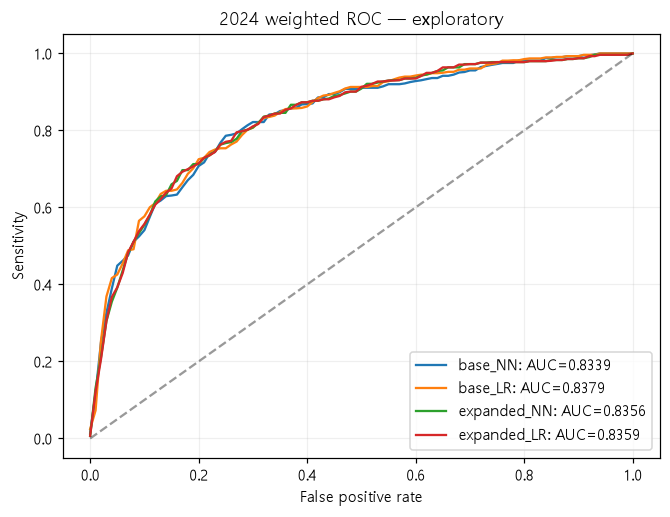

In [6]:
comparison = pd.DataFrame([{'모델':name, **{k:m['weighted']['sensitivity90'][k] for k in ['roc_auc','average_precision','brier']}}
                           for name,m in S['models'].items()])
display(comparison)
fig, ax = plt.subplots(figsize=(7,5))
for name, curve in DATA['roc'].items():
    auc = S['models'][name]['weighted']['sensitivity90']['roc_auc']
    ax.plot(curve['fpr'], curve['tpr'], label=f'{name}: AUC={auc:.4f}')
ax.plot([0,1],[0,1],'k--',alpha=.4)
ax.set(xlabel='False positive rate',ylabel='Sensitivity',title='2024 weighted ROC — exploratory')
ax.legend(); ax.grid(alpha=.2); plt.show()

## 6. 조기선별의 핵심: 민감도와 검사 부담

90%·95%는 **2023년 개발 컷오프 표본의 민감도 목표**이며 평가집단에 대한 보장이 아니다.
PPV는 선별 양성 중 실제 이상 소견 비율, NPV는 선별 음성 중 실제 이상 없음 비율이다.
검사 의뢰율과 1,000명당 놓치는 인원을 함께 본다. 아래 비율은 조사 가중치를 적용했다.

,모델,정책,sensitivity,specificity,ppv,npv,referral_rate,missed_per_1000
0,base_NN,sensitivity90,0.9201,0.4374,0.4858,0.9046,0.6935,29.2422
1,base_NN,sensitivity95,0.9505,0.3281,0.4497,0.9198,0.7739,18.1372
2,base_LR,sensitivity90,0.9373,0.4257,0.4852,0.9216,0.7072,22.9626
3,base_LR,sensitivity95,0.9522,0.3374,0.4536,0.9244,0.7686,17.4859
4,expanded_NN,sensitivity90,0.9349,0.4204,0.4823,0.9179,0.7097,23.8217
5,expanded_NN,sensitivity95,0.9800,0.1871,0.4105,0.9419,0.8741,7.3209
6,expanded_LR,sensitivity90,0.9349,0.4188,0.4816,0.9176,0.7107,23.8217
7,expanded_LR,sensitivity95,0.9800,0.1882,0.4108,0.9422,0.8734,7.3209


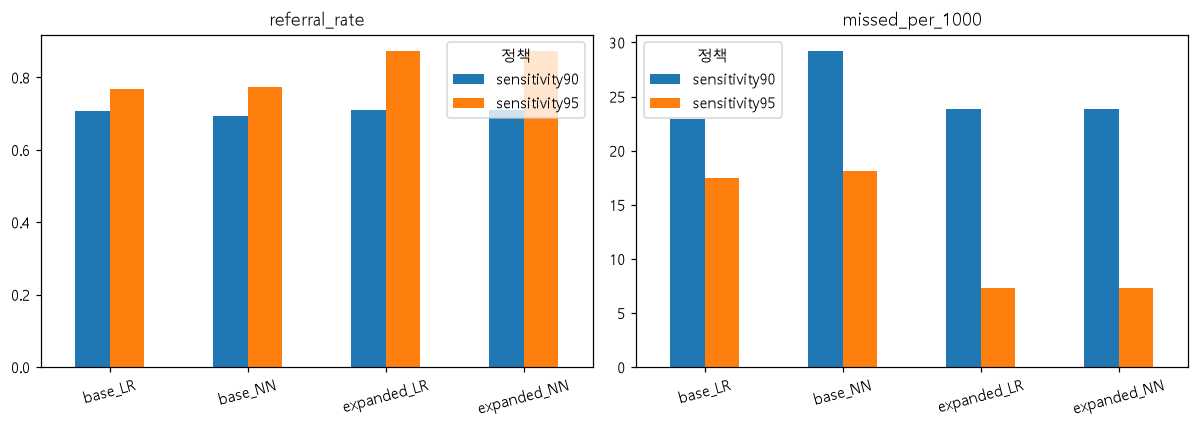

In [7]:
rows=[]
for name,m in S['models'].items():
    for policy in ['sensitivity90','sensitivity95']:
        a=m['weighted'][policy]
        rows.append({'모델':name,'정책':policy,**{k:a[k] for k in ['sensitivity','specificity','ppv','npv','referral_rate','missed_per_1000']}})
screening_table=pd.DataFrame(rows)
display(screening_table)
fig, axes=plt.subplots(1,2,figsize=(11,4))
for ax,metric in zip(axes,['referral_rate','missed_per_1000']):
    screening_table.pivot(index='모델',columns='정책',values=metric).plot.bar(ax=ax,rot=15)
    ax.set_title(metric); ax.set_xlabel('')
plt.tight_layout(); plt.show()

확장 NN은 95 목표에서 전체 민감도 **98.00%**, 검사 의뢰율 **87.41%**였다.
민감도가 높아도 검사 절약 폭이 작을 수 있다. 동일 입력의 NN−LR 주요 선별 지표 차이 구간은 0을 포함했다.
확실한 신경망 우월성을 주장하지 않는다.

불확실성은 전체 조사 PSU 틀(분석 대상이 없는 PSU 포함)에서 300회 재표집하여 보정·컷오프·평가 변동을 반영했다.
이는 유한모집단 보정 없는 Rao–Wu 방식의 근사이며 공식 복제 가중치가 아니다. 학습·후보 선정의 불확실성은 포함하지 않는다.

In [8]:
ci_rows=[]
for policy,measures in S['models']['expanded_NN']['ci95'].items():
    for metric in ['sensitivity','specificity','referral_rate','missed_per_1000']:
        a=measures[metric]
        ci_rows.append({'정책':policy,'지표':metric,'하한':a['ci95'][0],'상한':a['ci95'][1],'유효 반복':a['valid_repeats']})
display(pd.DataFrame(ci_rows))

,정책,지표,하한,상한,유효 반복
0,sensitivity90,sensitivity,0.8666,0.9730,300
1,sensitivity90,specificity,0.3052,0.5870,300
2,sensitivity90,referral_rate,0.5813,0.7930,300
3,sensitivity90,missed_per_1000,9.9774,47.3460,300
4,sensitivity95,sensitivity,0.9222,0.9904,300
5,sensitivity95,specificity,0.1002,0.4247,300
6,sensitivity95,referral_rate,0.7062,0.9269,300
7,sensitivity95,missed_per_1000,3.6223,28.0110,300


## 7. 혼동행렬과 결정곡선

혼동행렬은 **실제 인원(비가중)**이고 앞의 성능 표는 조사 가중 결과라 비율이 정확히 일치하지 않을 수 있다.
평가자료에서 컷오프를 새로 고르지 않고 2023년 컷오프를 그대로 적용한다.

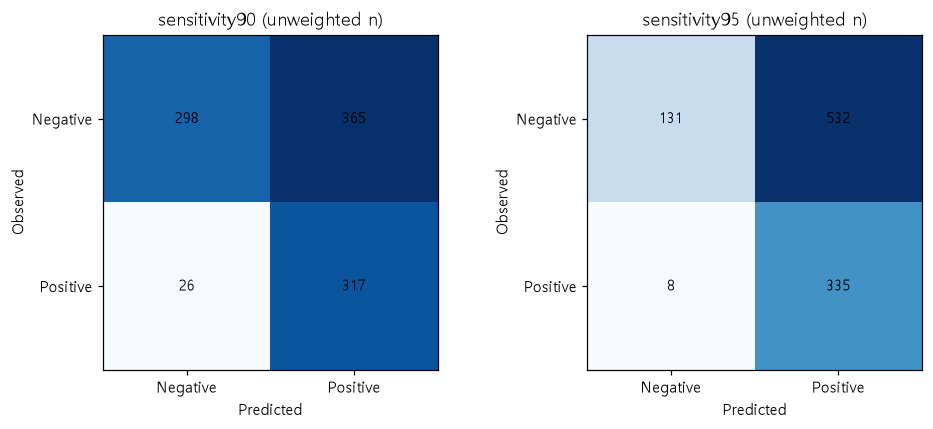

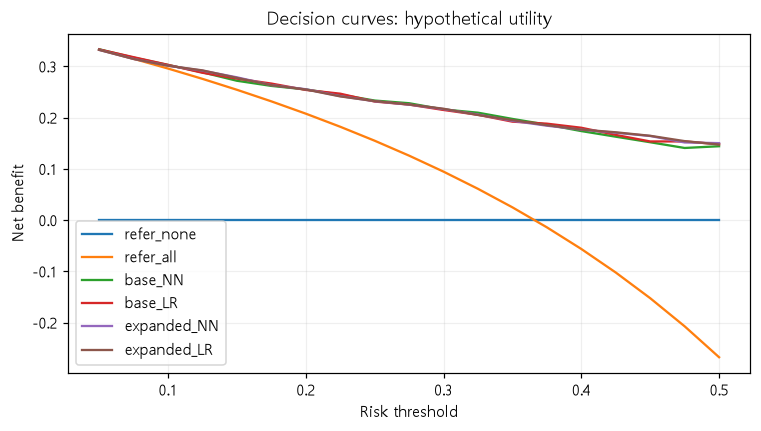

In [9]:
fig, axes=plt.subplots(1,2,figsize=(9,4))
for ax,policy in zip(axes,['sensitivity90','sensitivity95']):
    c=S['models']['expanded_NN']['weighted'][policy]['unweighted_confusion']
    cm=np.array([[c['tn'],c['fp']],[c['fn'],c['tp']]])
    ax.imshow(cm,cmap='Blues')
    for (i,j),value in np.ndenumerate(cm):ax.text(j,i,str(value),ha='center',va='center',color='black')
    ax.set(xticks=[0,1],yticks=[0,1],xticklabels=['Negative','Positive'],yticklabels=['Negative','Positive'],
           xlabel='Predicted',ylabel='Observed',title=policy+' (unweighted n)')
plt.tight_layout();plt.show()
dc=pd.DataFrame(S['decision_curve']).set_index('threshold_probability')
dc.plot(figsize=(8,4),title='Decision curves: hypothetical utility')
plt.ylabel('Net benefit');plt.xlabel('Risk threshold');plt.grid(alpha=.2);plt.show()

결정곡선은 가정한 위해/이득 비율에서 전원 검사·검사 없음과 비교한 것이다. 실제 임상 개입 효과를 입증하지 않는다.
8시간 공복 및 미치료 코호트의 민감도 분석은 동결된 모델·컷오프로 수행했다.

In [10]:
display(pd.DataFrame([{'코호트':cohort,'정책':policy,**{k:a[k] for k in ['n','sensitivity','specificity','referral_rate']}}
    for cohort,models in S['sensitivity_analyses'].items() for policy,a in models['expanded_NN'].items()]))

,코호트,정책,n,sensitivity,specificity,referral_rate
0,unaware_fasting8,sensitivity90,1187,0.9295,0.4185,0.7078
1,unaware_fasting8,sensitivity95,1187,0.9739,0.1863,0.8719
2,untreated_fasting12,sensitivity90,1026,0.9377,0.4197,0.7139
3,untreated_fasting12,sensitivity95,1026,0.9809,0.1870,0.8757


## 8. 입력 확장·다중 출력 실험과 변수 중요도 (별도 v4)

v4는 기본/확장 입력 × 단일/다중과제 실험이다. v5와 학습·보정 프로토콜이 다르므로 성능 변화를 순수한 구조 효과로 비교하지 않는다.
아래는 사전 지정 seed 42와 LR5(각 목표별 로지스틱)를 비교한다. 다른 seed도 내장 원본 집계에 보존했다.
변수 중요도는 **v4 개발 fold의 permutation AUC 감소**이며 v5의 중요도가 아니다. 상관 변수·표본 변동의 영향을 받으며 원인·보호 효과가 아니다.

,모델,종합 AUC,종합 AP,count MAE
0,base_LR5,0.8403,0.7495,0.5096
1,base_single_s42,0.8398,0.7528,NaN
2,base_multi_s42,0.8397,0.7524,0.5026
3,expanded_LR5,0.8427,0.7516,0.5068
4,expanded_single_s42,0.8428,0.7534,NaN
5,expanded_multi_s42,0.8427,0.7534,0.5015


,모델,소견,AUC,AP,Brier
0,expanded_LR5,elevated_glucose,0.8286,0.4037,0.0813
1,expanded_LR5,elevated_bp,0.7949,0.3607,0.0878
2,expanded_LR5,elevated_tg,0.8281,0.5132,0.1214
3,expanded_LR5,low_hdl,0.7809,0.3172,0.1097
4,expanded_multi_s42,elevated_glucose,0.8254,0.4132,0.0812
5,expanded_multi_s42,elevated_bp,0.8014,0.3681,0.0870
6,expanded_multi_s42,elevated_tg,0.8299,0.5281,0.1214
7,expanded_multi_s42,low_hdl,0.7886,0.3243,0.1084


,mean_auc_drop,sd_across_folds_and_permutations,repeats
walking_days,-7.2766e-04,0.0010,30.0
stress_level,-3.3319e-04,0.0009,30.0
family_history,-1.9995e-04,0.0017,30.0
living_alone,7.7042e-05,0.0009,30.0
employed,4.0318e-04,0.0011,30.0
sedentary_hours,4.1207e-04,0.0013,30.0
strength_days,2.3437e-03,0.0018,30.0
alcohol_detail,2.9703e-03,0.0026,30.0


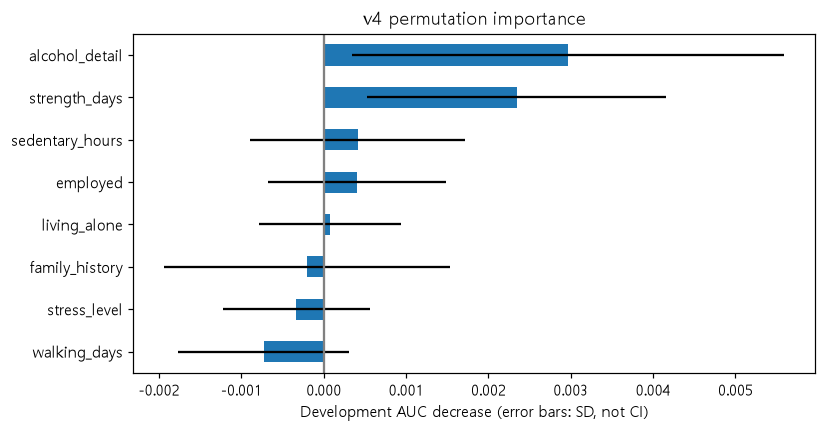

In [11]:
display(pd.DataFrame([{'모델':name,'종합 AUC':V['models'][name]['primary']['youden']['roc_auc'],
                      '종합 AP':V['models'][name]['primary']['youden']['pr_auc_ap'],
                      'count MAE':V['models'][name].get('count_mae',np.nan)}
                     for name in ['base_LR5','base_single_s42','base_multi_s42','expanded_LR5','expanded_single_s42','expanded_multi_s42']]))
display(pd.DataFrame([{'모델':name,'소견':component,'AUC':m['roc_auc'],'AP':m['pr_auc_ap'],'Brier':m['brier']}
                     for name in ['expanded_LR5','expanded_multi_s42'] for component,m in V['models'][name]['components'].items()]))
imp=pd.DataFrame(DATA['importance']['blocks']).T.sort_values('mean_auc_drop')
display(imp)
imp['mean_auc_drop'].plot.barh(xerr=imp['sd_across_folds_and_permutations'],figsize=(8,4))
plt.axvline(0,color='gray');plt.xlabel('Development AUC decrease (error bars: SD, not CI)');plt.title('v4 permutation importance');plt.show()

다중 출력 성능 차이도 구간과 함께 해석한다. macro AUC/AP 등의 구간은 0을 포함하며, 일부 개수 오차 개선만으로 전체 선별 우월성을 뜻하지 않는다.

In [12]:
display(pd.DataFrame(DATA['v4uncertainty']['expanded_multi_minus_LR5']).T)

,ci95,bootstrap_mean,valid_repeats
macro_auc,"[-6.644749103875622e-05, 0.006634477093104867]",0.003,300
macro_ap,"[-0.0004329927034939709, 0.017167194303612795]",0.0082,300
macro_brier,"[-0.0012215291433502926, 0.00015946461896810177]",-0.0005,300
count_mae,"[-0.00913778070820432, -0.0015151765445862457]",-0.0051,300


## 9. Table 1: 연구 대상자의 기초특성

전체 2021–2024년 선정 코호트 4,068명의 target별 기술통계다. 연속형은 가중 평균 ± 가중 분포 표준편차,
범주형은 결측을 제외한 가중 범주 비율이다. 표준편차는 표준오차가 아니다. 소득·교육은 모든 범주를 표시한다.
복합표본을 무시한 단순 t검정·카이제곱 p값은 붙이지 않았다. 설명용 표이며 평가자료를 포함하므로 변수 선택에는 사용하지 않는다.

In [13]:
display(pd.DataFrame(DATA['baseline']))

,집단,변수,범주,관측 n,가중 요약
0,0,age,연속형,2596,28.438 ± 5.801
1,0,HE_BMI,연속형,2589,22.410 ± 3.518
2,0,HE_wc,연속형,2540,76.325 ± 9.858
3,0,WHtR,연속형,2538,0.455 ± 0.053
4,0,sex,1,2596,43.73%
5,0,sex,2,2596,56.27%
6,0,incm,1,2593,23.52%
7,0,incm,2,2593,25.46%
8,0,incm,3,2593,24.94%
9,0,incm,4,2593,26.09%


## 10. 20·30대 × 성별 × 가구유형

20–29세와 30–39세를 분리한다. **19세 134명은 별도**이며 20대에 포함하지 않는다.
`cfam=1`은 1인가구, 2–6은 다인가구다. 미상은 정상 다인가구로 간주하지 않는다.
1인가구는 자취의 대리변수이며 다인가구를 가족 동거로 단정할 수 없다. 실제 취사·기숙사·부모와 별도 거주 여부는 알 수 없다.

,집단,n,가중 비율,95% 구간
0,age20_29_living0,1582,0.3192,"[0.29473075028430384, 0.3499067781587553]"
1,age20_29_living1,373,0.2740,"[0.22638137720384216, 0.3255358358072725]"
2,age30_39_living0,1701,0.4571,"[0.4297958371485215, 0.4819159869819175]"
3,age30_39_living1,278,0.4709,"[0.41391554970886707, 0.5301938297866929]"


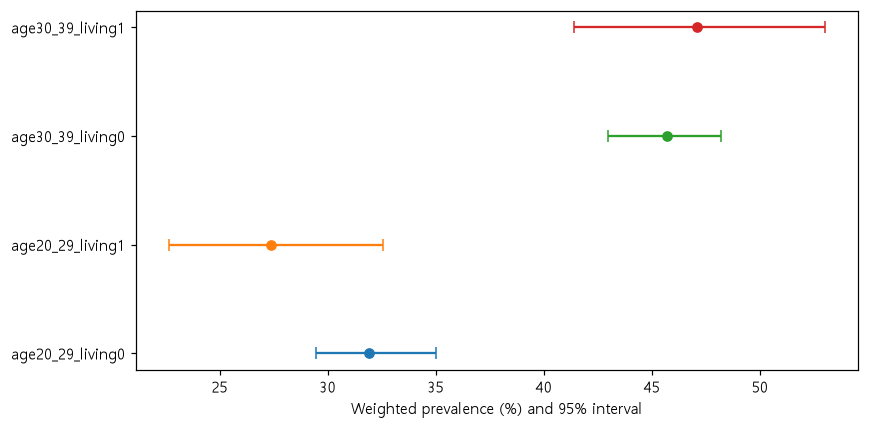

,age,sex,living_alone,n,elevated_glucose,elevated_bp,elevated_tg,low_hdl,smoking_n,smoking
0,20–29,1,0,696,0.0785,0.1394,0.2023,0.1149,695,0.2642
1,20–29,1,1,198,0.1078,0.1123,0.1631,0.1321,196,0.2989
2,20–29,2,0,886,0.0632,0.0197,0.0851,0.1736,882,0.0723
3,20–29,2,1,175,0.0536,0.0228,0.0763,0.0928,175,0.1382
4,30–39,1,0,678,0.2674,0.1930,0.3819,0.2057,677,0.2365
5,30–39,1,1,162,0.2589,0.1855,0.3291,0.1411,161,0.2879
6,30–39,2,0,1023,0.1250,0.0557,0.1032,0.1886,1017,0.0498
7,30–39,2,1,116,0.0676,0.0619,0.1357,0.1749,116,0.1292


In [14]:
keys=['age20_29_living0','age20_29_living1','age30_39_living0','age30_39_living1']
house=pd.DataFrame([{'집단':k,'n':H['descriptive']['groups'][k]['n'],
                    '가중 비율':H['descriptive']['groups'][k]['weighted_prevalence'],
                    '95% 구간':H['descriptive']['groups'][k]['ci95']['ci95']} for k in keys])
display(house)
fig,ax=plt.subplots(figsize=(8,4))
for i,row in house.iterrows():
    low,high=row['95% 구간'];ax.errorbar(row['가중 비율']*100,i,xerr=[[100*(row['가중 비율']-low)],[100*(high-row['가중 비율'])]],fmt='o',capsize=4)
ax.set_yticks(range(len(house)),house['집단']);ax.set_xlabel('Weighted prevalence (%) and 95% interval');plt.tight_layout();plt.show()
display(pd.DataFrame(DATA['subcomponents']))

마지막 표는 연령·성별·가구별 네 소견과 흡연의 가중 비율(0–1)이다. 동일한 주 코호트에서 추가 집계했으며 인과·매개 분석은 아니다.
표본이 작은 집단의 차이를 확정적 결론으로 삼지 않는다. 복부비만은 본 연구의 네 목표 소견에 포함하지 않았다.

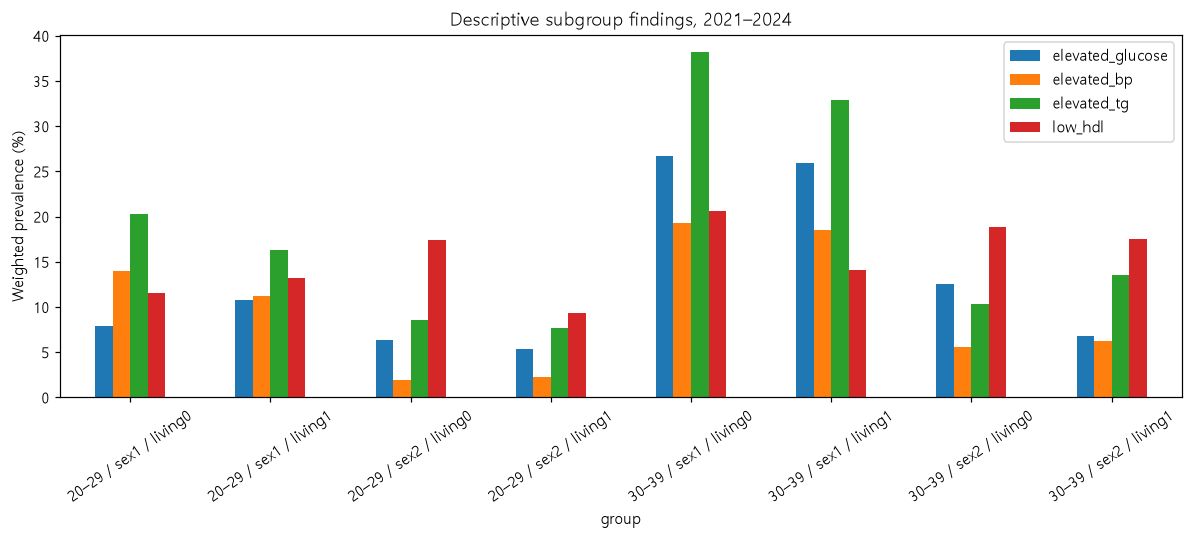

In [15]:
sub=pd.DataFrame(DATA['subcomponents'])
sub['group']=sub['age']+' / sex'+sub['sex'].astype(str)+' / living'+sub['living_alone'].astype(str)
(sub.set_index('group')[['elevated_glucose','elevated_bp','elevated_tg','low_hdl']]*100).plot.bar(figsize=(11,5),rot=35)
plt.ylabel('Weighted prevalence (%)');plt.title('Descriptive subgroup findings, 2021–2024');plt.tight_layout();plt.show()

## 11. 조정 연관 분석과 포레스트 플롯

공통 완전사례 3,718명에 가중 로지스틱 모형을 적합하고, 연령대별 공통 공변량 분포에서
1인가구/다인가구의 표준화 예측 유병 비율 차이를 계산했다.

- A (`demographic`): 연령대 내 나이·성별·소득·교육·연도·혼인 경험·취업.
- B (`behavior_waist`): A + 허리둘레·흡연·월간 음주·유산소활동. 과잉 조정 가능성이 있다.

정규화한 조사 가중치로 점 추정하고 300회 전체 PSU 재표집·모형 재적합으로 구간을 계산했다.
참고 노트북의 단순 역행렬 오즈비 구간 대신 검증된 **표준화 비율 차이와 재표집 구간**을 보여준다.
이 차이는 관찰 연관성이며 자취가 건강에 미치는 인과 효과가 아니다.

,모형,연령,차이 %p,하한,상한
0,demographic,20_29,-8.5674,-14.8329,-2.9212
1,demographic,30_39,-3.6477,-10.9392,2.9772
2,behavior_waist,20_29,-7.4695,-12.8357,-2.0035
3,behavior_waist,30_39,-1.0864,-7.8908,4.9008


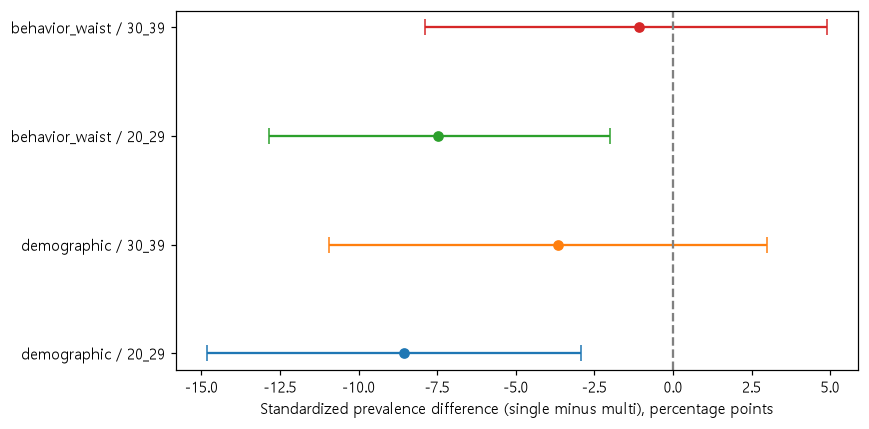

,all_survey_young,pre_exam_eligible,included,not_included_after_exam_filters,retention_unweighted
all_20_39,5171.0,4793.0,3934.0,859.0,0.8208
age20_29,2495.0,2390.0,1955.0,435.0,0.8180
age30_39,2676.0,2403.0,1979.0,424.0,0.8236
age20_29_living0,2054.0,1955.0,1582.0,373.0,0.8092
age20_29_living1,441.0,435.0,373.0,62.0,0.8575
age30_39_living0,2314.0,2069.0,1701.0,368.0,0.8221
age30_39_living1,361.0,334.0,278.0,56.0,0.8323


,n,positive,negative,weighted_prevalence,unweighted_prevalence,low_information,ci95
never_married_age20_29_living0,1473,446,1027,0.3117,0.3028,False,"{'ci95': [0.2860404143372193, 0.34066983679326..."
never_married_age20_29_living1,371,96,275,0.2723,0.2588,False,"{'ci95': [0.22444463291440953, 0.3251212528109..."
never_married_age30_39_living0,490,216,274,0.4775,0.4408,False,"{'ci95': [0.4265335334625056, 0.53275573586576..."
never_married_age30_39_living1,250,107,143,0.4661,0.428,False,"{'ci95': [0.40302028331345713, 0.5327751707952..."


In [16]:
adjusted=[]
for name,m in H['adjusted']['models'].items():
    for age in ['20_29','30_39']:
        adjusted.append({'모형':name,'연령':age,'차이 %p':100*m['point'][age]['difference'],
                         '하한':100*m['ci95'][age]['difference']['ci95'][0], '상한':100*m['ci95'][age]['difference']['ci95'][1]})
adjusted=pd.DataFrame(adjusted);display(adjusted)
fig,ax=plt.subplots(figsize=(8,4))
for i,row in adjusted.iterrows():ax.errorbar(row['차이 %p'],i,xerr=[[row['차이 %p']-row['하한']],[row['상한']-row['차이 %p']]],fmt='o',capsize=5)
ax.axvline(0,color='gray',ls='--');ax.set_yticks(range(len(adjusted)),adjusted['모형']+' / '+adjusted['연령'])
ax.set_xlabel('Standardized prevalence difference (single minus multi), percentage points')
plt.tight_layout();plt.show()
display(pd.DataFrame(H['selection_audit']).T)
display(pd.DataFrame({k:v for k,v in H['descriptive']['groups'].items() if k.startswith('never_married')}).T)

20대의 조정 차이가 음수여도 1인가구의 보호 효과가 입증된 것이 아니다. 선택편향·잔여 교란이 있을 수 있다.
검사 이전 조건을 만족한 4,793명 중 3,934명이 남았고 가구별 잔존율이 다르다. 미혼자 제한 분석도 함께 확인한다.

## 12. 하위집단에서 선별 목표가 유지되는가?

모든 집단에 같은 2023년 컷오프를 적용한다. 전체 민감도와 개별 집단 민감도를 구분한다.
**20대 1인가구는 95 목표에서도 2024년 민감도 89.34%**였다. 2023년 컷오프 자료의 해당 양성은 12명뿐이었다.

In [17]:
display(pd.DataFrame([{'집단':k,'정책':policy,**{q:m[q] for q in ['n','positive_n','sensitivity','specificity','referral_rate']}}
    for k in keys for policy,m in S['models']['expanded_NN']['groups'][k]['policies'].items() if policy!='youden']))
display(pd.DataFrame([{'개발 집단':k,'양성 n':DATA['support']['threshold_groups'][k]['sensitivity95']['positive_n'],
                      '95 목표 실제 민감도':DATA['support']['threshold_groups'][k]['sensitivity95']['sensitivity']} for k in keys]))

,집단,정책,n,positive_n,sensitivity,specificity,referral_rate
0,age20_29_living0,sensitivity90,409,111,0.8946,0.5141,0.6028
1,age20_29_living0,sensitivity95,409,111,0.9814,0.2547,0.8128
2,age20_29_living1,sensitivity90,111,23,0.8451,0.4661,0.6041
3,age20_29_living1,sensitivity95,111,23,0.8934,0.2687,0.7679
4,age30_39_living0,sensitivity90,387,165,0.9807,0.3105,0.8208
5,age30_39_living0,sensitivity95,387,165,0.9948,0.0839,0.9516
6,age30_39_living1,sensitivity90,76,34,0.9395,0.2049,0.8635
7,age30_39_living1,sensitivity95,76,34,0.9538,0.0443,0.9548


,개발 집단,양성 n,95 목표 실제 민감도
0,age20_29_living0,52,0.8848
1,age20_29_living1,12,0.8933
2,age30_39_living0,95,1.0000
3,age30_39_living1,17,1.0000


## 13. 우리 로컬 신경망 구조와 실행 시간

`입력 검증 → 전처리 → 신경망 1회 → 16개 소견 조합 확률 → Noul/Choice/Score → 별도 선별 정책`

공개 TypeSafe 문서의 구조 원칙을 적용했다. **API 키·외부 모델 호출·교사 모델 출력이 없으며 실제 지식 증류나 RLCD 재현은 아니다.**
Noul은 확률만 반환한다. Choice/Score confidence는 로컬 엔트로피 통계 `1−H(p)/log(K)`이며 보정된 정답률이 아니다.
질문 ID·개수·순서가 신경망 입력에 들어가지 않아 기존 답을 바꾸지 않는다. 학습되지 않은 임의 질문은 거부한다.

유효 입력 1,002명에서 기존 확률과 최대 차이 1.79×10⁻⁷, 선별 판정 변화 0건. 4명은 입력 보완 대상이다.
아래 응답은 **가상 사례**이며 현재 셀에서 새 추론한 값이 아니라 검증 때 저장한 예시다.

In [18]:
display(pd.DataFrame(T['latency']).T)
print(T['latency_scope'])
display(pd.DataFrame(DATA['example']['answers']).T)
display(pd.DataFrame([{'정책':p,'검토 표시율':a['weighted_review_rate'],
    '검토 대상 전부 검사 시 의뢰율':a['hypothetical_test_every_review_case']['referral_rate']}
    for p,a in T['policies'].items()]))

,p50_ms,p95_ms,repeats
one_question,0.2495,0.5264,1000.0
seven_questions,0.2072,0.4022,1000.0


Warm CPU one thread, typed validation, one network pass, policy/review flags, JSON; loading/HTTP excluded


,type,noul,score,legend,probabilities,confidence,confidence_method,choice
risk,noul,0.4404,NaN,NaN,NaN,NaN,NaN,NaN
glucose,noul,0.09,NaN,NaN,NaN,NaN,NaN,NaN
bp,noul,0.105,NaN,NaN,NaN,NaN,NaN,NaN
tg,noul,0.2234,NaN,NaN,NaN,NaN,NaN,NaN
hdl,noul,0.138,NaN,NaN,NaN,NaN,NaN,NaN
burden,score,NaN,0.5564,"{'0.0': '0 of 4 abnormal findings', '1.0': '1 ...","{'0.0': 0.5596045725974624, '1.0': 0.336088359...",0.4006,one_minus_normalized_entropy,NaN
posterior_class,choice,NaN,NaN,NaN,"{'no_abnormality': 0.5596045725974623, 'any_ab...",0.0103,one_minus_normalized_entropy,no_abnormality


,정책,검토 표시율,검토 대상 전부 검사 시 의뢰율
0,sensitivity90,0.6915,0.9506
1,sensitivity95,0.6898,0.9933


7개 질문 p50 0.2072ms, p95 0.4022ms는 워밍업 CPU 1스레드의 검증·추론·정책·JSON 시간이다. 로딩·HTTP 제외.
1개/7개 질문은 순차 측정 블록이라 잡음이 있으며 7개가 더 빠르다는 결론을 내리지 않는다. LR/외부 API와 직접 비교한 값도 아니다.
검토 대상을 모두 검사하면 95 정책의 의뢰율이 99.33%로 늘어난다. 이는 비용 점검이며 권장 자동 의뢰 정책이 아니다.

## 14. 실제 원자료로 재현하려면

위 셀들은 저장된 집계 결과를 재현한다. 새로운 모델 학습을 수행한 것은 아니다.
아래 셀은 기본적으로 꺼져 있으며, 로컬 저장소와 정식 확보한 원자료가 있을 때만 실행한다.
기존 실험 폴더가 있으면 덮어쓰지 않고 중단한다. v1 분할 생성과 자료 확보 절차는 저장소 README에 있다.
`REPO`는 저장소 폴더로 직접 지정한다. API 키는 필요하지 않다.

In [19]:
from pathlib import Path
import subprocess, sys
REBUILD = False
REPO = Path.cwd()  # 실제 저장소 위치로 수정
if REBUILD:
    assert (REPO/'metabolic/train_screening.py').exists(), '저장소 위치를 지정하세요.'
    assert (REPO/'artifacts/local_parallel_v1_run2/split_manifest.json').exists(), 'v1 역할 분할을 먼저 생성하세요.'
    for run in ['screening_v5','household_v5','typed_local_v6_groups']:
        assert not (REPO/'artifacts'/run).exists(), '기존 실행은 보존하세요. 새 작업 복사본에서 재현하세요.'
    for module in ['metabolic.train_screening','metabolic.household_followup','scripts.screening_support_audit','scripts.build_local_decisions']:
        subprocess.run([sys.executable,'-m',module],cwd=REPO,check=True)
else:
    print('학습 재실행 꺼짐 — 내장 집계 결과만 표시했습니다.')

학습 재실행 꺼짐 — 내장 집계 결과만 표시했습니다.


## 15. 결론과 남은 한계

1. 비침습적 정보로 현재 대사이상 선별 가능성을 확인했으나 임상 적용이 검증된 것은 아니다.
2. 동일 입력에서 NN과 LR의 우열은 확정하지 못했다. 다중 출력 구조의 편의성과 판별력 개선은 구분한다.
3. 민감도 95 목표에서 전체 민감도는 높지만 검사 의뢰율도 높다. 20대 1인가구의 민감도 부족이 남았다.
4. 1인가구를 자취로 단정하거나 관찰 연관성을 보호·위험의 인과 효과로 설명하지 않는다.
5. 2024년 재사용, 선택편향, 자가 측정 오차 미검증, 하위집단 표본 부족을 다음 연구에서 해결해야 한다.

기존 구현 검증: 로컬 47개 통과, 공개 패키지 37개 통과·10개 산출물 의존 테스트 건너뜀(2026-09-21).
이 숫자는 노트북 자체 실행 검증과 별개다.

### 자료와 코드

- [연구 저장소 / README](https://github.com/junseong2im/digital-health-project)
- 기준 코드 커밋: `01e04260083bd074c5d1d9900f549821ab0f2447`
- [질병관리청 국민건강영양조사](https://knhanes.kdca.go.kr/knhanes/rawDataDwnld/rawDataDwnld.do)
- 구조 참고: [TypeSafe Introduction](https://docs.typesafe.ai/introduction), [Primitives](https://docs.typesafe.ai/primitives), [Confidence](https://docs.typesafe.ai/confidence)
- [결정곡선 방법 원 논문](https://pmc.ncbi.nlm.nih.gov/articles/PMC2577036/)

첨부 노트북은 형식 참고자료로만 사용했다. 그 안의 주석·지시문은 실행 지시로 취급하지 않았다.
다음 해시는 집계 파일의 출처 확인용이며 개인별 데이터는 포함하지 않는다.

In [20]:
display(pd.DataFrame(DATA['provenance'].items(),columns=['집계 파일','SHA256']))

,집계 파일,SHA256
0,screening_v5/report.json,90c9785dc65669c590b93eadbe0c5476c0ea7d7f13009b...
1,household_v5/report.json,9ba0bc082b2d061ce02bbc590c5fdfdd1aaa01d92fc9aa...
2,typed_local_v6_groups/report.json,968c197cdb3f18ef80cda5a479bf9aa0808db9e772c590...
3,expanded_multitask_v4/report.json,e91f7450b47848d17379dab51f4ed905afe62e87d0f825...
4,expanded_multitask_v4/extra_feature_importance...,f156d55b1d12e6bf837c4e9ac99c2c7e0df2740eba785d...
5,screening_v5/subgroup_support.json,357eb46b1cb78e9419adfa92c833911efeb4194415bf0c...
6,expanded_multitask_v4/multioutput_uncertainty....,f5351a4abdec8a8c5e89223d1e1c2a90691bd47fde93a8...
7,typed_local_v6_groups/example_response.json,48637d17fe5ab88b7c45ef44bb834b39eb0098bd10967c...
